# Chapter 10 — Computational Fluid Dynamics

*Fluid Mechanics, 5th edition — Pijush K. Kundu, Ira M. Cohen, David R. Dowling (2012).*
This notebook teaches every new idea of the chapter with plain words, step-by-step mathematics, small worked examples, tested Python from the `fluidpy` package, figures, animations and interactive explainers. It does not reproduce the book's text or figures; every equation is shown in full together with its number, so you can follow along in your copy.

---

**The big idea in one paragraph**

Every flow in this book so far was solved with pencil and paper — and only because we could simplify it: a straight wall, a thin
layer, a small wave. Real flows (a whole ocean basin, the air over a city, blood in a branching artery) do not simplify, so we hand
the conservation laws of Ch. 4 to a computer. A computer cannot store a function; it stores numbers at points (finite
differences) or the weights of simple building blocks (finite elements), and it replaces every derivative by arithmetic on those
numbers. This chapter is about what that replacement costs and how to control it: how wrong a stencil is (order of accuracy), when
an update rule blows up (von Neumann stability, the CFL condition), why a perfectly consistent scheme can still produce negative
temperatures (the cell Péclet number), how the pressure is found in incompressible flow (the projection on a staggered grid — the
same C-grid that ocean and atmosphere models use), and finally how to earn trust in a CFD answer: a published benchmark and a
grid-convergence study.

**Road map** — the new ideas of this chapter, in the order they build on each other:

1. C01 stencils and their order of accuracy: $\big[\frac{\partial T}{\partial x}\big]_i=\frac{T_{i+1}-T_{i-1}}{2\Delta x}+O(\Delta x^2)$ *(10.6)*
2. C02 the explicit FTCS scheme: $T^{n+1}_i=T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})$ *(10.10)*
3. C03 consistency and the truncation error $E^n_i=\frac{\Delta t}{2}T_{tt}+u\frac{\Delta x^2}{6}T_{xxx}-D\frac{\Delta x^2}{12}T_{xxxx}$ *(10.17)*
4. C04 von Neumann stability: the amplification factor $G(\theta)$ and Noye's region $0\le4\alpha^2\le2\beta\le1$ *(10.27)*
5. C05 upwinding and the CFL condition $u\frac{\Delta t}{\Delta x}\le1$ *(10.30)*, closed by the Lax equivalence theorem
6. C06 the weak form $\int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)$ and natural vs essential conditions
7. C07 Galerkin with hat functions: $\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F$ *(10.58)*
8. C08 element matrices and assembly: one $2\times2$ block per element, scatter-added
9. C09 convection-dominated flow: wiggles for $R_{cell}>2$ and upwinding's numerical diffusivity $0.5R_{cell}D$
10. C10 weak compressibility and MacCormack's predictor–corrector for $\mathbf U_t+\mathbf E(\mathbf U)_x+\mathbf F(\mathbf U)_y=0$ *(10.100)*
11. C11 operator splitting and projection: $\nabla^2p^{n+1}=\frac1{\Delta t}\nabla\cdot\mathbf u^{n+1/2}$
12. C12 the staggered (MAC) grid: discrete continuity, the pressure Poisson equation, no checkerboard
13. C13 mixed finite elements and the LBB (inf–sup) condition: Taylor–Hood P2–P1
14. C14 the lid-driven cavity benchmark (Ghia, Ghia & Shin 1982)
15. C15 grid convergence and Richardson extrapolation: $f_0\approx f_1+\frac{f_1-f_2}{r^p-1}$

**What you should already know** (each is recapped where it is used):

- Navier–Stokes and continuity (Ch. 4 §4.2, §4.5)
- dimensionless Navier–Stokes and the Reynolds number (Ch. 4 §4.11)
- the diffusion equation and FTCS (Ch. 1 §1.5; Crank–Nicolson in Ch. 8 §8.4)
- Laplace and Poisson equations on a grid and relaxation (Ch. 6 §6.7)
- Fourier modes and plane waves (Ch. 5, Ch. 7)
- the physics of the cavity and cylinder flows (Ch. 8, Ch. 9 §9.8)

## 🎮 Interactive explainers in this chapter

| # | Explainer | What it makes clear |
|---|---|---|
| 1 | **What does 'second-order accurate' really mean?** | C01 C03: a stencil is a weighted sum of Taylor series; the first term it fails to cancel is its error, visible as a slope on log–log axes |
| 2 | **Why does β = 0.51 blow up when 0.50 does not?** | C04 C02: every Fourier mode of the round-off is multiplied by the same complex G(θ) each step; stability is |G| ≤ 1 for all θ |
| 3 | **Why must the time step shrink with the grid?** | C05 C10: the characteristic through the new point must start inside the stencil (CFL); first order pays in amplitude, second order in phase |
| 4 | **Why does a centred scheme give negative temperatures?** | C09: the discrete solution is rʲ with r < 0 once R_cell > 2; upwinding adds a diffusivity 0.5 R_cell D |
| 5 | **Where do finite-element matrices come from?** | C06 C07 C08: each element adds a 2 × 2 block; the assembled rows are FD stencils with a ⅙–⅔–⅙ mass |
| 6 | **What is the pressure doing in incompressible flow?** | C11 C12: one Poisson solve removes the divergence; on a staggered grid a zigzag pressure cannot hide |
| 7 | **How do I know my CFD answer is right?** | C14 C15: reproduce a benchmark and watch the error fall at the expected order |
| 8 | **Why can't velocity and pressure use the same elements?** | C13: equal order leaves pressure modes the divergence cannot see; P2–P1 keeps the inf–sup constant bounded |

Each one opens right where its idea is taught and fills the window (no scrolling). Start with the **Walkthrough**, then **Explore** with the sliders and presets, read **Explain** (every number worked out with your settings, and what it means), step through the **Derivation** where there is one, read the **Equations** and the **Code**, and finish with **Check yourself**. On the web page they are full-window; in Colab and Jupyter they appear in the cell output (use ⤢ *Full screen* or *Open in new tab* for more room).

## ⚙️ Setup — run this cell first

It works in three places without changes:
* **Google Colab** — clones the public repository into `/content/fluidpy` (the `fluidpy` package, its tests and the
  interactive explainers) and installs the one package Colab lacks (`pint`). No GPU is needed.
* **Jupyter / VS Code on your computer** — finds the repository root (the folder with `book.yaml`) and imports from it.
* **The published web page** — already executed; nothing to run.

In [1]:
# ── Setup: find (or fetch) the fluidpy repository, then load the house style ─────────────────────────────
import os, sys, subprocess, pathlib                     # standard library only, so this cell never fails on imports

IN_COLAB = "google.colab" in sys.modules                 # True when this notebook runs inside Google Colab
REPO_URL = "https://github.com/shammun/fluidpy.git"               # the public repository with the fluidpy package

if IN_COLAB:
    ROOT = pathlib.Path("/content/fluidpy")              # where the repository is cloned on Colab
    if not ROOT.exists():                                 # first run in this Colab session: clone it
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(ROOT)], check=True)
    else:                                                 # later runs: fetch the newest version
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only", "-q"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(ROOT / "requirements-colab.txt")], check=True)
else:
    ROOT = pathlib.Path.cwd().resolve()                   # start where Jupyter was launched …
    while not (ROOT / "book.yaml").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent                                # … and walk up until we find the repository root

os.chdir(ROOT)                                            # relative paths (outputs/, viz/) now resolve from the root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                         # make `import fluidpy` work

from fluidpy.core.style import setup_notebook            # matplotlib + plotly style shared with the explainers
from fluidpy.core.embed import show_viz                  # shows an interactive explainer in the notebook
from fluidpy.core.anim import show_animation             # plays a matplotlib animation inline
FAST = setup_notebook()                                   # FAST=True (env FLUIDPY_FAST=1) shrinks grids for quick runs
print(f"IN_COLAB = {IN_COLAB} | repository root: {ROOT} | FAST = {FAST}")

IN_COLAB = False | repository root: C:\Users\sislam27\Work\Climate Dynamics PHD\Fluid Dynamics | FAST = False


In [2]:
import numpy as np                                       # arrays and maths (Ch. 1 primer P03)
import sympy as sp                                       # symbolic algebra (Ch. 1 primer P40)
import matplotlib.pyplot as plt                          # static figures (Ch. 1 primer P01)
import scipy.sparse as sps                               # sparse matrices (Ch. 6 primer P161)
from scipy import linalg, sparse                         # dense linear algebra (expm, eigh) and sparse tools
from fluidpy import ch10_computational_fluid_dynamics as ch10   # the tested chapter-10 module (re-exports five toolkits)
from fluidpy.core import fd as FD, fem1d as FEM1, mac as MAC, maccormack as MCK, fem2d as FEM2   # the toolkits themselves
from fluidpy.core import diffusion as DIF, waves as WV   # Ch. 1 FTCS diffusion and Ch. 7 wave speeds, reused
from fluidpy import ch04_conservation_laws as ch04       # Ch. 4: the incompressibility criterion
from fluidpy.core.interact import slider_figure, live    # plotly sliders (P17) and live widgets (P47)
from fluidpy.core.anim import animate                    # matplotlib animations (P16); show_animation came with setup
from fluidpy.core.style import COLORS, savefig           # the house palette and a helper that saves PNGs to outputs/ch10
from tools.convergence import observed_order, pairwise_orders, richardson, grid_convergence_index   # order and Richardson tools
sys.path.insert(0, str(ROOT / "scripts"))                # the chapter's drawing helpers live in scripts/
from ch10_drawings import (spacetime_grid, characteristic_diagram, hat_functions, element_map, staggered_grid,
                           p2p1_triangle, cavity_sketch, block_channel_sketch)   # drawing only, no physics
import logging, time                                     # Python's message system; a wall-clock timer
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # hide harmless "font not found" notes
C_EX, C_FT, C_UP, C_IM, C_MC, C_BAD = (COLORS["muted"], COLORS["orange"], COLORS["teal"], COLORS["blue"],
                                       COLORS["accent"], COLORS["rose"])   # one colour per meaning (see the conventions)


def read_table(name):                                    # one of our small committed tables in reference/ch10/ (or Ghia's)
    lines = (ROOT / "reference" / "ch10" / name).read_text(encoding="utf-8").splitlines()   # the file as text lines
    notes = [ln.lstrip("# ") for ln in lines if ln.startswith("#")]                        # the comment header (source, run data)
    rows = [ln for ln in lines if ln.strip() and not ln.startswith("#")]                  # the header row and the numbers
    cols = rows[0].split(",")                                                              # column names
    data = np.array([[float(v) for v in r.split(",")] for r in rows[1:]])                  # the numbers, one row per line
    return {c: data[:, k] for k, c in enumerate(cols)}, " ".join(notes)                   # dict of columns, and the notes
print(len([n for n in dir(ch10) if not n.startswith("_")]), "public names in fluidpy.ch10_computational_fluid_dynamics")   # show the numbers computed above
print("ch10.fd_weights is FD.fd_weights:", ch10.fd_weights is FD.fd_weights)   # the re-export: one function, two names

201 public names in fluidpy.ch10_computational_fluid_dynamics
ch10.fd_weights is FD.fd_weights: True


**What does the code above do?**

1. Numerical, symbolic and plotting libraries (primed in Ch. 1); `scipy.sparse` and `scipy.linalg` are reminded where they are first used.
   `read_table(name)` reads one of our small committed tables from `reference/ch10/` (comment lines first, then a header row and numbers) into a
   dict of columns — the cached results of runs too long for this notebook.
2. `ch10` is the chapter module. It **re-exports the five new toolkits** — `core.fd` (`FD`: stencils, schemes, stability),
   `core.fem1d` (`FEM1`: 1-D finite elements), `core.mac` (`MAC`: the staggered-grid projection), `core.maccormack` (`MCK`: the
   explicit predictor–corrector) and `core.fem2d` (`FEM2`: triangles and mixed elements) — so `ch10.fd_weights` and `FD.fd_weights`
   are the same function (the last line prints `True`). Every function cites its § and equation and is tested in `tests/test_ch10.py`.
3. `tools.convergence` holds the order-of-accuracy and Richardson helpers used from C01 to C15.
4. `scripts/ch10_drawings.py` only draws (a space–time grid, hats, a staggered cell, a cavity); it computes no physics.
5. `C_EX, C_FT, …` fix one colour per meaning for the whole chapter: exact solution grey, FTCS/centred orange, upwind teal,
   implicit blue, MacCormack purple, unstable rose.

### ⚠️ Conventions in this chapter (read once; each is repeated where it bites)

| Book symbol | Its meanings in the book | What we write |
|---|---|---|
| $i$ | the grid index **and** $\sqrt{-1}$ (in the Fourier analysis) | the imaginary unit is upright $\mathrm i$; in our own lines of the stability derivations the grid index is $j$ |
| $\alpha,\ \beta$ | FTCS numbers $\alpha=u\frac{\Delta t}{2\Delta x}$, $\beta=D\frac{\Delta t}{\Delta x^2}$; weights of the Θ-scheme; time weights of the FE cylinder | FTCS: the book's; Courant number $C=2\alpha=u\Delta t/\Delta x$; Θ-scheme $\alpha_\Theta,\beta_\Theta$; time weights $\alpha_t,\beta_t$ |
| $\theta$ | the Fourier angle $\theta=k\pi\Delta x$; the fraction of the Θ-scheme | Fourier angle $\theta$ (radians per cell); Θ-scheme fraction $\Theta$ |
| $g,\ g^n(k)$ | Dirichlet value; Fourier amplitude; body force | Dirichlet value $g$; amplitude $\hat\xi^n$; body force $\mathbf g=(g_x,g_y)$ |
| $D$ | diffusivity; the strain-rate tensor $\mathbf D[\mathbf u]$; the cavity side | $D$; $\mathbf D[\mathbf u]$ (bold, brackets); cavity side $L$, block side $d$ |
| $M$, $K$, $S$ | mass matrix and Mach number; error constant and stiffness matrix; trial space and Strouhal number | $\mathbf M$ and $Ma$; $K_e$ and $\mathbf K$; $\mathcal S$ and $St$ |
| $n$ | time level; number of cells or elements; shedding frequency | superscript $n$; $n$ cells or elements ($n_{el}$ where the book numbers elements, as in its element load vector); $f_s$ |
| $R$ | global Péclet number $uL/D$; cell Péclet number $u\Delta x/D$ | $R$ and $R_{cell}$ |
| $\delta$ | the boundary-layer thickness; the Kronecker delta ($\delta_{AB}=1$ if $A=B$, else 0) | $\delta$ for the thickness; the Kronecker delta always carries two indices, $\delta_{AB}$, $\delta_{a2}$ |
| $\mathbf F$, $G$ | the FE load (force) vector and the $y$-flux of the conservation form; the growth factor and the weak-form residual row | $\mathbf F$ (FE load) and $\mathbf F$ ($y$-flux) never meet in one block — the text says which; growth factor $G(\theta)$, residual row $G_A$ (with its index) |
| $p$ | the pressure; the observed order of accuracy | pressure $p$; the order is always called "order $p$" or "observed order" next to the error it comes from |

We compute with the book's symbols wherever the book's equations are quoted, and rename only where one letter would mean two things
in the same line.

**Printed slips.** The chapter has a few misprints; each is taught in corrected form where it is used, as a box
"the book prints X, the correct form is Y" (and, where it can be computed, with a code option that reproduces the printed form and
fails a test):

| Slip | Where | The book prints | Correct (taught in) |
|---|---|---|---|
| #1 | shape-function slopes on the element $[x_{A-1},x_A]$ | labels $N_A$, $N_{A+1}$ | $N_{A-1}$ (slope $-1/h$) and $N_A$ (slope $+1/h$) (C08, D13) |
| #2 | the nonzero element entries | "A = e or e + 1" | $A\in\{e-1,e\}$ (C08, D14) |
| #3 | the first-order upwind difference of the steady problem | "a forward-difference scheme" | $T_j-T_{j-1}$ is a **backward** (upwind) difference (C09, D17) |
| #4 | the no-pressure-boundary-condition argument | the number of the $v$-predictor $v^{n+1/2}_{i,j+1/2}=v^n_{i,j+1/2}-\Delta t\Big(uv_x+vv_y-\tfrac1{Re}\nabla^2v\Big)^n_{i,j+1/2}+\Delta t\,(g_y)^{n+1}_{i,j+1/2}$ (10.120) | the pressure Poisson equation (10.124) $\nabla^2_dp^{n+1}=\nabla_d\cdot\mathbf u^{n+1/2}/\Delta t$ (C12, D20) |
| #5 | step 5 of the cavity algorithm | a stray "+" after $a_1$ | $-a_1[(\rho u)^*_{i,j}-(\rho u)^*_{i-1,j}]$ (C14) |
| #6 | the second sum of the continuity row | $u_{A'}$ | $v_{A'}$ (C13 continued) |
| #7 | the element pressure expansion | "$v'=\sum p^e_b\psi_b$" | $p'=\sum p^e_b\psi_b$ (C13 continued) |
| #8 | the Re = 1000 cylinder figure | "the fourth example" | §10.5 has three examples (C15) |
| #9 | the Strouhal comparison | a confined value compared with an unbounded one | qualitative only (C13 continued) |
| #10 | the Newton correction for $v$ | $\beta_t\,\partial v^*/\partial t(t_n)$ | $\beta_t\,\partial v/\partial t(t_n)$ — known data (C13 continued) |
| #11 | the upwind scheme and CFL | no sign of $u$ | the upwind side follows the sign of $u$; $\lvert u\rvert\Delta t/\Delta x\le1$ (C05, D08) |
| #12 | the asymptotic MacCormack step | "with large grid Reynolds numbers" | it also needs $Ma\ll1$ (C15) |

**Three kinds of grid** appear, one per family of methods:

| Grid | Where the unknowns live | Used by |
|---|---|---|
| node-based finite-difference grid $x_i=i\Delta x$ | at the nodes | §10.2 schemes (`FD`), C09, the MacCormack cavity and block (`MCK`) |
| element mesh (intervals, triangles) | weights of shape functions at the element nodes | §10.3 (`FEM1`), C13 and the cylinder (`FEM2`) |
| staggered cell grid (Arakawa C) | $p$ at cell centres, $u$, $v$ on cell faces | C11–C12 and the MAC cavity (`MAC`) |

### 🔁 Tools from earlier chapters used in this one

We list them once; each block repeats the ones it needs in a line at first use. Finite differences and FTCS (Ch. 1 P21), `np.gradient`
(P22), partial derivative (P25), Taylor expansion (P26, P98), power laws and log–log slopes (P13), `assert np.allclose` (P15), `animate`
(P16), `slider_figure` (P17), `show_viz` (P18), sympy (P40) and its series (P117), Euler's formula and complex numbers (P45, P153), a
linear ODE by an exponential trial (P44), chain rule (P49), product rule (P38), integration by parts (P218a), substitution in an integral
(P106), `np.linalg.solve` (P57), null space and rank (P58), eigenvalues (P80), `expm` (P79), `np.expm1` (P107), Fourier modes and FFT Poisson
(P142), Gauss–Legendre (P143), the Poisson equation (P139), Newton's method (P152), Jacobi/Gauss–Seidel/SOR (P160), masks and `scipy.sparse`
(P161), implicit stepping (P192), Crank–Nicolson and `solve_banded` (P193), `solve_ivp` (P31), characteristics of a first-order wave equation
(P174), `np.interp` (P182), dicts (P23), f-strings (P04), lambda (P29), meshgrid/contour/streamplot (P76/P78), live widgets (P47).

---

## 10.1 Introduction

**What is this section about?** Computational fluid dynamics (CFD) turns the conservation laws of Ch. 4 into arithmetic a computer can do,
and so predicts velocity, pressure and temperature fields, flow rates and forces for flows no formula can reach. This short section says
what CFD is for, what can make its answers wrong, and which families of methods exist. The rest of the chapter builds two of them —
finite differences and finite elements — from scratch on one small model problem, then applies them to the Navier–Stokes equations.

**N01 [C]** **Computational fluid dynamics** = quantitative flow predictions by computer from the conservation laws — mass
$\frac{\partial\rho}{\partial t}+\nabla\cdot(\rho\mathbf u)=0$ *(4.7)*, momentum $\rho\frac{D\mathbf u}{Dt}=-\nabla p+\rho\mathbf g+\mu\nabla^2\mathbf u$ *(4.39b)* and
energy (Ch. 4). *Pointer:* the laws are Ch. 4; the methods are C01–C13 of this chapter.

**N02 [B]** **Four ways a CFD answer can be wrong** (our words):

| Source | Example | How we control it |
|---|---|---|
| discretisation | derivatives replaced by differences on a finite grid | the one we can **measure** — C03 (consistency) and C15 (grid convergence) |
| input data | a viscosity or a roughness known only to 10 % | sensitivity runs |
| initial and boundary conditions | an outflow condition placed too close to a body | move it and check the answer does not change (N111) |
| modelling | a turbulence, cloud or sea-ice parameterisation in a climate model | validation against measurements (Ch. 12) |

Only the first shrinks when you buy a bigger computer. The cell below shows it shrinking.

In [3]:
for h in (0.1, 0.01):                                    # two grid spacings [dimensionless]
    err = ch10.stencil_error("sin", 1.0, h, "forward")   # forward difference of sin at x = 1 minus the exact slope cos 1
    print(f"h = {h:5.2f}: discretisation error of the forward difference = {err:.3e}")   # show the numbers computed above

h =  0.10: discretisation error of the forward difference = -4.294e-02
h =  0.01: discretisation error of the forward difference = -4.216e-03


**What does the code above do?**

1. `stencil_error("sin", 1.0, h, "forward")` computes $(\sin(1+h)-\sin 1)/h-\cos 1$ — the error of the simplest difference quotient.
2. With ten times smaller $h$ the error is about ten times smaller: discretisation error shrinks with the grid; data, boundary and model
   errors would not.

**N03 [C]** **Why CFD is attractive:** it is cheap and fast compared with experiments, gives every quantity at every point, makes it easy
to change a parameter, and can run conditions no laboratory can (a whole planet, an explosion). Computing power has grown exponentially
for decades (Moore's law) — which makes C15's question, *is the answer right?*, more important, not less.

**N04 [C]** **Families of methods:** finite difference (C01–C05, C09–C12), finite element (C06–C08, C13), finite volume (a cell-balance
cousin of both — the MAC grid of C12 is one) and spectral (Fourier series; Ch. 7 used one for the KdV equation, `kdv_solve`, and global
weather models use them).

**From a PDE to numbers — the pipeline of §10.2:**
```
PDE  ∂T/∂t + u ∂T/∂x = D ∂²T/∂x²                                  (10.1)
  │  choose a grid  x_i = iΔx, t_n = nΔt
  ▼
stencils  ∂T/∂x ≈ (T_{i+1} − T_{i−1})/(2Δx) + O(Δx²)             ── C01: how wrong is each?
  │  substitute
  ▼
update rule  T_i^{n+1} = T_i^n − α(T_{i+1} − T_{i−1}) + β(T_{i+1} − 2T_i + T_{i−1})     ── C02
  │  ask three questions
  ▼
consistent? (C03)   stable? (C04, C05)   ⇒ convergent (Lax, C05)
```
The model problem in the first line is $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2}$ *(10.1)*.

---

## 10.2 Finite-Difference Method

**What is this section about?** One model problem — a scalar $T$ (a temperature, a dye, a pollutant) carried by a steady current $u$ and
spread by diffusion $D$ — and everything a finite-difference method needs to solve it: stencils and their errors (C01), an explicit update
rule (C02), the leftover when the exact solution is put into it (C03), the test that decides whether round-off errors grow (C04) and the
time-step limit set by the flow speed (C05). The same five ideas return in every CFD code, including the dynamical core of every weather and
climate model.

> 🔁 **Recap — R01 · The space–time grid** (Ch. 1 §1.5). Ch. 1 §1.5 stepped the diffusion equation on a grid: positions $x_i=i\Delta x$, times $t_n=n\Delta t$, and $T^n_i\approx T(x_i,t_n)$ — superscript time level, subscript position. Our analogue of Fig. 10.1 below draws three time levels.

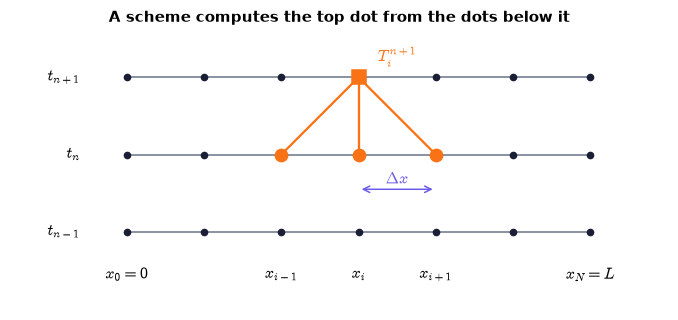

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 2.8))                # one panel
spacetime_grid(ax)                                        # three time levels, the nodes, the FTCS stencil highlighted
ax.set_title("A scheme computes the top dot from the dots below it", fontsize=10)   # the message
plt.show()                                                # display the figure

**What you see.** A lattice of points in $(x,t)$: three horizontal rows (time levels $t_{n-1}$, $t_n$, $t_{n+1}$), dots at the nodes $x_0=0\dots x_N=L$, and four dots highlighted in orange — three at $t_n$ feeding one at $t_{n+1}$.

**How to read it.** A finite-difference scheme is a rule that computes the new value (top) from old values (below); the orange stencil is FTCS (C02).

**What would change if…** …$\Delta x$ were halved: twice as many dots per row and (C04) four times as many rows for FTCS, because its stable time step shrinks like $\Delta x^2$.

> 🔁 **Recap — R02 · Taylor series at the neighbours** (Ch. 1 P26, Ch. 3 P98). Ch. 1 (P26) and Ch. 3 (P98) expanded a smooth function about a point. At the grid neighbours $x_{i\pm1}=x_i\pm\Delta x$: $T^n_{i\pm1}=T^n_i\pm\Delta x\big[\tfrac{\partial T}{\partial x}\big]^n_i+\tfrac{\Delta x^2}{2}\big[\tfrac{\partial^2T}{\partial x^2}\big]^n_i\pm\tfrac{\Delta x^3}{6}\big[\tfrac{\partial^3T}{\partial x^3}\big]^n_i+\tfrac{\Delta x^4}{24}\big[\tfrac{\partial^4T}{\partial x^4}\big]^n_i+O(\Delta x^5)$ *(10.4)–(10.5)*: the signs alternate only on the odd powers. These two lines are the starting line of D01.

> 🔁 **Recap — R03 · The centred second derivative** (Ch. 1 §1.5, Ch. 6 §6.7). Ch. 1's FTCS and Ch. 6's 5-point Laplacian used $\big[\tfrac{\partial^2T}{\partial x^2}\big]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)$ *(10.7)*. D01 step 8 re-derives it, with its error term.

### 🧩 Finite-difference stencils and their order of accuracy `C01`

*The question:* A computer only knows $T$ at grid points. How do we get a derivative from those numbers — and how wrong is the answer?

*In one line:* $\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2)$ *(10.6)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used throughout C01

- **first-order Taylor expansion** — f(x + h) = f(x) + h f′(x) + h²/2 f″(x) + … — a smooth function near a point is a polynomial in the step (Ch. 1 P26).
- **finite differences and FTCS for diffusion** — replace a derivative by a difference of neighbouring grid values; FTCS stepped the diffusion equation in Ch. 1 (P21).
- **limits and orders of smallness** — a term with a factor h → 0 vanishes relative to one without it (Ch. 2 P68); here we keep and measure it instead of dropping it.
- **np.linalg.solve** — `np.linalg.solve(A, b)` returns x with A x = b for a square, invertible A (Ch. 1 P57).
- **fractions and exact rational weights (sympy Rational)** — exact fractions instead of floats — `fractions.Fraction` in Ch. 1 (P60), `sympy.Rational` here, so 1/2 stays 1/2.
- **power laws and log–log slopes, observed order** — a straight line of slope s on log–log axes is a power law y ∝ x^s; the slope of log(error) against log(h) is the observed order (Ch. 1 P13).
- **diffusion spreading s² = s₀² + 2Dt** — a diffusing Gaussian's variance grows by 2D per unit time; diffusion needs a time ~L²/D to cross L (Ch. 8 P185).
- **numpy arrays and slicing of neighbours** — `T[2:] - T[:-2]` subtracts every left neighbour from every right neighbour at once — no loop (Ch. 2 P77).
- **np.linspace and np.logspace** — evenly spaced samples, or evenly spaced on a logarithmic axis (Ch. 1 P06).
- **matplotlib figures, log axes** — `fig, ax = plt.subplots()`, `ax.loglog(...)`, labels with units (Ch. 1 P01).
- **f-strings** — `f"{x:.3g}"` prints a value with 3 significant figures (Ch. 1 P04).
- **Python dictionaries (returned results)** — `r['order']`: fluidpy returns several named results in a dict (Ch. 1 P23).
- **functions as arguments and lambda** — `lambda x: np.sin(x)` is a one-line function passed to another function (Ch. 1 P29).
- **assert np.allclose** — stops with an error if two results differ beyond a tolerance — our proof that a from-scratch version matches the library (Ch. 1 P15).
- **slider_figure** — a plotly figure whose curves follow a slider; every slider position is computed in advance, so it works on the web page (Ch. 1 P17).
- **show_viz** — `show_viz('ch10', slug)` embeds an interactive explainer in the notebook (Ch. 1 P18).
- **partial derivative** — ∂T/∂x is the rate of change in x with t held fixed (Ch. 1 P25).

#### The problem in plain words

A string of thermometers hangs in a lake every 10 cm. You want the temperature gradient at one of them — the heat flux depends on it. You
have three readings: the thermometer and its two neighbours. The gradient could be "right minus me", "me minus left" or "right minus left
over twice the spacing". All three look reasonable; which is best, and how does the error shrink if you hang the thermometers twice as
close? A climate model asks the same question every time step for every one of its millions of grid boxes (about 25 km apart in a modern
global atmosphere model).

#### The idea

```
T(x_i+Δx) = T + Δx T′ + Δx²/2 T″ + Δx³/6 T‴ + …     ← Taylor at the right neighbour
T(x_i−Δx) = T − Δx T′ + Δx²/2 T″ − Δx³/6 T‴ + …     ← Taylor at the left neighbour
───────────────────────────────────────────────
subtract:  T_{i+1} − T_{i−1} = 2Δx T′ + 0 + Δx³/3 T‴ + …   the T″ terms CANCEL
÷ 2Δx:     (T_{i+1} − T_{i−1})/(2Δx) = T′ + Δx²/6 T‴ + …    first survivor ∝ Δx²  ⇒ second order
```

A stencil is a weighted sum of Taylor series. Choose the weights so the low terms cancel; **the first term that survives is the error**, and its power of $\Delta x$ is the order.

> 📎 **Primer — big-O notation and the order of accuracy.** `P221` · $O(\Delta x^2)$ means "a quantity no bigger than a constant times $\Delta x^2$ when $\Delta x$ is small" — it shrinks by 4 when $\Delta x$ halves.
A stencil is *p-th order accurate* when its error is $O(\Delta x^p)$. Unlike the "orders of smallness" of Ch. 2 (P68), where small terms were
*dropped*, here the leftover is *kept* and measured: it is the price of the approximation.

In [5]:
import numpy as np   # arrays and maths
for h in (0.1, 0.05, 0.025):                                     # halve the spacing twice
    err = (np.sin(1 + h) - np.sin(1 - h))/(2*h) - np.cos(1)      # centred difference minus the exact slope
    print(h, err, err/h**2)                                      # err/h^2 stays about -0.090: the error is O(h^2)

0.1 -0.0009000536983797547 -0.09000536983797545
0.05 -0.00022509782170754278 -0.0900391286830171
0.025 -5.627973142496856e-05 -0.09004757027994968


📝 **Note.** **N05 [B]** **The model problem** used from here to C05: $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2}$, $0\le x\le L$
*(10.1)* — $T$ carried by a constant current $u$ [m/s] and spread with diffusivity $D$ [m²/s]. Its exact solution for a Gaussian start is a
Gaussian that travels at $u$ and widens like $s(t)^2=s_0^2+2Dt$ (Ch. 8's diffusion spreading): our test field, `FD.advected_gaussian`.

$$ \frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L \qquad \text{(10.1)} $$

In [6]:
x = np.linspace(0, 1, 201)                                # 201 nodes on [0, 1] m
T0 = FD.advected_gaussian(x, 0.0, 0.5, 0.01)              # exact solution of (10.1) at t = 0 (u = 0.5 m/s, D = 0.01 m²/s)
T1 = FD.advected_gaussian(x, 0.4, 0.5, 0.01)              # ... and at t = 0.4 s
print(f"peak: x = {x[np.argmax(T0)]:.2f} m, height {T0.max():.3f}  ->  x = {x[np.argmax(T1)]:.2f} m, height {T1.max():.3f}")   # show the numbers computed above
print(f"predicted height s0/s = {0.05/np.sqrt(0.05**2 + 2*0.01*0.4):.3f}")   # s^2 = s0^2 + 2 D t with s0 = 0.05 m

peak: x = 0.30 m, height 1.000  ->  x = 0.50 m, height 0.488
predicted height s0/s = 0.488


**What does the code above do?**

1. `advected_gaussian(x, t, u, D)` is the exact solution of $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2}$ *(10.1)* for a Gaussian of width $s_0=0.05$ m starting at $x_0=0.3$ m (periodic images on $[0,1)$).
2. After 0.4 s the peak has moved $u t=0.2$ m and its height has dropped to $s_0/s=0.05/\sqrt{0.0025+0.008}=0.488$ — the second printed line checks it.

#### 🧮 Derivation — Stencils and their errors: forward, backward and centred $\big[\frac{\partial T}{\partial x}\big]_i$ and the centred $\big[\frac{\partial^2T}{\partial x^2}\big]_i$ from the Taylor series `D01` (Eq. 10.6: $\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2)$)

**What we want to show.** Find how to compute a slope and a curvature from grid values, and exactly how wrong each formula is.

**Assumptions.** T has four bounded derivatives near $x_i$ (used in step 1); uniform spacing Δx (steps 5, 7).

**The plan.**

1. Solve one series for $T_x$ (forward and backward).
2. Subtract the two series: the even terms cancel (centred).
3. Add them: the odd terms cancel (second derivative).
4. Read the power of Δx of the first term left over.

**Tools we use** (each explained before this point): Taylor series (R02; Ch. 1 P26) · big-O notation and the order of accuracy (primer P221).

**We start from**

$$ \begin{array}{l}\text{The Taylor series at the two neighbours,} \\ T^n_{i+1}=T^n_i+\Delta x\,T_x+\frac{\Delta x^2}2T_{xx}+\frac{\Delta x^3}6T_{xxx}+\frac{\Delta x^4}{24}T_{xxxx}+O(\Delta x^5)\ \text{(10.4) and} \\ T^n_{i-1}=T^n_i-\Delta x\,T_x+\frac{\Delta x^2}2T_{xx}-\frac{\Delta x^3}6T_{xxx}+\frac{\Delta x^4}{24} T_{xxxx}+O(\Delta x^5)\ \text{(10.5), all derivatives at}\ (x_i,t_n)\end{array} $$

*In words:* what the neighbours know about the point.

---

**Step 1 of 9 — Start from the right neighbour.**

$$ T_{i+1}=T_i+\Delta x\,T_x+\frac{\Delta x^2}2T_{xx}+\frac{\Delta x^3}6T_{xxx}+O(\Delta x^4) $$

- *Why we can do this:* Taylor's theorem about $x_i$ (R02), valid because T is smooth; we keep enough terms to see the first error of every stencil.
- *In words:* the value next door is the value here plus slope, curvature and more, each times a power of Δx.

---

**Step 2 of 9 — Solve for the slope.**

$$ T_x=\frac{T_{i+1}-T_i}{\Delta x}-\frac{\Delta x}2T_{xx}-\frac{\Delta x^2}6T_{xxx}+O(\Delta x^3) $$

- *Why we can do this:* Subtract $T_i$ from both sides and divide by Δx ≠ 0 — plain algebra; we want $T_x$ alone.
- *In words:* the slope is 'right minus here over Δx' minus a correction.

---

**Step 3 of 9 — Name the forward difference and its error.**

$$ \frac{T_{i+1}-T_i}{\Delta x}-T_x=+\frac{\Delta x}2T_{xx}+O(\Delta x^2) $$

- *Why we can do this:* Rearrange step 2 as stencil minus exact; the first surviving term is proportional to Δx¹, so the forward difference is first order (P221) — the O(Δx) of (10.6), $\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2)$.
- *In words:* halve Δx and the forward error halves.

---

**Step 4 of 9 — Repeat with the left neighbour (10.5).**

$$ \frac{T_i-T_{i-1}}{\Delta x}-T_x=-\frac{\Delta x}2T_{xx}+O(\Delta x^2) $$

- *Why we can do this:* The same two moves on (10.5), $T^n_{i-1}=T^n_i-\Delta x\Big[\frac{\partial T}{\partial x}\Big]^n_i+\frac{\Delta x^2}{2}\Big[\frac{\partial^2T}{\partial x^2}\Big]^n_i-\frac{\Delta x^3}{6}\Big[\frac{\partial^3T}{\partial x^3}\Big]^n_i+\frac{\Delta x^4}{24}\Big[\frac{\partial^4T}{\partial x^4}\Big]^n_i+O(\Delta x^5)$, where the odd powers carry minus signs; the error has the opposite sign but the same size.
- *In words:* the backward difference is also first order.

---

**Step 5 of 9 — Subtract (10.5) from (10.4).**

$$ T_{i+1}-T_{i-1}=2\Delta x\,T_x+\frac{\Delta x^3}3T_{xxx}+O(\Delta x^5) $$

- *Why we can do this:* Terms with even powers (T, Δx²T_xx, Δx⁴T_xxxx) have the same sign in both series and cancel; odd ones double. The curvature term is gone.
- *In words:* 'right minus left' contains twice the slope and nothing of the curvature.

---

**Step 6 of 9 — Divide by 2Δx.**

$$ \frac{T_{i+1}-T_{i-1}}{2\Delta x}-T_x=\frac{\Delta x^2}6T_{xxx}+O(\Delta x^4) $$

- *Why we can do this:* Isolates the stencil minus the slope; the first survivor is proportional to Δx², so the centred difference is second order — the third line of (10.6), $\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2)$.
- *In words:* halve Δx and the centred error drops by four.

---

**Step 7 of 9 — Add (10.4) and (10.5).**

$$ T_{i+1}+T_{i-1}=2T_i+\Delta x^2T_{xx}+\frac{\Delta x^4}{12}T_{xxxx}+O(\Delta x^6) $$

- *Why we can do this:* Now the odd powers cancel (the Δx⁵ terms too, being odd), and even ones double: 2 × Δx⁴/24 = Δx⁴/12.
- *In words:* the sum of the neighbours sees the curvature, not the slope.

---

**Step 8 of 9 — Solve for the curvature.**

$$ \frac{T_{i+1}-2T_i+T_{i-1}}{\Delta x^2}-T_{xx}=\frac{\Delta x^2}{12}T_{xxxx}+O(\Delta x^4) $$

- *Why we can do this:* Subtract 2T_i and divide by Δx²; the leftover starts at Δx² (dividing O(Δx⁶) by Δx² leaves O(Δx⁴)) — second order, (10.7), $\left[\tfrac{\partial^2T}{\partial x^2}\right]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)$.
- *In words:* the three-point curvature formula is second order.

---

**Step 9 of 9 — Collect the orders.**

$$ \big[T_x\big]_i=\frac{T_{i+1}-T_i}{\Delta x}+O(\Delta x)=\frac{T_i-T_{i-1}}{\Delta x}+O(\Delta x)= \frac{T_{i+1}-T_{i-1}}{2\Delta x}+O(\Delta x^2) $$

- *Why we can do this:* Steps 3, 4 and 6 written as the book writes (10.6), with the error terms folded into O(·); (10.7), $\left[\tfrac{\partial^2T}{\partial x^2}\right]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)$ is step 8.
- *In words:* one-sided slopes are first order, centred ones second.

---

**Result**

$$ \begin{array}{l}\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2)\ \text{(10.6)} \\ \left[\tfrac{\partial^2T}{\partial x^2}\right]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)\ \text{(10.7)} \\ \text{leading errors: forward }+\tfrac{\Delta x}{2}T_{xx},\ \text{backward }-\tfrac{\Delta x}{2}T_{xx},\ \text{centred }\tfrac{\Delta x^2}{6}T_{xxx},\ \text{second derivative }\tfrac{\Delta x^2}{12}T_{xxxx}\end{array} $$

*In words:* the order is the power of Δx of the first Taylor term a stencil fails to cancel.

**What it means.** Every scheme of the chapter is assembled from these stencils; their orders set the scheme's order (C03). Fails where T is not smooth (a shock, a kink) — there no stencil beats first order.

**Check it.** Units: each stencil has the units of the derivative it approximates (T/m or T/m²) ✓. Numbers (sin at 1, Δx = 0.1): forward error −0.0429 vs predicted (0.05)(−0.841) = −0.0421; centred −9.001e-4 vs (0.01/6)(−0.5403) = −9.005e-4 ✓. `FD.stencil_taylor_coefficients` lists the same coefficients (1/2, 1/6, 1/12).

> ⚠️ **Common confusion (traps in `D01`):** Getting the sign of the forward error backwards (it depends on whether you write stencil − exact or exact − stencil); claiming O(Δx³) for (10.7), $\left[\tfrac{\partial^2T}{\partial x^2}\right]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)$ because the series was cut at O(Δx⁵) — the Δx⁴ term is kept, so the error is O(Δx²); forgetting the 2 in 2Δx.

#### ✏️ Tiny example: the slope of sin at x = 1 with h = 0.1

1. Exact slope $\cos1=0.540302$.
2. Forward: $(\sin1.1-\sin1)/0.1=(0.891207-0.841471)/0.1=0.497364$; error $-0.04294$. The leading term of D01 predicts
   $\frac h2T''=\frac{0.1}{2}(-0.841471)=-0.04207$ (the small rest is the next term, $\frac{h^2}6T'''$).
3. Centred: $(\sin1.1-\sin0.9)/0.2=(0.891207-0.783327)/0.2=0.539402$; error $-0.000900$, predicted $\frac{h^2}6T'''=\frac{0.01}6(-\cos1)=-0.000900$ ✓.
4. Halve $h$ to 0.05: forward error $-0.0213$ (÷ 2.02), centred $-0.000225$ (÷ 4.00) — first and second order, as the Taylor bookkeeping said.

In [7]:
stencils = (("forward", [0, 1], 1), ("backward", [-1, 0], 1), ("central", [-1, 0, 1], 1),
            ("central2", [-1, 0, 1], 2), ("onesided2", [0, 1, 2], 1))       # (name, offsets, which derivative m)
hs = [0.1, 0.05, 0.025, 0.0125]                                            # four spacings, each half the last
for kind, offs, m in stencils:   # repeat the indented lines for each item listed
    w = FD.fd_weights(offs, m)                                             # exact Taylor-matching weights (fractions)
    p = FD.stencil_taylor_coefficients(kind, m)["order"]                   # the order the Taylor table predicts
    errs = [abs(FD.stencil_error("sin", 1.0, h, kind, m)) for h in hs]     # |stencil - exact| on sin at x = 1
    print(f"{kind:9s} weights {str(w):18s} predicted order {p}   observed {observed_order(hs, errs):.2f}   "   # show the numbers computed above
          f"errors {errs[0]:.2e} -> {errs[-1]:.2e}")

forward   weights [-1, 1]            predicted order 1   observed 1.01   errors 4.29e-02 -> 5.27e-03
backward  weights [-1, 1]            predicted order 1   observed 0.99   errors 4.11e-02 -> 5.25e-03
central   weights [-1/2, 0, 1/2]     predicted order 2   observed 2.00   errors 9.00e-04 -> 1.41e-05
central2  weights [1, -2, 1]         predicted order 2   observed 2.00   errors 7.01e-04 -> 1.10e-05
onesided2 weights [-3/2, 2, -1/2]    predicted order 2   observed 1.95   errors 1.58e-03 -> 2.77e-05


**What does the code above do?**

1. `fd_weights(offsets, m)` solves the Taylor-matching equations exactly (fractions): the weights $w_k$ with $f^{(m)}(x_0)\approx h^{-m}\sum_kw_kf(x_0+s_kh)$.
2. `stencil_taylor_coefficients(kind, m)` lists which Taylor terms survive; `order` is the power of $h$ of the first survivor.
3. `stencil_error` applies each stencil to $\sin$ at $x=1$ and subtracts the exact derivative.
4. `observed_order(h, err)` is the least-squares slope of $\log$(error) against $\log h$ (P13). Forward and backward come out near 1;
   centred, second-derivative and the one-sided three-point stencil near 2 (the last approaches 2 from below on these spacings).

In [8]:
# from scratch: the Taylor-matching (Vandermonde) system solved with np.linalg.solve
from math import factorial                                     # k! for the Taylor coefficients
for offs in ([-1, 0, 1], [0, 1, 2]):                           # a centred and a one-sided three-point stencil
    s = np.array(offs, float)                                  # the offsets s_j in units of h
    A = np.array([[sj**k/factorial(k) for sj in s] for k in range(3)])   # row k: s_j^k / k!  (Taylor term k)
    rhs = np.array([0.0, 1.0, 0.0])                            # keep only the first derivative (k = 1), cancel k = 0 and 2
    w_mine = np.linalg.solve(A, rhs)                           # the weights that do exactly that
    w_lib = [float(c) for c in FD.fd_weights(offs, 1)]         # the library's exact fractions, as floats
    print(offs, w_mine)   # show the numbers computed above
    assert np.allclose(w_mine, w_lib)                          # same numbers: the library does this Vandermonde solve
x = np.linspace(0, 2, 41); dx = x[1] - x[0]; f = np.sin(x)     # a sampled function on a uniform grid
mine = {"forward": (f[2:] - f[1:-1])/dx, "backward": (f[1:-1] - f[:-2])/dx, "central": (f[2:] - f[:-2])/(2*dx)}   # by slicing
for kind, d in mine.items():   # repeat the indented lines for each item listed
    lib = FD.fd_derivative(f, dx, kind)                        # the library's stencil on the same samples
    assert np.allclose(d, lib[1:-1])                           # interior nodes agree (the ends are NaN where a stencil leaves the grid)
print("stencils by slicing agree with FD.fd_derivative")   # show the numbers computed above

[-1, 0, 1] [-0.5  0.   0.5]
[0, 1, 2] [-1.5  2.  -0.5]
stencils by slicing agree with FD.fd_derivative


**What does the code above do?**

1. For each set of offsets the $3\times3$ matrix has row $k$ equal to $s_j^k/k!$ — the coefficient of $h^kf^{(k)}$ in the Taylor series of $f(x_0+s_jh)$.
2. Asking for "1 × the first derivative, 0 × the value, 0 × the second derivative" is the right-hand side $(0,1,0)$; `np.linalg.solve` (P57) returns
   the weights: $(-\tfrac12,0,\tfrac12)$ for the centred and $(-\tfrac32,2,-\tfrac12)$ for the one-sided stencil — the same as `FD.fd_weights`.
3. The three first-derivative stencils written with array slices (P77: `f[2:] - f[:-2]` is "right neighbour minus left neighbour" at every interior
   node at once) agree with `FD.fd_derivative`.

📝 **Note.** **N07 [B]** **Time differences:** the same three moves in $t$ give a forward difference $\frac{T^{n+1}_i-T^n_i}{\Delta t}+O(\Delta t)$, a
backward one $\frac{T^n_i-T^{n-1}_i}{\Delta t}+O(\Delta t)$ and a centred one $\frac{T^{n+1}_i-T^{n-1}_i}{2\Delta t}+O(\Delta t^2)$ ("leapfrog" — the time step
of many older weather models). The cell measures them on $y'=-y$.

$$ \left[\tfrac{\partial T}{\partial t}\right]^n_i=\tfrac{T^{n+1}_i-T^n_i}{\Delta t}+O(\Delta t)=\tfrac{T^n_i-T^{n-1}_i}{\Delta t}+O(\Delta t)=\tfrac{T^{n+1}_i-T^{n-1}_i}{2\Delta t}+O(\Delta t^2) \qquad \text{(10.8)} $$

In [9]:
for s in ("forward", "backward", "leapfrog"):                  # the three time differences of (10.8)
    print(f"{s:9s} observed order on y' = -y: {FD.ode_scheme_order(s):.2f}")   # slope of log error vs log dt

forward   observed order on y' = -y: 1.01
backward  observed order on y' = -y: 0.99
leapfrog  observed order on y' = -y: 2.06


**What does the code above do?**

`ode_scheme_order(s)` integrates $y'=-y$ to $t=1$ with $\Delta t=1/20\dots1/160$ using the named time difference and returns the log–log slope
of the error: close to 1, 1 and 2, the orders of the three lines of (10.8), $\left[\tfrac{\partial T}{\partial t}\right]^n_i=\tfrac{T^{n+1}_i-T^n_i}{\Delta t}+O(\Delta t)=\tfrac{T^n_i-T^{n-1}_i}{\Delta t}+O(\Delta t)=\tfrac{T^{n+1}_i-T^{n-1}_i}{2\Delta t}+O(\Delta t^2)$.

> 📎 **Primer — floating-point round-off and machine epsilon.** `P222` · A computer stores about 16 significant digits (double precision): `np.finfo(float).eps` = 2.2e-16 is the gap after 1.0. A difference quotient
subtracts two nearly equal numbers and divides by $h$, so its round-off error is about $\varepsilon\,\lvert f\rvert/h$ — it *grows* as $h$ shrinks.
Truncation falls like $h^p$, round-off rises like $1/h$: the total error has a floor, near $h\approx\varepsilon^{1/2}$ for a first-order and
$\varepsilon^{1/3}$ for a second-order stencil. Single precision (float32, $\varepsilon\approx1.2\times10^{-7}$) hits the floor much sooner.

In [10]:
import numpy as np   # arrays and maths
print(np.finfo(float).eps, np.finfo(np.float32).eps)          # 2.2e-16 and 1.2e-07
for h in (1e-4, 1e-8, 1e-12):                                 # shrink h far too much
    print(h, (np.sin(1 + h) - np.sin(1))/h - np.cos(1))       # the error falls, then RISES again

2.220446049250313e-16 1.1920929e-07
0.0001 -4.207444951864758e-05
1e-08 -2.9698852266335507e-09
1e-12 4.3240216923923214e-05


forward: best h ≈ 4.7e-09, smallest error ≈ 1.1e-09
central: best h ≈ 4.7e-06, smallest error ≈ 3.9e-13


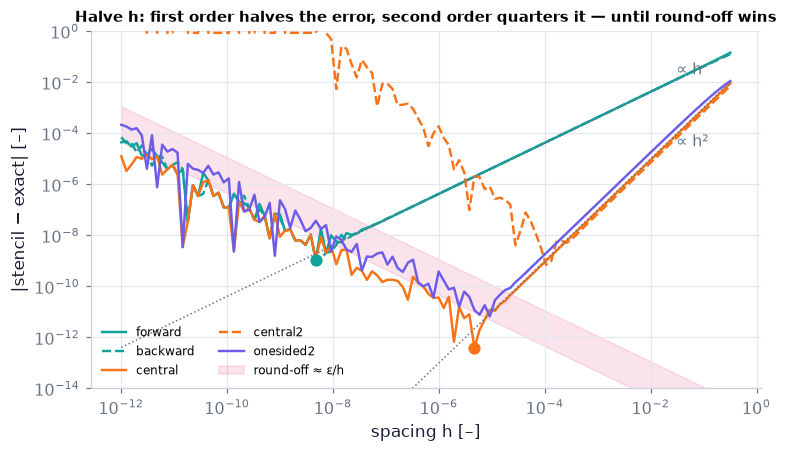

In [11]:
h = np.logspace(-12, -0.5, 120)                                # spacings from 1e-12 to 0.3
styles = {"forward": (C_UP, "-"), "backward": (C_UP, "--"), "central": (C_FT, "-"),
          "central2": (C_FT, "--"), "onesided2": (C_MC, "-")}  # colour and dash per stencil
m_of = {"central2": 2}                                         # the second-derivative stencil approximates f''
fig, ax = plt.subplots(figsize=(7, 4))   # the figure and its panels
for kind, (col, ls) in styles.items():                         # |error| of each stencil against h
    e = np.abs([FD.stencil_error("sin", 1.0, hh, kind, m_of.get(kind, 1)) for hh in h])
    ax.loglog(h, np.maximum(e, 1e-17), ls, color=col, lw=1.6, label=kind)   # curve(s) on logarithmic axes
eps = np.finfo(float).eps                                      # machine epsilon 2.2e-16
ax.fill_between(h, eps/h*0.2, eps/h*5, color=C_BAD, alpha=0.12, label="round-off ≈ ε/h")   # the round-off band
ax.loglog(h, 0.4*h, ":", color=C_EX, lw=1); ax.loglog(h, 0.1*h**2, ":", color=C_EX, lw=1)   # slope-1 and slope-2 guides
ax.text(3e-2, 2e-2, "∝ h", color=C_EX); ax.text(3e-2, 3e-5, "∝ h²", color=C_EX)   # label the guides
for kind in ("forward", "central"):                            # mark the best spacing of two stencils
    e = np.abs([FD.stencil_error("sin", 1.0, hh, kind) for hh in h])
    k = np.argmin(e); ax.plot(h[k], e[k], "o", color=styles[kind][0], ms=7)   # draw the curve(s)
    print(f"{kind}: best h ≈ {h[k]:.1e}, smallest error ≈ {e[k]:.1e}")   # show the numbers computed above
ax.set_ylim(1e-14, 1); ax.set_xlabel("spacing h [–]"); ax.set_ylabel("|stencil − exact| [–]")   # axis labels, with units where the quantity has them
ax.set_title("Halve h: first order halves the error, second order quarters it — until round-off wins", fontsize=10)   # the panel's title: what this panel shows
ax.legend(fontsize=8, ncol=2, frameon=False, loc="lower left")   # legend: one entry per curve
savefig(fig, "ch10", "nb_c01_stencil_orders"); plt.show()     # keep a copy in outputs/ch10 and display

**What you see.** Straight lines of slope 1 (teal, forward and backward) and slope 2 (orange, centred; purple, one-sided three-point) on the right, and a V-shaped floor on the left where every curve turns up again inside the rose band.

**How to read it.** The slope is the order (the dashed second-derivative stencil divides by $h^2$, so its round-off grows like $\varepsilon/h^2$ and its floor sits at a larger $h$); the lowest point of each curve is its best spacing — the cell prints it (a few times $10^{-9}$ for forward, a few times $10^{-6}$ for centred). Left of the minimum, round-off ($\approx\varepsilon/h$) dominates and refining makes things worse.

**What would change if…** …we computed in float32: $\varepsilon$ rises to $1.2\times10^{-7}$ and, by P222's rule, the floor rises and moves right — forward about $10^{-4}$ at $h\approx\varepsilon^{1/2}\approx3\times10^{-4}$, centred about $10^{-5}$ at $h\approx\varepsilon^{1/3}\approx5\times10^{-3}$ (estimates) — the reason §10.5 insists on double precision (N90).

In [12]:
h_vals = np.logspace(np.log10(0.2), -3, 25 if not FAST else 12)   # slider positions for h
h_line = np.logspace(-3.2, np.log10(0.3), 120)                     # the static curves
def f1(hh):                                                        # curves for one slider value h
    out = {}
    for kind in ("forward", "backward", "central", "onesided2"):   # four first-derivative stencils
        out[kind] = (h_line, np.abs([FD.stencil_error("sin", 1.0, x_, kind) for x_ in h_line]))
    e_now = abs(FD.stencil_error("sin", 1.0, hh, "central"))       # the central stencil at the current h
    out["central at this h"] = ([hh], [e_now])                     # one marker that moves with the slider
    return out   # the values for this call
fig = slider_figure(f1, "h", h_vals, xlabel="spacing h", ylabel="|error|",
                    title="Drag h: the central error drops 4× per halving, the forward one 2×",
                    modes={"central at this h": "markers"})        # one figure; every position precomputed (P17)
fig.update_xaxes(type="log", range=[-3.2, np.log10(0.3)]); fig.update_yaxes(type="log", range=[-8, 0])   # log axes, fixed
fig.show()   # display the interactive figure

**What does the code above do?**

The page version of the explainer's error view: each slider position shows the same four error curves (log–log) and moves one marker along the
centred-difference curve. Read the marker's value in the hover label at $h$ and at $h/2$: the ratio is 4.

#### 🎮 Interactive: What does 'second-order accurate' really mean?

**Why interactive rather than a static figure:** Dragging $h$ on a log slider moves one dot along the error curve while the stencil nodes and their secant close in on $x_0$, and the Taylor-term bars show which terms cancel — the order becomes something you see happen, not a label.

**What to try:**
- Pick 'forward' and halve h twice: watch the error halve each time; switch to 'central' and watch it quarter.
- Drag h below 10⁻⁶: the status turns to 'round-off dominated' — the dot climbs back up.
- Open the FTCS mode: the three truncation terms of (10.17), $E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)$ appear as bars; set $\Delta t$ so that $D\Delta t/\Delta x^2=1/6$ and watch the time and diffusion terms cancel.

In [13]:
show_viz("ch10", "fd_stencil_order")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/fd_stencil_order]

**What would change if…** …we used the stencils on a PDE instead of a known function? The error no longer shows up in one derivative but in the whole update rule —
C02 builds that rule for (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$, and C03 finds its leftover.

### 🧩 The explicit FTCS scheme (with BTCS as its implicit twin) `C02`

*The question:* How do we march a temperature carried and spread by a current forward in time, one grid point at a time?

*In one line:* $T^{n+1}_i\approx T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})$ *(10.10)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **explicit stepping and its limit** — an explicit rule computes the new state from the old one by a formula; it is cheap but its time step is limited (Ch. 1 P30).
- **boundary conditions** — the values (Dirichlet) or slopes (Neumann) prescribed at the ends of the domain (Ch. 1 P20).
- **Crank–Nicolson and solve_banded** — an implicit step needs one tridiagonal solve; `scipy.linalg.solve_banded` does it in O(N) operations (Ch. 8 P193).
- **implicit time stepping** — evaluate the space terms at the new time level and solve for it: stable for large steps (Ch. 8 P192).

#### The problem in plain words

A factory releases a puff of dye into a river flowing at 0.1 m/s. Downstream the puff drifts with the current and slowly spreads. You know
the concentration along the river now, at points 10 cm apart, and want it 0.2 s later — then 0.2 s after that, and so on. The simplest rule
computes each new value from the three old values around it: **f**orward in **t**ime, **c**entred in **s**pace (FTCS).

#### The idea

```
t_{n+1}              ● T_i^{n+1}          = T_i − α(T_{i+1} − T_{i−1}) + β(T_{i+1} − 2T_i + T_{i−1})
                   ╱ │ ╲
t_n          ●─────●─────●                α = uΔt/(2Δx)  (how far the current moves in Δt, per 2 cells)
          T_{i−1}  T_i  T_{i+1}            β = DΔt/Δx²    (how far diffusion reaches in Δt, per cell²)
```

Every new value is a weighted average of three old ones. With $u=0$ this is Ch. 1's FTCS with $r=\beta$.

#### 🧮 Derivation — The explicit FTCS update $T^{n+1}_i=T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})$ with $\alpha=u\frac{\Delta t}{2\Delta x}$, $\beta=D\frac{\Delta t}{\Delta x^2}$ `D02` (Eq. 10.10: $T^{n+1}_i\approx T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})$)

**What we want to show.** Turn the PDE (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ into a rule that computes the new temperature at each point from the old ones.

**Assumptions.** u and D constant (step 5 names constant coefficients); a uniform grid.

**The plan.**

1. Ask the PDE at one grid point.
2. Replace each derivative by a stencil.
3. Solve for the unknown new value.

**Tools we use** (each explained before this point): The time difference (10.8), $\left[\tfrac{\partial T}{\partial t}\right]^n_i=\tfrac{T^{n+1}_i-T^n_i}{\Delta t}+O(\Delta t)=\tfrac{T^n_i-T^{n-1}_i}{\Delta t}+O(\Delta t)=\tfrac{T^{n+1}_i-T^{n-1}_i}{2\Delta t}+O(\Delta t^2)$ (N07) · the stencils (10.6)–(10.7), $\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2),\ \left[\tfrac{\partial^2T}{\partial x^2}\right]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)$ (D01).

**We start from**

$$ \frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2}\ \text{(10.1)} $$

*In words:* change in time = carried in by the current + spread by diffusion.

---

**Step 1 of 6 — Evaluate (10.1) at a grid point.**

$$ \big[T_t\big]^n_i+u\big[T_x\big]^n_i=D\big[T_{xx}\big]^n_i $$

- *Why we can do this:* A discretisation demands the equation only at $(x_i,t_n)$; we choose the old time level so every space derivative uses known values.
- *In words:* the PDE, asked at one point of the grid.

---

**Step 2 of 6 — Forward difference in time.**

$$ \big[T_t\big]^n_i=\frac{T^{n+1}_i-T^n_i}{\Delta t}+O(\Delta t) $$

- *Why we can do this:* The first line of (10.8), $\left[\tfrac{\partial T}{\partial t}\right]^n_i=\tfrac{T^{n+1}_i-T^n_i}{\Delta t}+O(\Delta t)=\tfrac{T^n_i-T^{n-1}_i}{\Delta t}+O(\Delta t)=\tfrac{T^{n+1}_i-T^{n-1}_i}{2\Delta t}+O(\Delta t^2)$, derived like D01 step 3 but in t; it is the only choice that puts a single unknown, $T^{n+1}_i$, in each equation.
- *In words:* the rate of change is 'next minus now over Δt'.

---

**Step 3 of 6 — Centred differences in space.**

$$ \frac{T^{n+1}_i-T^n_i}{\Delta t}+u\frac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}=D\frac{T^n_{i+1}-2T^n_i+ T^n_{i-1}}{\Delta x^2}+O(\Delta t,\Delta x^2)\ \text{(10.9)} $$

- *Why we can do this:* Substitute (10.6), $\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2)$ (centred) and (10.7), $\left[\tfrac{\partial^2T}{\partial x^2}\right]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)$; their errors, O(Δx²), join the O(Δt) of step 2.
- *In words:* forward in time, centred in space — FTCS.

---

**Step 4 of 6 — Multiply through by Δt.**

$$ T^{n+1}_i-T^n_i=-\frac{u\Delta t}{2\Delta x}(T^n_{i+1}-T^n_{i-1})+\frac{D\Delta t}{\Delta x^2}(T^n_{i+1}- 2T^n_i+T^n_{i-1})+O(\Delta t^2,\Delta t\Delta x^2) $$

- *Why we can do this:* Clears the fraction on the left and moves the convective term right; the remainder is multiplied by Δt too.
- *In words:* the change over one step, written out.

---

**Step 5 of 6 — Name the two numbers α, β.**

$$ \alpha=u\frac{\Delta t}{2\Delta x},\quad\beta=D\frac{\Delta t}{\Delta x^2}\ \text{(10.11)} $$

- *Why we can do this:* They are dimensionless and constant (u, D, Δx, Δt fixed); the 2 in α comes from the centred difference's 2Δx.
- *In words:* α measures how far the current moves in a step, β how far diffusion reaches.

---

**Step 6 of 6 — Drop the remainder, solve for the new value.**

$$ T^{n+1}_i\approx T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\ \text{(10.10)} $$

- *Why we can do this:* Discarding O(Δt², ΔtΔx²) turns '=' into '≈'; the new value appears only on the left, so each node is updated by a formula — an explicit scheme.
- *In words:* new value = old value, pushed by the current, smoothed by diffusion.

---

**Result**

$$ T^{n+1}_i\approx T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\ \text{(10.10)},\qquad \alpha=u\frac{\Delta t}{2\Delta x},\quad\beta=D\frac{\Delta t}{\Delta x^2}\ \text{(10.11)} $$

*In words:* each new value is a fixed weighted combination of three old ones.

**What it means.** The simplest scheme there is; C03 asks how close it is to (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ and C04 when it blows up.

**Check it.** α, β dimensionless: (m/s)(s)/m and (m²/s)(s)/m² ✓. The five-point example: (0.1, 0.2) gives [0, 0.1, 0.6, 0.3, 0], the sum stays 1 (the weights (α + β) + (1 − 2β) + (β − α) = 1). u = 0 recovers Ch. 1's FTCS with r = β.

> ⚠️ **Common confusion (traps in `D02`):** Writing α = uΔt/Δx (forgetting the 2 of the centred difference); keeping '=' after dropping the error; mixing time levels (a $T^{n+1}$ on the right would make the scheme implicit — that is BTCS, N08).

#### ✏️ Tiny example: one FTCS step on five points

$u=0.1$ m/s, $D=0.01$ m²/s, $\Delta x=0.1$ m, $\Delta t=0.2$ s.
1. $\alpha=u\Delta t/(2\Delta x)=0.1\times0.2/0.2=0.1$; $\beta=D\Delta t/\Delta x^2=0.01\times0.2/0.01=0.2$.
2. Start $T=[0,0,1,0,0]$ (a spike in the middle).
3. Middle: $T_2=1-0.1(0-0)+0.2(0-2+0)=0.6$.
4. Left neighbour: $T_1=0-0.1(1-0)+0.2(1-0+0)=0.1$.
5. Right neighbour: $T_3=0-0.1(0-1)+0.2(0-0+1)=0.3$.
6. New $T=[0,0.1,0.6,0.3,0]$: the sum is still 1 (nothing is lost), the peak dropped (diffusion) and the right side got more than the left
   (the current carries it right).

In [14]:
alpha, beta = FD.ftcs_coefficients(0.1, 0.01, 0.1, 0.2)       # (10.11): u = 0.1 m/s, D = 0.01 m²/s, dx = 0.1 m, dt = 0.2 s
T = np.array([0, 0, 1, 0, 0.0])                                # the spike of the tiny example
print(f"alpha = {alpha:.3f}, beta = {beta:.3f}, one step:", FD.transport_1d_step(T, alpha, beta, "ftcs", periodic=True))   # show the numbers computed above
x = np.linspace(0, 1, 101)[:-1]                                # 100 periodic nodes, dx = 0.01 m (no repeated end node)
u, D, dt = 0.5, 0.01, 0.0025                                   # beta = D dt / dx^2 = 0.25
run = FD.solve_transport_1d(FD.advected_gaussian(x, 0, u, D), x, u, D, dt, 80, "ftcs", periodic=True)   # 80 steps to t = 0.2 s
err = FD.error_norm(run["T"], FD.advected_gaussian(x, 0.2, u, D))   # rms error against the exact solution (10.14)
print(f"t = {run['t']:.2f} s, rms error = {err:.2e}")   # show the numbers computed above
assert err < 5e-3                                              # the scheme follows the exact solution closely

alpha = 0.100, beta = 0.200, one step: [0.  0.1 0.6 0.3 0. ]
t = 0.20 s, rms error = 1.95e-03


**What does the code above do?**

1. `ftcs_coefficients(u, D, dx, dt)` returns $\alpha=u\frac{\Delta t}{2\Delta x}$ and $\beta=D\frac{\Delta t}{\Delta x^2}$ *(10.11)*.
2. `transport_1d_step(..., "ftcs")` applies $T^{n+1}_i=T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})$ *(10.10)* once — the tiny example's $[0,0.1,0.6,0.3,0]$.
3. `solve_transport_1d` repeats the step 80 times on a periodic grid; `error_norm` is the rms of the error $e^n_i=T^n_i-T(x_i,t_n)$ *(10.14)* (P224 below explains the norms).

In [15]:
# from scratch: the FTCS update in one line with np.roll (periodic neighbours)
T = FD.advected_gaussian(x, 0, u, D)                           # the Gaussian of the cell above on the periodic grid
T_new = T - alpha*(np.roll(T, -1) - np.roll(T, 1)) + beta*(np.roll(T, -1) - 2*T + np.roll(T, 1))   # (10.10) with the tiny-example alpha, beta
assert np.allclose(T_new, FD.transport_1d_step(T, alpha, beta, "ftcs", periodic=True))   # the library does exactly this
xd = np.linspace(0, 1, 21); T0 = np.sin(np.pi*xd) + 0.3*xd     # u = 0: pure diffusion with fixed end values
dxd = xd[1] - xd[0]; dtd = 0.4*dxd**2/0.02                     # beta = r = 0.4 with D = 0.02 m²/s
mine = FD.solve_transport_1d(T0, xd, 0.0, 0.02, dtd, 60, "ftcs")["T"]   # FTCS of this chapter with u = 0
ch01 = DIF.ftcs_diffusion_1d(T0, 0.02, dxd, dtd, 60)[-1]       # Ch. 1's FTCS diffusion solver, same ends held fixed
print("max difference from Ch. 1's solver:", np.abs(mine - ch01).max())   # show the numbers computed above
assert np.allclose(mine, ch01, atol=1e-14)                     # u = 0 is Ch. 1's scheme with r = beta

max difference from Ch. 1's solver: 0.0


**What does the code above do?**

1. `np.roll(T, -1)` shifts the array one place to the left, so element $i$ holds $T_{i+1}$ (and the last wraps round to the first — a periodic grid);
   `np.roll(T, 1)` holds $T_{i-1}$. The one-line update is (10.10), $T^{n+1}_i\approx T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})$ for every node at once and matches `transport_1d_step`.
2. With $u=0$ the scheme is Ch. 1's FTCS for diffusion with $r=\beta$: `DIF.ftcs_diffusion_1d` (Ch. 1) and `FD.solve_transport_1d` agree to round-off.

> 📎 **Primer — ghost node for a Neumann boundary.** `P223` · At $x=L$ the book prescribes a slope, $\partial T/\partial x=q$ (10.2), not a value. Invent one extra point beyond the end, $T_{N+1}$, chosen so the
centred difference at the end gives the slope: $(T_{N+1}-T_{N-1})/(2\Delta x)=q$, i.e. $T_{N+1}=T_{N-1}+2\Delta x\,q$. The ordinary FTCS formula
then runs at the last node too and stays second order; $q=0$ is an insulated end.

In [16]:
import numpy as np   # arrays and maths
T, dx, q = np.array([0.0, 0.4, 0.7, 0.9]), 0.1, 0.5        # last value 0.9 at x = L; required slope 0.5
ghost = T[-2] + 2*dx*q                                      # T_{N+1} = T_{N-1} + 2 dx q = 0.7 + 0.1 = 0.8
print(ghost, (ghost - T[-2])/(2*dx))                        # 0.8 and the centred slope 0.5

0.7999999999999999 0.4999999999999999


📝 **Note.** **N06 [B]** **Boundary and initial conditions (10.2)–(10.3):** $T(0,t)=g$ (Dirichlet: the value is prescribed — a heater held at fixed
temperature) and $\frac{\partial T}{\partial x}(L,t)=q$ (Neumann: the gradient, i.e. the diffusive flux, is prescribed — $q=0$ is an insulated end);
$T(x,0)=T_0(x)$ must agree with them. In code: `g=` sets node 0, `q=` uses the ghost node (P223).

$$ T(0,t)=g,\quad \frac{\partial T}{\partial x}(L,t)=q,\quad T(x,0)=T_0(x) \qquad \text{(10.2–10.3)} $$

In [17]:
xr = np.linspace(0, 1, 21); dxr = xr[1] - xr[0]                # a rod of 1 m, 21 nodes
T0r = np.zeros_like(xr); T0r[0] = 1.0                          # cold rod; the left end is heated to 1
res = FD.solve_transport_1d(T0r, xr, 0.0, 0.01, 0.4*dxr**2/0.01, 400, "ftcs", g=1.0, q=0.0, save_every=100)   # insulated right end
for t_, Tk in zip(res["times"], res["history"]):               # the rod fills up from the heated end
    print(f"t = {t_:6.1f} s: T at x = L is {Tk[-1]:.3f}")   # show the numbers computed above
print(f"one-sided end slope (T_N - T_(N-1))/dx at the end: {(res['T'][-1] - res['T'][-2])/dxr:.4f} 1/m (small: nearly insulated)")   # show the numbers computed above

t =    0.0 s: T at x = L is 0.000
t =   10.0 s: T at x = L is 0.051
t =   20.0 s: T at x = L is 0.228
t =   30.0 s: T at x = L is 0.394
t =   40.0 s: T at x = L is 0.526
one-sided end slope (T_N - T_(N-1))/dx at the end: -0.0292 1/m (small: nearly insulated)


**What does the code above do?**

1. The left node is held at $g=1$ (Dirichlet); at the right end `q=0.0` imposes an insulated end through the ghost node $T_{N+1}=T_{N-1}$ (the
   centred end slope is then zero by construction).
2. The temperature at $x=L$ rises steadily towards 1: heat enters at the left and cannot leave at the right.
3. A one-sided estimate of the end slope from the last two nodes is small (it is only first-order accurate, so not exactly zero).

📝 **Note.** **N08 [B]** **The implicit twin — BTCS:** evaluate the space differences at the *new* level:
$T^n_i+\alpha(T^n_{i+1}-T^n_{i-1})-\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\approx T^{n-1}_i$ *(10.13)*. Now each equation contains three unknowns, so a whole
tridiagonal system is solved per step (Ch. 8 P193 `solve_banded`). One step on our five points ($\alpha=0.1$, $\beta=0.2$) has the matrix row
$(-(\alpha+\beta),\ 1+2\beta,\ \alpha-\beta)=(-0.3,\ 1.4,\ -0.1)$.

$$ T^n_i+\alpha(T^n_{i+1}-T^n_{i-1})-\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\approx T^{n-1}_i \qquad \text{(10.13)} $$

In [18]:
T = np.array([0, 0, 1, 0, 0.0])                                 # the spike again (periodic, 5 nodes)
lib = FD.transport_1d_step(T, 0.1, 0.2, "btcs", periodic=True)  # one BTCS step (10.13) with alpha = 0.1, beta = 0.2
A = np.zeros((5, 5))                                            # the same system written by hand
for i in range(5):                                              # row i: -(a+b) T_{i-1} + (1+2b) T_i + (a-b) T_{i+1} = T_old_i
    A[i, (i - 1) % 5] += -(0.1 + 0.2); A[i, i] += 1 + 2*0.2; A[i, (i + 1) % 5] += 0.1 - 0.2
mine = np.linalg.solve(A, T)                                    # one linear solve per step
print("row 0 of the matrix:", A[0], "\nnew T:", mine.round(4), " sum:", mine.sum().round(12))   # show the numbers computed above
assert np.allclose(mine, lib)                                   # the library's BTCS step is exactly this solve

row 0 of the matrix: [ 1.4 -0.1  0.   0.  -0.3] 
new T: [0.0115 0.0551 0.7376 0.1606 0.0352]  sum: 1.0


**What does the code above do?**

1. Each row of the implicit system has the coefficients $-(\alpha+\beta)$, $1+2\beta$, $\alpha-\beta$ at $T_{i-1}$, $T_i$, $T_{i+1}$ (the modulo `% 5` wraps round:
   periodic), and the old values on the right.
2. One `np.linalg.solve` per step gives the new values; the sum stays 1 and the result matches `transport_1d_step(..., "btcs")`, which uses a
   sparse LU factorisation instead.

📝 **Note.** **N09 [B]** **Explicit or implicit?**

| | explicit (FTCS) | implicit (BTCS) |
|---|---|---|
| one step | a formula per node | a linear solve |
| cost per step | tiny | larger (tridiagonal: still $O(N)$) |
| time step | limited by stability (C04: $\beta\le\frac12$) | any $\Delta t$ is stable (D07), but accuracy still limits it |
| parallel computing | trivial | needs a solver |

Climate models use both: explicit for fast advection, implicit (or semi-implicit) for the fastest gravity waves and for vertical diffusion.

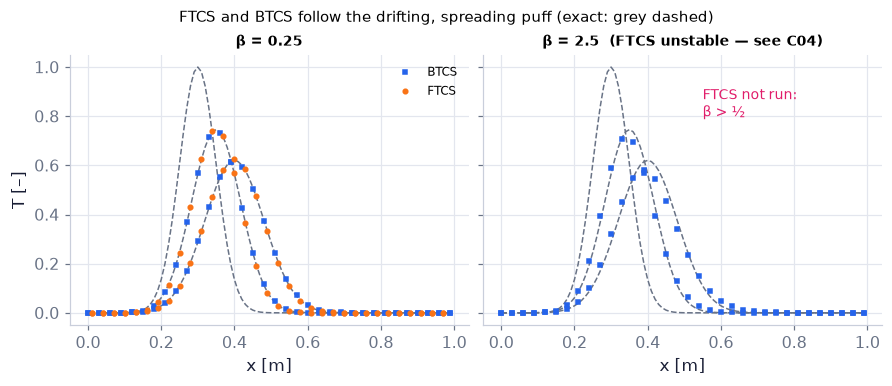

In [19]:
x = np.linspace(0, 1, 101)[:-1]; dx = x[1] - x[0]              # periodic grid, dx = 0.01 m
u, D = 0.5, 0.01                                               # current [m/s] and diffusivity [m²/s]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.4), sharey=True)   # the figure and its panels
for ax, beta_ in ((a1, 0.25), (a2, 2.5)):                      # a safe step and a ten times larger one
    dt = beta_*dx**2/D                                         # dt from beta [s]
    for t_ in (0.0, 0.1, 0.2):                                 # three times [s]
        n_ = int(round(t_/dt))                                 # steps to reach t
        ax.plot(x, FD.advected_gaussian(x, t_, u, D), "--", color=C_EX, lw=1)   # exact solution of (10.1)
        if n_:
            b = FD.solve_transport_1d(FD.advected_gaussian(x, 0, u, D), x, u, D, dt, n_, "btcs", periodic=True)["T"]
            ax.plot(x[::3], b[::3], "s", color=C_IM, ms=3, label="BTCS" if t_ == 0.2 else None)   # draw the curve(s)
            if beta_ <= 0.5:                                   # FTCS only where it is stable
                f = FD.solve_transport_1d(FD.advected_gaussian(x, 0, u, D), x, u, D, dt, n_, "ftcs", periodic=True)["T"]
                ax.plot(x[1::3], f[1::3], "o", color=C_FT, ms=3, label="FTCS" if t_ == 0.2 else None)   # draw the curve(s)
    ax.set_title(f"β = {beta_}" + ("" if beta_ <= 0.5 else "  (FTCS unstable — see C04)"), fontsize=9)   # the panel's title: what this panel shows
    ax.set_xlabel("x [m]")   # axis labels, with units where the quantity has them
a2.text(0.55, 0.8, "FTCS not run:\nβ > ½", color=C_BAD, fontsize=9)   # the reason for the missing orange dots
a1.set_ylabel("T [–]"); a1.legend(fontsize=8, frameon=False)   # axis labels, with units where the quantity has them
fig.suptitle("FTCS and BTCS follow the drifting, spreading puff (exact: grey dashed)", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** The peak moves right and flattens; at $\beta=0.25$ (left) both schemes sit on the exact curves at $t=0$, 0.1 and 0.2 s. At $\beta=2.5$ (right) only BTCS is run.

**How to read it.** At $\beta=2.5$ BTCS survives but its peak is lower and a little behind the exact one: it is stable, but its first-order time error ($\Delta t$ ten times larger) smears the puff — stability is not accuracy.

**What would change if…** …$u=0$: the peak would stay put and only spread — Ch. 1's diffusion.

**What would change if…** …we asked *how close* FTCS is to (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ itself, not to one solution? Put the exact solution into the rule and see what is left over — C03.

### 🧩 Consistency and the truncation error `C03`

*The question:* Does the update rule really approximate the PDE — and which equation does it solve exactly?

*In one line:* $E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)$ *(10.17)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **multivariable Taylor expansion** — the same series in two variables at once: T(x + Δx, t + Δt) expands in powers of Δx and Δt (Ch. 3 P98).
- **sympy symbols, subs, series, removeO** — `sp.series(expr, h, 0, 3).removeO()` gives the Taylor polynomial in h; `subs` substitutes (Ch. 4 P117).
- **sympy basics** — symbols, expressions and `simplify`; an expression that simplifies to 0 is an identity (Ch. 1 P40).

#### The problem in plain words

You wrote a rule that *looks* like (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$. A typo, a wrong sign or a missing factor 2 would also look plausible. Consistency is the test: put
the true solution into the rule. If what is left over shrinks to zero as $\Delta x$ and $\Delta t$ shrink, the rule approximates the PDE; the size
of the leftover tells how fast. The leftover also tells the *character* of the error — whether it smears (like extra diffusion) or ripples
(like dispersion).

#### The idea

$$\text{scheme}(\text{exact }T)\;=\;\underbrace{\text{PDE}(\text{exact }T)}_{=\,0}\;+\;E\;=\;E$$

| Property | Meaning | How we test it |
|---|---|---|
| **convergent** | the computed numbers approach the exact solution | measure the error on finer grids (N10) |
| **consistent** | the discrete equations approach the PDE | Taylor-expand the scheme (D03) |
| **stable** | errors (round-off) do not grow | von Neumann analysis (C04) |

Consistency and stability are the two we can check on paper; the Lax theorem (C05) says together they give convergence.

> 📎 **Primer — norms of an error array: rms, max, L1.** `P224` · An error is an array — one number per grid point. To judge it by one number: the root mean square $\sqrt{\text{mean}(e^2)}$ (the book's choice in
(10.15), $\lVert e^n_i\rVert\le K_e\,\Delta x^a\,\Delta t^b$), the maximum $\lvert e\rvert$ (the worst point) or the mean $\lvert e\rvert$. For a smooth error they shrink at the same rate; near a
shock or a wiggle the max norm is the honest one.

In [20]:
import numpy as np   # arrays and maths
e = np.array([0.0, 0.01, -0.02, 0.01])                        # an error at four points
print(np.sqrt(np.mean(e**2)), np.max(np.abs(e)), np.mean(np.abs(e)))   # rms 0.0122, max 0.02, mean 0.01

0.012247448713915891 0.02 0.01


📝 **Note.** **N10 [B]** **Convergence and its rates (10.14)–(10.15):** the solution error $e^n_i=T^n_i-T(x_i,t_n)$ *(10.14)* and, for a convergent scheme,
$\lVert e^n_i\rVert\le K_e\,\Delta x^a\,\Delta t^b$ *(10.15)* with rates $a$, $b$ (we write $K_e$ so it is not confused with the stiffness matrix
$\mathbf K$ of C07). To measure $a$ alone, tie $\Delta t$ to $\Delta x$ ($\Delta t\propto\Delta x^2$ makes the time error as small as the space
error); D23 turns this bound, $\lVert e\rVert\approx K_e\Delta x^a$, into the slope $a$ of a log–log plot.

In [21]:
st = FD.convergence_study("ftcs", n_list=(20, 40, 80, 160) if not FAST else (20, 40, 80), dt_rule="diffusive")   # dt = 0.25 dx^2/D
print("dx:", np.round(st["dx"], 5)); print("rms error:", np.array(st["err"]))   # show the numbers computed above
print(f"FTCS observed order in dx: {st['order']:.2f}; pairwise {np.round(st['pairwise'], 2)}")   # show the numbers computed above
for sch, rule, coarse, fine in (("btcs", "diffusive", (20, 40, 80, 160), (80, 160, 320, 640)),
                                ("upwind", "advective", (20, 40, 80, 160), (160, 320, 640, 1280))):
    o1 = FD.convergence_study(sch, n_list=coarse, dt_rule=rule)["order"]   # on the default grids
    o2 = FD.convergence_study(sch, n_list=fine if not FAST else fine[:3], dt_rule=rule)["order"]   # on finer grids
    print(f"{sch:6s} ({rule} dt): order {o1:.2f} on n = {coarse[0]}…{coarse[-1]},  {o2:.2f} on n = {fine[0]}…")   # show the numbers computed above

dx: [0.05   0.025  0.0125 0.0063]
rms error: [0.0462 0.0128 0.003  0.0008]
FTCS observed order in dx: 1.99; pairwise [1.85 2.09 2.  ]
btcs   (diffusive dt): order 1.80 on n = 20…160,  1.98 on n = 80…


upwind (advective dt): order 0.76 on n = 20…160,  0.95 on n = 160…


**What does the code above do?**

1. `convergence_study` runs the scheme on the travelling Gaussian with $n$ = 20 … 160 cells to $t=0.2$ s, computes the rms error (10.14), $e^n_i=T^n_i-T(x_i,t_n)$ at the end
   and fits the slope of log(error) against log($\Delta x$) (P13). FTCS with $\Delta t\propto\Delta x^2$ gives about 2.
2. The same study for BTCS ($\Delta t\propto\Delta x^2$, expected 2) and upwind ($\Delta t\propto\Delta x$, expected 1) gives **smaller** numbers on
   the coarse default grids — the Gaussian is only a few cells wide there, so the leading error term does not yet dominate (the grids are
   *pre-asymptotic*). On finer grids the observed orders approach 2 and 1. An observed order is only meaningful in the asymptotic range — the
   lesson C15 returns to.

#### 🧮 Derivation — The truncation error of FTCS $E^n_i=\frac{\Delta t}2\big[\frac{\partial^2T}{\partial t^2}\big]^n_i+u\frac{\Delta x^2}6\big[\frac{\partial^3T}{\partial x^3}\big]^n_i-D\frac{\Delta x^2}{12}\big[\frac{\partial^4T}{\partial x^4}\big]^n_i+O(\Delta t^2,\Delta x^4)$ `D03` (Eq. 10.17: $E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)$)

**What we want to show.** Find what is left over when the exact solution is put into the FTCS rule — the truncation error — and show that it vanishes as the grid shrinks (consistency).

**Assumptions.** T smooth in x and t (steps 2–5); constant u, D.

**The plan.**

1. Expand the time difference in Taylor series (the book skips this).
2. Reuse D01 for the space differences.
3. Collect: the PDE plus a leftover.
4. Read the orders, then look at a special case.

**Tools we use** (each explained before this point): Taylor series in t and x (Ch. 3 P98) · D01's results · sympy `series` (Ch. 4 P117) for the optional check.

**We start from**

$$ \begin{array}{l}\text{The FTCS scheme (10.9) without its error term, applied to a smooth function T:} \\ \mathcal R=\frac{T^{n+1}_i-T^n_i}{\Delta t}+u \frac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}-D\frac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}\end{array} $$

*In words:* the scheme's residual.

---

**Step 1 of 11 — Put a smooth T into the scheme.**

$$ \mathcal R=\frac{T^{n+1}_i-T^n_i}{\Delta t}+u\frac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}-D\frac{T^n_{i+1} -2T^n_i+T^n_{i-1}}{\Delta x^2} $$

- *Why we can do this:* Consistency asks what the scheme's left side becomes for a smooth function; we will expand each difference about $(x_i,t_n)$.
- *In words:* measure how badly a smooth function fails the rule.

---

**Step 2 of 11 — Taylor-expand the new time level.**

$$ T^{n+1}_i=T+\Delta t\,T_t+\frac{\Delta t^2}2T_{tt}+\frac{\Delta t^3}6T_{ttt}+O(\Delta t^4) $$

- *Why we can do this:* Taylor in t at fixed $x_i$ (P98). The book never writes this line — we add it; it is the source of the Δt/2 term.
- *In words:* the value one step later, as a series in Δt.

---

**Step 3 of 11 — Form the time difference.**

$$ \frac{T^{n+1}_i-T^n_i}{\Delta t}=T_t+\frac{\Delta t}2T_{tt}+O(\Delta t^2) $$

- *Why we can do this:* Subtract T and divide by Δt — the same moves as D01 step 2 in time.
- *In words:* the forward difference is the rate plus a Δt/2 correction.

---

**Step 4 of 11 — Reuse the centred first difference.**

$$ \frac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}=T_x+\frac{\Delta x^2}6T_{xxx}+O(\Delta x^4) $$

- *Why we can do this:* D01 step 6, read the other way round.
- *In words:* the convective stencil is the slope plus a Δx² correction.

---

**Step 5 of 11 — Reuse the centred second difference.**

$$ \frac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}=T_{xx}+\frac{\Delta x^2}{12}T_{xxxx}+O(\Delta x^4) $$

- *Why we can do this:* D01 step 8, read the other way round.
- *In words:* the diffusive stencil is the curvature plus a Δx² correction.

---

**Step 6 of 11 — Substitute steps 3–5 into $\mathcal R$.**

$$ \mathcal R=T_t+uT_x-DT_{xx}+\frac{\Delta t}2T_{tt}+u\frac{\Delta x^2}6T_{xxx}-D\frac{\Delta x^2}{12}T_{xxxx}+O(\Delta t^2,\Delta x^4) $$

- *Why we can do this:* Each difference replaced by its series; the diffusive correction enters with −D because of the minus sign in $\mathcal R$.
- *In words:* the residual is the PDE plus three small terms.

---

**Step 7 of 11 — Name the leftover $E^n_i$.**

$$ E^n_i=\frac{\Delta t}2T_{tt}+u\frac{\Delta x^2}6T_{xxx}-D\frac{\Delta x^2}{12}T_{xxxx}+O(\Delta t^2, \Delta x^4)\ \text{(10.17)} $$

- *Why we can do this:* Collect everything that is not the PDE; this is the truncation error.
- *In words:* E is what the scheme adds to the equation.

---

**Step 8 of 11 — Read the scheme as a modified equation.**

$$ \big[T_t\big]^n_i+u\big[T_x\big]^n_i-D\big[T_{xx}\big]^n_i+E^n_i=0\ \text{(10.16)} $$

- *Why we can do this:* The numerical solution satisfies the scheme exactly, $\mathcal R=0$; if it is smooth, step 6 says it obeys the PDE plus E — the book's sign convention (E on the left).
- *In words:* FTCS solves (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ with E added.

---

**Step 9 of 11 — Let Δx, Δt shrink.**

$$ E^n_i\to0\quad(\Delta t,\Delta x\to0) $$

- *Why we can do this:* Every term of E carries a positive power of Δt or Δx and bounded derivatives; hence (10.16), $\left[T_t\right]^n_i+u\left[T_x\right]^n_i-D\left[T_{xx}\right]^n_i+E^n_i=0$ tends to (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$: the scheme is consistent.
- *In words:* on a fine enough grid the scheme is the PDE.

---

**Step 10 of 11 — Read the orders.**

$$ E=O(\Delta t)+O(\Delta x^2) $$

- *Why we can do this:* The lowest powers in (10.17), $E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)$ are Δt¹ and Δx²: first order in time, second in space, as the book states after (10.17).
- *In words:* halving Δt halves the time error; halving Δx quarters the space error.

---

**Step 11 of 11 — Special case: pure diffusion.**

$$ E=D\,\Delta x^2\Big(\frac\beta2-\frac1{12}\Big)T_{xxxx} $$

- *Why we can do this:* With u = 0 the PDE gives $T_{tt}=D\,\partial_{xx}T_t=D^2T_{xxxx}$ and $\Delta t=\beta\Delta x^2/D$; substituting into (10.17), $E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)$ combines the two terms. Ours, not the book's.
- *In words:* at β = 1/6 the two leading errors cancel exactly.

---

**Result**

$$ \left[T_t\right]^n_i+u\left[T_x\right]^n_i-D\left[T_{xx}\right]^n_i+E^n_i=0\ \text{(10.16)},\qquad E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)\ \text{(10.17)} $$

*In words:* FTCS is consistent, first order in time and second order in space; its leftover contains a time term, a dispersive term (odd derivative) and a diffusive term (even derivative).

**What it means.** Consistency is the first of the three properties; the modified-equation reading (step 8) returns in D17 (upwind's numerical diffusion) and D18 (MacCormack's dispersion). Fails if the solution is not smooth.

**Check it.** Units: every term of E has units of T/s (e.g. $\frac{\Delta t}2T_{tt}$: s · T/s²) ✓. Tiny example (u = 0, D = 1, Δx = 0.1, β = 0.25, T = $e^{-\pi ^2t}$ sin πx at x = ½, t = 0): E = π⁴ × 0.01 × (0.125 − 0.0833) = 0.0406 ✓; `FD.truncation_error_sympy("ftcs")` returns (10.17), $E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)$; the measured one-step residual on the Gaussian agrees with `FD.truncation_terms` within 5 %.

In [22]:
import sympy as sp                                                  # symbolic algebra (Ch. 1 P40)
x, t, u, D, dt, dx = sp.symbols('x t u D Delta_t Delta_x', positive=True)   # position, time, speed, diffusivity, steps
T = sp.Function('T')                                                # any smooth function T(x, t)
R = ((T(x, t + dt) - T(x, t))/dt + u*(T(x + dx, t) - T(x - dx, t))/(2*dx)
     - D*(T(x + dx, t) - 2*T(x, t) + T(x - dx, t))/dx**2)          # step 1: the scheme's residual for a smooth T
Rt = sp.series(R, dt, 0, 2).removeO()                               # steps 2-3: Taylor in dt (the move the book skips)
Rx = sp.series(Rt, dx, 0, 3).removeO().doit()                       # steps 4-5: Taylor in dx (D01's results)
pde = sp.diff(T(x, t), t) + u*sp.diff(T(x, t), x) - D*sp.diff(T(x, t), x, 2)   # the PDE (10.1) moved to one side
print(sp.simplify(sp.expand(Rx - pde)))                             # steps 6-7: what is left is E of (10.17)

-D*Delta_x**2*Derivative(T(x, t), (x, 4))/12 + Delta_t*Derivative(T(x, t), (t, 2))/2 + Delta_x**2*u*Derivative(T(x, t), (x, 3))/6


> ⚠️ **Common confusion (traps in `D03`):** Leaving out the time Taylor series (then the Δt/2 T_tt term is missing and FTCS looks second order in time); the sign convention (E on the left of (10.16), $\left[T_t\right]^n_i+u\left[T_x\right]^n_i-D\left[T_{xx}\right]^n_i+E^n_i=0$); thinking consistency guarantees a good answer (C04).

#### ✏️ Tiny example: the leftover for pure diffusion

Take $u=0$, $D=1$, and the exact solution $T=e^{-\pi^2t}\sin\pi x$ (a sine that decays). Its derivatives: $T_{tt}=\pi^4T$ (differentiate
$e^{-\pi^2t}$ twice) and $T_{xxxx}=\pi^4T$.
1. Insert in (10.17): $E=\frac{\Delta t}2\pi^4T-\frac{\Delta x^2}{12}\pi^4T=\pi^4T\Delta x^2\big(\frac\beta2-\frac1{12}\big)$ using $\Delta t=\beta\Delta x^2$ ($D=1$).
2. At $x=\frac12$, $t=0$ ($T=1$), $\Delta x=0.1$, $\beta=0.25$: $E=97.41\times0.01\times(0.125-0.0833)=0.0406$.
3. Surprise: at $\beta=1/6$ the bracket is zero — the two leading errors cancel and FTCS becomes fourth order in space for pure diffusion.
   (Try it in the explainer's FTCS mode.)

In [23]:
res = FD.truncation_error_sympy("ftcs")                             # D03 by machine: Taylor series into (10.9), subtract (10.1)
print("E =", res["E"], "  orders (t, x):", res["order_t"], res["order_x"])   # show the numbers computed above
E_tiny = np.pi**4*1.0*0.1**2*(0.25/2 - 1/12)                        # the tiny example: E = pi^4 T dx^2 (beta/2 - 1/12)
print(f"tiny example: E = {E_tiny:.4f}")   # show the numbers computed above
tt = FD.truncation_terms(0.5, 0.01, 0.01, 0.0025, 0.35, 0.1)       # the three terms of (10.17) on the Gaussian at x = 0.35 m, t = 0.1 s
for k in ("time", "conv", "diff", "total", "measured"):   # repeat the indented lines for each item listed
    print(f"{k:9s} {tt[k]: .4e}")                                   # [unit of T per second]
print(f"(measured - total)/total = {(tt['measured'] - tt['total'])/tt['total']:.3f}")   # show the numbers computed above

E = -D*Delta_x**2*T_xxxx/12 + Delta_t*T_tt/2 + Delta_x**2*T_xxx*u/6   orders (t, x): 1 2
tiny example: E = 0.0406


time      -3.7958e-02
conv       5.1927e-191
diff      -9.2019e-03
total     -4.7160e-02
measured  -4.6397e-02
(measured - total)/total = -0.016


**What does the code above do?**

1. `truncation_error_sympy("ftcs")` repeats D03 symbolically: the three terms of (10.17), $E^n_i=\tfrac{\Delta t}{2}\left[T_{tt}\right]^n_i+u\tfrac{\Delta x^2}{6}\left[T_{xxx}\right]^n_i-D\tfrac{\Delta x^2}{12}\left[T_{xxxx}\right]^n_i+O(\Delta t^2,\Delta x^4)$, first order in $t$ and second in $x$.
2. The tiny example's $E=0.0406$ is recomputed.
3. `truncation_terms` evaluates the three terms of (10.17) with the exact derivatives of the travelling Gaussian ($u=0.5$ m/s, $D=0.01$ m²/s,
   $\Delta x=0.01$ m, $\Delta t=0.0025$ s). The dispersive $T_{xxx}$ term is essentially zero here because $x=0.35$ m is the peak of the pulse
   at $t=0.1$ s, where the odd derivative vanishes.
4. `measured` is the actual one-step leftover of FTCS on the exact solution; it agrees with the sum of the three terms to within a few per cent —
   the rest is the next Taylor terms.

In [24]:
# from scratch: the one-step residual of FTCS on the exact Gaussian, next to the three-term formula
x = np.linspace(0, 1, 101)[:-1]; u, D, dx, dt, t0 = 0.5, 0.01, 0.01, 0.0025, 0.1   # the grid and numbers of the cell above
alpha, beta = FD.ftcs_coefficients(u, D, dx, dt)               # (10.11)
Tn = FD.advected_gaussian(x, t0, u, D)                         # exact values at t_n
Tn1 = FD.advected_gaussian(x, t0 + dt, u, D)                   # exact values one step later
resid = (Tn1 - FD.transport_1d_step(Tn, alpha, beta, "ftcs", periodic=True))/dt   # (exact - scheme)/dt at every node
i = int(np.argmin(np.abs(x - 0.35)))                           # the node at x = 0.35 m
print(f"residual at x = {x[i]:.2f} m: {resid[i]:.4e};  three-term E: {tt['total']:.4e}")   # show the numbers computed above
assert abs(resid[i] - tt["total"]) < 0.05*abs(tt["total"])     # within 5 %: the leftover IS the truncation error

residual at x = 0.35 m: -4.6397e-02;  three-term E: -4.7160e-02


**What does the code above do?**

1. The exact solution is put into the FTCS rule: `(exact at t+Δt − scheme applied to exact at t)/Δt` is the leftover per unit time.
2. Sign convention: $E$ sits on the *left* of (10.16), $\left[T_t\right]^n_i+u\left[T_x\right]^n_i-D\left[T_{xx}\right]^n_i+E^n_i=0$, so "exact minus scheme", divided by $\Delta t$, equals $+E$.
3. At $x=0.35$ m it matches the three-term formula to within 5 % — the assert checks it.

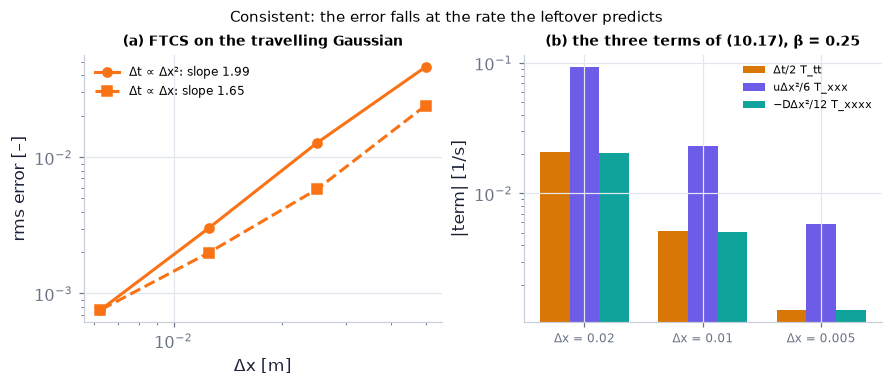

In [25]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.4))   # the figure and its panels
ns = (20, 40, 80, 160) if not FAST else (20, 40, 80)           # grids
sd = FD.convergence_study("ftcs", n_list=ns, dt_rule="diffusive")   # dt = 0.25 dx^2/D (beta fixed)
sa = FD.convergence_study("ftcs", n_list=ns, dt_rule="advective", C=0.1)   # dt = 0.1 dx/u (Courant number fixed)
a1.loglog(sd["dx"], sd["err"], "o-", color=C_FT, label=f"Δt ∝ Δx²: slope {sd['order']:.2f}")   # curve(s) on logarithmic axes
a1.loglog(sa["dx"], sa["err"], "s--", color=C_FT, label=f"Δt ∝ Δx: slope {sa['order']:.2f}")   # curve(s) on logarithmic axes
a1.set_xlabel("Δx [m]"); a1.set_ylabel("rms error [–]"); a1.legend(fontsize=8, frameon=False)   # axis labels, with units where the quantity has them
a1.set_title("(a) FTCS on the travelling Gaussian", fontsize=9)   # the panel's title: what this panel shows
a1.xaxis.set_minor_formatter(plt.NullFormatter())             # no labels on the minor ticks (they would overlap)
dxs =np.array([0.02, 0.01, 0.005])                            # three spacings for the bars
w_ = 0.25                                                      # bar width
for j, (k, col, lab) in enumerate((("time", COLORS["amber"], "Δt/2 T_tt"), ("conv", C_MC, "uΔx²/6 T_xxx"),
                                   ("diff", COLORS["teal"], "−DΔx²/12 T_xxxx"))):
    vals = [abs(FD.truncation_terms(0.5, 0.01, d_, 0.25*d_**2/0.01, 0.32, 0.1)[k]) for d_ in dxs]   # at x = 0.32 m (off the peak)
    a2.bar(np.arange(3) + (j - 1)*w_, vals, w_, color=col, label=lab)   # bars
a2.set_yscale("log"); a2.set_xticks(range(3)); a2.set_xticklabels([f"Δx = {d_}" for d_ in dxs], fontsize=8)   # axis range / scale chosen so the feature discussed below is visible
a2.set_ylabel("|term| [1/s]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) the three terms of (10.17), β = 0.25", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("Consistent: the error falls at the rate the leftover predicts", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** (a) Two straight lines of different slope on log–log axes (the legend prints both slopes). (b) Three groups of bars that shrink as $\Delta x$ halves.

**How to read it.** Tie $\Delta t$ to $\Delta x^2$ and FTCS looks second order; tie it to $\Delta x$ (fixed Courant number) and the time term $\frac{\Delta t}{2}T_{tt}$, which is then only first order in $\Delta x$, takes over as the grid is refined — the dashed line bends towards slope 1. In (b), with $\Delta t\propto\Delta x^2$ all three terms fall by 4 per halving: the scheme is second order in $\Delta x$ along this path.

**What would change if…** …$\beta=1/6$: in pure diffusion the time and $T_{xxxx}$ terms would cancel exactly (the tiny example), leaving a fourth-order error.

**What would change if…** …$\beta=0.51$? The leftover is still tiny and still shrinks with $\Delta x$ — the scheme is consistent — yet the computation explodes. Consistency
is necessary, not sufficient: C04 finds the missing ingredient.

> 🔁 **Recap — R04 · Fourier modes** (Ch. 5 (P142), Ch. 7 §7.1). Ch. 5 (P142) and Ch. 7 wrote any periodic grid function as a sum of waves $e^{\mathrm ikx}$. The book writes the error as $\xi^n_i=\sum_kg^n(k)e^{\mathrm i\pi kx_i}$ *(10.20)* — its $k$ counts *half*-waves per unit length, so the phase change per cell is $\theta=k\pi\Delta x$ (the angle in (10.26), $\left(1-4\beta\sin^2\tfrac{\theta}{2}\right)^2+(2\alpha\sin\theta)^2\le1,\quad \theta=k\pi\Delta x$). ⚠️ The book's $i$ is both the grid index and $\sqrt{-1}$; we write the imaginary unit upright ($\mathrm i$) and, in our own lines, call the grid index $j$. `FD.fourier_mode(x, k, convention='book' or 'standard')` shows both conventions.

In [26]:
x8 = np.arange(8)*0.125                                        # 8 nodes, dx = 0.125
print(np.round(FD.fourier_mode(x8, 8, "book").real, 3))       # k = 8 half-waves per unit length: theta = k pi dx = pi

[ 1. -1.  1. -1.  1. -1.  1. -1.]


**What does the code above do?**

With the book's convention $e^{\mathrm i\pi kx}$ and $k=8$, $\theta=k\pi\Delta x=\pi$: the mode is the zigzag $1,-1,1,-1,\dots$ — the shortest wave a grid can carry.

> 🔁 **Recap — R05 · The diffusion limit β ≤ ½** (Ch. 1 §1.5). Ch. 1's FTCS for pure diffusion was stable only for $r=D\Delta t/\Delta y^2\le\frac12$ (`core.diffusion.stable_time_step`). Here it reappears as $0\le\beta\le\frac12$, i.e. $\Delta t\le\frac12\frac{\Delta x^2}D$ *(10.28)*; D06 derives it, and adds the new half: with $D=0$ FTCS is never stable.

### 🧩 Von Neumann stability: the amplification factor and Noye's region `C04`

*The question:* Why does a round-off error of $10^{-16}$ explode into garbage with β = 0.51 but die away with β = 0.50?

*In one line:* $\tfrac{g^{n+1}}{g^n}=(\alpha+\beta)e^{-\mathrm i\pi k\Delta x}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\pi k\Delta x}$ *(10.24)* · $0\le4\alpha^2\le2\beta\le1$ *(10.27)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **Fourier modes and the FFT Poisson solver** — any periodic grid function is a sum of waves $e^{ikx}$, and linear operations act on each wave separately (Ch. 5 P142).
- **Euler's formula, imaginary unit** — $e^{i\theta}$ = cos θ + i sin θ, with i = √−1 (Ch. 1 P45).
- **complex numbers in numpy (1j, np.abs, np.angle)** — `z = 0.6 - 0.2j`; `np.abs(z)` is its size, `np.angle(z)` its angle (Ch. 6 P153).
- **complex conjugate (G(−θ))** — the conjugate flips the sign of the imaginary part; for a real-coefficient rule G(−θ) is the conjugate of G(θ), with the same size (Ch. 2 P81).
- **random generator with a seed** — `np.random.default_rng(1)` gives the same 'random' numbers every run (Ch. 1 P10).
- **live widgets** — an ipywidgets slider that re-runs a function while a kernel is running (Ch. 1 P47).

#### The problem in plain words

Run FTCS for pure diffusion on a rod, twice: with $\beta=0.50$ and with $\beta=0.51$. The two runs agree for hundreds of steps, then the second
one grows a zigzag — neighbouring nodes alternating up and down — that grows by about 4 % per step until the numbers overflow. Nothing in the
physics changed by 2 %. What happened is that the computer's own rounding errors (always present, about $10^{-16}$) contain every
wavelength, and for $\beta=0.51$ the shortest one is amplified a little every step. The cell runs both.

In [27]:
lax = FD.lax_demo(betas=(0.50, 0.51))                          # FTCS on the heated rod (our T_w = 1), 20 cells, 2000 steps
for b, r in lax.items():                                       # one entry per beta
    print(f"beta = {b:.2f}: blew up = {r['blew_up']}, at step {r['step_blown']}; final rms error = {r['final_error']:.2e}")   # show the numbers computed above

beta = 0.50: blew up = False, at step None; final rms error = 1.68e-12
beta = 0.51: blew up = True, at step 690; final rms error = inf


**What does the code above do?**

`lax_demo` marches FTCS for pure diffusion on a rod whose ends are suddenly held at $T_w=1$ and compares with the exact series (N113 below). At
$\beta=0.50$ the error stays at round-off level; at $\beta=0.51$ the run is stopped when the values exceed $10^6$ — the step is printed.

#### The idea

```
error now = Σ amplitude_θ · wave_θ          one step later: Σ G(θ)·amplitude_θ · wave_θ
|G| = 0.98 : 1e-16 → 1e-16·0.98ⁿ  dies       |G| = 1.04 : 1e-16 → 1e-16·1.04ⁿ ≈ 1 after ~940 steps
```

Errors obey the same linear rule as the solution (N12). Break the error into waves; the rule treats each wave separately and multiplies its amplitude by one complex number $G(\theta)$ per step. After $n$ steps the amplitude is $\lvert G\rvert^n$ times the start: **stable ⇔ $\lvert G(\theta)\rvert\le1$ for every wave**.

📝 **Note.** **N11 [B]** **Stable** (§10.2): a scheme is stable when small disturbances — round-off made at any step — decay, or at least stay bounded, instead of
taking over the solution. It is a property of the *rule*, not of the PDE: (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ itself is perfectly well behaved at both $\beta$ values.

predicted slope of the rising line: log10(1.04) = 0.0170 per step


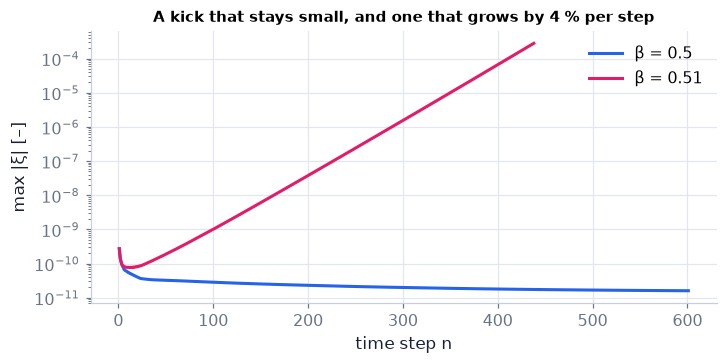

In [28]:
rng = np.random.default_rng(1)                                 # seeded random numbers (P10)
xi0 = 1e-10*rng.standard_normal(64)                            # a tiny random kick on a periodic grid of 64 nodes
fig, ax = plt.subplots(figsize=(6.5, 3.2))   # the figure and its panels
for b, col in ((0.50, C_IM), (0.51, C_BAD)):                   # the two diffusion numbers
    pe = FD.propagate_error(xi0, 0.0, b, 600)                  # (10.19): the kick marched by FTCS itself
    ax.semilogy(np.arange(1, len(pe["max_abs"]) + 1), pe["max_abs"], color=col, label=f"β = {b}")   # curve(s) on logarithmic axes
ax.set_xlabel("time step n"); ax.set_ylabel("max |ξ| [–]"); ax.legend(frameon=False)   # axis labels, with units where the quantity has them
ax.set_title("A kick that stays small, and one that grows by 4 % per step", fontsize=10)   # the panel's title: what this panel shows
growth = np.log10(1.04)                                        # the predicted slope per step on a log10 axis
print(f"predicted slope of the rising line: log10(1.04) = {growth:.4f} per step")   # show the numbers computed above
plt.show()   # display the figure

**What you see.** One flat (slowly falling) blue line and one straight rising rose line on a logarithmic axis.

**How to read it.** A straight line on a log axis is exponential growth; the slope of the rose line is $\log_{10}1.04\approx0.017$ decades per step (printed), i.e. the amplitude grows by $\lvert G\rvert=1.04$ per step. The blue kick decays: its worst wave has $\lvert G\rvert\le1$.

**What would change if…** …$\beta=0.45$: the blue line would fall faster; every wave is damped.

📝 **Note.** **N12 [B]** **The disturbance obeys the same rule (10.18)–(10.19):** $\xi^n_i=T^n_i-\overline T^n_i$ *(10.18)* (exact solution of the discrete system
minus the computed one) satisfies $\xi^{n+1}_i=(\alpha+\beta)\xi^n_{i-1}+(1-2\beta)\xi^n_i+(\beta-\alpha)\xi^n_{i+1}$ *(10.19)* — because the rule is linear
(D04 steps 1–3).

> 📎 **Primer — half-angle identities.** `P225` · Two trigonometric facts do all the work in this block: $1-\cos\theta=2\sin^2\frac\theta2$ and $\sin\theta=2\sin\frac\theta2\cos\frac\theta2$ (so
$\sin^2\theta=4s(1-s)$ with $s=\sin^2\frac\theta2$). They turn a cosine that runs from 1 to −1 into a square that runs from 0 to 1.

In [29]:
import numpy as np   # arrays and maths
th = np.linspace(0, np.pi, 5)                                 # a few angles
print(np.allclose(1 - np.cos(th), 2*np.sin(th/2)**2))          # True
s = np.sin(th/2)**2                                            # the new variable, between 0 and 1
print(np.allclose(np.sin(th)**2, 4*s*(1 - s)))                 # True

True
True


#### 🧮 Derivation — The error equation $\xi^{n+1}_i=(\alpha+\beta)\xi^n_{i-1}+(1-2\beta)\xi^n_i+(\beta-\alpha)\xi^n_{i+1}$ and the amplification factor $\frac{g^{n+1}}{g^n}=(\alpha+\beta)e^{-\mathrm i\pi k\Delta x}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\pi k\Delta x}$ `D04` (Eq. 10.24: $\tfrac{g^{n+1}}{g^n}=(\alpha+\beta)e^{-\mathrm i\pi k\Delta x}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\pi k\Delta x}$)

**What we want to show.** Show that a round-off error obeys the scheme itself, and that each of its Fourier waves is multiplied by one complex number per step.

**Assumptions.** The scheme is linear with constant α, β (step 3); a periodic or infinite grid, so every wave fits (step 5); uniform spacing (step 8). **Index renamed:** grid index j from step 5 on, so that i is only $\sqrt{-1}$.

**The plan.**

1. Subtract the two runs (the book: 'it can be shown').
2. Write the error as a sum of waves and follow one.
3. Divide out the wave shape to get G.

**Tools we use** (each explained before this point): Linearity (superposition) · Fourier modes (R04) · Euler's formula and complex exponentials (Ch. 1 P45, Ch. 6 P153).

**We start from**

$$ \begin{array}{l}\text{The FTCS rule (10.10), satisfied by the exact solution T of the discrete} \\ \text{system and — up to the round-off made once — by the computed}\ \overline T\ \text{; the} \\ \text{disturbance}\ \xi^n_i=T^n_i-\overline T^n_i\ \text{(10.18)}\end{array} $$

*In words:* two runs of the same rule that differ by a tiny error.

---

**Step 1 of 11 — Write FTCS for the exact discrete solution.**

$$ T^{n+1}_i=T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1}) $$

- *Why we can do this:* (10.10), $T^{n+1}_i\approx T^n_i-\alpha(T^n_{i+1}-T^n_{i-1})+\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})$ with '=' because T is by definition the exact solution of the discrete system.
- *In words:* the rule, obeyed perfectly.

---

**Step 2 of 11 — Write it for the computed values.**

$$ \overline T^{\,n+1}_i=\overline T^n_i-\alpha(\overline T^n_{i+1}-\overline T^n_{i-1})+\beta(\overline T^n_{i+1}-2\overline T^n_i+\overline T^n_{i-1}) $$

- *Why we can do this:* The computer applies the same rule to its own (slightly wrong) numbers; we follow how an error present at step n travels on.
- *In words:* the rule, applied to the numbers we actually hold.

---

**Step 3 of 11 — Subtract step 2 from step 1.**

$$ \xi^{n+1}_i=\xi^n_i-\alpha(\xi^n_{i+1}-\xi^n_{i-1})+\beta(\xi^n_{i+1}-2\xi^n_i+\xi^n_{i-1}) $$

- *Why we can do this:* The rule is linear, so the difference of two solutions is again a solution, with ξ = T − T̄ (10.18), $\xi^n_i=T^n_i-\overline{T}^n_i$. This is the move the book skips.
- *In words:* the error obeys the same rule as the temperature.

---

**Step 4 of 11 — Collect the coefficients.**

$$ \xi^{n+1}_i=(\alpha+\beta)\xi^n_{i-1}+(1-2\beta)\xi^n_i+(\beta-\alpha)\xi^n_{i+1}\ \text{(10.19)} $$

- *Why we can do this:* Gather the terms of $\xi_{i-1}$ (+α + β), $\xi_i$ (1 − 2β) and $\xi_{i+1}$ (−α + β).
- *In words:* each new error is a weighted mix of three old ones.

---

**Step 5 of 11 — Follow one Fourier wave.**

$$ \xi^n_j=\hat\xi^n\,e^{\mathrm i\pi kx_j}\ \text{(10.21)} $$

- *Why we can do this:* Any grid error is a sum of such waves (10.20), $\xi^n_i=\sum_{k=-\infty}^{\infty}g^n(k)\,e^{\mathrm i\pi kx_i}$ (R04); the rule is linear and a wave stays a wave, so each can be followed alone. We rename the index j and the amplitude $\hat\xi^n$ (the book's $g^n(k)$).
- *In words:* one wave, with an amplitude that may change from step to step.

---

**Step 6 of 11 — The same wave one step later.**

$$ \xi^{n+1}_j=\hat\xi^{n+1}e^{\mathrm i\pi kx_j}\ \text{(10.22)} $$

- *Why we can do this:* The shape in space is fixed by k; only the amplitude can change — that is what we want to find.
- *In words:* same wave, new amplitude.

---

**Step 7 of 11 — Substitute into (10.19).**

$$ \hat\xi^{n+1}e^{\mathrm i\pi kx_j}=\hat\xi^n\big[(\alpha+\beta)e^{\mathrm i\pi kx_{j-1}}+(1-2\beta)e^{\mathrm i\pi kx_j}+ (\beta-\alpha)e^{\mathrm i\pi kx_{j+1}}\big]\ \text{(10.23)} $$

- *Why we can do this:* Steps 5 and 6 inserted in step 4, point by point.
- *In words:* the rule applied to the wave.

---

**Step 8 of 11 — Shift the neighbours.**

$$ e^{\mathrm i\pi kx_{j\pm1}}=e^{\mathrm i\pi kx_j}\,e^{\pm\mathrm i\theta},\quad\theta=k\pi\Delta x $$

- *Why we can do this:* $x_{j\pm1}=x_j\pm \Delta x$ and $e^{a+b}=e^ae^b$; θ is the phase change per cell (the book's convention: k counts half-waves per unit length).
- *In words:* a neighbour's wave value is ours, turned by θ.

---

**Step 9 of 11 — Divide by $\hat\xi^ne^{\mathrm i\pi kx_j}$.**

$$ G\equiv\frac{\hat\xi^{n+1}}{\hat\xi^n}=(\alpha+\beta)e^{-\mathrm i\theta}+(1-2\beta)+(\beta-\alpha) e^{\mathrm i\theta}\ \text{(10.24)} $$

- *Why we can do this:* $e^{\mathrm i\pi kx_j}$ is never zero and appears in every term, so it cancels; we assume $\hat\xi^n\ne0$ (a wave that is present). The result no longer depends on j.
- *In words:* one complex number G per wave.

---

**Step 10 of 11 — Repeat n times.**

$$ \hat\xi^n=G^n\hat\xi^0,\qquad\lvert\hat\xi^n\rvert=\lvert G\rvert^n\lvert\hat\xi^0\rvert $$

- *Why we can do this:* G is the same at every step (constant α, β), so the amplitude is multiplied by G again and again; the modulus of a product is the product of moduli.
- *In words:* after n steps the wave has grown or shrunk by $\lvert G\rvert^n$.

---

**Step 11 of 11 — Demand no growth for every wave.**

$$ \Big\lvert\frac{g^{n+1}}{g^n}\Big\rvert=\lvert G(\theta)\rvert\le1\quad\text{for all }\theta\in[0,\pi]\ \text{(10.25)} $$

- *Why we can do this:* One wave with $\lvert G\rvert>1$ grows without bound from round-off; $G(-\theta)$ is the complex conjugate of $G(\theta)$, so θ ∈ [0, π] covers every wave the grid can carry.
- *In words:* stable means no wave grows.

---

**Result**

$$ \begin{array}{l}\xi^{n+1}_i=(\alpha+\beta)\xi^n_{i-1}+(1-2\beta)\xi^n_i+(\beta-\alpha)\xi^n_{i+1}\ \text{(10.19)} \\ \tfrac{g^{n+1}}{g^n}=(\alpha+\beta)e^{-\mathrm i\pi k\Delta x}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\pi k\Delta x}\ \text{(10.24)} \\ \left\lvert g^{n+1}/g^n\right\rvert\le1\ \text{(10.25)}\end{array} $$

*In words:* the error of a linear scheme obeys the scheme, and every wave of it is multiplied by G(θ) each step.

**What it means.** Stability is now a property of one function G(θ); D05–D08 read it for FTCS, BTCS and upwind. Fails for nonlinear schemes and variable coefficients (then it is a local, 'frozen-coefficient' guide only) and near boundaries.

**Check it.** G is dimensionless ✓. θ = 0 (a constant error): G = (α + β) + (1 − 2β) + (β − α) = 1 — a constant offset neither grows nor decays ✓. θ = π/2, α = 0.1, β = 0.2: G = 0.6 − 0.2i ✓ (C04 tiny example).

> ⚠️ **Common confusion (traps in `D04`):** Confusing the index i with $\sqrt{-1}$ (we renamed it j); using θ = kΔx (the standard convention) with the book's k; dividing by zero when the wave is absent; forgetting that one bad θ is enough.

📝 **Note.** **N13 [B]** **The stability condition (10.25):** $\big\lvert g^{n+1}/g^n\big\rvert\le1$ for **every** wavenumber — one bad wave is enough.
`FD.max_amplification(scheme, α, β)` scans $\theta\in[0,\pi]$; `FD.is_von_neumann_stable` compares the result with 1.

$$ \left\lvert g^{n+1}/g^n\right\rvert\le1 \qquad \text{(10.25)} $$

#### 🧮 Derivation — The modulus $\lvert G\rvert^2=\big(1-4\beta\sin^2\frac\theta2\big)^2+(2\alpha\sin\theta)^2$ `D05` (Eq. 10.26: $\left(1-4\beta\sin^2\tfrac{\theta}{2}\right)^2+(2\alpha\sin\theta)^2\le1,\quad \theta=k\pi\Delta x$)

**What we want to show.** Turn the complex G of (10.24), $\tfrac{g^{n+1}}{g^n}=(\alpha+\beta)e^{-\mathrm i\pi k\Delta x}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\pi k\Delta x}$ into a real formula whose size can be compared with 1.

**Assumptions.** α, β real (they are).

**The plan.**

1. Split G into real and imaginary parts with Euler's formula.
2. Rewrite 1 − cos θ with a half angle.
3. Square and add.

**Tools we use** (each explained before this point): Euler's formula (Ch. 1 P45) · half-angle identities (primer P225) · the modulus of a complex number (Ch. 6 P153).

**We start from**

$$ G=(\alpha+\beta)e^{-\mathrm i\theta}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\theta}\ \text{(10.24)} $$

*In words:* the factor one wave is multiplied by.

---

**Step 1 of 8 — Insert Euler's formula.**

$$ G=(\alpha+\beta)(\cos\theta-\mathrm i\sin\theta)+(1-2\beta)+(\beta-\alpha)(\cos\theta+\mathrm i\sin\theta) $$

- *Why we can do this:* $e^{\pm\mathrm i\theta}=\cos\theta\pm\mathrm i\sin\theta$ (P45); we want G as 'real + i·real'.
- *In words:* the two turned neighbours written with cos and sin.

---

**Step 2 of 8 — Collect the real part.**

$$ \mathrm{Re}\,G=(\alpha+\beta+\beta-\alpha)\cos\theta+1-2\beta=1-2\beta(1-\cos\theta) $$

- *Why we can do this:* The α terms cancel in the real part; 2β cos θ + 1 − 2β regroups as 1 − 2β(1 − cos θ).
- *In words:* diffusion alone sets the real part.

---

**Step 3 of 8 — Collect the imaginary part.**

$$ \mathrm{Im}\,G=\big[-(\alpha+\beta)+(\beta-\alpha)\big]\sin\theta=-2\alpha\sin\theta $$

- *Why we can do this:* Now the β terms cancel; only convection survives.
- *In words:* convection alone sets the imaginary part.

---

**Step 4 of 8 — Use the half-angle identity.**

$$ 1-\cos\theta=2\sin^2\tfrac\theta2 $$

- *Why we can do this:* P225; it turns a quantity running from 0 to 2 into 2 × (a square between 0 and 1), which makes step 7 and D06 clean.
- *In words:* a cosine rewritten as a square.

---

**Step 5 of 8 — Rewrite the real part.**

$$ \mathrm{Re}\,G=1-4\beta\sin^2\tfrac\theta2 $$

- *Why we can do this:* Substitute step 4 into step 2: 2β × 2 sin² = 4β sin².
- *In words:* the real part drops from 1 as the wave gets shorter.

---

**Step 6 of 8 — Assemble G.**

$$ G=\big(1-4\beta\sin^2\tfrac\theta2\big)-2\mathrm i\alpha\sin\theta $$

- *Why we can do this:* Steps 5 and 3 together; a compact form for plotting (the orange curve of explainer 2).
- *In words:* G = (damping part) − i (turning part).

---

**Step 7 of 8 — Square and add.**

$$ \lvert G\rvert^2=\big(1-4\beta\sin^2\tfrac\theta2\big)^2+(2\alpha\sin\theta)^2 $$

- *Why we can do this:* $\lvert a+\mathrm ib\rvert^2=a^2+b^2$ (P153); the sign of the imaginary part disappears in the square.
- *In words:* the squared size of the factor.

---

**Step 8 of 8 — Apply the stability condition.**

$$ \big(1-4\beta\sin^2\tfrac\theta2\big)^2+(2\alpha\sin\theta)^2\le1\ \text{(10.26)} $$

- *Why we can do this:* (10.25), $\left\lvert g^{n+1}/g^n\right\rvert\le1$ squared (both sides are non-negative, so squaring keeps the inequality).
- *In words:* the book's stability condition for FTCS, for every θ.

---

**Result**

$$ \left(1-4\beta\sin^2\tfrac{\theta}{2}\right)^2+(2\alpha\sin\theta)^2\le1,\quad \theta=k\pi\Delta x\ \text{(10.26)} $$

*In words:* the real part carries diffusion, the imaginary part convection, and the squared size must not exceed 1.

**What it means.** A formula in two parameters and one angle — D06 turns "for every θ" into two inequalities.

**Check it.** θ = π/2, α = 0.1, β = 0.2: (1 − 0.4)² + 0.2² = 0.40 ✓ (= ∣0.6 − 0.2i∣²). α = 0, θ = π: ∣G∣ = ∣1 − 4β∣, the zigzag factor ✓.

> ⚠️ **Common confusion (traps in `D05`):** Writing the real part as 1 − 2β cos θ (losing the 1 − cos θ grouping); carrying the minus sign of Im G into the square.

📝 **Note.** **N14 [B]** **$\lvert G\rvert^2$ of FTCS (10.26):** $\big(1-4\beta\sin^2\frac\theta2\big)^2+(2\alpha\sin\theta)^2\le1$ with $\theta=k\pi\Delta x$ — the real part
carries the diffusion, the imaginary part the convection.

> 📎 **Primer — sign of a linear function on an interval.** `P226` · A straight line $f(s)=a+bs$ is $\le0$ everywhere on an interval if and only if it is $\le0$ at both ends — a line cannot poke up in the middle.
So one inequality "for all $s$" becomes two inequalities you can read off. (If the interval is open at an end, test the limit there.)

In [30]:
import numpy as np   # arrays and maths
a, b = -0.4, 0.3                                               # f(s) = -0.4 + 0.3 s on [0, 1]
s = np.linspace(0, 1, 11)   # sample points
print((a + b*s <= 0).all(), a <= 0 and a + b <= 0)             # True True: checking the two ends was enough

True True


#### 🧮 Derivation — Noye's region $0\le4\alpha^2\le2\beta\le1$, the diffusion limit $\Delta t\le\frac12\frac{\Delta x^2}D$ and pure convection never stable `D06` (Eq. 10.27: $0\le4\alpha^2\le2\beta\le1$)

**What we want to show.** Replace "∣G∣ ≤ 1 for every wave" by conditions on α and β alone — the book cites Noye (1983) without proof; we derive it.

**Assumptions.** β ≥ 0 (D ≥ 0, a physical diffusivity); α any real number (its sign does not matter — only α² appears).

**The plan.**

1. Change variable to s = sin²(θ/2) ∈ [0, 1].
2. Factor ∣G∣² − 1 = s × (a straight line in s).
3. A line is ≤ 0 on an interval iff it is ≤ 0 at both ends.
4. Read the special cases.

**Tools we use** (each explained before this point): Half-angle identities (P225) · sign of a linear function on an interval (primer P226).

**We start from**

$$ \big(1-4\beta\sin^2\frac\theta2\big)^2+(2\alpha\sin\theta)^2\le1\ \text{for all θ ∈ [0, π] (10.26)} $$

*In words:* no wave may grow.

---

**Step 1 of 13 — Name $s=\sin^2(\theta/2)$.**

$$ s=\sin^2\tfrac\theta2\in[0,1]\quad\text{for }\theta\in[0,\pi] $$

- *Why we can do this:* As θ runs over [0, π], θ/2 runs over [0, π/2] and its sine squared over [0, 1]: one variable instead of two trigonometric functions.
- *In words:* s = 0 is the longest wave, s = 1 the zigzag.

---

**Step 2 of 13 — Express sin²θ through s.**

$$ \sin^2\theta=4\sin^2\tfrac\theta2\cos^2\tfrac\theta2=4s(1-s) $$

- *Why we can do this:* sin θ = 2 sin(θ/2)cos(θ/2) and cos² = 1 − sin² (P225).
- *In words:* the convective term, in the same variable.

---

**Step 3 of 13 — Rewrite ∣G∣² in s.**

$$ \lvert G\rvert^2=(1-4\beta s)^2+16\alpha^2s(1-s) $$

- *Why we can do this:* Substitute steps 1–2 into (10.26): $(2\alpha)^2\cdot4s(1-s)= 16\alpha^2s(1-s)$.
- *In words:* ∣G∣² is a quadratic in s.

---

**Step 4 of 13 — Expand the square.**

$$ \lvert G\rvert^2=1-8\beta s+16\beta^2s^2+16\alpha^2s-16\alpha^2s^2 $$

- *Why we can do this:* $(1-4\beta s)^2=1-8\beta s+16\beta^2s^2$; multiply out the second term.
- *In words:* every term written separately.

---

**Step 5 of 13 — Subtract 1 and factor out s.**

$$ \lvert G\rvert^2-1=s\big[16\alpha^2-8\beta+s(16\beta^2-16\alpha^2)\big] $$

- *Why we can do this:* The constant 1 cancels and every remaining term contains s.
- *In words:* growth minus one equals s times a straight line in s.

---

**Step 6 of 13 — Handle the longest wave, s = 0.**

$$ s=0:\ \lvert G\rvert^2-1=0 $$

- *Why we can do this:* θ = 0 is a constant error, G = 1 (D04 check): it never grows, so it imposes no condition.
- *In words:* a constant offset is harmless.

---

**Step 7 of 13 — Divide by s > 0.**

$$ f(s)\equiv16\alpha^2-8\beta+s\,(16\beta^2-16\alpha^2)\le0\quad\text{for all }s\in(0,1] $$

- *Why we can do this:* Dividing an inequality by a positive number keeps its direction (s > 0 here).
- *In words:* stability ⇔ a straight line stays below zero.

---

**Step 8 of 13 — Use the endpoint rule for a line.**

$$ f\le0\text{ on }(0,1]\iff f(0^+)\le0\ \text{and}\ f(1)\le0 $$

- *Why we can do this:* P226: a linear function takes its largest value at an end of the interval; at the open end we need the limit s → 0⁺, i.e. f(0) ≤ 0 by continuity.
- *In words:* check the two ends only.

---

**Step 9 of 13 — The long-wave end, s → 0⁺.**

$$ 16\alpha^2-8\beta\le0\iff4\alpha^2\le2\beta $$

- *Why we can do this:* Put s = 0 in f and divide by 4. This is the edge where convection kicks long waves harder than diffusion damps them.
- *In words:* enough diffusion for the long waves.

---

**Step 10 of 13 — The zigzag end, s = 1.**

$$ 16\beta^2-8\beta\le0\iff8\beta(2\beta-1)\le0\iff0\le\beta\le\tfrac12 $$

- *Why we can do this:* At s = 1 the α² terms cancel (16α² − 16α²); a product of two factors is ≤ 0 when they have opposite signs, which with β ≥ 0 gives 2β ≤ 1.
- *In words:* diffusion must not overshoot the shortest wave.

---

**Step 11 of 13 — Combine the two ends.**

$$ 0\le4\alpha^2\le2\beta\le1\ \text{(10.27)} $$

- *Why we can do this:* 4α² ≥ 0 always; steps 9 and 10 chained; both are needed and together sufficient (step 8).
- *In words:* Noye's region: a lens in the (α, β) plane.

---

**Step 12 of 13 — Pure diffusion, u = 0.**

$$ 0\le\beta\le\tfrac12\iff\Delta t\le\tfrac12\frac{\Delta x^2}D\ \text{(10.28)} $$

- *Why we can do this:* α = 0 makes step 9 automatic; step 10 remains; β = DΔt/Δx² (10.11), $\alpha=u\frac{\Delta t}{2\Delta x},\quad\beta=D\frac{\Delta t}{\Delta x^2}$ solved for Δt. Ch. 1's r ≤ ½ (R05).
- *In words:* the diffusion time-step limit.

---

**Step 13 of 13 — Pure convection, D = 0.**

$$ \beta=0:\ \lvert G\rvert^2=1+4\alpha^2\sin^2\theta>1\quad(0<\theta<\pi,\ \alpha\ne0) $$

- *Why we can do this:* With β = 0, step 9 demands 4α² ≤ 0, i.e. u = 0; directly, (10.26), $\left(1-4\beta\sin^2\tfrac{\theta}{2}\right)^2+(2\alpha\sin\theta)^2\le1,\quad \theta=k\pi\Delta x$ becomes 1 + (2α sin θ)², larger than 1 for every wave except θ = 0, π. The book's 'never satisfied'.
- *In words:* FTCS cannot do pure convection at any time step.

---

**Result**

$$ 0\le4\alpha^2\le2\beta\le1\ \text{(10.27)},\qquad 0\le\beta\le\tfrac12\quad\text{or}\quad\Delta t\le\tfrac12\tfrac{\Delta x^2}{D}\ \text{(10.28)},\qquad \beta=0:\ \lvert G\rvert^2=1+4\alpha^2\sin^2\theta>1 $$

*In words:* FTCS is stable exactly when diffusion is strong enough for the long waves (4α² ≤ 2β) and gentle enough for the zigzag (2β ≤ 1).

**What it means.** Two separate dangers: long waves (convection-driven, 4α² ≤ 2β ⇔ Δt ≤ 2D/u²) and the zigzag (diffusion-driven, Δt ≤ Δx²/2D). Refining the grid tightens the second quadratically — the cost of explicit diffusion.

**Check it.** (α, β) = (0.1, 0.2): 0.04 ≤ 0.4 ≤ 1 ✓ stable; (0.4, 0.2): 0.64 > 0.4 ✗ (the scan finds ∣G∣ > 1 at small θ); (0, 0.51): 1.02 > 1 ✗ (∣G(π)∣ = 1.04). The brute-force scan over a 60 × 60 (α, β) grid agrees with the closed form (C04 from-scratch cell). In terms of the physics: 4α² ≤ 2β ⇔ $u^2\Delta t\le2D$ — the time step must not exceed 2D/u².

In [31]:
import sympy as sp                                                  # symbolic algebra (Ch. 1 P40)
a, b, s = sp.symbols('alpha beta s', real=True)                     # FTCS numbers and s = sin^2(theta/2)
G2m1 = sp.expand((1 - 4*b*s)**2 + 16*a**2*s*(1 - s) - 1)            # steps 3-5: |G|^2 - 1 written in s
print(sp.factor(G2m1))                                              # s times a straight line in s (step 5)
f = sp.expand(G2m1/s)                                               # step 7: divide by s > 0
print("long-wave end f(0) =", sp.factor(f.subs(s, 0)))              # step 9: 8(2 alpha^2 - beta) <= 0  <=>  4 alpha^2 <= 2 beta
print("zigzag end f(1) =", sp.factor(f.subs(s, 1)), " zero at beta =", sp.solve(f.subs(s, 1), b))   # step 10: 0 <= beta <= 1/2

-8*s*(2*alpha**2*s - 2*alpha**2 - 2*beta**2*s + beta)
long-wave end f(0) = 8*(2*alpha**2 - beta)
zigzag end f(1) = 8*beta*(2*beta - 1)  zero at beta = [0, 1/2]


> ⚠️ **Common confusion (traps in `D06`):** Dividing by s without excluding s = 0; testing only θ = π (misses the long-wave edge); treating the condition as α ≤ … (only α² appears — u of either sign behaves the same for FTCS).

📝 **Note.** **N15 [B]** **Noye's region (10.27):** $0\le4\alpha^2\le2\beta\le1$ — the book cites Noye (1983) without proof; D06 derives it. Two edges: $4\alpha^2\le2\beta$
(enough diffusion to damp the longest waves that convection kicks) and $2\beta\le1$ (diffusion must not overshoot the shortest wave).

$$ 0\le4\alpha^2\le2\beta\le1 \qquad \text{(10.27)} $$

#### 🧮 Derivation — BTCS is unconditionally stable: $G=\big[1+4\beta\sin^2\frac\theta2+2\mathrm i\alpha\sin\theta\big]^{-1}$, $\lvert G\rvert\le1$ for every Δt `D07` (Eq. 10.13: $T^n_i+\alpha(T^n_{i+1}-T^n_{i-1})-\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\approx T^{n-1}_i$)

**What we want to show.** Show what the book asserts ('it can easily be shown'): the implicit scheme (10.13), $T^n_i+\alpha(T^n_{i+1}-T^n_{i-1})-\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\approx T^{n-1}_i$ never lets an error grow, whatever Δt.

**Assumptions.** Linear, constant α, β; β ≥ 0 (step 6).

**The plan.**

1. The error obeys the same rule (as D04).
2. Insert one wave.
3. Divide instead of multiply.
4. Bound the denominator.

**Tools we use** (each explained before this point): D04 steps 1–9 · Euler's formula (P45) · half-angle identity (P225) · modulus of a quotient (P153).

**We start from**

$$ T^n_i+\alpha(T^n_{i+1}-T^n_{i-1})-\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\approx T^{n-1}_i\ \text{(10.13)} $$

*In words:* the space differences taken at the new level.

---

**Step 1 of 7 — Error equation for BTCS.**

$$ \xi^n_j+\alpha(\xi^n_{j+1}-\xi^n_{j-1})-\beta(\xi^n_{j+1}-2\xi^n_j+\xi^n_{j-1})=\xi^{n-1}_j $$

- *Why we can do this:* (10.13), $T^n_i+\alpha(T^n_{i+1}-T^n_{i-1})-\beta(T^n_{i+1}-2T^n_i+T^n_{i-1})\approx T^{n-1}_i$ is linear, so the difference of two solutions obeys it (D04 step 3); index renamed j.
- *In words:* the error follows the implicit rule.

---

**Step 2 of 7 — Insert one wave.**

$$ \hat\xi^n\big[1+\alpha(e^{\mathrm i\theta}-e^{-\mathrm i\theta})-\beta(e^{\mathrm i\theta}-2+e^{-\mathrm i\theta})\big]=\hat\xi^{n-1} $$

- *Why we can do this:* Put $\xi^n_j=\hat\xi^ne^{\mathrm i\pi kx_j}$, shift the neighbours by $e^{\pm\mathrm i\theta}$ and divide by $e^{\mathrm i\pi kx_j}$ (D04 steps 5–9).
- *In words:* the new amplitude times a bracket equals the old amplitude.

---

**Step 3 of 7 — Simplify the convective bracket.**

$$ e^{\mathrm i\theta}-e^{-\mathrm i\theta}=2\mathrm i\sin\theta $$

- *Why we can do this:* Euler's formula: the cosines cancel, the sines add.
- *In words:* convection contributes an imaginary part.

---

**Step 4 of 7 — Simplify the diffusive bracket.**

$$ e^{\mathrm i\theta}-2+e^{-\mathrm i\theta}=2\cos\theta-2=-4\sin^2\tfrac\theta2 $$

- *Why we can do this:* Euler's formula, then 1 − cos θ = 2 sin²(θ/2) (P225).
- *In words:* diffusion contributes a real, positive part (after the minus sign).

---

**Step 5 of 7 — Divide to get G.**

$$ G=\frac{\hat\xi^n}{\hat\xi^{n-1}}=\frac1{1+4\beta\sin^2\frac\theta2+2\mathrm i\alpha\sin\theta} $$

- *Why we can do this:* Steps 3–4 in step 2; the unknowns sit at the new level, so the bracket multiplies $\hat\xi^n$ and we divide by it.
- *In words:* the implicit scheme divides instead of multiplying.

---

**Step 6 of 7 — Bound the denominator.**

$$ \big\lvert1+4\beta s+2\mathrm i\alpha\sin\theta\big\rvert\ge1+4\beta s\ge1,\quad s=\sin^2\tfrac\theta2 $$

- *Why we can do this:* The modulus of a complex number is at least its real part; with β ≥ 0 and s ≥ 0 the real part is at least 1.
- *In words:* the denominator is never smaller than 1.

---

**Step 7 of 7 — Conclude.**

$$ \lvert G\rvert=\frac1{\lvert1+4\beta s+2\mathrm i\alpha\sin\theta\rvert}\le1\quad\text{for every }\Delta t $$

- *Why we can do this:* The modulus of a quotient is the quotient of moduli; a number ≥ 1 in the denominator gives ≤ 1. No condition on α or β remains.
- *In words:* no wave can grow — unconditional stability.

---

**Result**

$$ \lvert G_{BTCS}\rvert\le1\ \text{for all θ, α and β ≥ 0} $$

*In words:* BTCS is stable for any time step (it is consistent too, by the moves of D03 with a backward time difference).

**What it means.** Implicit schemes buy freedom in Δt with a linear solve per step (N09); accuracy still limits Δt (the smeared puff of C02's figure at β = 2.5). Climate models treat their fastest waves this way.

**Check it.** β = 100, θ = π, α = 0: G = 1/401 = 0.00249 ✓ (N17 code). α = β = 0: G = 1 (nothing happens) ✓.

> ⚠️ **Common confusion (traps in `D07`):** Multiplying by the bracket instead of dividing (the unknown level is on the left); forgetting that ∣z∣ ≥ Re z needs the real part positive (β ≥ 0).

📝 **Note.** **N17 [B]** **BTCS is unconditionally stable** (the book says "it can easily be shown"; D07 shows it): $G_{BTCS}=\big[1+4\beta\sin^2\frac\theta2+2\mathrm i\alpha\sin\theta\big]^{-1}$
has $\lvert G\rvert\le1$ for every $\Delta t$. At $\beta=100$ the zigzag is damped to $1/401$ per step.

In [32]:
print(abs(FD.amplification_factor(np.pi, 0.0, 100.0, "btcs")), 1/401)   # BTCS, zigzag theta = pi, beta = 100: 1/(1 + 4*100)

0.0024937655860349127 0.0024937655860349127


**What does the code above do?**

$G_{BTCS}(\pi)=1/(1+4\beta)$ with $\alpha=0$: $1/401=0.0024938$ — the zigzag is almost wiped out in one step, however large $\Delta t$ is.

#### ✏️ Tiny example: G by hand

$\alpha=0.1$, $\beta=0.2$ (the C02 example), $\theta=\pi/2$ (a wave four cells long).
1. $e^{-\mathrm i\pi/2}=-\mathrm i$, $e^{\mathrm i\pi/2}=\mathrm i$.
2. (10.24): $G=0.3(-\mathrm i)+0.6+0.1(\mathrm i)=0.6-0.2\mathrm i$.
3. $\lvert G\rvert^2=0.36+0.04=0.40$.
4. Check with (10.26): $(1-4\times0.2\times\frac12)^2+(2\times0.1\times1)^2=0.6^2+0.2^2=0.40$ ✓ — this wave loses 37 % of its amplitude per step
   ($\sqrt{0.40}=0.63$).
5. Now $\beta=0.51$, $\alpha=0$, $\theta=\pi$ (the zigzag): $G=1-4\beta=-1.04$: the zigzag flips sign and grows 4 % per step; from $10^{-16}$ it reaches 1
   after $\ln(10^{16})/\ln1.04\approx940$ steps.
6. Noye for $(0.1,0.2)$: $4\alpha^2=0.04\le2\beta=0.4\le1$ ✓ stable.

In [33]:
G = FD.amplification_factor(np.pi/2, 0.1, 0.2, "ftcs")         # (10.24) at theta = pi/2
print("G =", np.round(G, 4), "  |G|^2 two ways:", round(abs(G)**2, 4), round(FD.ftcs_amplification_modulus2(np.pi/2, 0.1, 0.2), 4))   # show the numbers computed above
print("steps for a 1.04 growth from 1e-16 to 1:", round(np.log(1e16)/np.log(1.04)))   # show the numbers computed above
for a_, b_ in ((0.1, 0.2), (0.4, 0.2), (0.0, 0.5), (0.0, 0.51), (0.2, 0.0)):   # five (alpha, beta) points
    v = FD.stability_verdict("ftcs", a_, b_)                   # scans theta and names the edge that fails
    print(f"(alpha, beta) = ({a_}, {b_}): {v['reason']:45s} max|G| = {v['Gmax']:.3f} at theta = {v['theta_worst']/np.pi:.2f} pi")   # show the numbers computed above

G = (0.6-0.2j)   |G|^2 two ways: 0.4 0.4
steps for a 1.04 growth from 1e-16 to 1: 939
(alpha, beta) = (0.1, 0.2): stable                                        max|G| = 1.000 at theta = 0.00 pi
(alpha, beta) = (0.4, 0.2): unstable: 4a^2 > 2b, long waves grow          max|G| = 1.058 at theta = 0.33 pi
(alpha, beta) = (0.0, 0.5): stable                                        max|G| = 1.000 at theta = 0.00 pi
(alpha, beta) = (0.0, 0.51): unstable: 2b > 1, the zigzag grows            max|G| = 1.040 at theta = 1.00 pi
(alpha, beta) = (0.2, 0.0): unstable: pure convection, every wave grows   max|G| = 1.077 at theta = 0.50 pi


**What does the code above do?**

1. $G$ at one angle, and its squared modulus two ways — `abs(G)**2` from (10.24), $\tfrac{g^{n+1}}{g^n}=(\alpha+\beta)e^{-\mathrm i\pi k\Delta x}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\pi k\Delta x}$ and the closed form (10.26), $\left(1-4\beta\sin^2\tfrac{\theta}{2}\right)^2+(2\alpha\sin\theta)^2\le1,\quad \theta=k\pi\Delta x$: both 0.40.
2. The number of steps a 4 % growth needs to lift round-off to order one (the tiny example's 940).
3. `stability_verdict` scans $\theta\in[0,\pi]$, reports the largest $\lvert G\rvert$ and where it occurs, and names the edge of Noye's region that fails:
   $(0.4,0.2)$ breaks $4\alpha^2\le2\beta$ (long waves, $\theta$ well below $\pi$), $(0,0.51)$ breaks $2\beta\le1$ (the zigzag, $\theta=\pi$), and $(0.2,0)$ is pure
   convection.

In [34]:
# from scratch: G by complex arithmetic from (10.24), |G|^2 against (10.26), and Noye's region by brute force
th = np.linspace(0, np.pi, 2001)                               # 2001 Fourier angles
rng = np.random.default_rng(0)                                 # seeded (P10)
for a_, b_ in rng.uniform(0, 0.6, size=(200, 2)):              # 200 random (alpha, beta) pairs
    G = (a_ + b_)*np.exp(-1j*th) + (1 - 2*b_) + (b_ - a_)*np.exp(1j*th)   # (10.24) with complex numbers (1j = i)
    assert np.allclose(np.abs(G)**2, FD.ftcs_amplification_modulus2(th, a_, b_))   # equals the closed form (10.26)
ng = 60 if not FAST else 30                                    # brute-force grid of (alpha, beta)
agree = skipped = 0
for a_ in np.linspace(0, 0.6, ng):   # repeat the indented lines for each item listed
    for b_ in np.linspace(0, 0.6, ng):   # repeat the indented lines for each item listed
        if min(abs(4*a_**2 - 2*b_), abs(2*b_ - 1)) < 1e-3:     # too close to an edge: rounding decides, skip it
            skipped += 1; continue
        G = (a_ + b_)*np.exp(-1j*th) + (1 - 2*b_) + (b_ - a_)*np.exp(1j*th)
        scan = np.abs(G).max() <= 1 + 1e-12                    # stable by scanning every angle
        assert scan == FD.ftcs_stable(a_, b_)                  # agrees with Noye's closed form (10.27)
        agree += 1
print(f"{agree} points agree with 0 <= 4a^2 <= 2b <= 1 ({skipped} edge points skipped)")   # show the numbers computed above

3592 points agree with 0 <= 4a^2 <= 2b <= 1 (8 edge points skipped)


**What does the code above do?**

1. For 200 random $(\alpha,\beta)$ the complex $G$ of (10.24), $\tfrac{g^{n+1}}{g^n}=(\alpha+\beta)e^{-\mathrm i\pi k\Delta x}+(1-2\beta)+(\beta-\alpha)e^{\mathrm i\pi k\Delta x}$ on 2001 angles has $\lvert G\rvert^2$ equal to the real formula (10.26), $\left(1-4\beta\sin^2\tfrac{\theta}{2}\right)^2+(2\alpha\sin\theta)^2\le1,\quad \theta=k\pi\Delta x$ — D05 checked numerically.
2. On a grid of $(\alpha,\beta)$ the largest $\lvert G\rvert$ over all angles decides "stable" by brute force; it agrees everywhere with Noye's two
   inequalities `FD.ftcs_stable` (D06), except within $10^{-3}$ of an edge, where the answer depends on rounding and the point is skipped.

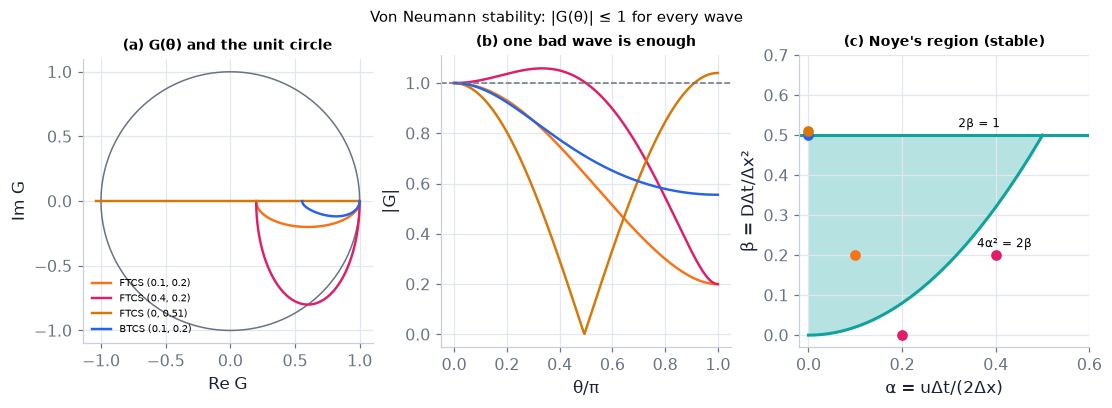

In [35]:
th = np.linspace(0, np.pi, 361)                                # Fourier angles [rad]
cases = [("FTCS (0.1, 0.2)", "ftcs", 0.1, 0.2, C_FT), ("FTCS (0.4, 0.2)", "ftcs", 0.4, 0.2, C_BAD),
         ("FTCS (0, 0.51)", "ftcs", 0.0, 0.51, COLORS["amber"]), ("BTCS (0.1, 0.2)", "btcs", 0.1, 0.2, C_IM)]
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.6))   # the figure and its panels
a1.plot(np.cos(th*2), np.sin(th*2), color=C_EX, lw=1)          # the unit circle
for lab, sch, a_, b_, col in cases:   # repeat the indented lines for each item listed
    G = FD.amplification_factor(th, a_, b_, sch)               # G(theta) for theta in [0, pi]
    a1.plot(G.real, G.imag, color=col, lw=1.6, label=lab)      # (a) the curve G traces in the complex plane
    a2.plot(th/np.pi, np.abs(G), color=col, lw=1.6)            # (b) |G| against theta
a1.set_aspect("equal"); a1.set_xlabel("Re G"); a1.set_ylabel("Im G"); a1.legend(fontsize=6.5, frameon=False, loc="lower left")   # axis labels, with units where the quantity has them
a1.set_title("(a) G(θ) and the unit circle", fontsize=9)   # the panel's title: what this panel shows
a2.axhline(1, color=C_EX, ls="--", lw=1); a2.set_xlabel("θ/π"); a2.set_ylabel("|G|"); a2.set_title("(b) one bad wave is enough", fontsize=9)   # the panel's title: what this panel shows
A_, B_ = np.meshgrid(np.linspace(0, 0.6, 241), np.linspace(0, 0.7, 241))   # (c) the (alpha, beta) plane
region = (4*A_**2 <= 2*B_) & (2*B_ <= 1)                       # Noye's region (10.27)
a3.contourf(A_, B_, region, levels=[0.5, 1.5], colors=[COLORS["teal"]], alpha=0.3)   # filled colour contours of the field
aa = np.linspace(0, 0.5, 100); a3.plot(aa, 2*aa**2, color=COLORS["teal"]); a3.axhline(0.5, color=COLORS["teal"])   # a reference line or band
a3.text(0.36, 0.22, "4α² = 2β", fontsize=8); a3.text(0.32, 0.52, "2β = 1", fontsize=8)   # edge labels, clear of the dots
for (a_, b_), col in zip(((0.1, 0.2), (0.4, 0.2), (0.0, 0.5), (0.0, 0.51), (0.2, 0.0)), (C_FT, C_BAD, C_IM, COLORS["amber"], C_BAD)):   # repeat the indented lines for each item listed
    a3.plot(a_, b_, "o", color=col, ms=6)                      # the five table points of the cell above
a3.set_xlim(-0.02, 0.6); a3.set_ylim(-0.03, 0.7)                  # a margin so the dots on the axes are not cut
a3.set_xlabel("α = uΔt/(2Δx)"); a3.set_ylabel("β = DΔt/Δx²"); a3.set_title("(c) Noye's region (stable)", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("Von Neumann stability: |G(θ)| ≤ 1 for every wave", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c04_von_neumann"); plt.show()   # display the figure

**What you see.** (a) Four curves in the complex plane with the grey unit circle (θ runs from 0 to π, so each is the upper or lower half of a closed loop — its mirror image is the other half); (b) the same four as $\lvert G\rvert$ against $\theta/\pi$ with the line 1; (c) a lens-shaped teal region in the $(\alpha,\beta)$ plane and five dots.

**How to read it.** The orange curve (0.1, 0.2) stays inside the circle: stable. The rose curve (0.4, 0.2) leaves it at intermediate $\theta$ (long waves grow — the $4\alpha^2\le2\beta$ edge); the amber one (0, 0.51) leaves at $G=-1.04$, $\theta=\pi$ (the zigzag — the $2\beta\le1$ edge). The blue BTCS curve lies deep inside. In (c) a dot inside the lens is stable.

**What would change if…** …$D=0$ ($\beta=0$): the region shrinks to the single point $\alpha=0$ — pure convection is never stable with FTCS.

In [36]:
betas = np.linspace(0.05, 0.6, 30 if not FAST else 15)        # slider positions for beta at fixed alpha = 0.15
th = np.linspace(0, np.pi, 181)                                # Fourier angles
def f2(b_):                                                    # |G(theta)| for one beta
    return {"|G(θ)| FTCS, α = 0.15": (th/np.pi, np.abs(FD.amplification_factor(th, 0.15, b_, "ftcs"))),
            "|G| = 1": (th/np.pi, np.ones_like(th))}
fig = slider_figure(f2, "β", betas, xlabel="θ/π", ylabel="|G|", yrange=[0.0, 1.3],
                    title="Slide β: the curve dips below 1 only between 4α² = 0.09 ≤ 2β and 2β ≤ 1")
fig.show()   # display the interactive figure

**What does the code above do?**

The stability edge on the page, no kernel needed: at fixed $\alpha=0.15$ the curve $\lvert G(\theta)\rvert$ pokes above 1 at small $\theta$ while
$2\beta<4\alpha^2=0.09$ (i.e. only for $\beta<0.045$, below the slider's first value 0.05), stays below 1 for $0.045\le\beta\le0.5$, and pokes above 1 at $\theta=\pi$ once $\beta>0.5$.

> ▶️ **Live cell.** The widget below needs a running Python kernel. On the web page it is frozen — open this notebook in Colab (button at the top) or run it locally to drag the sliders.

In [37]:
def g_plot(alpha=0.15, beta=0.3, scheme="ftcs"):               # |G(theta)| and the verdict for free (alpha, beta, scheme)
    th = np.linspace(0, np.pi, 361)   # sample points
    G = FD.amplification_factor(th, alpha, beta, scheme)
    fig, ax = plt.subplots(figsize=(5.5, 2.8))   # the figure and its panels
    ax.plot(th/np.pi, np.abs(G), color=C_FT); ax.axhline(1, color=C_EX, ls="--")   # a reference line or band
    ax.set_xlabel("θ/π"); ax.set_ylabel("|G|"); ax.set_title(FD.stability_verdict(scheme, alpha, beta)["reason"], fontsize=9)   # the panel's title: what this panel shows
    plt.show()   # display the figure
live(g_plot, alpha=(0.0, 0.6, 0.01), beta=(0.0, 0.8, 0.01), scheme=["ftcs", "btcs", "upwind", "cn"])   # sliders + a scheme menu

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='alpha', layout=Layout(width…

<function __main__.g_plot(alpha=0.15, beta=0.3, scheme='ftcs')>

**What does the code above do?**

A live version of the slider figure above with both numbers free and a choice of scheme (kernel only; the page shows the slider figure).

#### 🎮 Interactive: Why does β = 0.51 blow up when 0.50 does not?

**Why interactive rather than a static figure:** Dragging the point $(\alpha,\beta)$ across the edge of Noye's region, you watch the $G(\theta)$ curve cross the unit circle and, on the same clock, a $10^{-10}$ kick grow into a zigzag — the causal chain from a number in a formula to garbage on the screen.

**What to try:**
- Press the 'β = 0.51' preset and play: which wave grows first? (the status names it)
- Set β = 0 and drag α: every curve leaves the circle — pure convection is hopeless for FTCS.
- Switch the scheme to BTCS and set β = 100: the curve shrinks towards the origin.

In [38]:
show_viz("ch10", "von_neumann_amplification")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/von_neumann_amplification]

**What would change if…** …there is no diffusion at all (a pollutant in a fast river, a tracer in the upper ocean)? FTCS is useless — but taking the convective difference
from the upstream side fixes it, at a price. C05.

### 🧩 Upwind differencing and the CFL condition (closed by the Lax equivalence theorem) `C05`

*The question:* Why must the time step shrink whenever the grid is refined — and what does the flow speed have to do with it?

*In one line:* $u\dfrac{\Delta t}{\Delta x}\le1$ *(10.30)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **first-order wave equation and characteristics** — T_t + uT_x = 0 carries every value unchanged along the lines x − ut = const (Ch. 7 P174).
- **separation of variables for a PDE** — try T = X(x)·τ(t) and add up the solutions — how the heated-rod series is built (Ch. 7 P167).
- **animate and show_animation** — `animate(update, frames)` builds a matplotlib animation; `show_animation` plays it inline (Ch. 1 P16).

#### The problem in plain words

A weather model with 25 km grid boxes must never let the fastest signal — a sound or gravity wave at 200–300 m/s — cross more than one box per time
step, so its time step is at most about a minute and a half (the climate note below computes it). Halve the box size and the step must halve too:
that is why doubling a climate model's resolution costs about eight times the computing (twice the columns in each direction and twice the steps).
Where does such a rule come from?

#### The idea

```
t_{n+1}            ● new value at x_i
                  ╱                    the characteristic x − ut = const through the new point
                 ╱  slope 1/u           lands at x_i − uΔt at the old level
t_n     ●───────◆───────●             ◆ = the foot of the characteristic
      x_{i−1}         x_i
CFL:  the foot must lie between the stencil's points  ⇔  0 ≤ uΔt/Δx ≤ 1
```

Pure convection copies $T$ along lines $x-ut=$ const. The update at $x_i$ may only use numbers from the side the flow comes from (upwind), and those numbers must bracket the foot of the line.

> 📎 **Primer — domain of dependence and characteristics.** `P227` · For $T_t+uT_x=0$ the value at $(x,t)$ is the value that was at $(x-u\Delta t,\,t-\Delta t)$: information travels along the lines $x-ut=$ const (the
characteristics of Ch. 7, P174). The *domain of dependence* of a point is the set of earlier data that can influence it — for this PDE a single point
upstream; for a stencil it is the stencil's points. A scheme can only be right if its domain contains the PDE's.

In [39]:
u, dt, x = 2.0, 0.1, 1.0             # speed [m/s], step [s], where we want the new value [m]
foot = x - u*dt                      # the value at x now came from here one step ago
print(foot)                          # 0.8 m: with dx = 0.1 m that is 2 cells upstream, outside a 1-cell stencil (C = 2)

0.8


📝 **Note.** **N16 [B]** **First-order upwind (10.29):** $T^{n+1}_i=T^n_i-2\alpha(T^n_i-T^n_{i-1})$ — the convective difference is taken backwards, from the upstream
neighbour ($u>0$), and $2\alpha=u\Delta t/\Delta x=C$ is the **Courant number**.

$$ T^{n+1}_i=T^n_i-2\alpha\,(T^n_i-T^n_{i-1}) \qquad \text{(10.29)} $$

> ⚠️ **Printed slip.** **The book prints the upwind scheme $T^{n+1}_i=T^n_i-2\alpha(T^n_i-T^n_{i-1})$ and the condition $u\frac{\Delta t}{\Delta x}\le1$ without the sign of $u$;
the correct statement is:** for $u<0$ the upstream neighbour is $i+1$, and the condition is $\lvert u\rvert\Delta t/\Delta x\le1$ (slip #11).
`scheme='upwind'` takes the side from the sign of $u$; `scheme='upwind_printed'` always uses $i-1$ and blows up for $u<0$ (the from-scratch cell
below shows it, and a test checks it).

#### 🧮 Derivation — Upwind and the CFL condition: $\lvert G\rvert^2=1-2C(1-C)(1-\cos\theta)$, stable iff $u\frac{\Delta t}{\Delta x}\le1$ `D08` (Eq. 10.30: $u\dfrac{\Delta t}{\Delta x}\le1$)

**What we want to show.** Find when the upwind scheme (10.29), $T^{n+1}_i=T^n_i-2\alpha\,(T^n_i-T^n_{i-1})$ is stable, and see why the answer is 'the characteristic must stay inside the stencil'.

**Assumptions.** Pure convection with constant u > 0 (step 1); periodic grid.

**The plan.**

1. Write the scheme with the Courant number.
2. Find G (D04 moves).
3. Compute ∣G∣² and read its sign.
4. Special cases and the sign of u.

**Tools we use** (each explained before this point): D04 moves · Euler's formula (P45) · cos² + sin² = 1 · domain of dependence (primer P227).

**We start from**

$$ T^{n+1}_i=T^n_i-2\alpha(T^n_i-T^n_{i-1})\ \text{(10.29), u > 0} $$

*In words:* the convective difference taken from the upstream side.

---

**Step 1 of 9 — Name the Courant number.**

$$ C=2\alpha=u\frac{\Delta t}{\Delta x},\qquad T^{n+1}_j=T^n_j-C(T^n_j-T^n_{j-1}) $$

- *Why we can do this:* The book's α carries a ½ from the centred difference; the upwind difference has none, so 2α = C appears. Index renamed j.
- *In words:* C is the number of cells the flow moves per step.

---

**Step 2 of 9 — Insert one wave.**

$$ G=1-C\big(1-e^{-\mathrm i\theta}\big) $$

- *Why we can do this:* The error obeys the linear rule (D04 step 3); with $\xi_j=\hat\xi e^{\mathrm i\pi kx_j}$ the upstream neighbour is $e^{-\mathrm i\theta}$ times it; divide out the wave (D04 step 9).
- *In words:* one complex factor per wave.

---

**Step 3 of 9 — Split real and imaginary parts.**

$$ G=(1-C+C\cos\theta)-\mathrm iC\sin\theta $$

- *Why we can do this:* $e^{-\mathrm i\theta}=\cos\theta-\mathrm i\sin\theta$ (P45). We need G as 'real part + i × real part' because its squared size is then simply the sum of the two squares.
- *In words:* real part: what is kept; imaginary part: the turn.

---

**Step 4 of 9 — Square and add.**

$$ \lvert G\rvert^2=(1-C+C\cos\theta)^2+C^2\sin^2\theta $$

- *Why we can do this:* ∣a + ib∣² = a² + b² (P153).
- *In words:* the squared factor.

---

**Step 5 of 9 — Expand and use cos² + sin² = 1.**

$$ \lvert G\rvert^2=(1-C)^2+2C(1-C)\cos\theta+C^2 $$

- *Why we can do this:* $(1-C+C\cos\theta)^2=(1-C)^2+2C(1-C) \cos\theta+C^2\cos^2\theta$ and $C^2\cos^2\theta+C^2\sin^2\theta=C^2$. Multiplying out the square is plain algebra; the identity cos² + sin² = 1 then removes θ from the two C² terms.
- *In words:* three terms left.

---

**Step 6 of 9 — Regroup around 1.**

$$ \lvert G\rvert^2=1-2C(1-C)(1-\cos\theta) $$

- *Why we can do this:* $(1-C)^2+C^2=1-2C(1-C)$; the remaining terms share the factor 2C(1 − C).
- *In words:* one minus a product.

---

**Step 7 of 9 — Read the sign.**

$$ \lvert G\rvert^2\le1\ \forall\theta\iff C(1-C)\ge0\iff0\le C\le1\ \text{(10.30)} $$

- *Why we can do this:* 1 − cos θ lies in [0, 2] and is positive for θ ≠ 0, so ∣G∣² ≤ 1 for all waves exactly when C(1 − C) ≥ 0.
- *In words:* stable iff the flow moves at most one cell per step: the CFL condition.

---

**Step 8 of 9 — Look at the edges.**

$$ C=1:\ G=e^{-\mathrm i\theta};\qquad C>1:\ \lvert G(\pi)\rvert^2=(2C-1)^2>1 $$

- *Why we can do this:* C = 1 turns the rule into $T^{n+1}_j=T^n_{j-1}$, an exact shift; for C > 1 the zigzag grows (C = 1.1: ∣G∣ = 1.2). Physically (P227): the foot of the characteristic, $x_j-u\Delta t$, lies C cells upstream and must stay within the stencil $[x_{j-1},x_j]$.
- *In words:* on the edge exact, beyond it explosive.

---

**Step 9 of 9 — Let u be negative.**

$$ u<0:\quad T^{n+1}_j=T^n_j-C(T^n_{j+1}-T^n_j),\ \ \lvert C\rvert=\frac{\lvert u\rvert\Delta t}{\Delta x}\le1 $$

- *Why we can do this:* With the printed stencil and u < 0, C < 0 and C(1 − C) < 0: unstable for every step. The upstream side is now j + 1 (slip #11); the same algebra gives ∣C∣ ≤ 1.
- *In words:* take the difference from where the flow comes from, whichever way that is.

---

**Result**

$$ \begin{array}{l}\lvert G\rvert^2=1-2C(1-C)(1-\cos\theta)\ \text{, stable iff 0 ≤ C = uΔt/Δx ≤ 1 (10.30), with the side chosen by} \\ \text{the sign of u}\end{array} $$

*In words:* a fluid particle must not cross more than one cell per step.

**What it means.** The CFL condition sets the time step of every explicit weather and ocean model (with the gravity- or sound-wave speed, C05's climate note) and of MacCormack (D18, with the sound speed).

**Check it.** C dimensionless ✓. C = ½, θ = π: ∣G∣² = 1 − 2·½·½·2 = 0 (the zigzag killed in one step) ✓ (tiny example). The numerical diffusivity of the stable scheme, ∣u∣Δx(1 − C)/2, vanishes at C = 1 — consistent with the exact shift.

> ⚠️ **Common confusion (traps in `D08`):** Writing C = α (the ½ belongs to the centred difference); thinking C = 1 is 'marginal' (it is exact); using the upwind side of (10.29), $T^{n+1}_i=T^n_i-2\alpha\,(T^n_i-T^n_{i-1})$ when u < 0 (slip #11).

#### ✏️ Tiny example: one upwind step, and the CFL edge

$u=1$ m/s, $\Delta x=0.1$ m, $\Delta t=0.05$ s: $C=0.5$.
1. Start $[0,0,1,0,0]$.
2. Node 2: $1-0.5(1-0)=0.5$; node 3: $0-0.5(0-1)=0.5$; the others stay 0.
3. New $[0,0,0.5,0.5,0]$: the spike moved half a cell (as it should, $u\Delta t=0.05$ m) but is now spread over two cells — upwind smears.
4. The zigzag $\theta=\pi$: $\lvert G\rvert^2=1-2C(1-C)(1-\cos\pi)=1-4\times0.25=0$ — killed in one step.
5. $C=1$: $G=e^{-\mathrm i\theta}$, an exact shift by one cell.
6. $C=1.1$: $\lvert G(\pi)\rvert^2=1-2(1.1)(-0.1)(2)=1.44$, $\lvert G\rvert=1.2$ — the zigzag grows 20 % per step.

In [40]:
print("one upwind step:", FD.transport_1d_step(np.array([0, 0, 1, 0, 0.0]), 0.25, 0.0, "upwind", periodic=True))   # C = 2 alpha = 0.5
for C in (0.5, 1.0, 1.05):                                     # three Courant numbers
    r = FD.advect_periodic("square", C=C, n_cells=100, n_rev=1.0, scheme="upwind")   # a square pulse, one revolution
    print(f"C = {C:4.2f}: {r['steps']:3d} steps, max T/max T0 = {r['amplitude_ratio']:10.4g}, rms error = {r['rms_error']:.3g}")   # show the numbers computed above
print(FD.stability_verdict("upwind", 0.525, 0.0)["reason"])   # alpha = 0.525 is C = 1.05
print("upwind numerical diffusivity |u| dx (1 - C)/2 at u = 1 m/s, dx = 0.01 m, C = 0.5:",
      FD.numerical_diffusivity(1.0, 0.01, scheme="upwind", C=0.5), "m²/s")

one upwind step: [0.  0.  0.5 0.5 0. ]
C = 0.50: 200 steps, max T/max T0 =     0.8418, rms error = 0.186
C = 1.00: 100 steps, max T/max T0 =          1, rms error = 0
C = 1.05:  95 steps, max T/max T0 =       1308, rms error = 359
unstable: C > 1, the characteristic leaves the stencil
upwind numerical diffusivity |u| dx (1 - C)/2 at u = 1 m/s, dx = 0.01 m, C = 0.5: 0.0025 m²/s


**What does the code above do?**

1. One upwind step reproduces the tiny example $[0,0,0.5,0.5,0]$.
2. `advect_periodic` carries a square pulse once round a periodic domain of 100 cells ($N/C$ steps). At $C=0.5$ the pulse is smeared (lower and
   rounder: the printed amplitude ratio is below 1); at $C=1$ it returns *exactly* (error 0 — every step is an exact shift); at $C=1.05$ the zigzag has
   grown by three orders of magnitude in a single revolution.
3. The verdict names the reason: the characteristic's foot has left the stencil.
4. The smearing has a size: upwind behaves like a diffusivity $\lvert u\rvert\Delta x(1-C)/2$ added to the flow (the time-dependent twin of C09's result, D17).

In [41]:
# from scratch: an upwind loop over the nodes for u > 0, and the printed stencil for u < 0
rng = np.random.default_rng(3); T = rng.random(40)             # a random periodic profile, 40 nodes
C = 0.6                                                        # Courant number u dt/dx
new = np.empty_like(T)
for i in range(len(T)):                                        # one node at a time
    new[i] = T[i] - C*(T[i] - T[i - 1])                        # (10.29); T[-1] is the last node: Python wraps round (periodic)
assert np.allclose(new, FD.transport_1d_step(T, C/2, 0.0, "upwind", periodic=True))   # alpha = C/2
Tu, Tp = T.copy(), T.copy()                                    # now u < 0: alpha = -C/2
for _ in range(50):                                            # 50 steps
    Tu = FD.transport_1d_step(Tu, -C/2, 0.0, "upwind", periodic=True)          # side chosen from the sign of u: i+1
    Tp = FD.transport_1d_step(Tp, -C/2, 0.0, "upwind_printed", periodic=True)  # the printed stencil: always i-1
print(f"after 50 steps with u < 0: correct upwind max = {np.abs(Tu).max():.3f}, printed stencil max = {np.abs(Tp).max():.3g}")   # show the numbers computed above
assert np.abs(Tp).max() > 1e3*np.abs(T).max() and np.abs(Tu).max() <= np.abs(T).max() + 1e-12   # printed form explodes (slip #11)

after 50 steps with u < 0: correct upwind max = 0.551, printed stencil max = 1.43e+16


**What does the code above do?**

1. The loop is (10.29), $T^{n+1}_i=T^n_i-2\alpha\,(T^n_i-T^n_{i-1})$ written node by node; `T[i - 1]` with `i = 0` is `T[-1]`, the last node — Python's negative index makes the grid periodic.
   It matches `transport_1d_step(..., "upwind")` with $\alpha=C/2$.
2. With $u<0$ the correct scheme takes the difference from the right (the flow comes from there) and stays bounded; the printed stencil keeps
   using the left neighbour — downwind — and grows by more than a factor $10^3$ in 50 steps (slip #11).

**Climate hook (our note).** **Every explicit weather and ocean model lives under this rule.** The fastest signal in a shallow-water or hydrostatic model is
the gravity wave, of speed $\sqrt{g_0H}$ — the shallow limit $kH\ll1$ of Ch. 7's dispersion relation $\omega^2=gk\tanh kH$ *(7.28)* — and the CFL condition
$u\frac{\Delta t}{\Delta x}\le1$ *(10.30)* with $u\to\sqrt{g_0H}$ gives the largest time step. The cell computes it for the ocean and the atmosphere. This is why models
treat the fastest waves implicitly (C02's BTCS idea) or split them off (C11).

In [42]:
c_ocean = WV.phase_speed(1e-7, 4000.0)                         # a very long wave (k -> 0) on 4000 m of water: sqrt(g H) [m/s]
print(f"ocean gravity-wave speed sqrt(g H) = {c_ocean:.1f} m/s")   # show the numbers computed above
for dx_km in (100, 25):                                        # two ocean-model grid spacings [km]
    print(f"  dx = {dx_km:3d} km: dt <= {ch10.cfl_time_step(c_ocean, dx_km*1e3):.1f} s")   # (10.30) with u -> c
print(f"atmosphere, Lamb-wave speed 320 m/s, dx = 25 km: dt <= {ch10.cfl_time_step(320.0, 25e3):.1f} s")   # show the numbers computed above

ocean gravity-wave speed sqrt(g H) = 198.1 m/s
  dx = 100 km: dt <= 504.8 s
  dx =  25 km: dt <= 126.2 s
atmosphere, Lamb-wave speed 320 m/s, dx = 25 km: dt <= 78.1 s


**What does the code above do?**

1. `WV.phase_speed(k, H)` is Ch. 7's $c=\sqrt{(g/k)\tanh kH}$; for $kH\ll1$ it is $\sqrt{gH}$ (about 198 m/s for a 4 km deep ocean).
2. `cfl_time_step(c, dx)` is $\Delta t=\Delta x/c$ — the CFL condition with the wave speed in place of $u$.
3. The Lamb wave is the fastest wave an atmospheric model resolves: a horizontally travelling sound–gravity wave of the whole air column (the external
   acoustic–gravity mode), moving at about 310–320 m/s — close to the speed of sound. We take 320 m/s.

> 📎 **Primer — well-posed problem.** `P228` · A problem is well posed (Hadamard) when a solution exists, is unique, and depends continuously on the data — a small change in the start or boundary
values gives a small change in the answer. The heat and advection equations with sensible boundary conditions are; running the heat equation backwards
in time is not (tiny wiggles explode). The Lax theorem below assumes it.

In [43]:
import numpy as np   # arrays and maths
k = np.array([1, 10, 100])           # wavenumbers of a small wiggle
print(np.exp(-k**2*0.01))            # forward heat equation, t = 0.01: wiggles shrink (well posed)
print(np.exp(+k**2*0.01))            # backward: the k = 100 wiggle grows by e^100 (ill posed)

[0.99   0.3679 0.    ]
[1.0101e+00 2.7183e+00 2.6881e+43]


📝 **Note.** **N18 [B]** **The Lax equivalence theorem** (Richtmyer & Morton 1967, in our words): *for a well-posed linear initial-value problem and a consistent
scheme, stability is necessary and sufficient for convergence.* So the three properties of C03 collapse into two checks we can do on paper: consistency
(Taylor, C03) and stability (von Neumann, C04–C05). The book gives no proof; the animation below shows it at work on the heated rod.

In [44]:
nx_ = 20; xr = np.linspace(0, 1, nx_ + 1); dxr = xr[1] - xr[0]   # the rod of N113: 20 cells, T_w = 1 (ours)
nsteps = 690; frames = 20 if not FAST else 12                  # march to the blow-up step of beta = 0.51
runs = {}
for b in (0.50, 0.51):                                         # the same rule with two diffusion numbers
    T = np.zeros(nx_ + 1); T[0] = T[-1] = 1.0                  # cold rod, ends suddenly held at T_w = 1
    snaps, errs = [], []
    for k in range(1, nsteps + 1):                             # march step by step, keeping every profile and its error
        T = FD.transport_1d_step(T, 0.0, b, "ftcs", periodic=False, g=1.0, T_L=1.0)   # (10.10) with u = 0
        errs.append(np.abs(T - ch10.rod_heating_exact(xr, k*b*dxr**2, 1.0, 1.0)).max())   # max error against (10.199)
        snaps.append(T.copy())   # store the value
    runs[b] = (np.array(snaps), np.array(errs))
idx = np.linspace(0, nsteps - 1, frames).astype(int)           # the steps shown as frames
fig, axs = plt.subplots(2, 2, figsize=(6.4, 4.0), gridspec_kw=dict(height_ratios=[1.2, 1]), layout="none")   # no layout engine: we set the margins below
arts = []
for c_, b in enumerate((0.50, 0.51)):   # repeat the indented lines for each item listed
    ax = axs[0, c_]; ax.set_xlim(0, 1); ax.set_ylim(-0.2, 1.4); ax.set_title(f"β = {b}", fontsize=9)   # the panel's title: what this panel shows
    ex_line, = ax.plot(xr, ch10.rod_heating_exact(xr, 0.0, 1.0, 1.0), "--", color=C_EX)   # exact series (10.199)
    num_line, = ax.plot(xr, runs[b][0][0], "o-", color=C_FT if b == 0.5 else C_BAD, ms=3)  # FTCS
    ax.set_xlabel("x [m]")   # axis labels, with units where the quantity has them
    ae = axs[1, c_]; ae.set_xlim(0, nsteps); ae.set_ylim(1e-17, 10); ae.set_yscale("log")   # axis range / scale chosen so the feature discussed below is visible
    err_line, = ae.plot([], [], color=C_FT if b == 0.5 else C_BAD); ae.set_xlabel("step n")   # axis labels, with units where the quantity has them
    arts.append((b, ex_line, num_line, err_line))   # store the value
axs[0, 0].set_ylabel("T [–]"); axs[1, 0].set_ylabel("max error")   # axis labels, with units where the quantity has them
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.12, top=0.93, hspace=0.45, wspace=0.25)   # fixed margins
def update(f):                                                 # frame f shows step idx[f]
    k = idx[f]
    for b, ex_line, num_line, err_line in arts:   # repeat the indented lines for each item listed
        ex_line.set_ydata(ch10.rod_heating_exact(xr, (k + 1)*b*dxr**2, 1.0, 1.0))   # the exact profile at this time
        num_line.set_ydata(np.clip(runs[b][0][k], -0.2, 1.4))  # the computed profile (clipped to the axes)
        err_line.set_data(np.arange(1, k + 2), runs[b][1][:k + 1])   # the error history so far
    return [a for t_ in arts for a in t_[1:]]   # the values for this call
show_animation(animate(update, frames=frames, fig=fig, interval=120), player="frames")   # step through with the frame player
print("steps to blow-up (max|T| > 1e6) at beta = 0.51:", FD.lax_demo(betas=(0.51,))[0.51]["step_blown"])   # show the numbers computed above

steps to blow-up (max|T| > 1e6) at beta = 0.51: 690


**What you see.** Two rods heated from both ends, marched by the same FTCS rule; top: computed dots on the exact series (grey dashed), bottom: the
maximum error against the step number on a log axis.

**How to read it.** Both runs are consistent. On the left ($\beta=0.50$) the error — the ordinary discretisation error — stays small and keeps falling as the
rod heats up; on the right ($\beta=0.51$) it first follows the same curve, then turns into a straight rising line (exponential growth by $\lvert1-4\beta\rvert=1.04$
per step) until a zigzag appears in the profile and the run is useless — the 2 % larger step crossed $\lvert G\rvert=1$ and the scheme stopped converging.

**What would change if…** …we ran upwind advection at $C=0.9$ and $C=1.1$: the same story at the CFL edge — bounded at 0.9, exploding at 1.1 (the
explainer below lets you try it).

📝 **Note.** **N113 [B]** **An exact solution to test against — the heated rod (Exercise 10.3 uses this form):** a rod $0\le x\le1$ at temperature 0, whose ends are
suddenly held at $T_w$, has $T=T_w-\sum_{m=1}^{\infty}\frac{4T_w}{(2m-1)\pi}\sin[(2m-1)\pi x]\,e^{-D(2m-1)^2\pi^2t}$ — equation (10.199) is this series (a Fourier
sine series, as for Couette start-up in Ch. 8). We use our own $T_w=1$ and grid; the exercise's inputs and answers are not reproduced.

$$ T(x,t)=T_w-\sum_{m=1}^{\infty}\frac{4T_w}{(2m-1)\pi}\sin\big[(2m-1)\pi x\big]\,e^{-D(2m-1)^2\pi^2t} \qquad \text{(10.199)} $$

In [45]:
xs3 = np.array([0.0, 0.25, 0.5])                               # the wall and two interior points [m]
T3 = ch10.rod_heating_exact(xs3, 0.05, 1.0, 1.0)               # (10.199) with D = 1, T_w = 1, at t = 0.05
print("T =", np.round(T3, 4))   # show the numbers computed above
xf = np.linspace(0, 1, 201); h_ = xf[1] - xf[0]; t0, dtf = 0.05, 1e-5   # a fine grid to test the PDE residual
Tt = (ch10.rod_heating_exact(xf, t0 + dtf, 1.0, 1.0) - ch10.rod_heating_exact(xf, t0 - dtf, 1.0, 1.0))/(2*dtf)   # dT/dt
Txx = np.gradient(np.gradient(ch10.rod_heating_exact(xf, t0, 1.0, 1.0), h_), h_)   # d2T/dx2 (P22)
print("max |T_t - T_xx| inside:", np.abs(Tt - Txx)[3:-3].max())   # show the numbers computed above
assert T3[0] == 1.0 and np.abs(Tt - Txx)[3:-3].max() < 1e-2   # the wall is T_w; the series solves T_t = D T_xx (to FD accuracy)

T = [1.     0.4468 0.2277]
max |T_t - T_xx| inside: 0.0006900602689263735


**What does the code above do?**

1. The wall value is exactly $T_w=1$; inside, the rod is still warming ($t=0.05$ is about half a diffusion time $1/(D\pi^2)$).
2. Central differences of the series in $t$ and $x$ satisfy $T_t=DT_{xx}$ to the accuracy of the differences — the series is the exact solution
   used by the Lax animation.

> 📎 **Primer — Péclet number (global R and cell R_cell).** `P229` · Advection against diffusion, as one ratio: over a length $\ell$, advection moves heat at a rate $\sim uT/\ell$, diffusion at $\sim DT/\ell^2$; their
ratio is $u\ell/D$. With $\ell=L$ (the domain) it is the global Péclet number $R=uL/D$ (10.87) — the Reynolds number's twin for a scalar. With
$\ell=\Delta x$ it is the cell Péclet number $R_{cell}=u\Delta x/D$ (10.31): how advective one grid cell is.

In [46]:
u, L, dx, D = 1.0, 1.0, 0.01, 0.005  # speed [m/s], length [m], cell [m], diffusivity [m^2/s]
print(u*L/D, u*dx/D)                 # R = 200 (strongly advective), R_cell = 2 (the edge of C09)

200.0 2.0


📝 **Note.** **N19 [B]** **The cell Péclet condition (10.31):** $R_{cell}=u\frac{\Delta x}{D}\le2$ to avoid wiggles next to a thin layer; with $u=1$ m/s, $\Delta x=0.01$ m,
$D=0.005$ m²/s, $R_{cell}=2$ exactly. The reason — the discrete solution changes sign — is worked out in C09 (D16).

$$ R_{cell}=u\dfrac{\Delta x}{D}\le2 \qquad \text{(10.31)} $$

In [47]:
print(FD.cell_peclet(1.0, 0.01, 0.005))                        # R_cell = |u| dx / D (10.31)

2.0


**What does the code above do?**

`cell_peclet(u, dx, D)` = $\lvert u\rvert\Delta x/D$ = 2.0 — on the edge of the condition (10.31), $R_{cell}=u\dfrac{\Delta x}{D}\le2$.

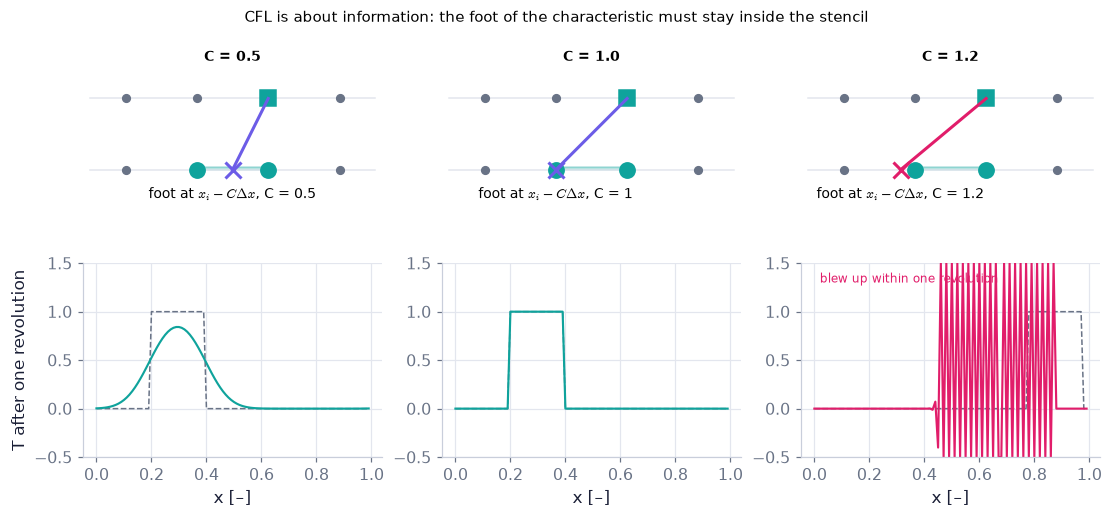

In [48]:
fig, axs = plt.subplots(2, 3, figsize=(10, 4.6), gridspec_kw=dict(height_ratios=[1.1, 1]))   # the figure and its panels
for c_, C in enumerate((0.5, 1.0, 1.2)):                        # inside, on and outside the CFL edge
    characteristic_diagram(axs[0, c_], C)                       # the upwind stencil, the characteristic and its foot
    axs[0, c_].set_title(f"C = {C}", fontsize=9)   # the panel's title: what this panel shows
    r = FD.advect_periodic("square", C=C, n_cells=100, n_rev=1.0, scheme="upwind")   # the square pulse, one revolution
    ax = axs[1, c_]
    ax.plot(r["x"], r["exact"], "--", color=C_EX, lw=1)        # exact: the pulse returns unchanged
    ax.plot(r["x"], np.clip(r["T"], -0.5, 1.5), color=C_UP if C <= 1 else C_BAD, lw=1.4)   # upwind (clipped to the axes)
    ax.set_ylim(-0.5, 1.5); ax.set_xlabel("x [–]")   # axis labels, with units where the quantity has them
    if C > 1:
        msg = (f"grew {r['amplitude_ratio']:.0f}× in one revolution" if np.isfinite(r["amplitude_ratio"]) and not r["blew_up"]
               else "blew up within one revolution")          # the growth factor, or a blow-up message
        ax.text(0.02, 1.3, msg, color=C_BAD, fontsize=8)   # a label written on the plot
axs[1, 0].set_ylabel("T after one revolution")   # axis labels, with units where the quantity has them
fig.suptitle("CFL is about information: the foot of the characteristic must stay inside the stencil", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c05_cfl"); plt.show()   # display the figure

**What you see.** Top: three $x$–$t$ stencil diagrams in which the foot of the characteristic (✕) slides left as $C$ grows and leaves the two-point stencil at $C>1$. Bottom: the square pulse after one revolution — smeared at $C=0.5$, exact at $C=1$, a growing zigzag at $C=1.2$ (the label says what happened).

**How to read it.** Inside the stencil: stable (and smeared); on the edge: exact; outside: unstable.

**What would change if…** …$u<0$ with the printed stencil $T^{n+1}_i=T^n_i-2\alpha(T^n_i-T^n_{i-1})$ (10.29): the foot would be on the *other* side of the node — unstable for every $C$ (slip #11).

In [49]:
Cs = np.linspace(0.1, 1.0, 24 if not FAST else 12)             # slider positions for the Courant number
def f3(C):                                                      # one revolution of the square pulse at this C
    up = FD.advect_periodic("square", C=C, n_cells=100, scheme="upwind")
    mc = FD.advect_periodic("square", C=C, n_cells=100, scheme="maccormack")
    return {"exact": (up["x"], up["exact"]), "upwind": (up["x"], up["T"]), "MacCormack": (mc["x"], mc["T"])}   # the values for this call
fig = slider_figure(f3, "C", Cs, xlabel="x [–]", ylabel="T", yrange=[-0.3, 1.35],
                    title="Slide C: upwind smears less as C → 1; MacCormack keeps the height but ripples")
fig.show()   # display the interactive figure

**What does the code above do?**

Every slider position is one revolution of the square pulse on 100 cells: upwind smears less as $C\to1$ (exact at 1); MacCormack (C10) keeps the
pulse's height but leaves ripples behind it — first order pays in amplitude, second order in phase.

#### 🎮 Interactive: Why must the time step shrink with the grid?

**Why interactive rather than a static figure:** The Courant slider moves the characteristic across the stencil's edge at exactly $C=1$ while, on the same clock, the pulse stays clean, smears, ripples or explodes; toggling upwind, MacCormack and FTCS separates numerical diffusion from dispersion.

**What to try:**
- Press 'C = 1 exact shift' and play: nothing smears.
- Drag C to 1.05 and watch the characteristic's foot leave the stencil — then the blow-up.
- Compare upwind and MacCormack at C = 0.8 on the square pulse: which loses height, which ripples?

In [50]:
show_viz("ch10", "upwind_cfl_advection")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/upwind_cfl_advection]

**What would change if…** …the problem were steady and both effects mattered (heat carried to a hot wall and conducted away)? The time step disappears, but the grid still has
to resolve the thin layer where diffusion wins: C09. First, §10.3 builds the second family of methods — finite elements — on the same model problem.

---

## 10.3 Finite-Element Method

**What is this section about?** Finite differences ask the equation to hold at grid points. Finite elements ask something weaker and more flexible:
that the equation hold *on average*, weighted by every member of a family of test functions. Written that way (the weak form, C06), the problem
can be solved with simple building blocks — tent-shaped "hat" functions — whose weights become the unknowns (Galerkin, C07); the integrals are
computed one small element at a time and added up (assembly, C08). On a uniform 1-D mesh the result is almost the FD scheme you already know;
the payoff comes in 2-D and 3-D, where elements can follow a curved body (the cylinder of §10.5, a coastline, an artery).

### 🧩 The weak form; essential and natural boundary conditions `C06`

*The question:* How can an equation 'hold on average' — and why does that make one boundary condition automatic?

*In one line:* $\text{find }T\in\mathcal S:\ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)\ \ \forall w\in V$ *(10.36)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **product rule** — d(fg) = f dg + g df (Ch. 1 P38).
- **integration by parts** — ∫f g′ dx = [fg] − ∫f′ g dx — the product rule integrated (Ch. 9 P218a).
- **fundamental theorem of calculus** — ∫ₐᵇ F′ dx = F(b) − F(a) (Ch. 2 P84).
- **trapezoid rule np.trapezoid** — `np.trapezoid(y, x)` integrates sampled data with straight pieces (Ch. 9 P203).

#### The problem in plain words

A finite-element approximation is made of straight pieces joined at kinks. Its second derivative is zero on every piece and infinite at the kinks
— so it can never satisfy $D\,\partial^2T/\partial x^2$ point by point. We need a version of (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ that only asks for *first* derivatives. The trick:
multiply the equation by a smooth-enough weight $w$, integrate over the rod, and move one derivative from $T$ onto $w$. Nothing is lost — if the
averaged equation holds for every weight, the pointwise one holds too — and the flux condition at the end drops into the equation by itself.

#### The idea

```
strong:  T_t + u T_x − D T_xx = 0  at every x          (10.1)
   × w(x), ∫₀ᴸ dx          (w = 0 where T is prescribed: x = 0)
∫ T_t w + u ∫ T_x w − D ∫ T_xx w = 0                    (10.34)
   ∫ T_xx w = [T_x w]₀ᴸ − ∫ T_x w_x      (integration by parts)
∫ T_t w + u ∫ T_x w + D ∫ T_x w_x = D T_x(L) w(L) = D q w(L)      (10.35)–(10.36)
         only first derivatives left ──┘          └── the Neumann datum q enters here: "natural"
```

*The numbered equations in the sketch:* $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ *(10.1)* · $\int_0^LT_tw\,dx+u\int_0^LT_xw\,dx=D\int_0^LT_{xx}w\,dx$ *(10.34)* · $\int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=D\big[T_xw\big]_0^L=Dq\,w(L)$ *(10.35)* · $\text{find }T\in\mathcal S:\ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)\ \ \forall w\in V$ *(10.36)*

📝 **Note.** **N20 [C]** **Strong (classical) form** = the PDE (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$ with its boundary conditions (10.2), $T(0,t)=g,\ \ \dfrac{\partial T}{\partial x}(L,t)=q$ and initial condition (10.3), $T(x,0)=T_0(x),\ 0\le x\le L$ — "strong" because it asks
for the equation at every point.

> 📎 **Primer — test functions and the spaces H¹, S and V.** `P230` · A *test function* $w(x)$ is a weight we multiply the equation by; a weak statement says "for every $w$ in a family". The family here is $H^1$:
functions whose slope is square-integrable, $\int_0^L(\partial w/\partial x)^2dx<\infty$ — kinks allowed, jumps not ("finite slope energy"). The
*trial* space $\mathcal S$ = the $H^1$ functions with the Dirichlet value built in, $T(0)=g$ (10.32); the *test* space $V$ = the same with $w(0)=0$ (10.33).

In [51]:
import numpy as np   # arrays and maths
x = np.linspace(0, 1, 100001)   # sample points
hat = np.maximum(0, 1 - np.abs(x - 0.5)/0.25)          # a tent: kinks at 0.25, 0.5, 0.75
slope = np.gradient(hat, x)                            # +-4 on the sides, 0 elsewhere
print(np.trapezoid(slope**2, x))                       # about 8 (16 x 0.5): finite, so the tent is in H^1

7.999759999999979


📝 **Note.** **N21 [B]** **The two spaces (10.32)–(10.33):** $\mathcal S=\{T\,\vert\,T\in H^1,\ T(0)=g\}$ and $V=\{w\,\vert\,w\in H^1,\ w(0)=0\}$ (the book writes $S$; we
write $\mathcal S$ so it is not the Strouhal number). The test functions vanish exactly where $T$ is prescribed — there we already know the answer
and must not "test" it.

#### 🧮 Derivation — The weak form $\int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)$ `D09` (Eq. 10.36: $\text{find }T\in\mathcal S:\ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)\ \ \forall w\in V$)

**What we want to show.** Rewrite the transport problem so that only first derivatives of T appear and the flux condition at x = L is built in.

**Assumptions.** T and w in H¹ (square-integrable slopes); w(0) = 0 (w ∈ V, used in step 7); T satisfies the Neumann datum (step 8).

**The plan.**

1. Multiply by a test function that vanishes where T is prescribed.
2. Integrate over the rod.
3. Move one derivative from T onto w (integration by parts).
4. Insert the end conditions.

**Tools we use** (each explained before this point): Test functions and the spaces H¹, 𝒮, V (primer P230) · product rule (Ch. 1 P38) · integration by parts (Ch. 9 P218a) · the fundamental theorem of calculus (Ch. 2 P84).

**We start from**

$$ \frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L\ \text{(10.1)},\qquad T(0,t)=g,\ \ \dfrac{\partial T}{\partial x}(L,t)=q\ \text{(10.2)} $$

*In words:* the equation at every point plus its two end conditions.

---

**Step 1 of 9 — Multiply the PDE by w.**

$$ \big(T_t+uT_x-DT_{xx}\big)\,w=0 $$

- *Why we can do this:* A true equation stays true when both sides are multiplied by any function; w ∈ V is our 'test'.
- *In words:* weight the equation's residual by w.

---

**Step 2 of 9 — Integrate over the rod.**

$$ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx=D\int_0^LT_{xx}w\,dx\ \text{(10.34)} $$

- *Why we can do this:* An integral of zero is zero; constants u, D come out of the integrals; the diffusion term is moved to the right as the book writes it.
- *In words:* the weighted residual vanishes on average.

---

**Step 3 of 9 — Product rule for $(T_xw)_x$.**

$$ \frac{d}{dx}\big(T_xw\big)=T_{xx}w+T_xw_x $$

- *Why we can do this:* P38; it links the unwanted $T_{xx}w$ to a total derivative and a term with only first derivatives.
- *In words:* the second derivative can be traded.

---

**Step 4 of 9 — Solve for $T_{xx}w$.**

$$ T_{xx}w=\frac{d}{dx}\big(T_xw\big)-T_xw_x $$

- *Why we can do this:* Subtract $T_xw_x$ from both sides of step 3.
- *In words:* curvature times w = a derivative of something minus slope times slope.

---

**Step 5 of 9 — Integrate: integration by parts.**

$$ \int_0^LT_{xx}w\,dx=\big[T_xw\big]_0^L-\int_0^LT_xw_x\,dx $$

- *Why we can do this:* The integral of a derivative is the difference of end values (P84) — together this is integration by parts (P218a).
- *In words:* one derivative moved from T to w, at the price of an end term.

---

**Step 6 of 9 — Substitute into (10.34).**

$$ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=D\big[T_xw\big]_0^L $$

- *Why we can do this:* Step 5 times D, the integral term moved to the left (its sign flips from − to +).
- *In words:* only first derivatives of T remain.

---

**Step 7 of 9 — Use w(0) = 0 at the left end.**

$$ D\big[T_xw\big]_0^L=D\,T_x(L)\,w(L)-D\,T_x(0)\cdot0 $$

- *Why we can do this:* Test functions vanish where T is prescribed (w ∈ V); so the unknown flux at x = 0 never enters.
- *In words:* the Dirichlet end drops out.

---

**Step 8 of 9 — Use $T_x(L)=q$ at the right end.**

$$ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)\ \text{(10.35)} $$

- *Why we can do this:* The Neumann condition (10.2), $T(0,t)=g,\ \ \dfrac{\partial T}{\partial x}(L,t)=q$ supplies the slope at L; the flux datum now sits on the right-hand side.
- *In words:* the flux condition becomes a source term.

---

**Step 9 of 9 — State the weak problem.**

$$ \text{find }T\in\mathcal S:\ \text{(10.35) holds for all }w\in V\ \text{(10.36)} $$

- *Why we can do this:* 'For all w' replaces 'at every x'; $\mathcal S$ carries T(0) = g (P230).
- *In words:* the weak form: find the T that passes every test.

---

**Result**

$$ \text{find }T\in\mathcal S:\ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)\ \ \forall w\in V\ \text{(10.36)} $$

*In words:* the equation holds on average against every admissible test function; only first derivatives appear, the Neumann datum appears as Dq w(L) and the Dirichlet datum lives in the trial space.

**What it means.** The starting line of every finite-element method (C07, C13). It fails only for trial functions with jumps (not in H¹).

**Check it.** Units: every term is (T/s)·(w)·m ✓ (Dq w(L): m²/s · T/m · w). Tiny example T = x², w = x on [0, 1]: $\int T_{xx}w=1$ and $[T_xw]-\int T_xw_x=2-1=1$ ✓. `ch10.weak_form_sympy()["residual"]` = 0.

> ⚠️ **Common confusion (traps in `D09`):** The sign after moving the derivative (−∫T_x w_x on the right becomes +D∫T_x w_x on the left); forgetting w(0) = 0 (then the unknown flux at x = 0 appears); putting the Dirichlet value into the weak form instead of the space.

#### ✏️ Tiny example: integration by parts with numbers

Take $T=x^2$ and $w=x$ on $[0,1]$ ($w(0)=0$ ✓).
1. Left side of the move: $\int_0^1T_{xx}w\,dx=\int_0^12x\,dx=1$.
2. Right side: $[T_xw]_0^1-\int_0^1T_xw_x\,dx=(2\cdot1\cdot1-0)-\int_0^12x\cdot1\,dx=2-1=1$ ✓.
3. The boundary term came only from $x=1$, because $w(0)=0$ killed the other end — exactly how the Dirichlet end disappears from (10.35), $\int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=D\big[T_xw\big]_0^L=Dq\,w(L)$ and the
   Neumann end survives as $Dq\,w(L)$.

In [52]:
ws = ch10.weak_form_sympy()                                    # D09 by machine, on polynomial T and w with w(0) = 0
for s_ in ws["steps"]: print(" -", s_)                         # the three moves in words
print("residual (by parts + weak - strong):", ws["residual"])  # 0: the identity holds for every coefficient
x_, u, D, q = sp.symbols("x u D q", positive=True)             # a quick check of the tiny example with sympy
print("tiny example:", sp.integrate(2*x_, (x_, 0, 1)), "=", (2*1*1 - 0) - sp.integrate(2*x_*1, (x_, 0, 1)))   # show the numbers computed above
q_, u_, D_ = 1.0, 1.0, 0.25                                    # the steady problem u T_x = D T_xx, T(0) = 0, T_x(1) = q
T_fn = lambda x: q_*D_/u_*np.exp(-u_/D_)*(np.exp(u_*x/D_) - 1)   # its exact solution (slope q at x = 1)
nodes = np.linspace(0, 1, 9)                                   # hats on 8 elements (kinks at multiples of 1/8)
res = [FEM1.weak_residual(T_fn, lambda x, A=A: FEM1.hat(x, nodes, A), u_, D_, q_) for A in range(1, 9)]   # (10.36), steady
print("weak residuals of the exact solution against 8 hats:", np.array(res).round(12))   # show the numbers computed above
assert max(map(abs, res)) < 1e-10                              # the exact solution passes every test
bad = [FEM1.weak_residual(lambda x: x**2, lambda x, A=A: FEM1.hat(x, nodes, A), u_, D_, q_) for A in range(1, 9)]
print("the same tests on a wrong T = x^2:", np.array(bad).round(4))   # a wrong answer fails them

 - multiply (10.1) by w ∈ V and integrate over (0, L): (10.34)
 - integrate D∫T_xx w by parts: D[T_x w]_0^L − D∫T_x w_x
 - w(0) = 0 removes the x = 0 end; T_x(L) = q turns the x = L end into D q w(L): (10.35)–(10.36)
residual (by parts + weak - strong): 0
tiny example: 1 = 1


weak residuals of the exact solution against 8 hats: [-0.  0. -0.  0.  0.  0.  0. -0.]


the same tests on a wrong T = x^2: [-0.0313  0.      0.0312  0.0625  0.0937  0.125   0.1562  0.3385]


**What does the code above do?**

1. `weak_form_sympy()` repeats D09 on a cubic $T$ and a quadratic $w$ with $w(0)=0$: the integration by parts and the substitution of $T_x(L)=q$ leave
   residual 0 — the identity holds.
2. `weak_residual(T, w, u, D, q)` evaluates the steady weak form $u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx-Dq\,w(L)$ by Gauss quadrature. For the exact
   steady solution it vanishes (to round-off) for every hat, including the last one, which is nonzero at $x=L$ and so tests the flux condition.
3. A wrong function ($T=x^2$) fails the tests — the weak form can tell right from wrong.

> 📎 **Primer — fundamental lemma of the calculus of variations.** `P231` · If $\int_0^Lf(x)\,w(x)\,dx=0$ for *every* smooth $w$ that vanishes at the ends, then $f=0$ everywhere (for continuous $f$). Reason: choose $w=f$ times
a bump that is zero at the ends; the integral becomes $\int f^2\times$bump, which is zero only if $f$ is. A weak statement "for all $w$" therefore
pins down $f$ point by point.

In [53]:
import numpy as np   # arrays and maths
x = np.linspace(0, 1, 2001)   # sample points
f = np.sin(3*x) - 0.5                                  # some nonzero f
w = f*x*(1 - x)                                        # the clever test function: f times a bump
print(np.trapezoid(f*w, x))                            # 0.0218 > 0: this w exposes f != 0

0.02179131898798854


#### 🧮 Derivation — Weak ⇒ strong: $\int_0^L(T_t+uT_x-DT_{xx})w\,dx+D\big[T_x(L)-q\big]w(L)=0$, hence the PDE and $T_x(L)=q$ `D10` (Eq. 10.38: $T_t+uT_x-DT_{xx}=0\ \text{on}\ (0,L),\quad T_x(L)-q=0$)

**What we want to show.** Show that a (smooth) solution of the weak problem solves the PDE and satisfies the flux condition — nothing was lost.

**Assumptions.** T smooth enough for $T_{xx}$ to exist (T ∈ H², step 2); D > 0 (step 8).

**The plan.**

1. Undo the integration by parts.
2. Test with functions that vanish at both ends → the PDE (fundamental lemma).
3. Test with one function that does not vanish at L → the boundary condition.

**Tools we use** (each explained before this point): Integration by parts (P218a) · the fundamental lemma of the calculus of variations (primer P231).

**We start from**

$$ \text{find }T\in\mathcal S:\ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)\ \ \forall w\in V\ \text{(10.36)} $$

*In words:* T passes every test.

---

**Step 1 of 9 — Start from the weak form.**

$$ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L) $$

- *Why we can do this:* (10.36), $\text{find }T\in\mathcal S:\ \int_0^LT_tw\,dx+u\int_0^LT_xw\,dx+D\int_0^LT_xw_x\,dx=Dq\,w(L)\ \ \forall w\in V$, assumed to hold for every w ∈ V.
- *In words:* the tests T passes.

---

**Step 2 of 9 — Integrate the diffusion term back by parts.**

$$ D\int_0^LT_xw_x\,dx=D\big[T_xw\big]_0^L-D\int_0^LT_{xx}w\,dx $$

- *Why we can do this:* D09 step 5 read the other way (P218a); allowed because T is now assumed twice differentiable.
- *In words:* move the derivative back onto T.

---

**Step 3 of 9 — Substitute and use w(0) = 0.**

$$ \int_0^L(T_t+uT_x-DT_{xx})w\,dx+D\,T_x(L)\,w(L)=Dq\,w(L) $$

- *Why we can do this:* The lower end term vanishes because w(0) = 0; collect the three integrals into one.
- *In words:* the residual of the PDE appears inside the integral.

---

**Step 4 of 9 — Move Dq w(L) left.**

$$ \int_0^L(T_t+uT_x-DT_{xx})w\,dx+D\big[T_x(L)-q\big]w(L)=0\ \text{(10.37)} $$

- *Why we can do this:* Subtract the right side; this is the book's (10.37), $\int_0^L(T_t+uT_x-DT_{xx})\,w\,dx+D\,[T_x(L)-q]\,w(L)=0$.
- *In words:* two pieces must add to zero: the PDE residual and the flux mismatch.

---

**Step 5 of 9 — Test with w vanishing at L too.**

$$ \int_0^L(T_t+uT_x-DT_{xx})\,w\,dx=0\quad\text{for all }w\text{ with }w(0)=w(L)=0 $$

- *Why we can do this:* Such w belong to V, so (10.37), $\int_0^L(T_t+uT_x-DT_{xx})\,w\,dx+D\,[T_x(L)-q]\,w(L)=0$ applies to them, and the boundary term vanishes.
- *In words:* the residual is orthogonal to every interior bump.

---

**Step 6 of 9 — Apply the fundamental lemma.**

$$ T_t+uT_x-DT_{xx}=0\quad\text{on }(0,L) $$

- *Why we can do this:* P231: if ∫f w dx = 0 for every such w and f is continuous, f = 0.
- *In words:* the PDE holds at every interior point.

---

**Step 7 of 9 — Return to (10.37) with any w.**

$$ D\big[T_x(L)-q\big]w(L)=0\quad\text{for all }w\in V $$

- *Why we can do this:* By step 6 the integral in (10.37), $\int_0^L(T_t+uT_x-DT_{xx})\,w\,dx+D\,[T_x(L)-q]\,w(L)=0$ is now zero for every w, leaving only the boundary term.
- *In words:* only the flux mismatch is left.

---

**Step 8 of 9 — Choose w with w(L) = 1.**

$$ T_x(L)-q=0\ \text{(10.38)} $$

- *Why we can do this:* w = x/L is in V (w(0) = 0) with w(L) = 1; D > 0 can be divided out.
- *In words:* the flux condition holds — it came out by itself.

---

**Step 9 of 9 — Name the two kinds of condition.**

$$ T(0)=g:\ \text{essential (in }\mathcal S);\qquad T_x(L)=q:\ \text{natural (from the weak form)} $$

- *Why we can do this:* The Dirichlet value was never derived — it was imposed by choosing T ∈ 𝒮; the Neumann one followed from the equations.
- *In words:* essential conditions are built in, natural ones come free.

---

**Result**

$$ \int_0^L(T_t+uT_x-DT_{xx})\,w\,dx+D\,[T_x(L)-q]\,w(L)=0\ \text{(10.37)},\qquad T_t+uT_x-DT_{xx}=0\ \text{on}\ (0,L),\quad T_x(L)-q=0\ \text{(10.38)} $$

*In words:* weak and strong forms are equivalent for smooth T; the Neumann condition is natural, the Dirichlet one essential.

**What it means.** In FE codes, flux (Neumann) conditions cost nothing — they are the default at any boundary where nothing is imposed; value (Dirichlet) conditions must be enforced (row replacement or penalty, N109).

**Check it.** `ch10.weak_to_strong_sympy()` returns the PDE and $T_x(L)-q$; the FE figure of C06 shows the natural slope approached at an observed order ≈ 0.8 on these meshes while T(0) is exact on every mesh.

> ⚠️ **Common confusion (traps in `D10`):** Choosing a w that is nonzero at x = 0 (not in V); expecting the Dirichlet condition to come out; needing $T_{xx}$ without saying T is smooth enough.

📝 **Note.** **N22 [B]** **Weak ⇒ strong:** reversing the integration by parts gives $\int_0^L(T_t+uT_x-DT_{xx})w\,dx+D[T_x(L)-q]w(L)=0$ *(10.37)*;
holding for every $w$ in $V$ it forces the PDE on $(0,L)$ *and* $T_x(L)=q$ *(10.38)*. **Essential** boundary condition (Dirichlet): built into the trial
space $\mathcal S$ — the weak form never sees it. **Natural** (Neumann): comes out of the weak form by itself.

In [54]:
wts = ch10.weak_to_strong_sympy()                              # D10 by machine
print("weak residual minus (10.37):", wts["identity"])         # 0: the weak form IS (10.37) after integrating back by parts
print("the natural condition it forces:", wts["natural_condition"])   # show the numbers computed above

weak residual minus (10.37): 0
the natural condition it forces: Eq(Derivative(T(L), L), q)


**What does the code above do?**

`weak_to_strong_sympy()` integrates the diffusion term back by parts on polynomial fields and shows that the weak residual equals the left side
of (10.37), $\int_0^L(T_t+uT_x-DT_{xx})\,w\,dx+D\,[T_x(L)-q]\,w(L)=0$ identically (difference 0); the boundary term it leaves is the natural condition $T_x(L)=q$.

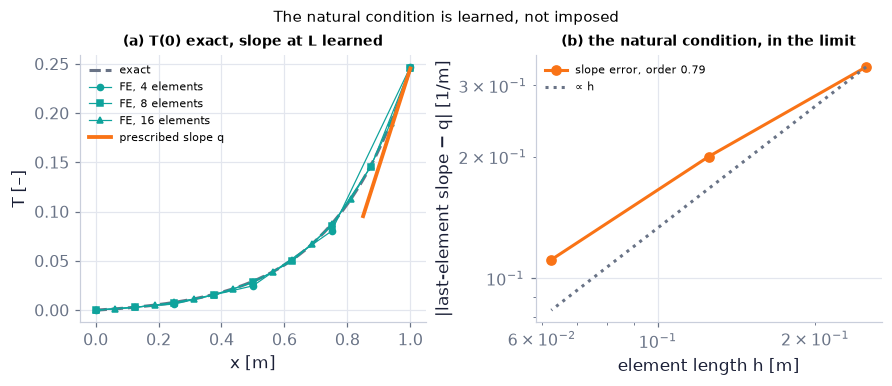

In [55]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.4))   # the figure and its panels
xf = np.linspace(0, 1, 400); Tex = q_*D_/u_*np.exp(-u_/D_)*(np.exp(u_*xf/D_) - 1)   # exact steady solution
a1.plot(xf, Tex, "--", color=C_EX, label="exact")   # draw the curve(s)
hs, slope_err = [], []
for n_, mk in ((4, "o"), (8, "s"), (16, "^")):                 # three meshes
    s_ = FEM1.solve_steady(np.linspace(0, 1, n_ + 1), u_, D_, g=0.0, q=q_)   # FE: Dirichlet at 0 (essential), flux at 1 (natural)
    a1.plot(s_["x"], s_["T"], mk + "-", color=C_UP, ms=4, lw=0.8, label=f"FE, {n_} elements")   # draw the curve(s)
    hs.append(1/n_); slope_err.append(abs((s_["T"][-1] - s_["T"][-2])*n_ - q_))   # |slope of the last element - q|
a1.plot([0.85, 1.0], [Tex[-1] - 0.15*q_, Tex[-1]], color=C_FT, lw=2.5, label="prescribed slope q")   # the Neumann datum
a1.set_xlabel("x [m]"); a1.set_ylabel("T [–]"); a1.legend(fontsize=7, frameon=False); a1.set_title("(a) T(0) exact, slope at L learned", fontsize=9)   # the panel's title: what this panel shows
a2.loglog(hs, slope_err, "o-", color=C_FT, label=f"slope error, order {observed_order(hs, slope_err):.2f}")   # curve(s) on logarithmic axes
a2.loglog(hs, np.array(hs)*slope_err[0]/hs[0], ":", color=C_EX, label="∝ h")   # curve(s) on logarithmic axes
a2.set_xlabel("element length h [m]"); a2.set_ylabel("|last-element slope − q| [1/m]"); a2.legend(fontsize=7, frameon=False)   # axis labels, with units where the quantity has them
a2.set_title("(b) the natural condition, in the limit", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("The natural condition is learned, not imposed", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** (a) Three FE solutions (teal) on the grey exact curve, all starting exactly at $T(0)=0$; a short orange tangent shows the prescribed slope at $x=1$. (b) The mismatch between the slope of the last element and $q$, falling on log–log axes.

**How to read it.** Essential: imposed exactly on every mesh. Natural: satisfied only in the limit — the slope error shrinks with an observed order of about 0.8 on these meshes (the legend prints it), while $T(0)$ is exact on every mesh.

**What would change if…** …we prescribed $T(1)$ instead: it would have to be built into the trial space as well (the `T_L=` option), and both ends would be exact.

**What would change if…** …we only allowed a *finite* set of test and trial functions? The weak form becomes a finite system of equations — the Galerkin method, C07.

### 🧩 Galerkin's method with hat functions `C07`

*The question:* If the unknown is a whole function, how does it become a handful of numbers the computer can solve for?

*In one line:* $\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F$ *(10.58)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **solve_ivp** — `scipy.integrate.solve_ivp(f, (t0, t1), y0)` integrates a system of ODEs (Ch. 1 P31).
- **scipy.sparse matrices and spsolve** — store only the nonzero entries; `spsolve(A, b)` solves the sparse system (Ch. 6 P161).

#### The problem in plain words

Build $T$ out of Lego: tent-shaped pieces, one centred on each node, each as tall as the temperature there. Adding the tents gives a broken-line
profile through the nodal values. The heights are the unknowns. To find them, demand the weak form not for *every* test function (impossible —
infinitely many) but for every tent. One tent, one equation: as many equations as unknowns.

#### The idea

```
N₀    N₁    N₂    N₃    N₄        hats: 1 at their own node, 0 at every other (N_A(x_B) = δ_AB)
/\    /\    /\    /\    /|
T^h(x) = g·N₀ + d₁N₁ + d₂N₂ + d₃N₃ + d₄N₄     a broken line through (x_A, d_A)
test with w = N_A for A = 1…n   ⇒   n equations   M ḋ + K d = F
```

📝 **Note.** **N23 [B]** **The discrete weak problem (10.39)–(10.42), $\int_0^LT^h_tw^h\,dx+u\int_0^LT^h_xw^h\,dx+D\int_0^LT^h_xw^h_x\,dx=Dqw^h(L),\ \int_0^Lv^h_tw^h\,dx+a(w^h,v^h)=Dqw^h(L)-a(w^h,g^h)$:** find $T^h\in\mathcal S^h$ with $\int_0^LT^h_tw^h\,dx+u\int_0^LT^h_xw^h\,dx+D\int_0^LT^h_xw^h_x\,dx=Dq\,w^h(L)$
for all $w^h\in V^h$ *(10.39)*. Split off the boundary value: $v^h=T^h-g^h$ *(10.40)* with $g^h(0)=g$, so $v^h$ and $w^h$ live in the *same* space; then
$\int_0^Lv^h_tw^h\,dx+a(w^h,v^h)=Dq\,w^h(L)-a(w^h,g^h)$ *(10.41)* with the bilinear form $a(w,v)=u\int_0^Lv_xw\,dx+D\int_0^Lv_xw_x\,dx$ *(10.42)*.

📝 **Note.** **N24 [C]** **Galerkin vs Petrov–Galerkin:** Galerkin = test functions from the same space as the solution; Petrov–Galerkin = a different test space.
*Pointer:* SUPG (N50) is Petrov–Galerkin — it tilts the test functions upstream.

> 📎 **Primer — bilinear form a(w, v).** `P232` · A function of two functions that is linear in each slot separately: $a(c_1w_1+c_2w_2,v)=c_1a(w_1,v)+c_2a(w_2,v)$, and the same in $v$. So sums and
constants can be pulled out of it, just like out of an integral — the move that turns (10.50), $\int_0^L\Big(\sum_B\dot d_BN_B\sum_Ac_AN_A\Big)dx+a\Big(\sum_Ac_AN_A,\sum_Bd_BN_B\Big)=Dq\sum_Ac_AN_A(L)-a\Big(\sum_Ac_AN_A,gN_0\Big)$ into (10.52), $G_A=\sum_B\dot d_B\int_0^LN_AN_B\,dx+\sum_Bd_B\,a(N_A,N_B)-DqN_A(L)+g\,a(N_A,N_0)$. Here $a(w,v)$ is *not* symmetric (the
convective part differentiates only $v$).

In [56]:
import numpy as np   # arrays and maths
x = np.linspace(0, 1, 2001); u, D = 1.0, 0.1   # sample points
a = lambda w, v: np.trapezoid(u*np.gradient(v, x)*w + D*np.gradient(v, x)*np.gradient(w, x), x)
w1, w2, v = x, x**2, np.sin(x)
print(np.isclose(a(2*w1 + 3*w2, v), 2*a(w1, v) + 3*a(w2, v)))   # True: linear in the first slot
print(np.isclose(a(w1, v), a(v, w1)))                           # False: not symmetric

True
False


In [57]:
nodes = np.linspace(0, 1, 5)                                   # 4 elements, h = 0.25 m
N2 = lambda x: FEM1.hat(x, nodes, 2); N1 = lambda x: FEM1.hat(x, nodes, 1)   # two neighbouring hats
a21 = FEM1.bilinear_form(N2, N1, nodes, 1.0, 0.25)             # a(N_2, N_1) with u = 1 m/s, D = 0.25 m²/s (10.42)
M, K, F = FEM1.assemble_1d(nodes, 1.0, 0.25, g=0.0, dirichlet_right=1.0)   # the assembled system (C08 opens the box)
print("a(N_2, N_1) =", a21, "  K entry (row A = 2, column B = 1) =", K.toarray()[1, 0])   # show the numbers computed above
assert np.isclose(a21, K.toarray()[1, 0])                      # K_AB = a(N_A, N_B)

a(N_2, N_1) = -1.5   K entry (row A = 2, column B = 1) = -1.5


**What does the code above do?**

`bilinear_form(w, v, x, u, D)` evaluates $a(w,v)=u\int v_xw\,dx+D\int v_xw_x\,dx$ *(10.42)* exactly for piecewise-linear functions. With the test
function $w=N_2$ and the trial function $v=N_1$ it equals the stiffness entry $K_{21}$ that assembly produces.

📝 **Note.** **N25 [B], N26 [B], N27 [B]** **The basis (10.43)–(10.49):** $N_A(x)$, $A=1\dots n$, with $N_A(0)=0$ *(10.43)–(10.44)*, so every test function is
$w^h=\sum_{A=1}^nc_AN_A(x)$ *(10.45)*; one extra $N_0$ with $N_0(0)=1$ *(10.46)* carries the boundary value, $g^h=gN_0$ *(10.47)*; the solution is
$v^h=\sum_Ad_A(t)N_A$ *(10.48)* and $T^h=\sum_{A=1}^nd_A(t)N_A(x)+gN_0(x)$ *(10.49)*.

In [58]:
xs = np.linspace(0, 1, 401)                                    # sample points [m]
B = FEM1.hat_basis(nodes, xs)                                  # column A = N_A(x) for A = 0 … 4 (N_0 included)
print("partition of unity: sum of hats between", B.sum(axis=1).min(), "and", B.sum(axis=1).max())   # show the numbers computed above
print("hats at the nodes (N_A(x_B)):\n", FEM1.hat_basis(nodes, nodes))   # the identity matrix: delta_AB

partition of unity: sum of hats between 1.0 and 1.0
hats at the nodes (N_A(x_B)):
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


**What does the code above do?**

1. `hat_basis(nodes, x)` returns every hat $N_0\dots N_n$ sampled at `x`; at every point they add up to 1 (a *partition of unity*: a constant is
   represented exactly).
2. At the nodes the matrix $N_A(x_B)$ is the identity: each hat is 1 at its own node and 0 at the others.

> 📎 **Primer — arbitrary coefficients: every bracket is zero.** `P233` · If $\sum_{A=1}^nc_AG_A=0$ must hold for *every* choice of the numbers $c_A$, then each $G_A=0$: choose $c=(1,0,\dots,0)$ to get $G_1=0$, then
$(0,1,0,\dots)$ for $G_2$, and so on. It is how one weak statement "for all $w$" becomes $n$ separate equations.

In [59]:
import numpy as np   # arrays and maths
G = np.array([0.3, -0.1, 0.0])       # suppose sum(c*G) were 0 for every c ...
for c in np.eye(3):                  # ... then try the unit vectors
    print(c, c @ G)                  # 0.3 != 0 exposes G_1: so all G_A must vanish

[1. 0. 0.] 0.3
[0. 1. 0.] -0.1
[0. 0. 1.] 0.0


#### 🧮 Derivation — Galerkin to matrix form $\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F$ with $M_{AB}=\int_0^LN_AN_B\,dx$, $K_{AB}=u\int_0^LN_{B,x}N_A\,dx+D\int_0^LN_{B,x}N_{A,x}\,dx$, $F_A=DqN_A(L)-gu\int_0^LN_{0,x}N_A\,dx-gD\int_0^LN_{0,x}N_{A,x}\,dx$ `D11` (Eq. 10.58: $\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F$)

**What we want to show.** Turn the weak form, restricted to finitely many basis functions, into a system of ODEs for the nodal weights.

**Assumptions.** $\mathcal S^h\subset\mathcal S$, $V^h\subset V$ (step 1); the boundary value g constant in time (step 3); the basis $N_A$ with $N_A(0)=0$ and one extra $N_0$ (N25–N27).

**The plan.**

1. Lift off the boundary value so trial and test functions share one space.
2. Write the bilinear form.
3. Insert the expansions and pull the sums out.
4. Arbitrary test coefficients ⇒ one equation per basis function.
5. Name the matrices.

**Tools we use** (each explained before this point): Bilinear form (primer P232) · linear combinations (Ch. 2) · arbitrary coefficients ⇒ each bracket zero (primer P233).

**We start from**

$$ \text{The weak form in finite spaces:}\ \int_0^LT^h_tw^h\,dx+u\int_0^LT^h_xw^h\,dx+D\int_0^LT^h_xw^h_x\,dx=Dq\,w^h(L)\ \text{for all}\ w^h\in V^h\ \text{(10.39)} $$

*In words:* the weak problem with a finite menu of trial and test functions.

---

**Step 1 of 13 — Split off the boundary value.**

$$ v^h=T^h-g^h,\qquad g^h(0)=g\ \text{(10.40)} $$

- *Why we can do this:* Then $v^h(0)=0$, so $v^h$ lives in $V^h$ like the test functions — the Galerkin requirement (trial = test space).
- *In words:* the unknown part vanishes where T is prescribed.

---

**Step 2 of 13 — Name the bilinear form.**

$$ a(w,v)=u\int_0^Lv_xw\,dx+D\int_0^Lv_xw_x\,dx\ \text{(10.42)} $$

- *Why we can do this:* The two space terms of (10.39), $\int_0^LT^h_tw^h\,dx+u\int_0^LT^h_xw^h\,dx+D\int_0^LT^h_xw^h_x\,dx=Dqw^h(L)$ together, linear in each slot (P232); a shorthand for everything that is not the time derivative.
- *In words:* one symbol for convection plus diffusion.

---

**Step 3 of 13 — Use $g^h$ constant in time.**

$$ T^h_t=v^h_t $$

- *Why we can do this:* g is a fixed number, so $g^h(x)=gN_0(x)$ does not depend on t.
- *In words:* only the unknown part changes in time.

---

**Step 4 of 13 — Split a(·,·) over the sum.**

$$ a(w^h,T^h)=a(w^h,v^h)+a(w^h,g^h) $$

- *Why we can do this:* Linearity in the second slot (P232).
- *In words:* convection and diffusion act on each part separately.

---

**Step 5 of 13 — Write the Galerkin form.**

$$ \int_0^Lv^h_tw^h\,dx+a(w^h,v^h)=Dq\,w^h(L)-a(w^h,g^h)\ \text{(10.41)} $$

- *Why we can do this:* Steps 2–4 in (10.39), $\int_0^LT^h_tw^h\,dx+u\int_0^LT^h_xw^h\,dx+D\int_0^LT^h_xw^h_x\,dx=Dqw^h(L)$, the known $a(w^h,g^h)$ moved to the right.
- *In words:* unknowns left, known data right.

---

**Step 6 of 13 — Insert the expansions.**

$$ w^h=\sum_Ac_AN_A,\ \ v^h=\sum_Bd_B(t)N_B,\ \ g^h=gN_0\ \text{(10.45), (10.48), (10.47)} $$

- *Why we can do this:* Every function in the finite spaces is a combination of the basis (N25–N27); the time dependence sits in the weights $d_B(t)$.
- *In words:* functions become lists of numbers.

---

**Step 7 of 13 — Substitute into (10.41).**

$$ \int_0^L\Big(\sum_B\dot d_BN_B\sum_Ac_AN_A\Big)dx+a\Big(\sum_Ac_AN_A,\sum_Bd_BN_B\Big)=Dq\sum_Ac_AN_A(L)-a\Big(\sum_Ac_AN_A,gN_0\Big)\ \text{(10.50)} $$

- *Why we can do this:* Straight substitution; $\dot d_B=dd_B/dt$ because $v^h_t=\sum\dot d_BN_B$.
- *In words:* the Galerkin form in terms of the weights.

---

**Step 8 of 13 — Pull the sums out of the integral.**

$$ \int_0^L\sum_A\sum_Bc_A\dot d_BN_AN_B\,dx=\sum_Ac_A\sum_B\dot d_B\int_0^LN_AN_B\,dx $$

- *Why we can do this:* The integral of a finite sum is the sum of integrals, and $c_A$, $\dot d_B$ do not depend on x.
- *In words:* the mass integrals separate from the numbers.

---

**Step 9 of 13 — Pull the sums out of a(·,·).**

$$ a\Big(\sum_Ac_AN_A,\sum_Bd_BN_B\Big)=\sum_Ac_A\sum_Bd_B\,a(N_A,N_B) $$

- *Why we can do this:* Bilinearity (P232), in each slot in turn; likewise $a(\sum c_AN_A,gN_0)=\sum_Ac_A\,g\,a(N_A,N_0)$.
- *In words:* the stiffness integrals separate too.

---

**Step 10 of 13 — Collect everything under one sum.**

$$ \sum_{A=1}^nc_AG_A=0\ \text{(10.51),}\ \ G_A=\sum_B\dot d_B\int_0^LN_AN_B\,dx+\sum_Bd_B\,a(N_A,N_B)-DqN_A(L)+g\,a(N_A,N_0)\ \text{(10.52)} $$

- *Why we can do this:* Move all terms to the left and factor $c_A$ out of each.
- *In words:* a weighted sum of brackets must vanish.

---

**Step 11 of 13 — Arbitrary $c_A$ ⇒ each bracket zero.**

$$ \sum_B\dot d_B\int_0^LN_BN_A\,dx+\sum_Bd_B\,a(N_A,N_B)=DqN_A(L)-g\,a(N_A,N_0),\ \ A=1,\dots,n\ \text{(10.53)} $$

- *Why we can do this:* (10.51), $\sum_{A=1}^nc_AG_A=0$ must hold for every test function, i.e. every choice of the $c_A$; taking unit vectors gives $G_A=0$ one by one (P233).
- *In words:* one ODE per basis function — as many equations as unknowns.

---

**Step 12 of 13 — Name the matrices.**

$$ M_{AB}=\int_0^LN_AN_B\,dx,\ \ K_{AB}=a(N_A,N_B),\ \ F_A=DqN_A(L)-g\,a(N_A,N_0)\ \text{(10.55)–(10.57)} $$

- *Why we can do this:* Read the coefficients of $\dot d_B$, of $d_B$ and the known right side off (10.53), $\sum_B\dot d_B\int_0^LN_BN_A\,dx+\sum_Bd_B\,a(N_A,N_B)=DqN_A(L)-g\,a(N_A,N_0)$; expanding a(·,·) gives the book's (10.56), $K_{AB}=u\int_0^LN_{B,x}N_A\,dx+D\int_0^LN_{B,x}N_{A,x}\,dx$ and (10.57), $F_A=DqN_A(L)-gu\int_0^LN_{0,x}N_A\,dx-gD\int_0^LN_{0,x}N_{A,x}\,dx$. M is symmetric, K is not (convection differentiates only $N_B$).
- *In words:* mass, stiffness and force.

---

**Step 13 of 13 — Write it as one matrix equation.**

$$ \mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F\ \text{(10.58)} $$

- *Why we can do this:* The n equations of (10.53), $\sum_B\dot d_B\int_0^LN_BN_A\,dx+\sum_Bd_B\,a(N_A,N_B)=DqN_A(L)-g\,a(N_A,N_0)$ are the rows of a matrix–vector product (10.54), $\mathbf M=[M_{AB}],\ \mathbf K=[K_{AB}],\ \mathbf F=\{F_A\},\ \mathbf d=\{d_B\}$.
- *In words:* a system of ODEs, ready for any time stepper.

---

**Result**

$$ \begin{array}{l}\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F\ \text{(10.58)} \\ M_{AB}=\int_0^LN_AN_B\,dx\ \text{(10.55)} \\ K_{AB}=u\int_0^LN_{B,x}N_A\,dx+D\int_0^LN_{B,x}N_{A,x}\,dx\ \text{(10.56)} \\ F_A=DqN_A(L)-gu\int_0^LN_{0,x}N_A\,dx-gD\int_0^LN_{0,x}N_{A,x}\,dx\ \text{(10.57)}\end{array} $$

*In words:* Galerkin turns the PDE into mass × rate + stiffness × weights = force.

**What it means.** Any basis gives this form; hat functions make M and K tridiagonal (D12). The same recipe with P2/P1 triangles gives (10.137), $\begin{pmatrix}\mathbf M\dot{\mathbf u}\\ \mathbf 0\end{pmatrix}+\begin{pmatrix}\mathbf A&\mathbf B\\ \mathbf B^T&\mathbf 0\end{pmatrix}\begin{pmatrix}\mathbf u\\ \mathbf p\end{pmatrix}=\begin{pmatrix}\mathbf f_u\\ \mathbf f_p\end{pmatrix}$ in C13.

**Check it.** `ch10.galerkin_equations_sympy(3)` returns M, K, F for three hats; units: $M_{AB}$ [m], $K_{AB}$ [m/s], $F_A$ [T·m/s] — each row of (10.58), $\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F$ in T·m/s ✓. With u = 0, K is symmetric (pure diffusion) ✓.

> ⚠️ **Common confusion (traps in `D11`):** Forgetting that K differentiates the *trial* function in the convective part (swapping A and B makes K the transpose); leaving the g N₀ terms on the left (they are known data); treating $\dot d_B$ as time derivatives of the basis.

📝 **Note.** **N28 [B]** **The middle steps (10.50)–(10.53), $\int_0^L\Big(\sum_B\dot d_BN_B\sum_Ac_AN_A\Big)dx+a\Big(\sum_Ac_AN_A,\sum_Bd_BN_B\Big)=Dq\sum_Ac_AN_A(L)-a\Big(\sum_Ac_AN_A,gN_0\Big),\ \sum_{A=1}^nc_AG_A=0$:** substituting (10.45), $w^h=\sum_{A=1}^nc_AN_A(x)$, (10.48), $v^h=\sum_{A=1}^nd_A(t)N_A(x)$ into (10.41), $\int_0^Lv^h_tw^h\,dx+a(w^h,v^h)=Dqw^h(L)-a(w^h,g^h)$ gives (10.50); rearranged, $\sum_Ac_AG_A=0$ *(10.51)* with
$G_A=\sum_B\dot d_B\int_0^LN_AN_B\,dx+\sum_Bd_B\,a(N_A,N_B)-DqN_A(L)+g\,a(N_A,N_0)$ *(10.52)*; arbitrary $c_A$ ⇒
$\sum_B\dot d_B\int_0^LN_BN_A\,dx+\sum_Bd_B\,a(N_A,N_B)=DqN_A(L)-g\,a(N_A,N_0)$ *(10.53)*: $n$ ODEs.

In [60]:
gs = FEM1.galerkin_equations_sympy(3)                          # D11 for three hats on a uniform mesh, by machine
print("M ="); sp.pprint(gs["M"]); print("K ="); sp.pprint(gs["K"]); print("F ="); sp.pprint(gs["F"])   # show the numbers computed above
print("row A = 1 minus h x (10.63):", gs["check_interior"])    # 0: the interior row is (10.63) times h

M =


⎡2⋅h   h    ⎤
⎢───   ─   0⎥
⎢ 3    6    ⎥
⎢           ⎥
⎢ h   2⋅h  h⎥
⎢ ─   ───  ─⎥
⎢ 6    3   6⎥
⎢           ⎥
⎢      h   h⎥
⎢ 0    ─   ─⎥
⎣      6   3⎦
K =
⎡  2⋅D      D   u         ⎤
⎢  ───    - ─ + ─     0   ⎥
⎢   h       h   2         ⎥
⎢                         ⎥
⎢  D   u    2⋅D      D   u⎥
⎢- ─ - ─    ───    - ─ + ─⎥
⎢  h   2     h       h   2⎥
⎢                         ⎥
⎢           D   u   D   u ⎥
⎢   0     - ─ - ─   ─ + ─ ⎥
⎣           h   2   h   2 ⎦
F =
⎡D⋅g   g⋅u⎤
⎢─── + ───⎥
⎢ h     2 ⎥
⎢         ⎥
⎢    0    ⎥
⎢         ⎥
⎣   D⋅q   ⎦
row A = 1 minus h x (10.63): 0


**What does the code above do?**

1. `galerkin_equations_sympy(3)` performs the integrals of (10.55)–(10.57), $M_{AB}=\int_0^LN_AN_B\,dx,\ K_{AB}=u\int_0^LN_{B,x}N_A\,dx+D\int_0^LN_{B,x}N_{A,x}\,dx,\ F_A=DqN_A(L)-gu\int_0^LN_{0,x}N_A\,dx-gD\int_0^LN_{0,x}N_{A,x}\,dx$ for three hats of length $h$ (the last one a half-hat at $x=L$): $\mathbf M$ is
   tridiagonal with $2h/3$ on the diagonal and $h/6$ beside it (the half-hat gets $h/3$); $\mathbf K$ is tridiagonal and *not* symmetric
   ($\mp u/2$ from convection); $\mathbf F$ carries the Dirichlet value $g$ in the first row and the flux $Dq$ in the last.
2. `check_interior` compares row 1 with (10.63), $\tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0$ multiplied by $h$: difference 0.

📝 **Note.** **N29 [C]** **Time next:** (10.58), $\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F$ is a system of ODEs — integrate it with an ODE solver (the method of lines; `solve_ivp`, Ch. 1 P31) or with finite
differences in time — Ch. 8's θ-method, $\frac{\mathbf d^{n+1}-\mathbf d^n}{\Delta t}=\theta\,\mathbf f^{n+1}+(1-\theta)\,\mathbf f^n$ with $\theta=0$ (forward Euler),
$\frac12$ (Crank–Nicolson) or 1 (backward Euler); this weight $\theta$ has nothing to do with Glowinski's splitting fraction $\Theta$ of N74 or the Fourier angle. Both are options of `FEM1.solve_transport(method=…)`.

📝 **Note.** **N30 [B]** **Hat functions (10.59)–(10.61):** $N_A=\frac{x-x_{A-1}}{x_A-x_{A-1}}$ on $[x_{A-1},x_A)$, $\frac{x_{A+1}-x}{x_{A+1}-x_A}$ on $[x_A,x_{A+1}]$, 0 elsewhere
*(10.59)*; half-hats at the ends, $N_n$ *(10.60)* and $N_0$ *(10.61)*. They are *compact*: each is nonzero on two elements only, and
$N_A(x_B)=\delta_{AB}$ (the Kronecker delta of Ch. 2).

$$ N_A=\begin{cases}\tfrac{x-x_{A-1}}{x_A-x_{A-1}},&x_{A-1}\le x<x_A\\ \tfrac{x_{A+1}-x}{x_{A+1}-x_A},&x_A\le x\le x_{A+1}\\ 0,&\text{elsewhere}\end{cases} \qquad \text{(10.59)} $$

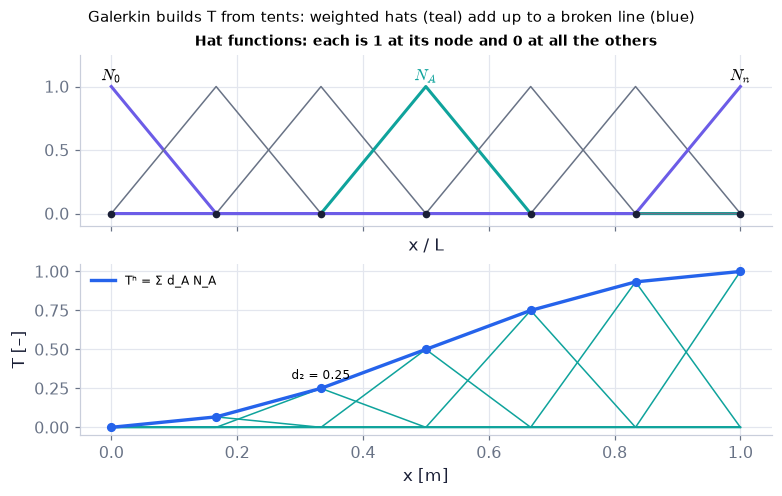

In [61]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 4.4), sharex=True)   # the figure and its panels
hat_functions(a1, n_el=6)                                      # our Fig. 10.2: N_0 … N_6, one interior hat highlighted
a1.set_title("Hat functions: each is 1 at its node and 0 at all the others", fontsize=9)   # the panel's title: what this panel shows
nod = np.linspace(0, 1, 7); xs = np.linspace(0, 1, 400)        # 6 elements
d = np.sin(np.pi*nod/2)**2                                     # sample nodal values (a smooth rising profile)
B = FEM1.hat_basis(nod, xs)                                    # all hats sampled at xs
for A in range(7):   # repeat the indented lines for each index
    a2.plot(xs, d[A]*B[:, A], color=C_UP, lw=1)                # the weighted hats d_A N_A
a2.plot(xs, B @ d, color=C_IM, lw=2.2, label="Tʰ = Σ d_A N_A")  # their sum: a broken line through the nodal values
a2.plot(nod, d, "o", color=C_IM, ms=5)   # draw the curve(s)
a2.text(nod[2], d[2] + 0.06, f"d₂ = {d[2]:.2f}", ha="center", fontsize=8)   # read d_2 off the plot (N31)
a2.set_xlabel("x [m]"); a2.set_ylabel("T [–]"); a2.legend(fontsize=8, frameon=False, loc="upper left")   # axis labels, with units where the quantity has them
fig.suptitle("Galerkin builds T from tents: weighted hats (teal) add up to a broken line (blue)", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Top: seven tents — the two end ones (purple) are half-tents, N₀ at x = 0 and Nₙ at x = 1 (here n = 6) — with one interior hat highlighted. Bottom: the same tents scaled by the nodal values (teal; the first one lies flat on the axis because d₀ = 0) and their sum (blue), a broken line through the blue dots.

**How to read it.** Each tent overlaps only with its two neighbours; at a node only its own tent is nonzero, so the height of each tent is the value at its node ($d_2$ is read off the plot — N31).

**What would change if…** …quadratic pieces (P2, C13): three nodes per element and curved tents.

📝 **Note.** **N31 [B]** **The weights are nodal values (10.62):** $d_A=T^h(x_A)=T_A$ — because only $N_A$ is nonzero at $x_A$. Read $d_2$ off the plot above.

$$ d_A=T^h(x_A)=T_A \qquad \text{(10.62)} $$

#### 🧮 Derivation — The interior row $\frac d{dt}\Big(\frac{T_{A-1}}6+\frac{2T_A}3+\frac{T_{A+1}}6\Big)+\frac u{2h}(T_{A+1}-T_{A-1})-\frac D{h^2}(T_{A-1}-2T_A+T_{A+1})=0$ `D12` (Eq. 10.63: $\tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0$)

**What we want to show.** Evaluate the integrals of row A of (10.53), $\sum_B\dot d_B\int_0^LN_BN_A\,dx+\sum_Bd_B\,a(N_A,N_B)=DqN_A(L)-g\,a(N_A,N_0)$ for hat functions on a uniform mesh and compare with finite differences.

**Assumptions.** Uniform mesh $x_A=Ah$ (step 2); interior node away from both ends (the right side is zero).

**The plan.**

1. Only three neighbours overlap.
2. Compute the three mass integrals, the three convective and the three diffusive ones.
3. Assemble and divide by h.

**Tools we use** (each explained before this point): Hat functions (10.59), $N_A=\begin{cases}\tfrac{x-x_{A-1}}{x_A-x_{A-1}},&x_{A-1}\le x<x_A\\ \tfrac{x_{A+1}-x}{x_{A+1}-x_A},&x_A\le x\le x_{A+1}\\ 0,&\text{elsewhere}\end{cases}$ (N30) · integrals of linear functions · D11.

**We start from**

$$ \begin{array}{l}\text{Row A of (10.53) for an interior node,}\ \sum_B\dot d_B\int_0^LN_BN_A\,dx+\sum_Bd_B\,a(N_A,N_B)=0\ \text{(}\ N_A(L)=0\ \text{and}\ N_A\ \text{does} \\ \text{not overlap}\ N_0\ \text{for 2 ≤ A ≤ n − 2)}\end{array} $$

*In words:* one row of the Galerkin system.

---

**Step 1 of 10 — Keep only overlapping neighbours.**

$$ B\in\{A-1,A,A+1\} $$

- *Why we can do this:* $N_A$ is nonzero only on $[x_{A-1},x_{A+1}]$ (compact support, N30); every other product $N_AN_B$ and $N_{A,x}N_{B,x}$ is zero everywhere.
- *In words:* three terms per row.

---

**Step 2 of 10 — Mass, diagonal.**

$$ \int N_A^2\,dx=2\int_0^h\big(\tfrac sh\big)^2ds=\tfrac{2h}3 $$

- *Why we can do this:* On each of its two elements $N_A$ is a straight ramp from 0 to 1; ∫₀ʰ(s/h)²ds = h/3, twice.
- *In words:* a hat overlaps itself on two elements.

---

**Step 3 of 10 — Mass, off-diagonal.**

$$ \int N_AN_{A\pm1}\,dx=\int_0^h\big(1-\tfrac sh\big)\tfrac sh\,ds=\tfrac h6 $$

- *Why we can do this:* The neighbours overlap on one element, where one rises and the other falls; ∫₀¹(1 − σ)σ dσ = 1/6.
- *In words:* neighbours share one element.

---

**Step 4 of 10 — Slopes of the hats.**

$$ N_{A,x}=+\tfrac1h\ \text{on}\ [x_{A-1},x_A]\ \text{,}\ -\tfrac1h\ \text{on}\ [x_A,x_{A+1}] $$

- *Why we can do this:* Differentiate (10.59), $N_A=\begin{cases}\tfrac{x-x_{A-1}}{x_A-x_{A-1}},&x_{A-1}\le x<x_A\\ \tfrac{x_{A+1}-x}{x_{A+1}-x_A},&x_A\le x\le x_{A+1}\\ 0,&\text{elsewhere}\end{cases}$; likewise $N_{A+1,x}=+1/h$ on $[x_A,x_{A+1}]$ and $N_{A-1,x}=-1/h$ on $[x_{A-1},x_A]$.
- *In words:* up-slope then down-slope.

---

**Step 5 of 10 — Convective integrals.**

$$ \int N_{A+1,x}N_A\,dx=\tfrac1h\cdot\tfrac h2=\tfrac12,\quad\int N_{A-1,x}N_A\,dx=-\tfrac12,\quad\int N_{A,x}N_A\,dx=0 $$

- *Why we can do this:* Constant slope times the area under half a hat (h/2); the last is $\frac12[N_A^2]$ between two zeros.
- *In words:* convection couples only the two neighbours, with opposite signs.

---

**Step 6 of 10 — Diffusive integrals.**

$$ \int N_{A,x}^2\,dx=\tfrac2h,\qquad\int N_{A\pm1,x}N_{A,x}\,dx=-\tfrac1h $$

- *Why we can do this:* (1/h)² over length 2h; for neighbours (±1/h)(∓1/h) over one element h.
- *In words:* the diffusion weights 2/h and −1/h.

---

**Step 7 of 10 — Assemble the mass part.**

$$ h\Big(\tfrac16\dot d_{A-1}+\tfrac23\dot d_A+\tfrac16\dot d_{A+1}\Big) $$

- *Why we can do this:* Steps 2–3 times $\dot d_B$. Each rate $\dot d_B$ is a constant with respect to $x$, so it multiplies its own mass integral.
- *In words:* a weighted average of three rates.

---

**Step 8 of 10 — Assemble the stiffness part.**

$$ \tfrac u2(d_{A+1}-d_{A-1})+\tfrac Dh(-d_{A-1}+2d_A-d_{A+1}) $$

- *Why we can do this:* $K_{AB}=u\int N_{B,x}N_A+D\int N_{B,x}N_{A,x}$ (10.56) with steps 5–6.
- *In words:* centred convection and diffusion, times h.

---

**Step 9 of 10 — Set the row to zero.**

$$ h\Big(\tfrac16\dot d_{A-1}+\tfrac23\dot d_A+\tfrac16\dot d_{A+1}\Big)+\tfrac u2(d_{A+1}-d_{A-1})-\tfrac Dh(d_{A-1}-2d_A+d_{A+1})=0 $$

- *Why we can do this:* $F_A=0$ for an interior node ($N_A(L)=0$, no overlap with $N_0$).
- *In words:* the row of (10.53), $\sum_B\dot d_B\int_0^LN_BN_A\,dx+\sum_Bd_B\,a(N_A,N_B)=DqN_A(L)-g\,a(N_A,N_0)$.

---

**Step 10 of 10 — Divide by h, use $d_A=T_A$.**

$$ \frac d{dt}\Big(\frac{T_{A-1}}6+\frac{2T_A}3+\frac{T_{A+1}}6\Big)+\frac u{2h}(T_{A+1}-T_{A-1})-\frac D{h^2}(T_{A-1}-2T_A+T_{A+1})=0\ \text{(10.63)} $$

- *Why we can do this:* The weights are nodal values (10.62), $d_A=T^h(x_A)=T_A$ (N31); dividing by h makes the stencils look like (10.6)–(10.7), $\left[\tfrac{\partial T}{\partial x}\right]^n_i=\tfrac{T^n_{i+1}-T^n_i}{\Delta x}+O(\Delta x)=\tfrac{T^n_i-T^n_{i-1}}{\Delta x}+O(\Delta x)=\tfrac{T^n_{i+1}-T^n_{i-1}}{2\Delta x}+O(\Delta x^2),\ \left[\tfrac{\partial^2T}{\partial x^2}\right]^n_i=\tfrac{T^n_{i+1}-2T^n_i+T^n_{i-1}}{\Delta x^2}+O(\Delta x^2)$.
- *In words:* centred FD in space, with a ⅙–⅔–⅙ averaged time derivative.

---

**Result**

$$ \tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0\ \text{(10.63)} $$

*In words:* uniform linear FE = centred FD for convection and diffusion, with a consistent-mass average in time.

**What it means.** For steady problems FE and FD give identical equations (N33); in time the consistent mass is slightly less diffusive. On nonuniform or quadratic meshes the rows differ.

**Check it.** The mass weights sum to 1 (⅙ + ⅔ + ⅙) ✓; the stiffness row sums to 0 (a constant T has no convection or diffusion) ✓. Numbers (h = 0.25, u = 1, D = 0.25): stiffness row × h = (−1.5, 2, −0.5) ✓ (`FEM1.interior_stencil`); sympy confirms ⅙, ⅔ (analysis note).

> ⚠️ **Common confusion (traps in `D12`):** ∫N_A² = h/3 (forgetting the second element); dividing by h too early (the mass row is then h/6, 2h/3 … mixed up); a sign in the convective pair.

📝 **Note.** **N32 [B]** **The interior row (10.63):** $\frac d{dt}\Big(\frac{T_{A-1}}6+\frac{2T_A}3+\frac{T_{A+1}}6\Big)+\frac u{2h}(T_{A+1}-T_{A-1})-\frac D{h^2}(T_{A-1}-2T_A+T_{A+1})=0$ —
the centred convection and diffusion stencils of C01, but the time derivative acts on a ⅙–⅔–⅙ average of three nodes (the **consistent mass**).
Replacing the average by $T_A$ alone ("lumping") gives exactly the semi-discrete FD scheme.

📝 **Note.** **N33 [B]** **"Galerkin FE is equivalent to an FD method"** (§10.3) — true, with a caveat: for *uniform linear* elements the steady equations are identical
(the mass matrix drops out when $\partial/\partial t=0$); in time the consistent mass differs; on nonuniform or higher-order meshes the two differ. FE's real
advantage is geometry.

In [62]:
fe = FEM1.solve_steady(nodes, 1.0, 0.25, T_L=1.0)["T"]         # steady FE, 4 elements, T(0) = 0, T(1) = 1
fd = FD.steady_cd_fd(4, 4.0)["T"]                              # centred FD of the same problem (R = uL/D = 4)
print("FE:", fe, "\nFD:", fd, "\nmax difference:", np.abs(fe - fd).max())   # show the numbers computed above
assert np.abs(fe - fd).max() < 1e-13                           # identical equations, identical answers

FE: [0.    0.025 0.1   0.325 1.   ] 
FD: [0.    0.025 0.1   0.325 1.   ] 
max difference: 0.0


**What does the code above do?**

The steady FE equations on a uniform linear mesh are the centred FD equations of C09 (the mass matrix drops out), so the two solutions agree to
round-off.

#### ✏️ Tiny example: four elements, by hand

$L=1$, $n=4$ elements, $h=0.25$, $u=1$ m/s, $D=0.25$ m²/s ($R_{cell}=uh/D=1$), steady, $T(0)=0$, $T(1)=1$.
1. Interior row of (10.63), $\tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0$ × $h$: mass $(h/6,2h/3,h/6)=(0.0417,0.1667,0.0417)$ (unused when steady).
2. Convection: $(u/2)(T_{A+1}-T_{A-1})\to(-0.5,0,0.5)$.
3. Diffusion: $-(D/h)(T_{A-1}-2T_A+T_{A+1})\to(-1,2,-1)$.
4. Sum: $(-1.5,2,-0.5)$.
5. Three equations for $T_1,T_2,T_3$: $2T_1-0.5T_2=0$; $-1.5T_1+2T_2-0.5T_3=0$; $-1.5T_2+2T_3=0.5$ (the known $T_4=1$ moved right).
6. Solve: $T=(0.025,\ 0.1,\ 0.325)$.
7. Exact (10.86), $T=\dfrac{e^{Rx/L}-1}{e^R-1}$ at $x=0.25,0.5,0.75$: 0.0321, 0.1192, 0.3561 — close, and with $R_{cell}=1<2$ no wiggles.

In [63]:
M, K, F = FEM1.assemble_1d(nodes, 1.0, 0.25, g=0.0, dirichlet_right=1.0)   # unknowns T_1, T_2, T_3 (both ends Dirichlet)
print("M =\n", M.toarray().round(4)); print("K =\n", K.toarray()); print("F =", F)   # show the numbers computed above
print("interior row x h:", FEM1.interior_stencil(0.25, 1.0, 0.25))        # (10.63) times h
print("FE solution:", FEM1.solve_steady(nodes, 1.0, 0.25, T_L=1.0)["T"])   # show the numbers computed above
print("exact (10.86):", FD.steady_cd_exact(nodes, 4.0).round(4))   # show the numbers computed above

M =
 [[0.1667 0.0417 0.    ]
 [0.0417 0.1667 0.0417]
 [0.     0.0417 0.1667]]
K =
 [[ 2.  -0.5  0. ]
 [-1.5  2.  -0.5]
 [ 0.  -1.5  2. ]]
F = [0.  0.  0.5]
interior row x h: {'mass': array([0.0417, 0.1667, 0.0417]), 'stiff': array([-1.5,  2. , -0.5]), 'M': array([0.0417, 0.1667, 0.0417]), 'K': array([-1.5,  2. , -0.5]), 'M_over_h': array([0.1667, 0.6667, 0.1667]), 'K_over_h': array([-6.,  8., -2.])}
FE solution: [0.    0.025 0.1   0.325 1.   ]
exact (10.86): [0.     0.0321 0.1192 0.3561 1.    ]


**What does the code above do?**

1. Assembly (C08 opens the box) gives $\mathbf K$ with rows $(2,-0.5,0)$, $(-1.5,2,-0.5)$, $(0,-1.5,2)$ and $\mathbf F=(0,0,0.5)$ — the tiny example's equations.
2. `interior_stencil(h, u, D)` is the interior row (10.63), $\tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0$ times $h$: mass $(h/6,2h/3,h/6)$ and stiffness $(-1.5,2,-0.5)$.
3. The steady solve returns $(0,0.025,0.1,0.325,1)$; the exact solution is printed below it.

consistent mass: max nodal difference from the fine reference at t = 0.3 s: 0.0697
lumped mass: max nodal difference from the fine reference at t = 0.3 s: 0.0907


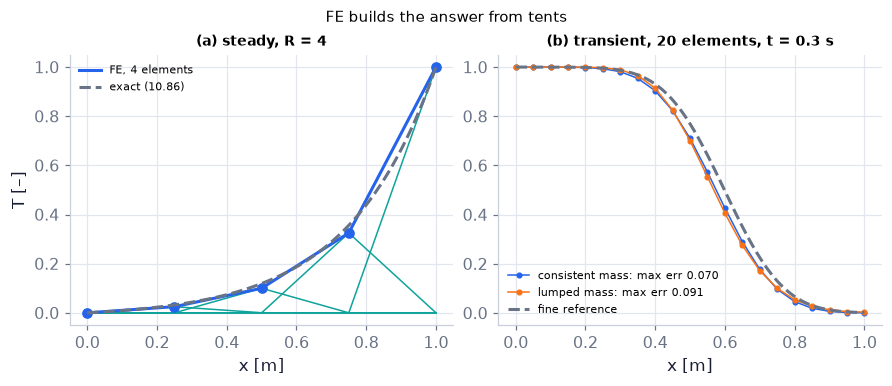

In [64]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.4))   # the figure and its panels
xs = np.linspace(0, 1, 400); Tfe = FEM1.solve_steady(nodes, 1.0, 0.25, T_L=1.0)["T"]   # the tiny example (R = 4)
Bh = FEM1.hat_basis(nodes, xs)
for A in range(5): a1.plot(xs, Tfe[A]*Bh[:, A], color=C_UP, lw=1)   # weighted hats
a1.plot(xs, Bh @ Tfe, color=C_IM, lw=2, label="FE, 4 elements"); a1.plot(nodes, Tfe, "o", color=C_IM)   # draw the curve(s)
a1.plot(xs, FD.steady_cd_exact(xs, 4.0), "--", color=C_EX, label="exact (10.86)")   # draw the curve(s)
a1.set_xlabel("x [m]"); a1.set_ylabel("T [–]"); a1.legend(fontsize=7, frameon=False); a1.set_title("(a) steady, R = 4", fontsize=9)   # the panel's title: what this panel shows
x20 = np.linspace(0, 1, 21); T0s = np.where(x20 < 0.3, 1.0, 0.0)  # a step, advected and diffused (u = 1 m/s, D = 0.03 m²/s)
xr = np.linspace(0, 1, 401); T0r = np.where(xr < 0.3, 1.0, 0.0)   # the same on a 20× finer mesh: our reference
ref = FEM1.solve_transport(xr, T0r, 1.0, 0.03, g=1.0, q=0.0, dt=0.0005, nsteps=600)["T"]
for lumped, col, lab in ((False, C_IM, "consistent mass"), (True, C_FT, "lumped mass")):   # repeat the indented lines for each item listed
    r_ = FEM1.solve_transport(x20, T0s, 1.0, 0.03, g=1.0, q=0.0, dt=0.005, nsteps=60, lumped=lumped)
    err_ = np.abs(r_["T"] - np.interp(x20, xr, ref)).max()   # max nodal difference from the reference
    a2.plot(x20, r_["T"], "o-", color=col, ms=3, lw=1, label=f"{lab}: max err {err_:.3f}")   # draw the curve(s)
    print(f"{lab}: max nodal difference from the fine reference at t = 0.3 s: {err_:.4f}")   # show the numbers computed above
a2.plot(xr, ref, "--", color=C_EX, label="fine reference")   # draw the curve(s)
a2.set_xlabel("x [m]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) transient, 20 elements, t = 0.3 s", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("FE builds the answer from tents", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c07_fem"); plt.show()   # display the figure

**What you see.** (a) The steady FE solution for 4 elements as weighted hats (teal) summing to a broken line (blue) near the grey exact curve. (b) A front carried and spread along the rod on 20 elements, with consistent (blue) and lumped (orange) mass, against a fine-mesh reference (grey dashed).

**How to read it.** Steady: FE = FD exactly (the cell above). Unsteady: the two mass matrices give slightly different fronts; the legend and the cell print their distance from the reference — the consistent mass, which keeps the ⅙–⅔–⅙ coupling, follows it more closely here.

**What would change if…** …nonuniform elements (smaller near $x=1$): FE still assembles the same way; FD would need new stencils.

In [65]:
ns_ = [2, 3, 4, 6, 8, 12, 16, 24, 32]                          # slider positions: number of elements
xs = np.linspace(0, 1, 400)   # sample points
def f4(n_):                                                     # FE with its broken line, centred FD dots, exact curve (R = 10)
    n_ = int(n_); nod = np.linspace(0, 1, n_ + 1)                # n elements, n + 1 nodes on [0, 1] m
    fe = FEM1.solve_steady(nod, 1.0, 0.1, T_L=1.0)["T"]          # steady FE: u = 1 m/s, D = 0.1 m²/s, T(0) = 0, T(1) = 1
    return {"exact": (xs, FD.steady_cd_exact(xs, 10.0)), "FE (broken line)": (nod, fe),   # exact (10.86) and FE
            "centred FD": (nod, FD.steady_cd_fd(n_, 10.0)["T"])}  # centred FD (10.91) on the same nodes
fig = slider_figure(f4, "elements", ns_, xlabel="x [m]", ylabel="T", yrange=[-0.6, 1.1],
                    title="Slide n: FE = FD on uniform meshes; both wiggle while R_cell = 10/n > 2",
                    modes={"centred FD": "markers"})
fig.show()   # display the interactive figure

**What does the code above do?**

For every number of elements the FE solution (a broken line) passes exactly through the centred-FD dots; with $R=10$ both zigzag while
$R_{cell}=10/n>2$ ($n\le4$) and converge to the exact curve as $n$ grows — the wiggles of C09 are shared by both methods.

**What would change if…** …we computed each integral $M_{AB}$, $K_{AB}$ over the whole rod? Most are zero, and the nonzero ones are all alike. C08 computes one small block per
element and adds them up.

### 🧩 Element matrices and assembly `C08`

*The question:* How is a finite-element matrix actually built — and why does that make FE good at complicated shapes? The blocks are $\mathbf m^e=\frac h6\begin{pmatrix}2&1\\1&2\end{pmatrix}$ and $\mathbf k^e=\frac u2\begin{pmatrix}-1&1\\-1&1\end{pmatrix}+\frac Dh\begin{pmatrix}1&-1\\-1&1\end{pmatrix}$, the element integrals worked out in D14.

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **substitution in an integral** — change the variable of integration and multiply by dx/dξ (Ch. 3 P106).
- **chain rule** — dN/dx = (dN/dξ)(dξ/dx) (Ch. 1 P49).
- **Gauss–Legendre quadrature** — n well-placed points integrate polynomials of degree 2n − 1 exactly (Ch. 5 P143).

#### The problem in plain words

A hat function touches only two elements, so the integral $\int N_AN_B\,dx$ is zero unless $A$ and $B$ are neighbours, and on each element only two hats
are alive. Instead of looping over pairs of hats (mostly wasted work), loop over elements: compute a small $2\times2$ block on each, then add it into the
big matrix at the rows and columns of that element's two nodes. The same loop works for triangles on an unstructured mesh around a cylinder, which is
why FE handles complex geometry.

#### The idea

```
element e = [x_{e−1}, x_e]      local nodes a = 1, 2  ↔  global nodes A = e − 1, e       (10.78)
         ┌ k₁₁ k₁₂ ┐                          column: e−1   e
k^e  =   └ k₂₁ k₂₂ ┘     scatter-add  ───►   row e−1  [ +k₁₁  +k₁₂ ]
                                              row e    [ +k₂₁  +k₂₂ ]
every interior node belongs to two elements, so its row collects one piece from each
```

*The numbered equations in the sketch:* $A=\begin{cases}e-1,&a=1\\ e,&a=2\end{cases}$ *(10.78)*

📝 **Note.** **N34 [B]** **Element point of view, Fig. 10.3 (10.64)–(10.66), $N_1(\xi)=\tfrac12(1-\xi),\ N_2(\xi)=\tfrac12(1+\xi),\ x(\xi)=N_1(\xi)x^e_1+N_2(\xi)x^e_2=\tfrac12[(x_A-x_{A-1})\xi+x_A+x_{A-1}],\ \xi(x)=\tfrac{2x-x_A-x_{A-1}}{x_A-x_{A-1}}$:** every element is a stretched copy of the *parent element* $\xi\in[-1,1]$, with shapes
$N_1(\xi)=\frac12(1-\xi)$, $N_2(\xi)=\frac12(1+\xi)$ *(10.64)*, the map $x(\xi)=N_1(\xi)x^e_1+N_2(\xi)x^e_2=\frac12[(x_A-x_{A-1})\xi+x_A+x_{A-1}]$ *(10.65)* and
its inverse $\xi(x)=\frac{2x-x_A-x_{A-1}}{x_A-x_{A-1}}$ *(10.66)*.

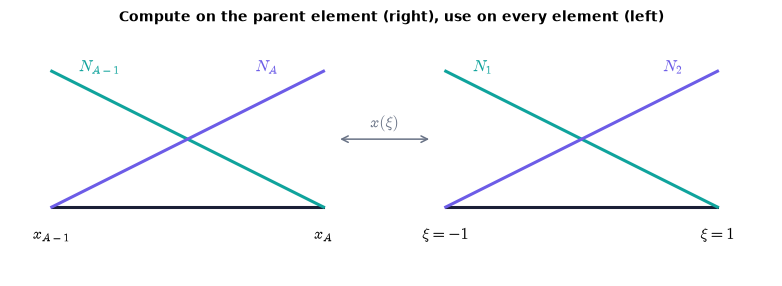

In [66]:
fig, ax = plt.subplots(figsize=(7, 2.8))   # the figure and its panels
element_map(ax)                                                # our Fig. 10.3: an element and its parent, with the map x(xi)
ax.set_title("Compute on the parent element (right), use on every element (left)", fontsize=9)   # the panel's title: what this panel shows
plt.show()   # display the figure

**What you see.** Two identical pictures at different scales: the element $[x_{A-1},x_A]$ with its two local shapes, and the parent element $[-1,1]$ with $N_1$, $N_2$.

**How to read it.** The map $x(\xi)$ stretches and shifts the parent onto the element; every integral is computed once on the parent.

**What would change if…** …a curved triangle (C13): the map becomes quadratic (10.184), $x(\xi,\eta)=\sum_{a=1}^6x^e_a\phi_a(\xi,\eta),\qquad y(\xi,\eta)=\sum_{a=1}^6y^e_a\phi_a(\xi,\eta)$ and the element can follow a circle.

> 📎 **Primer — affine map to a parent element.** `P234` · An affine map is "stretch and shift": $x(\xi)=\frac h2\xi+x_{mid}$ sends $\xi\in[-1,1]$ to $[x_a,x_b]$ with $h=x_b-x_a$. Its derivative is the constant
$dx/d\xi=h/2$, so $dx=\frac h2d\xi$ (substitution, Ch. 3 P106) and $d\xi/dx=2/h$ (chain rule, P49). Every element integral becomes an integral over $[-1,1]$.

In [67]:
xa, xb = 0.5, 0.75                  # an element of length h = 0.25
h = xb - xa
x = lambda xi: h/2*xi + (xa + xb)/2  # the map
print(x(-1), x(1), h/2, 2/h)        # 0.5 0.75 0.125 8.0 (dx/dxi and dxi/dx)

0.5 0.75 0.125 8.0


#### 🧮 Derivation — Parent element, the map and the slopes, with the printed index shift corrected `D13` (Eq. 10.68: $\frac{dN_A}{dx}=\frac{dN_2}{d\xi}\frac{d\xi}{dx}=+\frac{1}{x_A-x_{A-1}}$)

**What we want to show.** Compute shape-function slopes on any element from one standard 'parent' element.

**Assumptions.** A straight (affine) element of length $h^e=x_A-x_{A-1}>0$.

**The plan.**

1. Map the parent element onto $[x_{A-1},x_A]$.
2. Invert the map.
3. Chain rule for the slopes.
4. Say which global hat each local ramp is.

**Tools we use** (each explained before this point): Affine map to a parent element (primer P234) · chain rule (Ch. 1 P49).

**We start from**

$$ N_1(\xi)=\frac12(1-\xi)\ \text{,}\ N_2(\xi)=\frac12(1+\xi)\ \text{on ξ ∈ [−1, 1] (10.64)} $$

*In words:* two straight ramps on a standard interval.

---

**Step 1 of 7 — Build the map from the shapes.**

$$ x(\xi)=N_1(\xi)x^e_1+N_2(\xi)x^e_2,\quad x^e_1=x_{A-1},\ x^e_2=x_A $$

- *Why we can do this:* The same ramps that interpolate T interpolate the coordinate (isoparametric idea); ξ = −1 ↦ $x_{A-1}$, ξ = 1 ↦ $x_A$.
- *In words:* the parent interval stretched onto the element.

---

**Step 2 of 7 — Multiply out.**

$$ x(\xi)=\tfrac12\big[(x_A-x_{A-1})\xi+x_A+x_{A-1}\big]\ \text{(10.65)} $$

- *Why we can do this:* Insert (10.64), $N_1(\xi)=\tfrac12(1-\xi),\ N_2(\xi)=\tfrac12(1+\xi)$ and collect the ξ terms.
- *In words:* stretch by $h^e/2$, shift to the midpoint.

---

**Step 3 of 7 — Invert the map.**

$$ \xi(x)=\frac{2x-x_A-x_{A-1}}{x_A-x_{A-1}}\ \text{(10.66)} $$

- *Why we can do this:* Solve the linear equation (10.65), $x(\xi)=N_1(\xi)x^e_1+N_2(\xi)x^e_2=\tfrac12[(x_A-x_{A-1})\xi+x_A+x_{A-1}]$ for ξ.
- *In words:* where in the parent a point x sits.

---

**Step 4 of 7 — Differentiate the inverse.**

$$ \frac{d\xi}{dx}=\frac2{h^e} $$

- *Why we can do this:* (10.66), $\xi(x)=\tfrac{2x-x_A-x_{A-1}}{x_A-x_{A-1}}$ is linear in x with slope $2/(x_A-x_{A-1})$ (P234: dx = (h/2)dξ).
- *In words:* one unit of x is 2/h units of ξ.

---

**Step 5 of 7 — Parent slopes.**

$$ \frac{dN_1}{d\xi}=-\tfrac12,\qquad\frac{dN_2}{d\xi}=+\tfrac12 $$

- *Why we can do this:* Differentiate (10.64), $N_1(\xi)=\tfrac12(1-\xi),\ N_2(\xi)=\tfrac12(1+\xi)$. Each parent shape is a straight line in ξ, so its slope is a constant; we need these slopes for the chain rule next.
- *In words:* one ramp falls, one rises.

---

**Step 6 of 7 — Chain rule.**

$$ \frac{dN_1}{dx}=-\tfrac12\cdot\tfrac2{h^e}=-\frac1{h^e},\qquad\frac{dN_2}{dx}=+\frac1{h^e} $$

- *Why we can do this:* $\frac{dN}{dx}=\frac{dN}{d\xi} \frac{d\xi}{dx}$ (P49). N depends on x only through ξ(x), so the chain rule applies; step 4 supplies dξ/dx = 2/h.
- *In words:* slopes ∓1/h on the element.

---

**Step 7 of 7 — Name the global hats.**

$$ \frac{dN_{A-1}}{dx}=-\frac1{x_A-x_{A-1}},\qquad\frac{dN_A}{dx}=+\frac1{x_A-x_{A-1}}\quad\text{on }[x_{A-1},x_A] $$

- *Why we can do this:* On this element $N_1\leftrightarrow N_{A-1}$ and $N_2\leftrightarrow N_A$ (the book says so above (10.64)). The book prints (10.67)–(10.68) as $\frac{dN_A}{dx}=\frac{-1}{x_A-x_{A-1}}$, $\frac{dN_{A+1}}{dx}=\frac{1}{x_A-x_{A-1}}$, i.e. with the labels $N_A$ and $N_{A+1}$ — an index shift (slip #1); $N_{A+1}$ is zero here.
- *In words:* the falling ramp is the left node's hat, the rising one the right node's.

---

**Result**

$$ \text{On}\ [x_{A-1},x_A]\ \text{:}\ \frac{dN_{A-1}}{dx}=-\frac1{h^e}\ \text{,}\ \frac{dN_A}{dx}=+\frac1{h^e} $$

*In words:* every element's slopes come from the parent's ±½ times 2/h.

**What it means.** Every element integral can now be done on [−1, 1] (D14); in 2-D the same idea gives the isoparametric triangles of (10.184), $x(\xi,\eta)=\sum_{a=1}^6x^e_a\phi_a(\xi,\eta),\qquad y(\xi,\eta)=\sum_{a=1}^6y^e_a\phi_a(\xi,\eta)$.

**Check it.** Units 1/m ✓; the two slopes sum to zero (the hats sum to 1 on the element) ✓; `FEM1.shape_slopes(0.5, 0.75)` → (−4, +4) with labels (A − 1, A); the `printed=True` labels fail the chain-rule test.

> ⚠️ **Common confusion (traps in `D13`):** dξ/dx = h/2 (it is 2/h — that is dx/dξ); copying the printed labels A, A + 1.

📝 **Note.** **N35 [B]** **Shape-function slopes** by the chain rule, with the corrected labels: on the element $[x_{A-1},x_A]$,
$\frac{dN_{A-1}}{dx}=\frac{dN_1}{d\xi}\frac{d\xi}{dx}=-\frac{1}{x_A-x_{A-1}}$ *(10.67)* and $\frac{dN_A}{dx}=\frac{dN_2}{d\xi}\frac{d\xi}{dx}=+\frac{1}{x_A-x_{A-1}}$ *(10.68)*.

> ⚠️ **Printed slip.** **The book prints**, on the element $[x_{A-1},x_A]$, $\frac{dN_A}{dx}=\frac{2}{x_A-x_{A-1}}\frac{dN_1}{d\xi}=\frac{-1}{x_A-x_{A-1}},\qquad\frac{dN_{A+1}}{dx}=\frac{1}{x_A-x_{A-1}}$; **the correct labels are** $N_{A-1}$ (↔ $N_1$, slope $-1/h^e$) and
$N_A$ (↔ $N_2$, slope $+1/h^e$) — the text two lines earlier says so, and $N_{A+1}$ is zero on this element (slip #1).

In [68]:
print("correct:", FEM1.shape_slopes(0.5, 0.75))                # the element [0.5, 0.75]: labels (A-1, A), slopes (-4, +4) [1/m]
print("printed:", FEM1.shape_slopes(0.5, 0.75, printed=True))  # the book's labels (A, A+1): N_{A+1} is zero on this element
xs_ = np.array([0.55, 0.7])                                    # two points inside the element
nod_ = np.array([0.25, 0.5, 0.75, 1.0])                        # nodes x_{A-2} … x_{A+1} with A = 2 (x_A = 0.75)
slopes = [np.diff(FEM1.hat(xs_, nod_, j))/np.diff(xs_) for j in (1, 2, 3)]   # actual slopes of N_{A-1}, N_A, N_{A+1} there
print("actual slopes of N_(A-1), N_A, N_(A+1) on the element:", [float(s_[0]) for s_ in slopes])   # show the numbers computed above

correct: {'labels': ('A-1', 'A'), 'slopes': (-4.0, 4.0)}
printed: {'labels': ('A', 'A+1'), 'slopes': (-4.0, 4.0)}
actual slopes of N_(A-1), N_A, N_(A+1) on the element: [-4.0, 4.0, 0.0]


**What does the code above do?**

`shape_slopes(xa, xb)` returns the two slopes on the element with their global labels. The printed labels would give $N_{A+1}$ a slope of $+4$,
but the finite difference of the actual hats (last line) shows $N_{A-1}$: $-4$, $N_A$: $+4$ and $N_{A+1}$: 0 — the chain-rule check the printed labels fail.

📝 **Note.** **N36 [B]** **Global = sum of element pieces (10.69)–(10.70):** $\mathbf M=\sum_{e=1}^{n_{el}}\mathbf M^e$, $\mathbf K=\sum_e\mathbf K^e$, $\mathbf F=\sum_e\mathbf F^e$ —
because an integral over $[0,L]$ is the sum of integrals over the elements.

$$ \mathbf M=\sum_{e=1}^{n_{el}}\mathbf M^e,\ \mathbf K=\sum_{e=1}^{n_{el}}\mathbf K^e,\ \mathbf F=\sum_{e=1}^{n_{el}}\mathbf F^e \qquad \text{(10.69)} $$

> 📎 **Primer — scatter-add assembly (np.add.at, COO duplicates).** `P235` · Adding a small block into a big matrix at chosen rows and columns, where several blocks hit the same entry: `np.add.at(K, (rows, cols), block)` adds *every*
contribution (plain `K[rows, cols] += block` would keep only the last one when indices repeat). For sparse matrices, collect (row, col, value) triples and
build `scipy.sparse.coo_matrix(...).tocsr()` — duplicate entries are summed.

In [69]:
import numpy as np   # arrays and maths
K = np.zeros((3, 3))
block = np.array([[1.0, -1.0], [-1.0, 1.0]])    # one element's stiffness
for e in (0, 1):                                 # two elements: nodes (0,1) and (1,2)
    idx = np.array([e, e + 1])
    np.add.at(K, (idx[:, None], idx[None, :]), block)
print(K)                                         # middle diagonal 2: both elements added there

[[ 1. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]


📝 **Note.** **N37 [B]** **Element integrals (10.71)–(10.73):** $M^e_{AB}=\int_{\Omega^e}N_AN_B\,dx$ *(10.71)*, $K^e_{AB}=u\int_{\Omega^e}N_{B,x}N_A\,dx+D\int_{\Omega^e}N_{B,x}N_{A,x}\,dx$
*(10.72)*, and the force *(10.73)* whose $Dq$ term lives only on the last element.

> ⚠️ **Printed slip.** **The book prints** "the nonzero ones require that $A=e$ or $e+1$ and $B=e$ or $e+1$"; **with** $\Omega^e=[x_{A-1},x_A]$ **and the node map (10.78), $A=\begin{cases}e-1,&a=1\\ e,&a=2\end{cases}$ the nonzero
entries are** $A,B\in\{e-1,e\}$ (slip #2) — node 0 is the Dirichlet node, which is why the first element's force is $-g\,k^1_{a1}$.

📝 **Note.** **N38 [B]** **Local → global node map (10.78):** $A=e-1$ for $a=1$, $A=e$ for $a=2$.

$$ A=\begin{cases}e-1,&a=1\\ e,&a=2\end{cases} \qquad \text{(10.78)} $$

In [70]:
print("connectivity (10.78):\n", FEM1.connectivity(4))           # rows e = 1 … 4: global nodes of local nodes 1 and 2
print("the printed labels:\n", FEM1.connectivity(4, printed=True))   # points at a node 5 that does not exist (nodes are 0 … 4)

connectivity (10.78):
 [[0 1]
 [1 2]
 [2 3]
 [3 4]]
the printed labels:
 [[1 2]
 [2 3]
 [3 4]
 [4 5]]


**What does the code above do?**

With 4 elements the nodes are $0\dots4$. The correct map gives element $e$ the nodes $(e-1,e)$; the printed labels $(e,e+1)$ never touch the Dirichlet
node 0 and reach a node 5 that does not exist.

#### 🧮 Derivation — Element matrices $\mathbf m^e=\frac h6\begin{pmatrix}2&1\\1&2\end{pmatrix}$, $\mathbf k^e=\frac u2\begin{pmatrix}-1&1\\-1&1\end{pmatrix}+\frac Dh\begin{pmatrix}1&-1\\-1&1\end{pmatrix}$, the force and assembly into `D14` (Eq. 10.77: $f^e_a=Dq\,\delta_{e\,n_{el}}\delta_{a2}-g\,k^e_{a1}\delta_{e1}$)

**What we want to show.** Write out the numbers the book never shows — the 2 × 2 element blocks of (10.75)–(10.77) — and check that adding them up gives the interior row (10.63), $\tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0$.

**Assumptions.** Linear elements of length h; node 0 Dirichlet (value g), node n Neumann (datum q).

**The plan.**

1. Change variables to the parent element.
2. Integrate the mass, convective and diffusive products.
3. Place the boundary data.
4. Scatter-add and compare with D12.

**Tools we use** (each explained before this point): Affine map dx = (h/2)dξ (P234) and substitution (Ch. 3 P106) · D13 slopes · scatter-add (primer P235).

**We start from**

$$ \begin{array}{l}m^e_{ab}=\int_{\Omega^e}N_aN_b\,dx\ \text{(10.75)} \\ k^e_{ab}=u\int_{\Omega^e}N_{b,x}N_a\,dx+D\int_{\Omega^e}N_{b,x}N_{a,x}\,dx\ \text{(10.76)} \\ f^e_a=Dq\,\delta_{e\,n_{el}}\delta_{a2}-g\,k^e_{a1}\delta_{e1}\ \text{(10.77)}\end{array} $$

*In words:* the element versions of M, K, F.

---

**Step 1 of 11 — Change variables.**

$$ \int_{\Omega^e}f\,dx=\frac h2\int_{-1}^1f\,d\xi $$

- *Why we can do this:* dx = (h/2)dξ on the affine element (P234, P106).
- *In words:* every element integral becomes one on [−1, 1].

---

**Step 2 of 11 — Mass, diagonal.**

$$ m^e_{11}=\frac h2\int_{-1}^1\tfrac14(1-\xi)^2d\xi=\frac h2\cdot\frac14\cdot\frac83=\frac h3 $$

- *Why we can do this:* ∫₋₁¹(1 − ξ)²dξ = 8/3; the same for $m^e_{22}$ by symmetry.
- *In words:* each ramp overlaps itself: h/3.

---

**Step 3 of 11 — Mass, off-diagonal.**

$$ m^e_{12}=\frac h2\int_{-1}^1\tfrac14(1-\xi^2)d\xi=\frac h2\cdot\frac14\cdot\frac43=\frac h6 $$

- *Why we can do this:* $(1-\xi)(1+\xi)=1-\xi^2$; ∫₋₁¹(1 − ξ²)dξ = 4/3.
- *In words:* the two ramps overlap: h/6.

---

**Step 4 of 11 — Collect the mass block.**

$$ \mathbf m^e=\frac h6\begin{pmatrix}2&1\\1&2\end{pmatrix} $$

- *Why we can do this:* Steps 2–3 (h/3 = 2h/6); symmetric because $N_aN_b=N_bN_a$.
- *In words:* the element mass matrix.

---

**Step 5 of 11 — Area under one ramp.**

$$ \int_{\Omega^e}N_a\,dx=\frac h2\int_{-1}^1\tfrac12(1\mp\xi)\,d\xi=\frac h2 $$

- *Why we can do this:* Each ramp is a triangle of height 1 and base h.
- *In words:* half the element length.

---

**Step 6 of 11 — Convective block.**

$$ u\int N_{b,x}N_a\,dx=u\cdot\frac{dN_b}{dx}\cdot\frac h2\ \Rightarrow\ \frac u2\begin{pmatrix}-1&1\\-1&1\end{pmatrix} $$

- *Why we can do this:* The slope of $N_b$ is constant (∓1/h, D13) and comes out; row a, column b: every row gets (−u/2, +u/2). Not symmetric.
- *In words:* convection's block depends only on the column.

---

**Step 7 of 11 — Diffusive block.**

$$ D\int N_{b,x}N_{a,x}\,dx=D\,(\mp\tfrac1h)(\mp\tfrac1h)\,h\ \Rightarrow\ \frac Dh\begin{pmatrix}1&-1\\-1&1\end{pmatrix} $$

- *Why we can do this:* Product of two constant slopes times the length h; equal slopes give +, opposite −.
- *In words:* diffusion's block is symmetric.

---

**Step 8 of 11 — Add them.**

$$ \mathbf k^e=\frac u2\begin{pmatrix}-1&1\\-1&1\end{pmatrix}+\frac Dh\begin{pmatrix}1&-1\\-1&1\end{pmatrix} $$

- *Why we can do this:* (10.76), $k^e_{ab}=u\int_{\Omega^e}N_{b,x}N_a\,dx+D\int_{\Omega^e}N_{b,x}N_{a,x}\,dx$ is the sum of the two integrals.
- *In words:* the element stiffness matrix; each row sums to zero.

---

**Step 9 of 11 — Place the boundary data.**

$$ f^1_a=-g\,k^1_{a1},\qquad f^{n_{el}}_a=Dq\,\delta_{a2},\qquad f^e_a=0\ \text{otherwise}\ \text{(10.77)} $$

- *Why we can do this:* On element 1 local node 1 is the Dirichlet node 0: its known value g times its column moves to the right side; the flux datum lives at the last node. The book's text says 'A = e or e + 1'; with (10.78), $A=\begin{cases}e-1,&a=1\\ e,&a=2\end{cases}$ it is A ∈ {e − 1, e} (slip #2).
- *In words:* known values become forces.

---

**Step 10 of 11 — Scatter-add into node A's row.**

$$ \text{row }A:\ \big(k^{(A)}_{21},\ k^{(A)}_{22}+k^{(A+1)}_{11},\ k^{(A+1)}_{12}\big)\ \text{at columns (A − 1, A, A + 1)} $$

- *Why we can do this:* Node A is local node 2 of element A and local node 1 of element A + 1 (10.78), $A=\begin{cases}e-1,&a=1\\ e,&a=2\end{cases}$; `np.add.at` adds both contributions (P235).
- *In words:* an interior row collects pieces from its two elements.

---

**Step 11 of 11 — Compare with (10.63).**

$$ \big(-\tfrac u2-\tfrac Dh,\ \tfrac{2D}h,\ \tfrac u2-\tfrac Dh\big),\qquad h\big(\tfrac16,\ \tfrac23,\ \tfrac16\big) $$

- *Why we can do this:* Insert steps 8 and 4 into step 10 (for M: h/6, h/3 + h/3, h/6). This is (10.63), $\tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0$ multiplied by h — D12 recovered element by element.
- *In words:* assembly rebuilds the same row.

---

**Result**

$$ \text{The element blocks above and}\ \mathbf M=\sum_e\mathbf M^e\ \text{,}\ \mathbf K=\sum_e\mathbf K^e\ \text{,}\ \mathbf F=\sum_e\mathbf F^e\ \text{(10.69)} $$

*In words:* one 2 × 2 block per element, added at the element's two global nodes, rebuilds the global matrices.

**What it means.** The loop 'compute on the parent, scatter-add' is the whole of FE assembly — the same code shape handles the curved P2 triangles of the cylinder (N104–N109).

**Check it.** (h, u, D) = (0.25, 1, 0.25): m = [[0.0833, 0.0417], [0.0417, 0.0833]], k = [[0.5, −0.5], [−1.5, 1.5]], node 2's row (−1.5, 2, −0.5) ✓; the 2-point Gauss–Legendre integration (`FEM1.element_integrals`) gives the same to 1e-15.

> ⚠️ **Common confusion (traps in `D14`):** Writing the convective block symmetric (row a, column b: the slope belongs to b); the force on element 1 (the Dirichlet column, not a flux); the book's A = e, e + 1 labels.

#### ✏️ Tiny example: the element blocks with h = 0.25, u = 1, D = 0.25

1. Mass: $(h/6)\begin{pmatrix}2&1\\1&2\end{pmatrix}=\begin{pmatrix}0.0833&0.0417\\0.0417&0.0833\end{pmatrix}$.
2. Convection: $(u/2)\begin{pmatrix}-1&1\\-1&1\end{pmatrix}=\begin{pmatrix}-0.5&0.5\\-0.5&0.5\end{pmatrix}$ — not symmetric.
3. Diffusion: $(D/h)\begin{pmatrix}1&-1\\-1&1\end{pmatrix}=\begin{pmatrix}1&-1\\-1&1\end{pmatrix}$.
4. $\mathbf k^e=\begin{pmatrix}0.5&-0.5\\-1.5&1.5\end{pmatrix}$; each row sums to 0 (a constant $T$ has no convection and no diffusion).
5. Node 2 sits in element 2 (as local node 2) and element 3 (as local node 1): its row collects $(k_{21},k_{22})=(-1.5,1.5)$ at columns (1, 2) and
   $(k_{11},k_{12})=(0.5,-0.5)$ at columns (2, 3): total $(-1.5,2.0,-0.5)$ — the row C07 found from (10.63), $\tfrac{d}{dt}\Big(\tfrac{T_{A-1}}{6}+\tfrac{2T_A}{3}+\tfrac{T_{A+1}}{6}\Big)+\tfrac{u}{2h}(T_{A+1}-T_{A-1})-\tfrac{D}{h^2}(T_{A-1}-2T_A+T_{A+1})=0$.

In [71]:
m, k = FEM1.element_matrices_linear(0.25, 1.0, 0.25)           # D14's closed-form blocks (h, u, D)
mg, kg = FEM1.element_integrals(0.5, 0.75, 1.0, 0.25, quad=2)  # the same integrals by 2-point Gauss-Legendre (P143)
print("m^e =\n", m.round(4), "\nk^e =\n", k)   # show the numbers computed above
assert np.allclose(m, mg) and np.allclose(k, kg)               # quadrature is exact for these polynomial integrands
trace = FEM1.assembly_trace(4, 1.0, 0.25)                      # the element loop, step by step
for st_ in trace:                                              # after each element: its global nodes and node 2's row of K
    print(f"after element {st_['e']}: nodes {st_['nodes']}, K row of node 2 = {np.round(st_['K_after'][2], 3)}")   # show the numbers computed above
print("element forces with g = 1, q = 0.5: first", FEM1.element_force(1, 4, 0.25, 1.0, 0.25, g=1.0, q=0.5),
      " last", FEM1.element_force(4, 4, 0.25, 1.0, 0.25, g=1.0, q=0.5))

m^e =
 [[0.0833 0.0417]
 [0.0417 0.0833]] 
k^e =
 [[ 0.5 -0.5]
 [-1.5  1.5]]
after element 1: nodes [0, 1], K row of node 2 = [0. 0. 0. 0. 0.]
after element 2: nodes [1, 2], K row of node 2 = [ 0.  -1.5  1.5  0.   0. ]
after element 3: nodes [2, 3], K row of node 2 = [ 0.  -1.5  2.  -0.5  0. ]
after element 4: nodes [3, 4], K row of node 2 = [ 0.  -1.5  2.  -0.5  0. ]
element forces with g = 1, q = 0.5: first [-0.5  1.5]  last [0.    0.125]


**What does the code above do?**

1. `element_matrices_linear(h, u, D)` returns $\mathbf m^e$ and $\mathbf k^e$ of D14; `element_integrals` computes the same integrals numerically with 2-point
   Gauss–Legendre on the parent element — exact here, because the integrands are polynomials of degree ≤ 2.
2. `assembly_trace` runs the element loop and records the global matrix after each element: node 2's row is empty, then receives $(-1.5,1.5)$ from element 2,
   then $(0.5,-0.5)$ from element 3 — total $(-1.5,2,-0.5)$.
3. `element_force` (10.77), $f^e_a=Dq\,\delta_{e\,n_{el}}\delta_{a2}-g\,k^e_{a1}\delta_{e1}$: the first element carries $-g\,k^1_{a1}=(-0.5,1.5)$ for $g=1$ (the known Dirichlet value times its column), the last one carries
   $Dq=0.125$ at its right node.

In [72]:
# from scratch: the element loop with np.add.at, then the steady solve
nod = np.linspace(0, 1, 5); h = nod[1] - nod[0]; u, D = 1.0, 0.25   # 4 elements
m_e = h/6*np.array([[2, 1], [1, 2]])                                  # element mass (D14)
k_e = u/2*np.array([[-1, 1], [-1, 1]]) + D/h*np.array([[1, -1], [-1, 1]])   # element stiffness (D14)
M_mine = np.zeros((5, 5)); K_mine = np.zeros((5, 5))                  # global matrices for nodes 0 … 4
for e in range(1, 5):                                                 # element e has global nodes (e-1, e) (10.78)
    idx = np.array([e - 1, e])
    np.add.at(M_mine, (idx[:, None], idx[None, :]), m_e)              # scatter-add (P235)
    np.add.at(K_mine, (idx[:, None], idx[None, :]), k_e)
assert np.allclose(K_mine[1:-1, 1:-1], FEM1.assemble_1d(nod, u, D, dirichlet_right=1.0)[1].toarray())   # interior block = library K
T_mine = np.zeros(5); T_mine[-1] = 1.0                                # Dirichlet ends: T_0 = 0, T_4 = 1
T_mine[1:-1] = np.linalg.solve(K_mine[1:-1, 1:-1], -K_mine[1:-1, -1]*1.0)   # move the known T_4 column to the right side
print("steady solution by hand:", T_mine)   # show the numbers computed above
assert np.allclose(T_mine, FEM1.solve_steady(nod, u, D, T_L=1.0)["T"])   # the library does exactly this

steady solution by hand: [0.    0.025 0.1   0.325 1.   ]


**What does the code above do?**

1. The two $2\times2$ blocks of D14 are scatter-added into $5\times5$ matrices at the rows and columns $(e-1,e)$ of each element.
2. Deleting the two Dirichlet rows and columns leaves the $3\times3$ interior block — identical to the library's $\mathbf K$.
3. The known $T_4=1$ times its column moves to the right-hand side (the $-g\,k_{a1}$ idea of (10.77), $f^e_a=Dq\,\delta_{e\,n_{el}}\delta_{a2}-g\,k^e_{a1}\delta_{e1}$, here at the right end), and `np.linalg.solve`
   returns the same steady solution as `FEM1.solve_steady`.

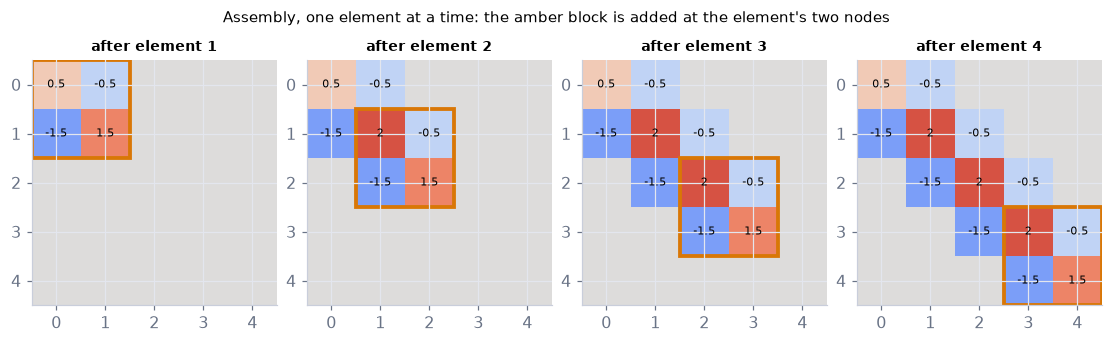

In [73]:
fig, axs = plt.subplots(1, 4, figsize=(10, 3.0))   # the figure and its panels
trace = FEM1.assembly_trace(4, 1.0, 0.25)                      # K after each of the 4 elements
for ax, st_ in zip(axs, trace):   # repeat the indented lines for each item listed
    Kd = np.array(st_["K_after"])                              # the global 5 x 5 matrix so far
    ax.imshow(Kd, cmap="coolwarm", vmin=-2.5, vmax=2.5)        # heat-coloured cells (red positive, blue negative)
    for (r_, c_), v_ in np.ndenumerate(Kd):   # repeat the indented lines for each item listed
        if v_ != 0: ax.text(c_, r_, f"{v_:g}", ha="center", va="center", fontsize=7)   # the numbers in the cells
    a_, b_ = st_["nodes"]
    ax.add_patch(plt.Rectangle((a_ - 0.5, a_ - 0.5), 2, 2, fill=False, ec=COLORS["amber"], lw=2.5))   # the element's block
    ax.set_title(f"after element {st_['e']}", fontsize=9); ax.set_xticks(range(5)); ax.set_yticks(range(5))   # the panel's title: what this panel shows
fig.suptitle("Assembly, one element at a time: the amber block is added at the element's two nodes", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Four snapshots of the global $5\times5$ stiffness matrix: a band filling in from the top left, the current element's $2\times2$ block outlined in amber.

**How to read it.** Interior diagonal entries receive two pieces (1.5 + 0.5 = 2); the matrix is tridiagonal because hats only overlap their neighbours.

**What would change if…** …triangles in 2-D: the same loop with $3\times3$ (P1) or $6\times6$ (P2) blocks and an irregular pattern (N102's sparsity picture).

#### 🎮 Interactive: Where do finite-element matrices come from?

**Why interactive rather than a static figure:** The transport steps element by element, lighting up the element on the mesh, its two hat halves and the four matrix cells it adds to — the sum sign of (10.69), $\mathbf M=\sum_{e=1}^{n_{el}}\mathbf M^e,\ \mathbf K=\sum_{e=1}^{n_{el}}\mathbf K^e,\ \mathbf F=\sum_{e=1}^{n_{el}}\mathbf F^e$ happens in front of you, and the interior row becomes the FD stencil with a ⅙–⅔–⅙ mass.

**What to try:**
- Press the 'n = 4 by hand' preset and step through the four elements; stop at e = 3 and read node 2's row.
- Click a matrix cell to see which elements contributed and the integral behind each number.
- Raise R until the FE solution wiggles — it wiggles exactly where centred FD does (C09).

In [74]:
show_viz("ch10", "fem_hat_assembly")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/fem_hat_assembly]

📝 **Note.** **N39 [C]** **2-D and 3-D** follow the same steps — parent element, map, element matrices, scatter-add — with triangles or tetrahedra. *Pointer:* C13 (mixed
elements) and the cylinder mesh of §10.5 (N93–N109).

**What would change if…** …the flow were fast and the diffusion small? Both FD and FE produce the same centred equations — and the same wiggles. §10.4 starts there.

---

## 10.4 Incompressible Viscous Fluid Flow

**What is this section about?** Now the real equations: Navier–Stokes with $\nabla\cdot\mathbf u=0$. Two difficulties stand between them and a working code.
First, when convection dominates, thin layers form that a grid cannot resolve, and centred schemes answer with wiggles (C09). Second, incompressibility is
not an evolution equation but a *constraint*: nothing tells the pressure how to change in time, yet the pressure must be whatever keeps every cell's net
outflow zero. Four answers follow — let the fluid be slightly compressible (C10), split each time step and project the velocity onto the divergence-free
fields (C11) on a staggered grid (C12), or choose finite-element spaces that respect the constraint (C13). The staggered grid and the projection are
exactly what ocean and atmosphere models use.

> 🔁 **Recap — R06 · Incompressible Navier–Stokes** (Ch. 4 §4.2, §4.6). Ch. 4 gave $\rho\Big(\frac{\partial\mathbf u}{\partial t}+(\mathbf u\cdot\nabla)\mathbf u\Big)=\rho\mathbf g-\nabla p+\mu\nabla^2\mathbf u$ *(10.79)* and $\nabla\cdot\mathbf u=0$ *(10.80)* — the incompressible momentum and mass balances (Ch. 4's $\rho\frac{D\mathbf u}{Dt}=-\nabla p+\rho\mathbf g+\mu\nabla^2\mathbf u$ *(4.39b)* and $\nabla\cdot\mathbf u=0$ *(4.10)*). `core.navier_stokes` residuals are the code-verification tool for every solver below.

> 🔁 **Recap — R07 · Dimensionless Navier–Stokes** (Ch. 4 §4.11). Scaling lengths by $L$, speeds by $U$, time by $L/U$ and pressure by $\rho U^2$ (Ch. 4 §4.11) leaves one number: $\frac{\partial\mathbf u}{\partial t}+(\mathbf u\cdot\nabla)\mathbf u=\mathbf g-\nabla p+\frac1{Re}\nabla^2\mathbf u$ *(10.81)*, $Re=UL/\nu$. Every solver of §10.4–10.5 integrates this form.

### 🧩 Convection-dominated flow: wiggles for R_cell > 2 and numerical diffusion `C09`

*The question:* Why does a consistent, centred scheme produce negative temperatures next to a hot wall — and why is the upwind cure 'stable but wrong'?

*In one line:* $\delta=O\Big(\dfrac{L}{nR_{cell}}\Big)=O\Big(\dfrac{\Delta x}{R_{cell}}\Big)$ *(10.92)* · $u\dfrac{\partial T}{\partial x}=D\,(1+0.5R_{cell})\dfrac{\partial^2T}{\partial x^2}$ *(10.94)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **linear second-order ODE by an exponential trial** — try $e^{mx}$; the ODE becomes a quadratic for m (Ch. 1 P44).
- **np.expm1 and overflow-safe exponentials** — `np.expm1(x)` = e^x − 1 without cancellation near 0; rewriting a ratio of large exponentials avoids overflow (Ch. 3 P107).
- **natural logarithm and exponential (e⁻¹, e⁻²)** — e⁻¹ ≈ 0.368 and e⁻² ≈ 0.135 — computed by `np.exp`, never typed (Ch. 1 P36).
- **quadratic formula and its roots** — a r² + b r + c = 0 ⇒ r = (−b ± √(b² − 4ac))/(2a) (Ch. 6 P159).
- **tridiagonal solve (Thomas algorithm)** — a tridiagonal system is solved in O(N) operations by `solve_banded` (Ch. 8 P193).

📝 **Note.** **N40 [C]** **Scope of §10.4:** primitive variables (velocity and pressure); streamfunction–vorticity forms exist (the $\psi$ Poisson solve of Ch. 6,
`solve_poisson`) but do not extend to 3-D; laminar flow only — turbulence models are Ch. 12.

📝 **Note.** **N42 [B]** **The two difficulties** (the map of this section): (1) convection-dominated problems oscillate on grids that do not resolve thin layers → C09;
(2) continuity is a constraint that determines the pressure → C10 (weak compressibility), C11–C12 (projection), C13 (mixed elements).

#### The problem in plain words

Warm water flows at speed $u$ towards a wall held at temperature 1, while the inflow is at 0. Heat carried towards the wall must be conducted away through a
thin layer next to it; far from the wall nothing happens. If the grid spacing is wider than that layer, the centred scheme cannot balance "heat in" and
"heat out" at the last interior node — and it answers with a temperature *below* the inflow value, then above, then below: a zigzag. The same happens to a
sharp tracer front in an ocean model. Upwinding removes the zigzag, but only by quietly making the fluid more diffusive.

#### The idea

```
T                                  exact: e^{−R(1−x/L)}, a layer of thickness L/R at the wall
1 ┤                         ╭─●          centred:  T_j = (r^j − 1)/(r^n − 1),  r = (1 + R_cell/2)/(1 − R_cell/2)
  │                        ╱               R_cell < 2: r > 0  ⇒ smooth     R_cell > 2: r < 0  ⇒ signs alternate
0 ┼──●───●───●───●───●───●╯              upwind:   r = 1 + R_cell > 0 always — but it solves D(1 + 0.5 R_cell)
  └─────────── x ───────────┘ L
```

📝 **Note.** **N43 [B]** **The steady test problem (10.84)–(10.85):** $u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2}$, $0\le x\le L$ *(10.84)*, with $T(0)=0$ and $T(L)=1$
*(10.85)* — steady (10.1), $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2},\quad 0\le x\le L$: convection towards the wall at $x=L$ balances conduction.

#### 🧮 Derivation — The exact steady solution $T=\frac{e^{Rx/L}-1}{e^R-1}$, $R=uL/D$, its large-R form $T=e^{-R(1-x/L)}$ and $\frac\delta L=O\big(\frac1{\lvert R\rvert}\big)$ `D15` (Eq. 10.89: $\dfrac{\delta}{L}=O\Big(\dfrac{1}{\lvert R\rvert}\Big)$)

**What we want to show.** Solve the steady convection–diffusion problem exactly and see the thin layer at the wall.

**Assumptions.** u, D constant, D > 0; R > 0 (flow toward x = L) in steps 7–8.

**The plan.**

1. Exponential trial.
2. Two roots, general solution.
3. Fit the end values.
4. Take R large.

**Tools we use** (each explained before this point): Linear ODE with constant coefficients by an exponential trial (Ch. 1 P44) · Péclet number (primer P229) · `np.expm1` for the numbers (Ch. 3 P107).

**We start from**

$$ u\frac{dT}{dx}=D\frac{d^2T}{dx^2}\ \text{on 0 ≤ x ≤ L (10.84), T(0) = 0, T(L) = 1 (10.85)} $$

*In words:* heat carried to a hot wall balances heat conducted.

---

**Step 1 of 8 — Rewrite as a homogeneous ODE.**

$$ D\,T''-u\,T'=0 $$

- *Why we can do this:* Subtract uT′ from both sides; a constant-coefficient linear ODE.
- *In words:* diffusion minus convection is zero.

---

**Step 2 of 8 — Try $T=e^{mx}$.**

$$ Dm^2-um=0 $$

- *Why we can do this:* P44: the exponential's derivatives are multiples of itself; divide by $e^{mx}\ne0$.
- *In words:* an algebraic equation for m.

---

**Step 3 of 8 — Solve for m.**

$$ m=0\quad\text{or}\quad m=\frac uD $$

- *Why we can do this:* Factor m(Dm − u) = 0.
- *In words:* a constant and an exponential.

---

**Step 4 of 8 — Write the general solution.**

$$ T=A+B\,e^{ux/D} $$

- *Why we can do this:* Two distinct roots, superposition of the two solutions.
- *In words:* two constants to fix.

---

**Step 5 of 8 — Use T(0) = 0.**

$$ A=-B $$

- *Why we can do this:* At x = 0, A + B = 0.
- *In words:* the inflow value.

---

**Step 6 of 8 — Use T(L) = 1.**

$$ T=\frac{e^{Rx/L}-1}{e^R-1},\qquad R=\frac{uL}D\ \text{(10.86)–(10.87)} $$

- *Why we can do this:* $B(e^{uL/D}-1)=1$, so $B=1/(e^R-1)$; write $ux/D=Rx/L$. Two conditions fix the two constants A and B; the result depends on u, D and L only through R.
- *In words:* the exact profile; one number R controls it.

---

**Step 7 of 8 — Let R be large.**

$$ T\approx\frac{e^{Rx/L}}{e^R}=e^{-R(1-x/L)}\ \text{(10.88)} $$

- *Why we can do this:* For R ≫ 1, $e^R\gg1$; and wherever T is not tiny, $e^{Rx/L}\gg1$ too, so the 1s are negligible.
- *In words:* an exponential rise at the wall.

---

**Step 8 of 8 — Read the layer thickness.**

$$ 1-\frac xL=\frac1R:\ T=e^{-1}=0.368;\quad\frac2R:\ T=e^{-2}=0.135\ \Rightarrow\ \frac\delta L=O\Big(\frac1{\lvert R\rvert}\Big)\ \text{(10.89)} $$

- *Why we can do this:* T falls by a factor e every L/R away from the wall; e⁻¹ and e⁻² are computed, not quoted.
- *In words:* the layer is L/R thick.

---

**Result**

$$ \begin{array}{l}T=\dfrac{e^{Rx/L}-1}{e^R-1}\ \text{(10.86)} \\ R=uL/D\ \text{(10.87)} \\ T=e^{-R(1-x/L)}\ \text{(10.88)} \\ \dfrac{\delta}{L}=O\Big(\dfrac{1}{\lvert R\rvert}\Big)\ \text{(10.89)}\end{array} $$

*In words:* at high Péclet number all the change happens in a layer of thickness L/R at the downstream wall.

**What it means.** A grid must put points inside this layer — C09's cell Péclet condition (D16). The same boundary-layer structure is Ch. 9's, with the layer thickness δ/L ~ 1/R here and δ/L ~ 1/√Re in Ch. 9.

**Check it.** R → 0: T → x/L (pure conduction, via $e^{\varepsilon}$ ≈ 1 + ε) ✓; T(0) = 0, T(L) = 1 ✓; R = 4, x = 0.75: 0.3561 ✓ (the tiny example of C07). The printed form overflows at R ≈ 710 (e^R > 1.8 × 10³⁰⁸) — the code uses $e^{-R(1-x/L)}\frac{1-e^{-Rx/L}}{1-e^{-R}}$.

> ⚠️ **Common confusion (traps in `D15`):** Coding (10.86), $T=\dfrac{e^{Rx/L}-1}{e^R-1}$ as printed for large R (overflow → NaN); calling the layer thickness L·R.

📝 **Note.** **N44 [B], N45 [B]** **Exact solution and its layer (10.86)–(10.89):** $T=\frac{e^{Rx/L}-1}{e^R-1}$ *(10.86)* with the global Péclet number $R=uL/D$ *(10.87)*; for large
$R$, $T=e^{-R(1-x/L)}$ *(10.88)*, a layer of thickness $\frac\delta L=O\big(\frac1{\lvert R\rvert}\big)$ *(10.89)*. One layer thickness from the wall $T=e^{-1}$ of the wall
value, two thicknesses $e^{-2}$ (the cell computes both). ⚠️ The printed form (10.86) overflows for $R\gtrsim700$ — `FD.steady_cd_exact` uses the scaled form
$e^{-R(1-x/L)}\frac{1-e^{-Rx/L}}{1-e^{-R}}$ (`np.expm1`, Ch. 3 P107).

In [75]:
print(f"e^-1 = {np.exp(-1):.4f}, e^-2 = {np.exp(-2):.4f}")          # T one and two layer thicknesses from the wall
print("T(0.99), T(0.999) at R = 1e4:", [f"{v:.2e}" for v in FD.steady_cd_exact(np.array([0.99, 0.999]), 1e4)])   # finite: the scaled form
with np.errstate(over="ignore", invalid="ignore"):                  # the printed form (10.86) at the same R overflows
    print("printed form at R = 1e4:", (np.exp(1e4*0.99) - 1)/(np.exp(1e4) - 1))   # show the numbers computed above
print("layer thickness at R = 100 (T = e^-1 level):", FD.cd_layer_thickness(100.0), "m")   # L/R with L = 1 m

e^-1 = 0.3679, e^-2 = 0.1353
T(0.99), T(0.999) at R = 1e4: ['3.72e-44', '4.54e-05']
printed form at R = 1e4: nan
layer thickness at R = 100 (T = e^-1 level): 0.01 m


**What does the code above do?**

1. $e^{-1}=0.368$ and $e^{-2}=0.135$: the temperature one and two layer thicknesses away from the wall (computed, not quoted).
2. At $R=10^4$ the scaled form gives $e^{-100}\approx3.7\times10^{-44}$ and $e^{-10}\approx4.5\times10^{-5}$; the printed form gives `nan` ($\infty/\infty$).
3. `cd_layer_thickness(R)` finds where $T=e^{-1}$: $L/R=0.01$ m.

📝 **Note.** **N46 [B]** **Centred differences (10.90)–(10.91):** $\frac{u\Delta x}{2D}(T_{j+1}-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$ *(10.90)*, i.e.
$0.5R_{cell}(T_{j+1}-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$ *(10.91)* with $\Delta x=L/n$ and $R_{cell}=u\Delta x/D=R/n$. (Grid index $j$ here, as in the book.)

> 📎 **Primer — linear recurrence with constant coefficients (geometric trial).** `P236` · An equation linking neighbours with constant weights, $aT_{j+1}+bT_j+cT_{j-1}=0$, is the discrete twin of a constant-coefficient ODE (Ch. 1 P44). Try
$T_j=r^j$: dividing by $r^{j-1}$ gives the quadratic $ar^2+br+c=0$. With two roots $r_1\ne r_2$ the general solution is $Ar_1^j+Br_2^j$; the two end values fix
$A$ and $B$. A **negative** root makes $r^j$ flip sign at every step.

In [76]:
import numpy as np   # arrays and maths
a, b, c = 1.0, -2.0, -3.0                  # T_{j+1} - 2T_j - 3T_{j-1} = 0
r = np.roots([a, b, c]); print(r)          # [ 3. -1.]: one root is negative
print([(-1.0)**j for j in range(5)])       # 1, -1, 1, -1, 1: the zigzag it produces

[ 3. -1.]
[1.0, -1.0, 1.0, -1.0, 1.0]


#### 🧮 Derivation — The centred discrete solution $T_j=\frac{r^j-1}{r^n-1}$, $r=\frac{1+R_{cell}/2}{1-R_{cell}/2}$: wiggles iff $R_{cell}>2$, i.e. $\delta=O\big(\frac\Delta x{R_{cell}}\big)$ below half a cell `D16` (Eq. 10.92: $\delta=O\Big(\dfrac{L}{nR_{cell}}\Big)=O\Big(\dfrac{\Delta x}{R_{cell}}\Big)$)

**What we want to show.** Solve the centred difference equations exactly (the book only argues with a heat balance) and find precisely when they produce sign-alternating values.

**Assumptions.** Uniform grid Δx = L/n; u > 0, so R_cell > 0.

**The plan.**

1. Scale to the book's (10.90)–(10.91), $\frac{u\Delta x}{2D}(T_{j+1}-T_{j-1})=T_{j+1}-2T_j+T_{j-1},\ 0.5R_{cell}(T_{j+1}-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$.
2. Try $T_j=r^j$.
3. Solve the quadratic.
4. Fit the ends.
5. Read the sign of r; compare with upwind.

**Tools we use** (each explained before this point): Linear recurrence with constant coefficients (primer P236) · quadratic formula.

**We start from**

$$ \text{Centred differences of (10.84):}\ u\frac{T_{j+1}-T_{j-1}}{2\Delta x}=D\frac{T_{j+1}-2T_j+T_{j-1}}{\Delta x^2}\ \text{,}\ T_0=0\ \text{,}\ T_n=1 $$

*In words:* the discrete balance at every interior node.

---

**Step 1 of 12 — Multiply by Δx²/D.**

$$ \frac{u\Delta x}{2D}(T_{j+1}-T_{j-1})=T_{j+1}-2T_j+T_{j-1}\ \text{(10.90)} $$

- *Why we can do this:* Clears both denominators. Multiplying both sides by the same nonzero number keeps the equation; it leaves pure grid differences on both sides.
- *In words:* the balance in grid units.

---

**Step 2 of 12 — Name the cell Péclet number.**

$$ 0.5R_{cell}(T_{j+1}-T_{j-1})=T_{j+1}-2T_j+T_{j-1},\quad R_{cell}=\frac{u\Delta x}D=\frac Rn\ \text{(10.91)} $$

- *Why we can do this:* $\frac{u\Delta x}{2D}=\frac12R_{cell}$ and Δx = L/n. We write P = R_cell below.
- *In words:* one number per cell.

---

**Step 3 of 12 — Try a geometric sequence.**

$$ T_j=r^j $$

- *Why we can do this:* P236: constant coefficients linking neighbours ⇒ powers solve it, as $e^{mx}$ solved the ODE (D15).
- *In words:* each node is r times the previous.

---

**Step 4 of 12 — Substitute.**

$$ 0.5P\,(r^{j+1}-r^{j-1})=r^{j+1}-2r^j+r^{j-1} $$

- *Why we can do this:* Step 3 in step 2. The trial must satisfy the recurrence at every node j, so we insert it and see what that demands of r.
- *In words:* the recurrence for the trial.

---

**Step 5 of 12 — Divide by $r^{j-1}$.**

$$ 0.5P\,(r^2-1)=r^2-2r+1 $$

- *Why we can do this:* $r\ne0$ (a zero root would give T ≡ 0).
- *In words:* an equation for r alone.

---

**Step 6 of 12 — Collect as a quadratic.**

$$ (1-0.5P)\,r^2-2r+(1+0.5P)=0 $$

- *Why we can do this:* Move everything to one side and group the powers of r.
- *In words:* a quadratic in r.

---

**Step 7 of 12 — Solve it.**

$$ r=\frac{1\pm0.5P}{1-0.5P}:\qquad r_1=1,\quad r_2=\frac{1+P/2}{1-P/2} $$

- *Why we can do this:* Quadratic formula: discriminant 4 − 4(1 − P²/4) = P², so $r=\frac{2\pm P}{2(1-P/2)}$.
- *In words:* one root is the constant, the other decides everything.

---

**Step 8 of 12 — Fit the two end values.**

$$ T_j=A+B\,r_2^j,\ T_0=0,\ T_n=1\ \Rightarrow\ T_j=\frac{r^j-1}{r^n-1}\ (r=r_2) $$

- *Why we can do this:* Superposition of the two solutions; A = −B from j = 0, B = 1/(rⁿ − 1) from j = n — the discrete twin of D15 step 6.
- *In words:* the exact discrete solution.

---

**Step 9 of 12 — Find when $r_2<0$.**

$$ r_2<0\iff1-\tfrac P2<0\iff P=R_{cell}>2 $$

- *Why we can do this:* The numerator 1 + P/2 is positive for P > 0, so the sign of $r_2$ is the sign of the denominator.
- *In words:* the root turns negative exactly at R_cell = 2.

---

**Step 10 of 12 — Read the consequence.**

$$ r<0\ \Rightarrow\ r^j=\lvert r\rvert^j(-1)^j $$

- *Why we can do this:* Powers of a negative number alternate in sign, so $T_j$ oscillates node to node — the wiggles. At P = 2 exactly the r² coefficient vanishes (a degenerate case: $T_j=0$ for j < n).
- *In words:* negative r means a zigzag.

---

**Step 11 of 12 — Compare with the layer thickness.**

$$ \delta=O\Big(\frac L{nR_{cell}}\Big)=O\Big(\frac{\Delta x}{R_{cell}}\Big)\ \text{(10.92)} $$

- *Why we can do this:* (10.89), $\dfrac{\delta}{L}=O\Big(\dfrac{1}{\lvert R\rvert}\Big)$ with R = nR_cell and L = nΔx; R_cell > 2 ⇔ δ < Δx/2: the layer is thinner than half a cell.
- *In words:* wiggles mean the grid cannot see the layer.

---

**Step 12 of 12 — Same trial for upwind (10.93).**

$$ P\,(r-1)=(r-1)^2\ \Rightarrow\ r=1\ \text{or}\ r=1+P>0 $$

- *Why we can do this:* Insert $r^j$ in $R_{cell}(T_j-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$ and divide by $r^{j-1}$; the right side is a perfect square.
- *In words:* upwind's root is always positive — it never wiggles.

---

**Result**

$$ \text{centred: }T_j=\frac{r^j-1}{r^n-1},\ r=\frac{1+R_{cell}/2}{1-R_{cell}/2}\ \text{(wiggles iff }R_{cell}>2\text{)};\qquad\text{upwind: }r=1+R_{cell}>0\ \text{(never)} $$

*In words:* the sign of one root decides whether the scheme oscillates.

**What it means.** R_cell ≤ 2 (10.31), $R_{cell}=u\dfrac{\Delta x}{D}\le2$ is not a stability condition (the steady problem has no time step) but a resolution condition; the oscillation is a warning, not a bug.

**Check it.** n = 4, R = 16 (P = 4): r = −3, T = (−0.05, 0.1, −0.35) at j = 1, 2, 3 ✓ (tiny example; `FD.steady_cd_fd` agrees to 1e-13 — asserted in the from-scratch cell below). P → 0: $r_2\approx1+P$, $T_j\approx j/n$ (conduction) ✓.

In [77]:
import sympy as sp                                                  # symbolic algebra (Ch. 1 P40)
P, r = sp.symbols('P r', positive=True)                             # P = R_cell, r = the trial ratio
roots = sp.solve((1 - P/2)*r**2 - 2*r + (1 + P/2), r)               # step 7: the quadratic of step 6
print(roots)                                                        # [1, (P + 2)/(2 - P)] (sympy may write the second as -(P+2)/(P-2))
r2 = (1 + P/2)/(1 - P/2)                                            # the root that decides the sign
print(sp.simplify(sp.Rational(1, 2)*P*(r2**2 - 1) - (r2 - 1)**2))   # 0: T_j = r^j solves (10.91) (steps 4-5 divided by r^(j-1))
print(sp.solve(sp.Eq(1 - P/2, 0), P))                               # [2]: the denominator, hence the sign of r2, changes at P = 2 (step 9)
rup = sp.symbols('r_up')                                            # step 12: the upwind recurrence
print(sp.solve(P*(rup - 1) - (rup - 1)**2, rup))                    # [1, P + 1]: always positive

[1, (-P - 2)/(P - 2)]
0
[2]
[1, P + 1]


> ⚠️ **Common confusion (traps in `D16`):** Missing the degenerate case P = 2; concluding wiggles need 'instability'; forgetting that $r_1=1$ is always a root (the constant solution).

**The A-item result, in one box.** Centred: $r=\frac{1+R_{cell}/2}{1-R_{cell}/2}$, negative ⇔ $R_{cell}>2$ ⇔ the layer $\delta=O\big(\frac{\Delta x}{R_{cell}}\big)$ *(10.92)* is thinner
than half a cell. **The wiggle is the scheme's honest warning that the grid does not resolve the layer.**

📝 **Note.** **N47 [B]** **Cures that keep second order:** refine the grid until $R_{cell}<2$, or refine only where the layer is (a stretched grid). At the same $n=20$ and $R=80$
($R_{cell}=4$ on the uniform grid) a grid stretched towards the wall shrinks the wiggles from about 0.33 to below $10^{-4}$ — they become invisible — but does
**not** remove the sign alternation: it survives in the coarse upstream cells, where the local cell Péclet number is still large (the cell prints both).

In [78]:
uni = FD.steady_cd_fd(20, 80.0, "central")                          # uniform grid, R_cell = 4
stc = FD.steady_cd_fd(20, 80.0, "central", grid="stretched")        # nodes clustered towards the wall x = L (tanh map)
for name, r_ in (("uniform", uni), ("stretched", stc)):   # repeat the indented lines for each item listed
    wi = FD.wiggle_indicator(r_["T"])                               # smallest value and number of sign changes of the differences
    print(f"{name:9s}: min T = {wi['min']: .2e}, sign changes {wi['n_sign_changes']:2d}, wiggles flagged: {wi['wiggles']}")   # show the numbers computed above
print("smallest and largest spacing of the stretched grid:", np.diff(stc["x"]).min().round(4), np.diff(stc["x"]).max().round(4))   # show the numbers computed above

uniform  : min T = -3.33e-01, sign changes 18, wiggles flagged: True
stretched: min T = -1.52e-06, sign changes 11, wiggles flagged: True
smallest and largest spacing of the stretched grid: 0.0081 0.1034


**What does the code above do?**

1. On the uniform grid ($R_{cell}=4$) the centred solution dips to about $-0.33$ and alternates.
2. On the stretched grid (small cells at the wall, large ones upstream) the minimum is only about $-10^{-6}$ — visibly gone — but the indicator still counts
   sign changes: they sit in the large upstream cells, where nothing happens and the values are tiny.

📝 **Note.** **N48 [B]** **First-order upwind (10.93):** $R_{cell}(T_j-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$ — its discrete root is $r=1+R_{cell}>0$: no sign change, ever.

$$ R_{cell}(T_j-T_{j-1})=T_{j+1}-2T_j+T_{j-1} \qquad \text{(10.93)} $$

> ⚠️ **Printed slip.** **The book calls this "a forward-difference scheme"; $T_j-T_{j-1}$ is a *backward* difference** — upwind for $u>0$ (slip #3). A truly forward (downwind)
convective difference is something else again: its root is $r=1/(1-R_{cell})$, monotone (and anti-diffusive) for $R_{cell}<1$ and wiggling for $R_{cell}>1$
(`scheme='forward'` in the code, for the curious).

#### 🧮 Derivation — Upwind's modified equation $u\frac{\partial T}{\partial x}=D(1+0.5R_{cell})\frac{\partial^2T}{\partial x^2}$ `D17` (Eq. 10.94: $u\dfrac{\partial T}{\partial x}=D\,(1+0.5R_{cell})\dfrac{\partial^2T}{\partial x^2}$)

**What we want to show.** Show what the book says 'can be easily shown': the upwind scheme is consistent not with (10.84), $u\dfrac{\partial T}{\partial x}=D\dfrac{\partial^2T}{\partial x^2},\ 0\le x\le L$ but with a more diffusive equation.

**Assumptions.** T smooth; R_cell held fixed while Δx → 0 (step 7 — the book's parenthesis).

**The plan.**

1. Taylor-expand both sides.
2. Divide by Δx² keeping R_cell fixed.
3. Read the extra diffusion.

**Tools we use** (each explained before this point): Taylor series (R02) · D01 results.

**We start from**

$$ R_{cell}(T_j-T_{j-1})=T_{j+1}-2T_j+T_{j-1}\ \text{(10.93)} $$

*In words:* upwind convection balances centred diffusion.

---

**Step 1 of 8 — Note which difference this is.**

$$ T_j-T_{j-1}\ \text{is a backward (upwind) difference} $$

- *Why we can do this:* It uses the node behind j, where the flow (u > 0) comes from. The book calls it 'forward-difference' (slip #3).
- *In words:* information taken from upstream.

---

**Step 2 of 8 — Expand the convective difference.**

$$ T_j-T_{j-1}=\Delta x\,T_x-\frac{\Delta x^2}2T_{xx}+\frac{\Delta x^3}6T_{xxx}+O(\Delta x^4) $$

- *Why we can do this:* (10.5), $T^n_{i-1}=T^n_i-\Delta x\Big[\frac{\partial T}{\partial x}\Big]^n_i+\frac{\Delta x^2}{2}\Big[\frac{\partial^2T}{\partial x^2}\Big]^n_i-\frac{\Delta x^3}{6}\Big[\frac{\partial^3T}{\partial x^3}\Big]^n_i+\frac{\Delta x^4}{24}\Big[\frac{\partial^4T}{\partial x^4}\Big]^n_i+O(\Delta x^5)$ rearranged (R02), all derivatives at $x_j$.
- *In words:* slope, minus half a curvature, …

---

**Step 3 of 8 — Expand the diffusive difference.**

$$ T_{j+1}-2T_j+T_{j-1}=\Delta x^2T_{xx}+\frac{\Delta x^4}{12}T_{xxxx}+O(\Delta x^6) $$

- *Why we can do this:* D01 step 7. The same addition of the two Taylor series (10.4), $T^n_{i+1}=T^n_i+\Delta x\Big[\frac{\partial T}{\partial x}\Big]^n_i+\frac{\Delta x^2}{2}\Big[\frac{\partial^2T}{\partial x^2}\Big]^n_i+\frac{\Delta x^3}{6}\Big[\frac{\partial^3T}{\partial x^3}\Big]^n_i+\frac{\Delta x^4}{24}\Big[\frac{\partial^4T}{\partial x^4}\Big]^n_i+O(\Delta x^5)$ and (10.5), $T^n_{i-1}=T^n_i-\Delta x\Big[\frac{\partial T}{\partial x}\Big]^n_i+\frac{\Delta x^2}{2}\Big[\frac{\partial^2T}{\partial x^2}\Big]^n_i-\frac{\Delta x^3}{6}\Big[\frac{\partial^3T}{\partial x^3}\Big]^n_i+\frac{\Delta x^4}{24}\Big[\frac{\partial^4T}{\partial x^4}\Big]^n_i+O(\Delta x^5)$: odd powers cancel and even ones double.
- *In words:* the curvature term.

---

**Step 4 of 8 — Substitute into (10.93).**

$$ R_{cell}\Big(\Delta x\,T_x-\frac{\Delta x^2}2T_{xx}+\dots\Big)=\Delta x^2T_{xx}+O(\Delta x^4) $$

- *Why we can do this:* Steps 2 and 3 in (10.93), $R_{cell}(T_j-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$.
- *In words:* both sides as series.

---

**Step 5 of 8 — Divide by Δx².**

$$ \frac{R_{cell}}{\Delta x}T_x-\frac{R_{cell}}2T_{xx}+O(R_{cell}\Delta x)=T_{xx}+O(\Delta x^2) $$

- *Why we can do this:* To compare with a differential equation per unit length².
- *In words:* the balance per unit Δx².

---

**Step 6 of 8 — Use $R_{cell}/\Delta x=u/D$.**

$$ \frac uDT_x=\Big(1+\frac{R_{cell}}2\Big)T_{xx}+O(R_{cell}\Delta x,\Delta x^2) $$

- *Why we can do this:* R_cell = uΔx/D by definition; move the $T_{xx}$ term to the right.
- *In words:* the convection now balances a larger diffusion.

---

**Step 7 of 8 — Multiply by D, drop the O(Δx) terms.**

$$ u\frac{\partial T}{\partial x}=D\,(1+0.5R_{cell})\frac{\partial^2T}{\partial x^2}\ \text{(10.94)} $$

- *Why we can do this:* With R_cell held fixed, the remaining terms vanish as Δx → 0 — the book's 'when the cell Péclet number is kept finite'.
- *In words:* upwind solves a more diffusive problem.

---

**Step 8 of 8 — Name the numerical diffusivity.**

$$ D_{num}=0.5R_{cell}D=\frac{u\Delta x}2 $$

- *Why we can do this:* The difference between the two diffusivities in (10.94), $u\dfrac{\partial T}{\partial x}=D\,(1+0.5R_{cell})\dfrac{\partial^2T}{\partial x^2}$. Small compared with D only if 0.5 R_cell ≪ 1.
- *In words:* upwinding adds a fake diffusivity u Δx/2.

---

**Result**

$$ u\dfrac{\partial T}{\partial x}=D\,(1+0.5R_{cell})\dfrac{\partial^2T}{\partial x^2}\ \text{(10.94)} $$

*In words:* first-order upwinding is centred differencing of a fluid whose diffusivity has been raised by uΔx/2.

**What it means.** 'Stable but wrong': upwinding removes wiggles by smearing; ocean tracer schemes pay exactly this (C09 climate hook). In time-dependent advection the same move gives ∣u∣Δx(1 − C)/2 (C05).

**Check it.** Units m²/s ✓. R_cell = 4: D_num = 2D, so the layer is three times too thick (tiny example: R_eff = 16/3) ✓. The upwind nodes are *not* the exact solution of the modified equation at finite n (n = 4, R_cell = 1: 0.0667, 0.200, 0.467 against 0.0708, 0.209, 0.477); the gap shrinks as n grows at fixed R — faster than the error itself — which the C09 code cell measures.

> ⚠️ **Common confusion (traps in `D17`):** Calling $T_j-T_{j-1}$ a forward difference; letting R_cell → 0 with Δx (then upwind looks consistent with (10.84), $u\dfrac{\partial T}{\partial x}=D\dfrac{\partial^2T}{\partial x^2},\ 0\le x\le L$ and the message is lost); dropping the ½.

📝 **Note.** **N49 [B]** **Upwinding = extra diffusion:** the upwind scheme is consistent with $u\frac{\partial T}{\partial x}=D(1+0.5R_{cell})\frac{\partial^2T}{\partial x^2}$ *(10.94)* — a
numerical diffusivity $0.5R_{cell}D=u\Delta x/2$ on top of the physical $D$. Accurate only if $0.5R_{cell}\ll1$ — which is exactly the grid on which centred
differences did not wiggle anyway. **Climate hook:** first-order upwind tracer advection in an ocean model with $u=0.1$ m/s and $\Delta x=10$ km adds
$u\Delta x/2$ of horizontal diffusion (computed below) — at this resolution comparable to or larger than the eddy diffusivities such models prescribe
(tens to about a hundred m²/s at 10 km); that is why models use higher-order or flux-limited schemes.

In [79]:
print("numerical diffusivity u dx/2 at u = 0.1 m/s, dx = 10 km:", FD.numerical_diffusivity(0.1, 1e4, scheme="upwind_steady"), "m²/s")   # show the numbers computed above
for n_ in (4, 8, 16, 32):                                           # the upwind solution vs the exact solution of (10.94), R = 4
    up = FD.steady_cd_fd(n_, 4.0, "upwind")
    R_eff = 4.0/(1 + 0.5*4.0/n_)                                    # (10.94): an effective Peclet number R/(1 + 0.5 R_cell)
    gap = np.abs(up["T"] - FD.steady_cd_exact(up["x"], R_eff)).max()   # distance to the modified equation's exact solution
    err = np.abs(up["T"] - FD.steady_cd_exact(up["x"], 4.0)).max()     # distance to the true solution (10.86)
    print(f"n = {n_:2d}: upwind vs modified equation {gap:.2e}   upwind vs true solution {err:.2e}")   # show the numbers computed above

numerical diffusivity u dx/2 at u = 0.1 m/s, dx = 10 km: 500.0 m²/s
n =  4: upwind vs modified equation 1.04e-02   upwind vs true solution 1.11e-01
n =  8: upwind vs modified equation 4.04e-03   upwind vs true solution 6.58e-02
n = 16: upwind vs modified equation 1.30e-03   upwind vs true solution 3.64e-02
n = 32: upwind vs modified equation 3.70e-04   upwind vs true solution 1.92e-02


**What does the code above do?**

1. $u\Delta x/2=500$ m²/s — at this 10 km resolution, several times the horizontal eddy diffusivities such a model would prescribe (tens to about a
   hundred m²/s): the scheme's own error would swamp the parameterised mixing.
2. The upwind nodes are **not** the exact solution of the modified equation (10.94), $u\dfrac{\partial T}{\partial x}=D\,(1+0.5R_{cell})\dfrac{\partial^2T}{\partial x^2}$ at finite $n$ (the gap is about $10^{-2}$ at $n=4$); the gap shrinks as the
   grid is refined, and faster than the error against the true solution — the modified equation describes *how* upwinding errs, to leading order.

📝 **Note.** **N50 [C]** **Better cures, named:** higher-order upwind schemes (Fletcher 1988), streamline-upwind/Petrov–Galerkin finite elements (Brooks & Hughes 1982; the
Petrov–Galerkin idea of N24) and Galerkin/least-squares (GLS) finite elements (Franca et al. 1992), which add to the Galerkin equations a small multiple of the squared residual of the PDE,
element by element — a stabilising term that vanishes for the exact solution. The same GLS idea returns in C13 against spurious pressures.

#### ✏️ Tiny example: four cells and a thin layer

$L=1$, $n=4$ ($\Delta x=0.25$), $R=16$ so $R_{cell}=4$.
1. Centred root $r=(1+2)/(1-2)=-3$.
2. $T_j=\frac{(-3)^j-1}{(-3)^4-1}=\frac{(-3)^j-1}{80}$: $T_1=-4/80=-0.05$, $T_2=8/80=0.1$, $T_3=-28/80=-0.35$ — negative temperatures, alternating.
3. Upwind root $r=1+4=5$: $T_j=\frac{5^j-1}{624}$: 0.0064, 0.0385, 0.199 — smooth but far too big (the exact values are 0.000006, 0.00034, 0.0183 (printed below): the layer is
   only 1/16 thick).
4. Upwind's numerical diffusivity: $0.5\times4\times D=2D$ — the scheme behaves as if $D$ were three times larger, $R_{eff}=16/3$.
5. With $n=16$ ($R_{cell}=1$) both schemes are fine.

In [80]:
for n_ in (4, 16):                                                  # R = 16: R_cell = 4 and 1
    print(f"n = {n_:2d}: central", FD.steady_cd_fd(n_, 16.0, "central")["T"].round(4))   # show the numbers computed above
    print(f"        upwind ", FD.steady_cd_fd(n_, 16.0, "upwind")["T"].round(4))   # show the numbers computed above
print("exact at x = 0.25, 0.5, 0.75:", [f"{v:.2e}" for v in FD.steady_cd_exact(np.array([0.25, 0.5, 0.75]), 16.0)])   # show the numbers computed above
print("roots: centred", FD.discrete_root(4.0), " upwind", FD.discrete_root(4.0, "upwind"))   # show the numbers computed above
print("wiggle indicator, n = 4:", FD.wiggle_indicator(FD.steady_cd_fd(4, 16.0)["T"]))   # show the numbers computed above
print("wiggles at R_cell = 1.9, 1.99, 2.01, 2.5, 4 (n = 20):",
      [FD.wiggle_indicator(FD.steady_cd_fd(20, 20*Rc)["T"])["wiggles"] for Rc in (1.9, 1.99, 2.01, 2.5, 4)])

n =  4: central [ 0.   -0.05  0.1  -0.35  1.  ]
        upwind  [0.     0.0064 0.0385 0.1987 1.    ]
n = 16: central [0.     0.     0.     0.     0.     0.     0.     0.0001 0.0002 0.0005 0.0014 0.0041 0.0123 0.037  0.1111
 0.3333 1.    ]
        upwind  [0.     0.     0.     0.0001 0.0002 0.0005 0.001  0.0019 0.0039 0.0078 0.0156 0.0312 0.0625 0.125  0.25
 0.5    1.    ]
exact at x = 0.25, 0.5, 0.75: ['6.03e-06', '3.35e-04', '1.83e-02']
roots: centred -3.0  upwind 5.0
wiggle indicator, n = 4: {'min': -0.35000000000000003, 'n_sign_changes': 3, 'wiggles': True, 'has_negative': True}
wiggles at R_cell = 1.9, 1.99, 2.01, 2.5, 4 (n = 20): [False, False, True, True, True]


**What does the code above do?**

1. The tridiagonal solves of (10.91), $0.5R_{cell}(T_{j+1}-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$ (centred) and (10.93), $R_{cell}(T_j-T_{j-1})=T_{j+1}-2T_j+T_{j-1}$ (upwind) reproduce the tiny example: $(-0.05,0.1,-0.35)$ and $(0.0064,0.0385,0.1987)$.
2. The discrete roots decide the sign pattern: $-3$ (alternating) and $5$ (monotone).
3. Scanning $R_{cell}$ across 2 on a 20-cell grid: the switch from smooth to wiggly sits exactly at $R_{cell}=2$.

In [81]:
# from scratch: the geometric closed form T_j = (r^j - 1)/(r^n - 1) against the tridiagonal solve
for n_, R_ in ((10, 5.0), (10, 40.0), (40, 40.0)):                  # R_cell = 0.5, 4 and 1
    Rc = R_/n_                                                      # cell Peclet number
    r_ = (1 + Rc/2)/(1 - Rc/2)                                      # the root of D16 step 7
    j = np.arange(n_ + 1)   # sample points
    T_closed = (r_**j - 1)/(r_**n_ - 1)                             # D16 step 8
    assert np.allclose(T_closed, FD.steady_cd_fd(n_, R_)["T"], atol=1e-13)   # same numbers as the linear solve
    print(f"n = {n_}, R = {R_}: R_cell = {Rc:.2f}, r = {r_: .3f}, min T = {T_closed.min(): .3f}")   # show the numbers computed above

n = 10, R = 5.0: R_cell = 0.50, r =  1.667, min T =  0.000
n = 10, R = 40.0: R_cell = 4.00, r = -3.000, min T = -0.333
n = 40, R = 40.0: R_cell = 1.00, r =  3.000, min T =  0.000


**What does the code above do?**

The closed form of D16 needs no linear solve at all: two lines give the same nodal values as the tridiagonal solver to $10^{-13}$, and the sign of
$r$ tells in advance whether the answer will oscillate ($R_{cell}=4$: $r<0$, negative minimum).

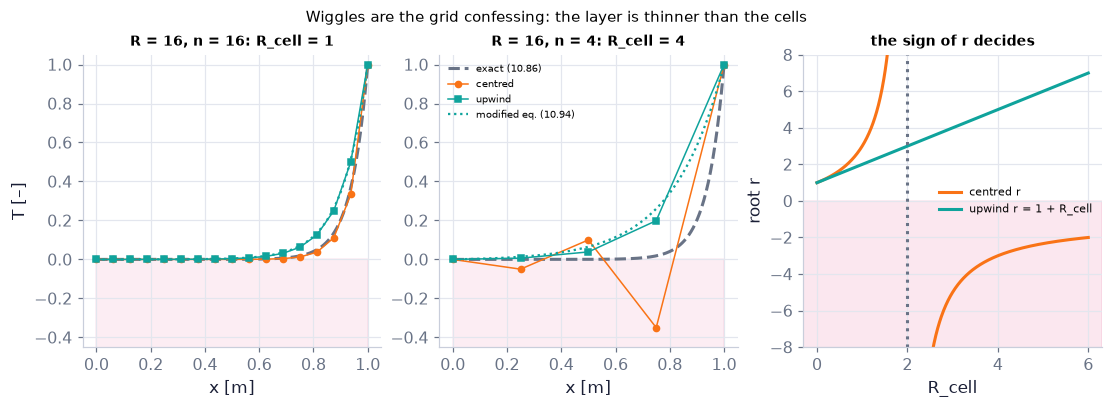

In [82]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.6))   # the figure and its panels
xf = np.linspace(0, 1, 500)   # sample points
for ax, n_, R_ in ((a1, 16, 16.0), (a2, 4, 16.0)):                   # R_cell = 1 and 4
    ce = FD.steady_cd_fd(n_, R_, "central"); up = FD.steady_cd_fd(n_, R_, "upwind")
    ax.plot(xf, FD.steady_cd_exact(xf, R_), "--", color=C_EX, label="exact (10.86)")   # draw the curve(s)
    ax.plot(ce["x"], ce["T"], "o-", color=C_FT, ms=4, lw=1, label="centred")   # draw the curve(s)
    ax.plot(up["x"], up["T"], "s-", color=C_UP, ms=4, lw=1, label="upwind")   # draw the curve(s)
    ax.plot(xf, FD.steady_cd_exact(xf, R_/(1 + 0.5*R_/n_)), ":", color=C_UP, lw=1.5, label="modified eq. (10.94)")   # draw the curve(s)
    ax.fill_between(xf, -0.5, 0, color=C_BAD, alpha=0.08)            # below zero: impossible temperatures
    ax.set_ylim(-0.45, 1.05); ax.set_xlabel("x [m]"); ax.set_title(f"R = {R_:.0f}, n = {n_}: R_cell = {R_/n_:.0f}", fontsize=9)   # the panel's title: what this panel shows
a1.set_ylabel("T [–]"); a2.legend(fontsize=6.5, frameon=False, loc="upper left")   # axis labels, with units where the quantity has them
Rc = np.linspace(0, 6, 601)   # sample points
with np.errstate(divide="ignore"):
    rc = (1 + Rc/2)/(1 - Rc/2)                                       # centred root
rc[np.abs(Rc - 2) < 0.02] = np.nan                                   # break the curve at the pole R_cell = 2
a3.plot(Rc, rc, color=C_FT, label="centred r"); a3.plot(Rc, 1 + Rc, color=C_UP, label="upwind r = 1 + R_cell")   # draw the curve(s)
a3.axhspan(-10, 0, color=C_BAD, alpha=0.1); a3.axvline(2, color=C_EX, ls=":")   # a reference line or band
a3.set_ylim(-8, 8); a3.set_xlabel("R_cell"); a3.set_ylabel("root r"); a3.legend(fontsize=7, frameon=False); a3.set_title("the sign of r decides", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("Wiggles are the grid confessing: the layer is thinner than the cells", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c09_wiggles"); plt.show()   # display the figure

**What you see.** (a) At $R_{cell}=1$ centred (orange) and upwind (teal) dots sit near the exact curve. (b) At $R_{cell}=4$ the centred dots zigzag below zero (the rose band) while the upwind dots are smooth but far too high, close to the dotted modified-equation curve. (c) The two discrete roots against $R_{cell}$, the band $r<0$ shaded.

**How to read it.** The zigzag appears exactly where the orange root goes negative ($R_{cell}>2$). Upwind never oscillates ($r=1+R_{cell}>0$) but solves a problem with the larger diffusivity $D(1+0.5R_{cell})$ — the dotted curve is its exact solution, near (not on) the teal dots.

**What would change if…** …a grid stretched towards the wall with the same $n$ (N47): the orange dots would follow the layer with no visible negative value.

In [83]:
Rcs = np.linspace(0.5, 8, 30 if not FAST else 15)                  # slider positions for R_cell (n = 10)
xf = np.linspace(0.5, 1, 300)   # sample points
def f5(Rc):                                                         # the three profiles near the wall for one R_cell
    ce = FD.steady_cd_fd(10, 10*Rc, "central"); up = FD.steady_cd_fd(10, 10*Rc, "upwind")
    return {"exact": (xf, FD.steady_cd_exact(xf, 10*Rc)), "centred": (ce["x"][5:], ce["T"][5:]), "upwind": (up["x"][5:], up["T"][5:])}   # the values for this call
fig = slider_figure(f5, "R_cell", Rcs, xlabel="x [m]", ylabel="T", yrange=[-0.6, 1.05],
                    title="Slide R_cell past 2: the centred profile starts to zigzag", modes={"centred": "lines+markers", "upwind": "lines+markers"})
fig.show()   # display the interactive figure

**What does the code above do?**

The page version of the explainer: ten cells, the right half of the domain. Below $R_{cell}=2$ the centred profile is smooth; above, it alternates in
sign while upwind stays smooth and too thick.

> ▶️ **Live cell.** The widget below needs a running Python kernel. On the web page it is frozen — open this notebook in Colab (button at the top) or run it locally to drag the sliders.

In [84]:
def layer(R=40.0, n=10, grid="uniform"):                           # free R, n and grid: the (b) panel above
    n = int(n); xf = np.linspace(0, 1, 400)   # sample points
    ce = FD.steady_cd_fd(n, R, "central", grid=grid); up = FD.steady_cd_fd(n, R, "upwind", grid=grid)
    fig, ax = plt.subplots(figsize=(5.5, 3))   # the figure and its panels
    ax.plot(xf, FD.steady_cd_exact(xf, R), "--", color=C_EX); ax.plot(ce["x"], ce["T"], "o-", color=C_FT); ax.plot(up["x"], up["T"], "s-", color=C_UP)   # draw the curve(s)
    ax.set_title(f"R_cell = {R/n:.2f} (uniform)", fontsize=9); ax.set_xlabel("x [m]"); plt.show()   # display the figure
live(layer, R=(1, 500, 1), n=(4, 100, 1), grid=["uniform", "stretched"])   # sliders + a grid menu

interactive(children=(FloatSlider(value=250.5, continuous_update=False, description='R', layout=Layout(width='…

<function __main__.layer(R=40.0, n=10, grid='uniform')>

**What does the code above do?**

Free global Péclet number, number of cells and grid type (kernel only; the page shows the slider figure above).

#### 🎮 Interactive: Why does a centred scheme give negative temperatures?

**Why interactive rather than a static figure:** Sliding $R$ or $n$ moves $R_{cell}$ across 2: the centred dots flip into a zigzag at exactly that point while, in the second view, the root $r$ crosses zero; the modified-equation ghost lies near the upwind dots — upwind solves a different problem well.

**What to try:**
- Start at R_cell = 1 and drag n down until the first negative value appears; read R_cell.
- Switch on the diffusivity bars: at R_cell = 4 the numerical part is twice the physical one.
- Try the stretched grid at R_cell = 4: same n, no visible wiggles.

In [85]:
show_viz("ch10", "cell_peclet_wiggles")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/cell_peclet_wiggles]

**What would change if…** …the unknown were a velocity field that must also stay divergence-free? The wiggle problem remains (it returns in Ch. 12 as a resolution question and in
Ch. 13 for tracer advection); the new difficulty is the pressure. C10 takes the gentlest route: let the fluid compress a little.

> 🔁 **Recap — R09 · Compressible Navier–Stokes in two dimensions** (Ch. 4 §4.5–§4.6). With Stokes' hypothesis $\mu_v=0$ (Ch. 4 §4.5) the 2-D equations in conservation form are $\rho_t+(\rho u)_x+(\rho v)_y=0$ *(10.96)* and $(\rho u)_t+(\rho u^2)_x+(\rho vu)_y=\rho g_x-p_x+\mu\nabla^2u+\frac\mu3\frac{\partial}{\partial x}(u_x+v_y)$ *(10.97)*, with *(10.98)*, $(\rho v)_t+(\rho uv)_x+(\rho v^2)_y=\rho g_y-p_y+\mu\nabla^2v+\tfrac{\mu}{3}\tfrac{\partial}{\partial y}(u_x+v_y)$ the same for $v$. `ch10.compressible_ns_sympy()` checks them against Ch. 4's `navier_stokes_sym(mu_v=0)`.

In [86]:
print("difference from Ch. 4's Navier-Stokes with mu_v = 0:", ch10.compressible_ns_sympy()["residual"])   # 0: (10.96)-(10.98) are Ch. 4's equations

difference from Ch. 4's Navier-Stokes with mu_v = 0: 0


**What does the code above do?**

The sympy engine expands (10.96)–(10.98), $\rho_t+(\rho u)_x+(\rho v)_y=0,\ (\rho u)_t+(\rho u^2)_x+(\rho vu)_y=\rho g_x-p_x+\mu\nabla^2u+\tfrac{\mu}{3}\tfrac{\partial}{\partial x}(u_x+v_y),\ (\rho v)_t+(\rho uv)_x+(\rho v^2)_y=\rho g_y-p_y+\mu\nabla^2v+\tfrac{\mu}{3}\tfrac{\partial}{\partial y}(u_x+v_y)$ with $p=c^2\rho$ and subtracts Ch. 4's momentum residual plus $u$ (or $v$) times continuity: the difference is 0.

### 🧩 Weakly compressible Navier–Stokes and the MacCormack predictor–corrector `C10`

*The question:* If pressure has no equation of its own in incompressible flow, can we give it one by letting the fluid be very slightly compressible — and how do we step such a system accurately?

*In one line:* $\mathbf U_t+\mathbf E(\mathbf U)_x+\mathbf F(\mathbf U)_y=0$ *(10.100)* · $\mathbf U^*_{i,j}=\mathbf U^n_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^n_{i+1,j}-\mathbf E^n_{i,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^n_{i,j+1}-\mathbf F^n_{i,j})$ *(10.101)* · $\mathbf U^{n+1}_{i,j}=\tfrac12\big[\mathbf U^n_{i,j}+\mathbf U^*_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^*_{i,j}-\mathbf E^*_{i-1,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^*_{i,j}-\mathbf F^*_{i,j-1})\big]$ *(10.102)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **RK4 by hand** — a multi-stage step that evaluates the slope several times per step for higher order (Ch. 3 P95); here the two-stage cousin.
- **Schwarz's theorem (swap ∂t and ∂x)** — for smooth functions ∂t∂x T = ∂x∂t T (Ch. 4 P121).

#### The problem in plain words

Real water *is* compressible — sound travels through it at 1500 m/s. A pressure pulse tells the whole tank about a moving lid by sound waves. If we keep a
small, finite sound speed, the pressure gets an evolution equation and an explicit code can march everything forward — at the price of time steps short enough
to follow the sound (C05's CFL with the sound speed) and an $O(Ma^2)$ error in the density. MacCormack's two-stage scheme is a classic way to do the marching
with second-order accuracy.

#### The idea

```
U*      = Uⁿ − (Δt/Δx)(E_{i+1} − E_i)ⁿ               predictor: forward difference (a guess at t_{n+1})
Uⁿ⁺¹    = ½[Uⁿ + U* − (Δt/Δx)(E*_i − E*_{i−1})]       corrector: backward difference of the guess, then average
forward + backward, averaged  ⇒  centred and second order (D18)
```

Predict with forward differences, correct with backward ones from the predicted state, average.

📝 **Note.** **N51 [B]** **Incompressibility, three ways of looking** (§10.4): continuity is a *constraint* on $\mathbf u$ that determines $p$; equivalently the pressure is a
*Lagrange multiplier* that enforces it; physically, an incompressible fluid has infinite sound speed, so pressure information arrives everywhere instantly — which
is why a Poisson equation for $p$ (continuous or discrete) appears, and why solving it is often the most expensive step. Three answers follow: weak
compressibility (here), projection (C11–C12), mixed elements (C13).

> 📎 **Primer — Lagrange multiplier.** `P239` · To minimise or balance something *subject to a constraint*, add a new unknown $\lambda$ times the constraint; $\lambda$ adjusts itself until the constraint holds,
and its value measures how hard the constraint pushes back. In incompressible flow the pressure is that $\lambda$: it takes whatever values make
$\nabla\cdot\mathbf u=0$, and $-\nabla p$ is the force needed.

In [87]:
import sympy as sp   # symbolic algebra
x, y, lam = sp.symbols('x y lam')   # symbols for sympy
L = x**2 + y**2 + lam*(x + y - 1)            # minimise x^2 + y^2 subject to x + y = 1
print(sp.solve([sp.diff(L, v) for v in (x, y, lam)], [x, y, lam]))   # x = y = 1/2, lam = -1

{lam: -1, x: 1/2, y: 1/2}


📝 **Note.** **N52 [B]** **Artificial compressibility (Chorin 1967) (10.95):** replace continuity by $\frac{\partial p}{\partial t}+c^2\nabla\cdot\mathbf u=0$ with an arbitrary $c$ —
continuity of a fluid with $p=c^2\rho$, linearised; in words, a pressure that grows wherever fluid piles up. It has no physical meaning before the steady state
(a *pseudo-time*); at steady state $\nabla\cdot\mathbf u=0$ whatever $c$ is. **Climate hook:** some atmospheric models slow sound down on purpose ("reduced
speed of sound") for the same reason.

$$ \dfrac{\partial p}{\partial t}+c^2\nabla\cdot\mathbf u=0 \qquad \text{(10.95)} $$

In [88]:
ac = ch10.artificial_compressibility_channel(ny=16 if not FAST else 8, Re=10.0)   # pseudo-time march of (10.95) + momentum
print(f"converged: {ac['converged']} after {ac['iterations']} iterations; max |u - u_Poiseuille| = {ac['max_err']:.1e}")   # show the numbers computed above
print("max |div u| every 100 iterations (first, last):", ac["div_history"][0], ac["div_history"][-1])   # show the numbers computed above

converged: True after 17315 iterations; max |u - u_Poiseuille| = 1.2e-12
max |div u| every 100 iterations (first, last): 0.21280123203958107 1.1797738621006928e-10


**What does the code above do?**

1. A channel periodic in $x$ with walls at $y=0,1$ starts from a divergent velocity; the pressure is marched with $\frac{\partial p}{\partial \tau}+c^2\nabla\cdot\mathbf u=0$ (10.95)
   in a pseudo-time $\tau$, together with the momentum equation driven by a mean pressure gradient.
2. At the pseudo-steady state the velocity is plane Poiseuille flow to round-off (the three-point Laplacian is exact for a parabola) and the divergence has
   fallen to about $10^{-10}$: whatever $c$, the end state is incompressible.

> 📎 **Primer — the Taylor–Green vortex (an exact decaying Navier–Stokes solution).** `P254` · A checkerboard of counter-rotating eddies in a periodic box $[0,2\pi]^2$ with
$u=\sin x\cos y\,e^{-2t/Re}$, $v=-\cos x\sin y\,e^{-2t/Re}$, $p=\tfrac14(\cos2x+\cos2y)\,e^{-4t/Re}$ (lengths and speeds in units of the box scale and the initial peak speed).
It is divergence-free ($u_x+v_y=\cos x\cos y-\cos x\cos y=0$), and its nonlinear term $(\mathbf u\cdot\nabla)\mathbf u$ is exactly balanced by the pressure gradient, so the
Navier–Stokes equations reduce to pure viscous decay: each velocity component is an eigenfunction of $\nabla^2$ with eigenvalue $-2$, hence the factor $e^{-2t/Re}$.
Because the exact answer is known at every time, it is the standard test of an incompressible (or nearly incompressible) solver: run, compare, refine.

In [89]:
import numpy as np   # arrays and maths
x = y = np.linspace(0, 2*np.pi, 5); X, Y = np.meshgrid(x, y)   # a coarse look at the field at t = 0
u = np.sin(X)*np.cos(Y); v = -np.cos(X)*np.sin(Y)               # the Taylor-Green velocity (t = 0)
print(np.round(u, 2))                                         # alternating signs: a checkerboard of eddies
print("decay factor of the speed at t = 10, Re = 100:", np.exp(-2*10/100))   # e^{-2t/Re}

[[ 0.  1.  0. -1. -0.]
 [ 0.  0.  0. -0. -0.]
 [-0. -1. -0.  1.  0.]
 [-0. -0. -0.  0.  0.]
 [ 0.  1.  0. -1. -0.]]
decay factor of the speed at t = 10, Re = 100: 0.8187307530779818


📝 **Note.** **N53 [B]** **Isothermal equation of state (10.99):** $p=c^2\rho$; at low Mach number $Ma=U/c$ and nearly constant temperature, the density varies only by
$O(Ma^2)$ — $Ma=0.1$ gives about 1 % (Ch. 4's incompressibility criterion $Ma<0.3$, `ch04.is_incompressible_regime`). ⚠️ On a fixed grid the *numerical*
error of an explicit weakly compressible code does not shrink with $Ma$ — it grows as $Ma$ falls (the time step $\Delta t\propto Ma\,\Delta x$ shrinks and the
acoustic truncation errors pile up; the second cell below measures it on a decaying Taylor–Green vortex). The $O(Ma^2)$ compressibility error is real but hidden
behind it — one reason the book's cavity runs use very fine grids.

$$ p=c^2\rho \qquad \text{(10.99)} $$

In [90]:
print("Ma^2 at Ma = 0.1:", 0.1**2, "  air at 34 m/s treated as incompressible:", ch04.is_incompressible_regime(34.0))   # Ma about 0.1 at 288 K

Ma^2 at Ma = 0.1: 0.010000000000000002   air at 34 m/s treated as incompressible: True


**What does the code above do?**

$Ma^2=0.01$: a 1 % density change; Ch. 4's test says a 34 m/s air flow ($Ma\approx0.1$) may be treated as incompressible.

In [91]:
for Ma_ in (0.1, 0.05, 0.025):                                     # three Mach numbers on the same 32^2 grid
    tg_ = MCK.wc_taylor_green(n=32, Ma=Ma_, Re=100.0, t_end=1.0)    # weakly compressible MacCormack on a periodic Taylor-Green vortex
    print(f"Ma = {Ma_:5.3f}: max velocity error at t = 1 = {tg_['err_u']:.4f}, {tg_['steps']} steps")   # show the numbers computed above

Ma = 0.100: max velocity error at t = 1 = 0.0062, 103 steps
Ma = 0.050: max velocity error at t = 1 = 0.0099, 193 steps


Ma = 0.025: max velocity error at t = 1 = 0.0197, 373 steps


**What does the code above do?**

The exact incompressible Taylor–Green vortex is marched by the weakly compressible MacCormack solver at three Mach numbers on one grid: the error does
**not** fall like $Ma^2$ — it grows as $Ma$ falls, because more (shorter) steps accumulate more acoustic truncation error. Only refining the grid reduces it.

> 📎 **Primer — conservation (flux) form U_t + E_x + F_y = 0.** `P237` · Stack the conserved quantities in one vector $\mathbf U=(\rho,\rho u,\rho v)$ and write every conservation law as "rate of change + divergence of a flux = 0":
$\mathbf U_t+\mathbf E(\mathbf U)_x+\mathbf F(\mathbf U)_y=0$ with $\mathbf E=(\rho u,\ \rho u^2+p,\ \rho uv)$ and $\mathbf F=(\rho v,\ \rho uv,\ \rho v^2+p)$ (viscous
terms added separately). One scheme then updates all components at once, and summing a flux difference over the cells telescopes — what flows out of one
cell flows into the next.

In [92]:
import numpy as np   # arrays and maths
rho, u, v, c = 1.0, 0.2, 0.0, 10.0              # a state; c = 1/Ma (Ma = 0.1)
p = c**2*rho                                    # (10.99)
E = np.array([rho*u, rho*u**2 + p, rho*u*v])    # x-flux of (rho, rho u, rho v)
print(E)                                        # [0.2, 100.04, 0.0]: the pressure dominates the momentum flux

[  0.2  100.04   0.  ]


> 📎 **Primer — predictor–corrector (Heun's second-order idea).** `P238` · Estimate the next state with a cheap first-order step (predict), evaluate the slope again at the prediction, and average the two slopes (correct). For
$y'=f(y)$: $y^*=y^n+\Delta tf(y^n)$, $y^{n+1}=y^n+\frac{\Delta t}2[f(y^n)+f(y^*)]$ — second order, like the Runge–Kutta methods of Ch. 3 (P95 did RK4).

In [93]:
import numpy as np   # arrays and maths
f = lambda y: -y; dt = 0.1                 # y' = -y, exact e^{-t}
y = 1.0; ys = y + dt*f(y)                  # predict: 0.9
y1 = y + dt/2*(f(y) + f(ys))               # correct: 0.905
print(y1, np.exp(-0.1))                    # 0.905 vs 0.904837: error 1.6e-4, about dt^3 per step

0.905 0.9048374180359595


#### 🧮 Derivation — MacCormack = Lax–Wendroff: second order with local error $-\frac{u\Delta t\Delta x^2}6(1-C^2)T_{xxx}$, and $\lvert G\rvert^2=1-4C^2(1-C^2)\sin^4\frac\theta2$ ⇒ stable iff C ≤ 1 `D18` (Eq. 10.102: $\mathbf U^{n+1}_{i,j}=\tfrac12\big[\mathbf U^n_{i,j}+\mathbf U^*_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^*_{i,j}-\mathbf E^*_{i-1,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^*_{i,j}-\mathbf F^*_{i,j-1})\big]$)

**What we want to show.** Show what the book only states — that the predictor–corrector (10.101)–(10.102), $\mathbf U^*_{i,j}=\mathbf U^n_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^n_{i+1,j}-\mathbf E^n_{i,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^n_{i,j+1}-\mathbf F^n_{i,j})$ is second order in space and time — and find its stability limit, on the simplest system it applies to.

**Assumptions.** Constant u > 0, $C=u\Delta t/\Delta x$ (step 1); smooth solution (steps 6–11); periodic grid (steps 13–14).

**The plan.**

1. Apply it to one scalar in 1-D, T_t + uT_x = 0 (E = uT, F = 0).
2. Eliminate the predicted values: Lax–Wendroff.
3. Compare with the exact solution's Taylor series (using the PDE twice).
4. Find G and its modulus.

**Tools we use** (each explained before this point): Predictor–corrector (primer P238) · Taylor series in t and x (Ch. 3 P98) · Schwarz's theorem, to swap ∂t and ∂x (Ch. 4 P121) · D04 moves · half-angle identities (P225) · sympy (Ch. 1 P40, Ch. 4 P117).

**We start from**

$$ \begin{array}{l}\text{The scheme for}\ \mathbf U_t+\mathbf E(\mathbf U)_x+\mathbf F(\mathbf U)_y=0\ \text{(10.100): predictor} \\ \mathbf U^*_{i,j}=\mathbf U^n_{i,j}-\frac{\Delta t}{\Delta x}(\mathbf E^n_{i+1,j}- \mathbf E^n_{i,j})-\frac{\Delta t}{\Delta y}(\mathbf F^n_{i,j+1}-\mathbf F^n_{i,j})\ \text{(10.101), corrector} \\ \mathbf U^{n+1}_{i,j}=\frac12\big[\mathbf U^n_{i,j}+\mathbf U^*_{i,j}-\frac{\Delta t}{\Delta x} (\mathbf E^*_{i,j}-\mathbf E^*_{i-1,j})-\frac{\Delta t}{\Delta y}(\mathbf F^*_{i,j}-\mathbf F^*_{i,j-1})\big]\ \text{(10.102)}\end{array} $$

*In words:* predict with forward differences, correct with backward ones, average.

---

**Step 1 of 14 — Specialise the predictor.**

$$ T^*_i=T^n_i-C\,(T^n_{i+1}-T^n_i) $$

- *Why we can do this:* (10.101), $\mathbf U^*_{i,j}=\mathbf U^n_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^n_{i+1,j}-\mathbf E^n_{i,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^n_{i,j+1}-\mathbf F^n_{i,j})$ with $\mathbf E=uT$, no y-direction; $\frac{\Delta t}{\Delta x}u=C$.
- *In words:* a forward-difference guess at the new level.

---

**Step 2 of 14 — Specialise the corrector.**

$$ T^{n+1}_i=\tfrac12\big[T^n_i+T^*_i-C\,(T^*_i-T^*_{i-1})\big] $$

- *Why we can do this:* (10.102), $\mathbf U^{n+1}_{i,j}=\tfrac12\big[\mathbf U^n_{i,j}+\mathbf U^*_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^*_{i,j}-\mathbf E^*_{i-1,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^*_{i,j}-\mathbf F^*_{i,j-1})\big]$ with $\mathbf E^*=uT^*$. The corrector differences the predicted values backwards; that pairing of forward and backward is what makes the result centred.
- *In words:* a backward difference of the guess, averaged with the old value.

---

**Step 3 of 14 — Difference the predicted values.**

$$ T^*_i-T^*_{i-1}=(T_i-T_{i-1})-C\,(T_{i+1}-2T_i+T_{i-1}) $$

- *Why we can do this:* Write step 1 at i and at i − 1 and subtract; the C terms combine into a second difference. (Superscript n dropped.)
- *In words:* the guess's backward difference.

---

**Step 4 of 14 — Substitute into the corrector.**

$$ T^{n+1}_i=\tfrac12\big[2T_i-C(T_{i+1}-T_i)-C(T_i-T_{i-1})+C^2(T_{i+1}-2T_i+T_{i-1})\big] $$

- *Why we can do this:* Insert step 1 for $T^*_i$ and step 3; this is where C² enters — the corrector differences the predictor.
- *In words:* no starred values left.

---

**Step 5 of 14 — Combine the first differences.**

$$ T^{n+1}_i=T_i-\frac C2(T_{i+1}-T_{i-1})+\frac{C^2}2(T_{i+1}-2T_i+T_{i-1}) $$

- *Why we can do this:* $(T_{i+1}-T_i)+(T_i-T_{i-1})=T_{i+1}-T_{i-1}$; halve everything. This is the Lax–Wendroff scheme.
- *In words:* a centred convective step plus a C²/2 diffusion-like correction.

---

**Step 6 of 14 — Taylor-expand the exact solution in time.**

$$ T(t+\Delta t)=T+\Delta t\,T_t+\frac{\Delta t^2}2T_{tt}+\frac{\Delta t^3}6T_{ttt}+O(\Delta t^4) $$

- *Why we can do this:* P98 at fixed x; we will compare the scheme with this.
- *In words:* what the exact solution does in one step.

---

**Step 7 of 14 — Trade time derivatives for space ones.**

$$ T_t=-uT_x,\quad T_{tt}=u^2T_{xx},\quad T_{ttt}=-u^3T_{xxx} $$

- *Why we can do this:* Differentiate the PDE in t and use $\partial_t\partial_x=\partial_x\partial_t$ (P121) with $T_t=-uT_x$ again; each time derivative becomes −u ∂x.
- *In words:* in pure advection, time change is space change carried along.

---

**Step 8 of 14 — Exact step in space derivatives.**

$$ T(t+\Delta t)=T-u\Delta t\,T_x+\frac{u^2\Delta t^2}2T_{xx}-\frac{u^3\Delta t^3}6T_{xxx}+\dots $$

- *Why we can do this:* Step 7 in step 6. We now have the exact one-step change written with space derivatives only, ready to compare with the scheme.
- *In words:* the target, term by term.

---

**Step 9 of 14 — Expand the scheme's differences.**

$$ \tfrac12(T_{i+1}-T_{i-1})=\Delta x\,T_x+\frac{\Delta x^3}6T_{xxx}+\dots,\quad T_{i+1}-2T_i+T_{i-1}=\Delta x^2T_{xx}+O(\Delta x^4) $$

- *Why we can do this:* D01 steps 5 and 7. Both stencils of the Lax–Wendroff form are the ones D01 already expanded, so we can reuse their series.
- *In words:* the stencils as series.

---

**Step 10 of 14 — Scheme step in space derivatives.**

$$ T^{n+1}_i=T-u\Delta t\,T_x+\frac{u^2\Delta t^2}2T_{xx}-\frac{u\Delta t\,\Delta x^2}6T_{xxx}+\dots $$

- *Why we can do this:* Step 9 in step 5 with CΔx = uΔt and C²Δx² = u²Δt².
- *In words:* the scheme's step, term by term.

---

**Step 11 of 14 — Subtract exact from scheme.**

$$ T^{n+1}_i-T(t+\Delta t)=-\frac{u\Delta t\,\Delta x^2}6T_{xxx}+\frac{u^3\Delta t^3}6T_{xxx}+\dots $$

- *Why we can do this:* Steps 10 − 8: the T, T_x and T_xx terms are identical and cancel — the whole point of the C²/2 correction.
- *In words:* only a third-derivative term is left.

---

**Step 12 of 14 — Factor and read the order.**

$$ T^{n+1}_i-T(t+\Delta t)=-\frac{u\Delta t\,\Delta x^2}6\,(1-C^2)\,T_{xxx}+O(\Delta t\,\Delta x^4) $$

- *Why we can do this:* $u^3\Delta t^3=u\Delta t\cdot C^2\Delta x^2$. Per unit time (÷ Δt) the error is O(Δx², Δt²): second order in both, as the book states; an odd derivative, so dispersive; zero at C = 1.
- *In words:* second order — waves keep their height but short ones lag.

---

**Step 13 of 14 — Insert one Fourier wave.**

$$ G=1-\mathrm iC\sin\theta-C^2(1-\cos\theta)=1-2C^2s-\mathrm iC\sin\theta,\quad s=\sin^2\tfrac\theta2 $$

- *Why we can do this:* D04 moves in step 5: $\frac12(e^{\mathrm i\theta}-e^{-\mathrm i\theta})=\mathrm i\sin\theta$, $e^{\mathrm i\theta}-2+e^{-\mathrm i\theta}=-2(1-\cos\theta)$, then the half-angle identity (P225).
- *In words:* one complex factor per wave.

---

**Step 14 of 14 — Square, add, read the limit.**

$$ \lvert G\rvert^2=(1-2C^2s)^2+4C^2s(1-s)=1-4C^2(1-C^2)\sin^4\tfrac\theta2\le1\iff C\le1 $$

- *Why we can do this:* $\sin^2\theta=4s(1-s)$; expanding, the 4C²s terms cancel, leaving $1-4C^2s^2+4C^4s^2$. It is ≤ 1 for every θ exactly when C² ≤ 1: a CFL condition.
- *In words:* stable exactly when the Courant number is at most 1.

---

**Result**

$$ \begin{array}{l}\text{For linear advection MacCormack is Lax–Wendroff,}\ T^{n+1}_i=T_i-\frac C2(T_{i+1}-T_{i-1})+\frac{C^2}2(T_{i+1}-2T_i+T_{i-1})\ \text{,} \\ \text{second order with a dispersive leading error}\ -\frac{u\Delta x^2}6(1-C^2)T_{xxx}\ \text{per unit time, and} \\ \text{stable iff C ≤ 1}\end{array} $$

*In words:* forward-then-backward averages to a centred, second-order step whose price is phase error, not amplitude loss.

**What it means.** MacCormack's second order is what lets the cavity and block computations of §10.5 run on modest grids; its dispersive error is the ripple behind the square pulse (C10 figure, explainer 3). With the Navier–Stokes fluxes the same structure holds, with the sound speed setting C (10.110), $\Delta t\le\dfrac{\sigma}{1+2/Re_\Delta}\left[\dfrac{\lvert u\rvert}{\Delta x}+\dfrac{\lvert v\rvert}{\Delta y}+c\sqrt{\dfrac{1}{\Delta x^2}+\dfrac{1}{\Delta y^2}}\right]^{-1},\ Re_\Delta=\min\Big(\tfrac{\rho\lvert u\rvert\Delta x}{\mu},\tfrac{\rho\lvert v\rvert\Delta y}{\mu}\Big)$, (10.155), $\Delta t\le\dfrac{\sigma}{\sqrt2}\,Ma\,\Delta x$. It fails at discontinuities: next to a jump it overshoots and undershoots (Gibbs-like — like the ripples of a Fourier series cut off after finitely many terms, which never vanish at the jump). A linear second-order scheme cannot stay monotone there; Ch. 15's shocks need limiters.

**Check it.** Units: the local error is in T ✓ (u Δt Δx² T_xxx: m/s · s · m² · T/m³). Tiny example (C = 0.5, [0, 0, 1, 0, 0]) gives [0, −0.125, 0.75, 0.375, 0] by both routes ✓. C = 1: G = $e^{-i\theta}$, the exact shift, and the local error vanishes ✓. C = 0: G = 1 ✓. Measured order close to 2 on the Gaussian (printed by the C10 code cell, on N = 100 … 800).

In [94]:
import sympy as sp                                      # symbolic algebra (Ch. 1 P40)
C, th, a = sp.symbols('C theta a', real=True)           # Courant number, Fourier angle, half-angle a = theta/2
Tm, T0, Tp = sp.symbols('T_m T_0 T_p')                  # T at i-1, i, i+1 (a stencil of three values)
pred = lambda left, right: left - C*(right - left)      # predictor (10.101) with E = uT: T*_i from T_i and T_{i+1}
Ts0, Tsm = pred(T0, Tp), pred(Tm, T0)                   # T*_i and T*_{i-1}
corr = sp.Rational(1, 2)*(T0 + Ts0 - C*(Ts0 - Tsm))     # corrector (10.102)
lw = T0 - C/2*(Tp - Tm) + C**2/2*(Tp - 2*T0 + Tm)       # Lax-Wendroff, step 5
print(sp.simplify(corr - lw))                           # 0: steps 1-5 are right
x, dx = sp.symbols('x dx', positive=True)               # position and grid step (C is held fixed)
f = sp.Function('f')                                    # any smooth profile; the exact solution is T = f(x - u t)
scheme = lw.subs({Tm: f(x - dx), T0: f(x), Tp: f(x + dx)})   # the scheme applied to exact values at t = 0
exact = f(x - C*dx)                                     # exact value one step later: shifted by u dt = C dx
err = sp.series(scheme - exact, dx, 0, 4).removeO().doit()   # Taylor in dx (steps 6-11 done by machine)
print(sp.factor(sp.simplify(err)))                      # C (C-1)(C+1) dx^3 f_xxx/6 = -(u dt dx^2/6)(1 - C^2) T_xxx: step 12
G = 1 - sp.I*C*sp.sin(th) - C**2*(1 - sp.cos(th))       # step 13
G2 = sp.expand(sp.re(G)**2 + sp.im(G)**2)               # |G|^2 with real C and theta
d = G2 - (1 - 4*C**2*(1 - C**2)*sp.sin(th/2)**4)        # difference from the claimed form of step 14
print(sp.simplify(sp.expand_trig(d.subs(th, 2*a))))     # 0 once theta = 2a is expanded by double-angle rules

0
C*dx**3*(C - 1)*(C + 1)*Derivative(f(x), (x, 3))/6


0


> ⚠️ **Common confusion (traps in `D18`):** Using $\mathbf E^n$ instead of $\mathbf E^*$ in the corrector (then C² never appears and the scheme is first order — FTCS-like and unstable); forgetting $T_{tt}=u^2T_{xx}$ (a spurious first-order term remains); reading the local error as the order (divide by Δt).

#### ✏️ Tiny example: one MacCormack step on five points

Linear advection $T_t+uT_x=0$ ($E=uT$), $C=u\Delta t/\Delta x=0.5$, periodic, start $[0,0,1,0,0]$.
1. Predictor $T^*_i=T_i-C(T_{i+1}-T_i)$: $[0,-0.5,1.5,0,0]$.
2. Corrector $T^{n+1}_i=\frac12[T_i+T^*_i-C(T^*_i-T^*_{i-1})]$: node 1: $\frac12[0-0.5-0.5(-0.5-0)]=-0.125$; node 2: $\frac12[1+1.5-0.5(1.5+0.5)]=0.75$;
   node 3: $\frac12[0+0-0.5(0-1.5)]=0.375$.
3. Result $[0,-0.125,0.75,0.375,0]$, sum 1 (conserved).
4. The Lax–Wendroff formula of D18 gives the same numbers: node 1: $0-0.25(1-0)+0.125(1)=-0.125$ ✓.
5. Compare upwind at the same $C$: $[0,0,0.5,0.5,0]$ — no undershoot but a flatter peak. MacCormack keeps the peak higher but dips below zero upstream:
   dispersion, not diffusion.

In [95]:
print("one MacCormack step:", MCK.maccormack_advection_1d(np.array([0, 0, 1, 0, 0.0]), 0.5, 1))   # C = 0.5
lin = ch10.maccormack_linear_sympy()                                # D18 by machine
print("MacCormack - Lax-Wendroff:", lin["lw_difference"])   # show the numbers computed above
print("leading local error per unit time:", lin["local_error"])     # h = dx; vanishes at C = 1
print("|G|^2 =", lin["G2_factorised"], "  (difference from the expanded form:", lin["G2_difference"], ")")   # show the numbers computed above
Ns = (100, 200, 400, 800) if not FAST else (100, 200, 400)          # cells per revolution
for sch in ("upwind", "maccormack"):   # repeat the indented lines for each item listed
    e = [FD.advect_periodic("gauss", C=0.5, n_cells=N, n_rev=1.0, scheme=sch)["rms_error"] for N in Ns]   # Gaussian, one revolution
    print(f"{sch:10s} rms errors {np.array(e).round(5)}  observed order {observed_order([1/N for N in Ns], e):.2f}")   # show the numbers computed above

one MacCormack step: [ 0.    -0.125  0.75   0.375  0.   ]


MacCormack - Lax-Wendroff: 0
leading local error per unit time: h**2*u*(C - 1)*(C + 1)*Derivative(f(x), (x, 3))/6
|G|^2 = -4*C**2*(1 - C**2)*sin(theta/2)**4 + 1   (difference from the expanded form: 0 )
upwind     rms errors [0.1203 0.0811 0.0495 0.0279]  observed order 0.70
maccormack rms errors [0.0374 0.0101 0.0025 0.0006]  observed order 1.96


**What does the code above do?**

1. One step reproduces the tiny example.
2. The sympy engine confirms D18: MacCormack minus Lax–Wendroff is 0; the local error per unit time is $\frac{u\,h^2}{6}(C-1)(C+1)f'''=-\frac{u\Delta x^2}{6}(1-C^2)T_{xxx}$;
   $\lvert G\rvert^2=1-4C^2(1-C^2)\sin^4\frac\theta2$.
3. On the travelling Gaussian MacCormack converges at close to second order; upwind's observed order is still well below 1 on these grids — its error is
   dominated by a smeared amplitude that shrinks slowly (the pre-asymptotic behaviour already seen in C03).

In [96]:
# from scratch: MacCormack for linear advection in two lines, against the Lax-Wendroff formula and the library
rng = np.random.default_rng(7); T = rng.random(64); C = 0.7        # a random periodic profile and a Courant number
Ts = T - C*(np.roll(T, -1) - T)                                    # predictor (10.101): forward difference
Tn = 0.5*(T + Ts - C*(Ts - np.roll(Ts, 1)))                        # corrector (10.102): backward difference, then average
T_lw = T - C/2*(np.roll(T, -1) - np.roll(T, 1)) + C**2/2*(np.roll(T, -1) - 2*T + np.roll(T, 1))   # D18 step 5
assert np.allclose(Tn, T_lw, atol=1e-15)                           # identical to Lax-Wendroff
assert np.allclose(Tn, MCK.maccormack_advection_1d(T, C, 1))       # identical to the library
print("MacCormack = Lax-Wendroff = library, to", np.abs(Tn - T_lw).max())   # show the numbers computed above

MacCormack = Lax-Wendroff = library, to 2.220446049250313e-16


**What does the code above do?**

The two stages written with `np.roll` (periodic neighbours) give exactly the Lax–Wendroff update of D18 step 5, and the library's step — to round-off.

📝 **Note.** **N54 [B], N55 [B], N56 [B]** **MacCormack for the 2-D Navier–Stokes equations.** The same predictor (forward) and corrector (backward) applied to
(10.96)–(10.98), $\rho_t+(\rho u)_x+(\rho v)_y=0,\ (\rho u)_t+(\rho u^2)_x+(\rho vu)_y=\rho g_x-p_x+\mu\nabla^2u+\tfrac{\mu}{3}\tfrac{\partial}{\partial x}(u_x+v_y),\ (\rho v)_t+(\rho uv)_x+(\rho v^2)_y=\rho g_y-p_y+\mu\nabla^2v+\tfrac{\mu}{3}\tfrac{\partial}{\partial y}(u_x+v_y)$; the pressure is folded into the flux as $\rho u^2+c^2\rho$; the viscous second derivatives are always centred (to keep second order), with the
normal one weighted 4/3 and a cross term. The $x$-momentum predictor reads

$$(\rho u)^*_{i,j}=(\rho u)^n_{i,j}\ \color{#6c5ce7}{-\,c_1[(\rho u^2+c^2\rho)^n_{i+1,j}-(\rho u^2+c^2\rho)^n_{i,j}]-c_2[(\rho uv)^n_{i,j+1}-(\rho uv)^n_{i,j}]}
\ \color{#2563eb}{+\,\tfrac43c_3(u^n_{i+1,j}-2u^n_{i,j}+u^n_{i-1,j})+c_4(u^n_{i,j+1}-2u^n_{i,j}+u^n_{i,j-1})}\ \color{#d97706}{+\,c_5(v^n_{i+1,j+1}+v^n_{i-1,j-1}-v^n_{i+1,j-1}-v^n_{i-1,j+1})}\qquad\text{(10.104)}$$

(purple: flux differences; blue: normal and tangential viscous terms; amber: the cross term), the corrector *(10.107)*, $2(\rho u)^{n+1}_{i,j}=(\rho u)^n_{i,j}+(\rho u)^*_{i,j}-c_1[(\rho u^2+c^2\rho)^*_{i,j}-(\rho u^2+c^2\rho)^*_{i-1,j}]-c_2[(\rho uv)^*_{i,j}-(\rho uv)^*_{i,j-1}]+\dots$ is the same with backward flux
differences of the starred values, and the coefficients are $c_1=\frac{\Delta t}{\Delta x}$, $c_2=\frac{\Delta t}{\Delta y}$, $c_3=\frac{\mu\Delta t}{\Delta x^2}$,
$c_4=\frac{\mu\Delta t}{\Delta y^2}$, $c_5=\frac{\mu\Delta t}{12\Delta x\Delta y}$ *(10.109)*. Why 1/12: the cross derivative's centred stencil carries
$\frac1{4\Delta x\Delta y}$ and the Stokes term carries $\frac\mu3$.

In [97]:
print(MCK.ns_coefficients(1e-3, 1/64, 1/64, 0.01))                 # (10.109) for dt = 1e-3, dx = dy = 1/64, mu = 1/Re = 0.01
print("c5 by hand:", 0.01*1e-3/(12*(1/64)**2))                     # mu dt / (12 dx dy)

{'c1': 0.064, 'c2': 0.064, 'c3': 0.04096, 'c4': 0.04096, 'c5': 0.0034133333333333338}
c5 by hand: 0.0034133333333333338


**What does the code above do?**

`ns_coefficients` evaluates (10.109), $c_1=\tfrac{\Delta t}{\Delta x},\ c_2=\tfrac{\Delta t}{\Delta y},\ c_3=\tfrac{\mu\Delta t}{(\Delta x)^2},\ c_4=\tfrac{\mu\Delta t}{(\Delta y)^2},\ c_5=\tfrac{\mu\Delta t}{12\,\Delta x\Delta y}$; the last line recomputes $c_5=\mu\Delta t/(12\Delta x\Delta y)$ by hand.

📝 **Note.** **N57 [B]** **Arrangements FF/BB, BB/FF, FB/BF, BF/FB:** which direction is forward in the predictor ($x$ then $y$); cycling them from step to step removes a small
bias. For *linear* advection every arrangement gives the same Lax–Wendroff step (D18), so the difference only shows with a nonlinear flux: on Burgers' equation
($E=T^2/2$) the forward-first and backward-first steps differ by $O(\Delta x^2)$ per unit time — the cell measures it.

In [98]:
for N in (50, 100, 200):                                            # cells on a periodic [0, 1)
    x_ = np.arange(N)/N; U0 = np.array([1.0 + 0.5*np.sin(2*np.pi*x_)])   # a smooth Burgers profile (one variable)
    dt_ = 0.4/N                                                     # Courant number about 0.6 at the largest speed 1.5
    fb = MCK.maccormack_step(U0, lambda U: 0.5*U**2, dt=dt_, dx=1/N, arrangement="FB")   # forward predictor, backward corrector
    bf = MCK.maccormack_step(U0, lambda U: 0.5*U**2, dt=dt_, dx=1/N, arrangement="BF")   # the reverse
    print(f"N = {N:3d}: max |FB - BF| after one step = {np.abs(fb - bf).max():.2e}")   # show the numbers computed above

N =  50: max |FB - BF| after one step = 4.86e-05
N = 100: max |FB - BF| after one step = 6.11e-06
N = 200: max |FB - BF| after one step = 7.66e-07


**What does the code above do?**

`maccormack_step(U, flux_E, ...)` performs (10.101)–(10.102), $\mathbf U^*_{i,j}=\mathbf U^n_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^n_{i+1,j}-\mathbf E^n_{i,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^n_{i,j+1}-\mathbf F^n_{i,j}),\ \mathbf U^{n+1}_{i,j}=\tfrac12\big[\mathbf U^n_{i,j}+\mathbf U^*_{i,j}-\tfrac{\Delta t}{\Delta x}(\mathbf E^*_{i,j}-\mathbf E^*_{i-1,j})-\tfrac{\Delta t}{\Delta y}(\mathbf F^*_{i,j}-\mathbf F^*_{i,j-1})\big]$ for any flux. With $E=T^2/2$ the two arrangements differ by a quantity that drops by about 8 per
halving of $\Delta x$ in one step (of length $\propto\Delta x$) — i.e. $O(\Delta x^2)$ per unit time, the size of the scheme's own error.

📝 **Note.** **N58 [B]** **MacCormack's time-step limit** (semi-empirical; Tannehill, Anderson & Pletcher 1997, as cited):
$\Delta t\le\frac{\sigma}{1+2/Re_\Delta}\Big[\frac{\lvert u\rvert}{\Delta x}+\frac{\lvert v\rvert}{\Delta y}+c\sqrt{\frac1{\Delta x^2}+\frac1{\Delta y^2}}\Big]^{-1}$ *(10.110)* with a safety factor
$\sigma$ (we pass **our** $\sigma=0.8$) and the minimum mesh Reynolds number $Re_\Delta$. The sound speed dominates the bracket at low $Ma$: a CFL condition built on
$c$ (C05).

In [99]:
dt_mck = MCK.maccormack_dt(1.0, 0.0, 12.5, 1/64, 1/64, 1.0, 0.01, sigma=0.8)   # lid speed 1, c = 1/Ma = 12.5 (our Ma = 0.08), mu = 1/Re
print(f"(10.110): dt = {dt_mck:.3e};   bracket = {1.0*64 + 12.5*np.sqrt(2*64**2):.1f};   (10.155): dt = {MCK.maccormack_dt_asymptotic(0.08, 1/64):.3e}")   # show the numbers computed above

(10.110): dt = 2.935e-04;   bracket = 1195.4;   (10.155): dt = 7.071e-04


**What does the code above do?**

For the $64^2$ cavity with our $Ma=0.08$ the bracket of (10.110), $\Delta t\le\dfrac{\sigma}{1+2/Re_\Delta}\left[\dfrac{\lvert u\rvert}{\Delta x}+\dfrac{\lvert v\rvert}{\Delta y}+c\sqrt{\dfrac{1}{\Delta x^2}+\dfrac{1}{\Delta y^2}}\right]^{-1},\ Re_\Delta=\min\Big(\tfrac{\rho\lvert u\rvert\Delta x}{\mu},\tfrac{\rho\lvert v\rvert\Delta y}{\mu}\Big)$ is about 1195 (the sound term $12.5\sqrt2\times64$ dominates the flow term 64), and the
limit is about $2.9\times10^{-4}$; the asymptotic form (10.155), $\Delta t\le\dfrac{\sigma}{\sqrt2}\,Ma\,\Delta x$ of N91 gives $7.1\times10^{-4}$.

> ⚠️ **Our deviation — the time-step rule.** The book's rule is
> $\Delta t\le\frac{\sigma}{1+2/Re_\Delta}\Big[\frac{\lvert u\rvert}{\Delta x}+\frac{\lvert v\rvert}{\Delta y}+c\sqrt{\frac1{\Delta x^2}+\frac1{\Delta y^2}}\Big]^{-1}$ (10.110).
> The factor $1/(1+2/Re_\Delta)$ is a crude, deliberately conservative stand-in for viscosity: when the mesh Reynolds number $Re_\Delta$ is small (fine grids, low $Re$)
> it cuts $\Delta t$ by a large factor even when the viscous limit is far away. **Our solvers use by default** `dt_rule="additive"`, which adds the rates instead:
> $\Delta t\le\sigma\Big[\frac{\lvert u\rvert}{\Delta x}+\frac{\lvert v\rvert}{\Delta y}+c\sqrt{\frac1{\Delta x^2}+\frac1{\Delta y^2}}+\frac{2\mu}{\rho}\Big(\frac1{\Delta x^2}+\frac1{\Delta y^2}\Big)\Big]^{-1}$
> (convection + sound + diffusion, each a rate in 1/s; the step must be shorter than the inverse of their sum). The book's rule stays available as `dt_rule="tap"`,
> and `check_stability` raises an error if a chosen $\Delta t$ exceeds the additive limit with $\sigma=1$. The cell below computes both rules on our $64^2$ grid.

In [100]:
for mu_ in (0.01, 0.1, 1.0):                                              # viscosity mu = 1/Re in lid units (Re = 100, 10, 1)
    tap = MCK.maccormack_dt(1.0, 1.0, 12.5, 1/64, 1/64, 1.0, mu_, sigma=0.8)            # the book's rule (10.110)
    add = MCK.maccormack_dt_additive(1.0, 1.0, 12.5, 1/64, 1/64, 1.0, mu_, sigma=0.8)   # our default: rates added
    print(f"Re = {1/mu_:5.0f}: book (10.110) dt = {tap:.2e}, additive dt = {add:.2e}, ratio additive/book = {add/tap:4.1f}")   # show the numbers computed above

Re =   100: book (10.110) dt = 2.79e-04, additive dt = 5.62e-04, ratio additive/book =  2.0
Re =    10: book (10.110) dt = 4.60e-05, additive dt = 2.76e-04, ratio additive/book =  6.0
Re =     1: book (10.110) dt = 4.92e-06, additive dt = 4.53e-05, ratio additive/book =  9.2


**What does the code above do?**

At $Re=100$ the two rules differ by about a factor 2; at $Re=10$ and $Re=1$ (where $Re_\Delta=Re\,\Delta x$ is tiny) the book's rule is six to nine times
smaller than the additive limit — so a run would take that many times more steps for no gain in stability.

📝 **Note.** **N59 [C]** **Density (pressure) boundary conditions are the key difficulty** of explicit MacCormack for weakly compressible flow — worked out for the cavity
(C14, N79–N84) and the block (C15, N87–N89).

**Reading a growth factor twice — amplitude and speed.** Write the complex growth factor of one Fourier mode as $G=\lvert G\rvert e^{-\mathrm i\varphi}$.
The size $\lvert G\rvert$ says how much of the wave survives one step (C04); the angle $\varphi=-\arg G$ says how far the wave moved, as a phase. The exact solution
moves the mode by $C\theta$ per step (it travels $u\Delta t=C\Delta x$, and $\theta$ is its phase per cell), so the **numerical phase speed** relative to the
true one is $c_{num}/u=-\arg G/(C\theta)$ — `FD.phase_error(scheme, C, theta)`. A ratio below 1 means that wave lags behind; different $\theta$ lagging by
different amounts is **dispersion**, the source of ripples. Panel (c) below plots this ratio.

amplitude after one revolution: upwind 0.975, MacCormack 1.174
relative phase speed at theta = pi/2, C = 0.8: Lax-Wendroff 0.914


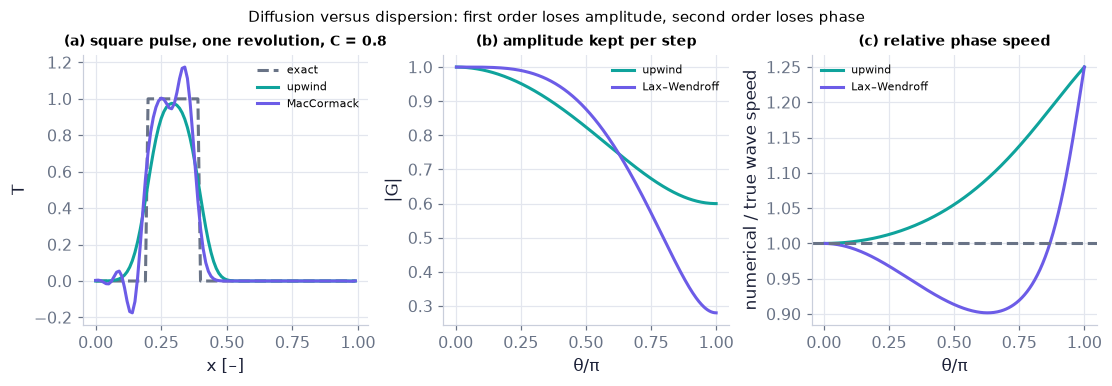

In [101]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.4))   # the figure and its panels
up = FD.advect_periodic("square", C=0.8, n_cells=100, scheme="upwind")        # one revolution at C = 0.8
mc = FD.advect_periodic("square", C=0.8, n_cells=100, scheme="maccormack")
a1.plot(up["x"], up["exact"], "--", color=C_EX, label="exact"); a1.plot(up["x"], up["T"], color=C_UP, label="upwind")   # draw the curve(s)
a1.plot(mc["x"], mc["T"], color=C_MC, label="MacCormack"); a1.set_xlabel("x [–]"); a1.set_ylabel("T"); a1.legend(fontsize=7, frameon=False)   # axis labels, with units where the quantity has them
a1.set_title("(a) square pulse, one revolution, C = 0.8", fontsize=9)   # the panel's title: what this panel shows
th = np.linspace(0.01, np.pi, 300)                                            # Fourier angles
a2.plot(th/np.pi, FD.amplification_modulus(th, 0.4, 0.0, "upwind"), color=C_UP, label="upwind")   # draw the curve(s)
a2.plot(th/np.pi, FD.amplification_modulus(th, 0.4, 0.0, "lax_wendroff"), color=C_MC, label="Lax–Wendroff")   # draw the curve(s)
a2.set_xlabel("θ/π"); a2.set_ylabel("|G|"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) amplitude kept per step", fontsize=9)   # the panel's title: what this panel shows
a3.plot(th/np.pi, [FD.phase_error("upwind", 0.8, t_) for t_ in th], color=C_UP, label="upwind")   # draw the curve(s)
a3.plot(th/np.pi, [FD.phase_error("lax_wendroff", 0.8, t_) for t_ in th], color=C_MC, label="Lax–Wendroff")   # draw the curve(s)
a3.axhline(1, color=C_EX, ls="--"); a3.set_xlabel("θ/π"); a3.set_ylabel("numerical / true wave speed"); a3.legend(fontsize=7, frameon=False)   # axis labels, with units where the quantity has them
a3.set_title("(c) relative phase speed", fontsize=9)   # the panel's title: what this panel shows
print(f"amplitude after one revolution: upwind {up['amplitude_ratio']:.3f}, MacCormack {mc['amplitude_ratio']:.3f}")   # show the numbers computed above
print(f"relative phase speed at theta = pi/2, C = 0.8: Lax-Wendroff {FD.phase_error('lax_wendroff', 0.8, np.pi/2):.3f}")   # show the numbers computed above
fig.suptitle("Diffusion versus dispersion: first order loses amplitude, second order loses phase", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c10_dispersion"); plt.show()   # display the figure

**What you see.** (a) The square pulse after one revolution: upwind (teal) rounded and a little lower, MacCormack (purple) sharp but with ripples trailing it and an overshoot. (b) $\lvert G\rvert$ against $\theta$ for both schemes at $C=0.8$. (c) Their relative phase speeds.

**How to read it.** For the long and medium waves that make up the pulse ($\theta$ below about $0.6\pi$) upwind damps strongly while Lax–Wendroff/MacCormack keeps $\lvert G\rvert$ close to 1 — but lets those waves fall behind (phase speed below 1, about 0.91 at $\theta=\pi/2$): the ripples trailing the pulse are short waves arriving late. (Both schemes damp the very shortest waves; upwind's run slightly fast at this $C$.)

**What would change if…** …$C=1$: both curves in (b) and (c) would be exactly 1 — the exact shift of C05.

In [102]:
nfr = 60 if not FAST else 30                                                  # frames
snaps_up, snaps_mc = [], []
x_ = np.arange(100)/100                                                      # 100 periodic nodes on [0, 1)
T_up = np.where((x_ >= 0.2) & (x_ < 0.4), 1.0, 0.0)                           # the start: the square pulse of advect_periodic
T_mc = T_up.copy(); T0_ = T_up.copy()
nsteps_rev = 125                                                              # one revolution at C = 0.8 on 100 cells
for k in range(nsteps_rev + 1):   # repeat the indented lines for each index
    if k % max(1, nsteps_rev//nfr) == 0: snaps_up.append(T_up.copy()); snaps_mc.append(T_mc.copy())   # store the value
    T_up = FD.transport_1d_step(T_up, 0.4, 0.0, "upwind", periodic=True)       # alpha = C/2
    T_mc = MCK.maccormack_advection_1d(T_mc, 0.8, 1)
fig, ax = plt.subplots(figsize=(6.4, 3.0))   # the figure and its panels
l_ex, = ax.plot(x_, T0_, "--", color=C_EX, label="exact"); l_up, = ax.plot(x_, snaps_up[0], color=C_UP, label="upwind")   # draw the curve(s)
l_mc, = ax.plot(x_, snaps_mc[0], color=C_MC, label="MacCormack"); ax.set_ylim(-0.3, 1.3); ax.set_xlabel("x [–]"); ax.legend(fontsize=7, loc="upper right")   # axis labels, with units where the quantity has them
def update(f):                                                                # frame f: after f*(steps per frame) steps
    k = f*max(1, nsteps_rev//nfr)
    l_ex.set_ydata(np.roll(T0_, int(round(0.8*k))))                           # the exact pulse moves 0.8 cells per step (rounded)
    l_up.set_ydata(snaps_up[f]); l_mc.set_ydata(snaps_mc[f]); return l_ex, l_up, l_mc
show_animation(animate(update, frames=len(snaps_up), fig=fig, interval=60), player="video")

**What you see.** A square pulse carried once round a periodic domain at $C=0.8$: the exact pulse (grey), upwind (teal) and MacCormack (purple) on one clock.

**How to read it.** The upwind pulse sags and rounds off step by step (numerical diffusion); the MacCormack pulse keeps its height but grows a train of ripples
behind it (dispersion: short waves travel too slowly).

**What would change if…** …$C=1$: both schemes would carry the pulse exactly.

**What would change if…** …we refuse to let the fluid compress at all? Then the time step is no longer tied to a (fake) sound speed, but the pressure must be solved for every step:
C11 splits the step so that one part is exactly that solve.

> 🔁 **Recap — R08 · The conservative convective term** (Ch. 4 §4.4). Because $\nabla\cdot\mathbf u=0$, $(\mathbf u\cdot\nabla)\mathbf u=\nabla\cdot(\mathbf u\mathbf u)$ *(10.82)* — the product rule $\nabla\cdot(\mathbf u\mathbf u)=(\mathbf u\cdot\nabla)\mathbf u+\mathbf u(\nabla\cdot\mathbf u)$ with the last term zero (Ch. 4, `conservative_to_advective_sym`). `MAC.convective_terms(form=…)` offers both.

### 🧩 Operator splitting and the projection method `C11`

*The question:* How can one time step move the flow forward *and* keep it exactly divergence-free?

*In one line:* $\dfrac{\mathbf u^{n+1}-\mathbf u^{n+1/2}}{\Delta t}+\nabla p^{n+1}=\mathbf 0$ *(10.117)* · $\nabla\cdot\mathbf u^{n+1}=0$ *(10.118)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **product rule for a divergence** — ∇·(f**a**) = ∇f·**a** + f ∇·**a** (Ch. 4 P113).
- **scipy.linalg.expm** — `expm(-A*t)` is the exact solution operator of dφ/dt = −Aφ (Ch. 2 P79).
- **matrix multiplication** — `A @ B`; in general A B ≠ B A (Ch. 2 P63).
- **Poisson equation** — ∇²p = f: an elliptic equation whose solution at one point depends on f everywhere (Ch. 5 P139).

#### The problem in plain words

Step the momentum equation forward ignoring the pressure: the fluid is pushed around by its own inertia and viscosity, and in some cells more fluid now arrives
than leaves — a divergence that an incompressible fluid cannot have. Now ask: what is the smallest correction that removes it? Push with a pressure gradient:
fluid is pushed out of the cells that were over-full. The pressure that does exactly this solves a Poisson equation, and the push it gives is a pure gradient —
it removes the divergent part of the velocity and touches nothing else.

#### The idea

```
uⁿ ──[ A₁: convect + diffuse, explicit ]──► u^{n+½}  (∇·u^{n+½} ≠ 0)
                                                 │  solve  ∇²p^{n+1} = ∇·u^{n+½}/Δt        (Poisson)
                                                 ▼
u^{n+1} = u^{n+½} − Δt ∇p^{n+1}   ──►   ∇·u^{n+1} = 0     (A₂: pressure/continuity, implicit)
any field = divergence-free part + gradient part — projection keeps the first and deletes the second
```

> 📎 **Primer — operator splitting and the commutator [A₁, A₂].** `P241` · To solve $d\phi/dt+(A_1+A_2)\phi=0$, take the step in two parts: first with $A_1$ alone, then with $A_2$ alone. Exact would be $e^{-\Delta t(A_1+A_2)}$;
splitting gives $e^{-\Delta tA_2}e^{-\Delta tA_1}$. For numbers these agree; for matrices they differ by $\frac{\Delta t^2}2[A_1,A_2]+O(\Delta t^3)$, where the commutator
$[A_1,A_2]=A_1A_2-A_2A_1$ measures how much the order matters. An $O(\Delta t^2)$ error per step is $O(\Delta t)$ overall: first order.

In [103]:
import numpy as np   # arrays and maths
from scipy.linalg import expm                     # matrix exponential (Ch. 2 P79)
A1 = np.array([[1., 1.], [0., 1.]]); A2 = np.array([[1., 0.], [-1., 2.]])
print(A1 @ A2 - A2 @ A1)                          # [[-1, 1], [0, 1]]: they do not commute
for dt in (0.1, 0.05):   # repeat the indented lines for each item listed
    print(dt, np.abs(expm(-dt*A2) @ expm(-dt*A1) - expm(-dt*(A1 + A2))).max())   # falls about 4x when dt halves: O(dt^2) per step

[[-1.  1.]
 [ 0.  1.]]
0.1 0.0040903105987731975
0.05 0.001130813494008731


📝 **Note.** **N60 [B]** **Operator splitting (10.111)–(10.112):** $\frac{d\phi}{dt}+A(\phi)=f$, $\phi(0)=\phi_0$ *(10.111)*, with $A(\phi)=A_1(\phi)+A_2(\phi)$ *(10.112)* — each substep
handles one part with the method best for it. **Climate hook:** every GCM splits "dynamics" (advection, pressure, Coriolis) from "physics" (radiation, clouds,
turbulence) in exactly this way.

In [104]:
sys2 = ch10.split_linear_system()                                 # our non-commuting 2 x 2 test system (exact solution by expm)
print("A1 =", sys2["A1"].tolist(), " A2 =", sys2["A2"].tolist(), "\ncommutator [A1, A2] =", sys2["commutator"].tolist())   # show the numbers computed above

A1 = [[1.0, 1.0], [0.0, 1.0]]  A2 = [[1.0, 0.0], [-1.0, 2.0]] 
commutator [A1, A2] = [[-1.0, 1.0], [0.0, 1.0]]


**What does the code above do?**

`split_linear_system()` returns the test problem $d\phi/dt+(A_1+A_2)\phi=0$ with two matrices that do not commute — the splitting error is then visible.

📝 **Note.** **N61 [B]** **Marchuk–Yanenko fractional steps (10.113)–(10.114):** $\frac{\phi^{n+1/2}-\phi^n}{\Delta t}+A_1(\phi^{n+1/2})=f_1^{n+1}$ *(10.113)* then
$\frac{\phi^{n+1}-\phi^{n+1/2}}{\Delta t}+A_2(\phi^{n+1})=f_2^{n+1}$ *(10.114)* (both implicit, with $f_1+f_2=f$) — first order in time (each substep is backward
Euler, and the split adds $\frac{\Delta t^2}2[A_1,A_2]$ per step).

In [105]:
print(f"Marchuk-Yanenko observed order in dt: {ch10.splitting_order('marchuk_yanenko'):.2f}")   # errors at t = 1 for dt = 0.1 … 0.0125

Marchuk-Yanenko observed order in dt: 0.99


**What does the code above do?**

`splitting_order` runs (10.113)–(10.114), $\tfrac{\phi^{n+1/2}-\phi^n}{\Delta t}+A_1(\phi^{n+1/2})=f_1^{n+1},\ \tfrac{\phi^{n+1}-\phi^{n+1/2}}{\Delta t}+A_2(\phi^{n+1})=f_2^{n+1}$ on the test system with four time steps and fits the log–log slope of the error at $t=1$: first order.

📝 **Note.** **N62 [B]** **The MAC split (10.115):** $\mathbf A_1(\mathbf u,p)=\begin{pmatrix}(\mathbf u\cdot\nabla)\mathbf u-\frac1{Re}\nabla^2\mathbf u\\\mathbf 0\end{pmatrix}$ (teal:
convection–diffusion) and $\mathbf A_2(\mathbf u,p)=\begin{pmatrix}\nabla p\\\nabla\cdot\mathbf u\end{pmatrix}$ (orange: pressure and continuity) *(10.115)*.

📝 **Note.** **N63 [B]** **Substep 1, explicit (10.116):** $\frac{\mathbf u^{n+1/2}-\mathbf u^n}{\Delta t}+(\mathbf u^n\cdot\nabla)\mathbf u^n-\frac1{Re}\nabla^2\mathbf u^n=\mathbf g^{n+1}$
*(10.116)* — an FTCS-like step (C02) in 2-D; `MAC.predictor`.

> 📎 **Primer — Helmholtz–Hodge decomposition.** `P240` · Any smooth vector field can be split into a divergence-free part and a gradient: $\mathbf w=\mathbf u+\nabla\phi$ with $\nabla\cdot\mathbf u=0$. Taking the divergence
gives $\nabla^2\phi=\nabla\cdot\mathbf w$ (a Poisson problem, Ch. 5 P139), so $\phi$ — and then $\mathbf u=\mathbf w-\nabla\phi$ — is found by one solve. The gradient part
is curl-free (curl grad = 0, Ch. 2); the boundary condition on the normal velocity makes the split unique.

In [106]:
import sympy as sp   # symbolic algebra
x, y = sp.symbols('x y')   # symbols for sympy
w = sp.Matrix([x + y, 0])                          # a field with divergence 1
phi = x**2/2                                       # solves phi_xx + phi_yy = div w = 1
u = w - sp.Matrix([sp.diff(phi, x), sp.diff(phi, y)])
print(u.T, sp.diff(u[0], x) + sp.diff(u[1], y))    # (y, 0) and divergence 0

Matrix([[y, 0]]) 0


#### 🧮 Derivation — The continuous projection: $\nabla^2p^{n+1}=\frac1{\Delta t}\nabla\cdot\mathbf u^{n+1/2}$, and the correction is curl-free `D19` (Eq. 10.118: $\nabla\cdot\mathbf u^{n+1}=0$)

**What we want to show.** Find the equation that fixes the pressure in the projection step and show that the correction removes divergence without touching the vorticity. (The book writes only the discrete form, $\nabla^2_dp^{n+1}_{i,j}=\frac1{\Delta t}(\nabla_d\cdot\mathbf u^{n+1/2})_{i,j}$ (10.124) with the five-point Laplacian and the face-difference divergence; this continuous version is ours.)

**Assumptions.** Δt > 0 constant; walls with prescribed normal velocity (step 6).

**The plan.**

1. Take the divergence of (10.117), $\dfrac{\mathbf u^{n+1}-\mathbf u^{n+1/2}}{\Delta t}+\nabla p^{n+1}=\mathbf 0$.
2. Impose (10.118), $\nabla\cdot\mathbf u^{n+1}=0$ → a Poisson equation.
3. Boundary and solvability conditions.
4. Take the curl → vorticity untouched.

**Tools we use** (each explained before this point): Divergence of a gradient = Laplacian (Ch. 2 §2.9) · curl of a gradient = 0 (Ch. 2 §2.9) · Gauss' theorem (Ch. 2 §2.12) · Helmholtz–Hodge decomposition (primer P240) · Poisson equation (Ch. 5 P139).

**We start from**

$$ \frac{\mathbf u^{n+1}-\mathbf u^{n+1/2}}{\Delta t}+\nabla p^{n+1}=\mathbf 0\ \text{(10.117) and}\ \nabla\cdot\mathbf u^{n+1}=0\ \text{(10.118)} $$

*In words:* add a pressure push so that the new velocity is divergence-free.

---

**Step 1 of 9 — Solve (10.117) for the new velocity.**

$$ \mathbf u^{n+1}=\mathbf u^{n+1/2}-\Delta t\,\nabla p^{n+1} $$

- *Why we can do this:* Multiply by Δt and rearrange; the new velocity is the predicted one minus a gradient.
- *In words:* correct the prediction with a pressure push.

---

**Step 2 of 9 — Take the divergence of both sides.**

$$ \nabla\cdot\mathbf u^{n+1}=\nabla\cdot\mathbf u^{n+1/2}-\Delta t\,\nabla\cdot\nabla p^{n+1} $$

- *Why we can do this:* The divergence is linear; Δt is a constant.
- *In words:* how much the push changes the net outflow.

---

**Step 3 of 9 — Recognise the Laplacian.**

$$ \nabla\cdot\nabla p=\nabla^2p $$

- *Why we can do this:* Ch. 2: ∂/∂x_i(∂p/∂x_i) is the Laplacian.
- *In words:* the push changes the outflow by Δt × the curvature of p.

---

**Step 4 of 9 — Impose incompressibility (10.118).**

$$ 0=\nabla\cdot\mathbf u^{n+1/2}-\Delta t\,\nabla^2p^{n+1} $$

- *Why we can do this:* ∇·u^(n+1) = 0 is *imposed* — it is what we want the new field to satisfy, not something derived.
- *In words:* the push must cancel the predicted divergence.

---

**Step 5 of 9 — Rearrange: the pressure Poisson equation.**

$$ \nabla^2p^{n+1}=\frac1{\Delta t}\nabla\cdot\mathbf u^{n+1/2} $$

- *Why we can do this:* Divide by Δt. A Poisson equation (P139): p is found by one elliptic solve, everywhere at once — the 'instantaneous' pressure of N51.
- *In words:* where fluid piles up, the pressure has a maximum.

---

**Step 6 of 9 — Dot (10.117) with the wall normal.**

$$ \frac{\partial p^{n+1}}{\partial n}=\frac1{\Delta t}\,\mathbf n\cdot(\mathbf u^{n+1/2}-\mathbf u^{n+1}) $$

- *Why we can do this:* At a wall $\mathbf n\cdot\mathbf u^{n+1}$ is prescribed; if the predictor already carries the wall value, $\partial p/\partial n=0$ — the Neumann condition that the staggered grid builds in (D20).
- *In words:* the boundary condition for p comes from the normal velocity.

---

**Step 7 of 9 — Check solvability with Gauss.**

$$ \int_V\nabla^2p\,dV=\oint\frac{\partial p}{\partial n}dA\ \Rightarrow\ \frac1{\Delta t}\int_V\nabla\cdot\mathbf u^{n+1/2}dV=\oint\frac{\partial p} {\partial n}dA $$

- *Why we can do this:* Gauss' theorem applied to ∇p; with ∂p/∂n = 0 the predicted field must have zero net outflow — true when the walls' normal velocities balance.
- *In words:* a closed box can only redistribute fluid, not create it.

---

**Step 8 of 9 — Take the curl of step 1.**

$$ \nabla\times\mathbf u^{n+1}=\nabla\times\mathbf u^{n+1/2}-\Delta t\,\nabla\times\nabla p^{n+1}=\nabla\times\mathbf u^{n+1/2} $$

- *Why we can do this:* The curl of a gradient is zero (Ch. 2).
- *In words:* the projection does not change the vorticity at all.

---

**Step 9 of 9 — Read it as a decomposition.**

$$ \mathbf u^{n+1/2}=\underbrace{\mathbf u^{n+1}}_{\nabla\cdot=0}+\underbrace{\nabla(\Delta t\,p^{n+1})}_{\nabla\times=0} $$

- *Why we can do this:* Step 1 rearranged: the Helmholtz–Hodge split (P240); the projection keeps the divergence-free part and deletes the gradient part — the book's 'irrotational correction field … proportional to the pressure'.
- *In words:* keep the swirl, remove the squeeze.

---

**Result**

$$ \begin{array}{l}\nabla^2p^{n+1}=\frac1{\Delta t}\nabla\cdot\mathbf u^{n+1/2}\ \text{with}\ \partial p/\partial n\ \text{from the normal velocity, and} \\ \nabla\times(\mathbf u^{n+1}-\mathbf u^{n+1/2})=0\end{array} $$

*In words:* the pressure is whatever removes the divergence; its push is a pure gradient.

**What it means.** Every incompressible (and Boussinesq/anelastic) code solves this Poisson problem each step — the pressure solve of ocean models. It fails to be exact in time: splitting makes the scheme first order in Δt (N61).

**Check it.** Units: with p the kinematic (or dimensionless) pressure, ∇²p is (m²/s²)/m² = 1/s² and ∇·u/Δt is (1/s)/s = 1/s² ✓. Tiny example: u* = (x + y, 0), Δt = 1 ⇒ p = x²/2, u = (y, 0) ✓ (divergence 0; vorticity −1 before and after). `ch10.projection_sympy()`.

> ⚠️ **Common confusion (traps in `D19`):** Thinking ∇·u^(n+1) = 0 is derived (it is imposed); forgetting that p needs a boundary condition in the continuous problem; taking the divergence of (10.116), $\dfrac{\mathbf u^{n+1/2}-\mathbf u^n}{\Delta t}+(\mathbf u^n\cdot\nabla)\mathbf u^n-\dfrac1{Re}\nabla^2\mathbf u^n=\mathbf g^{n+1}$ instead of (10.117), $\dfrac{\mathbf u^{n+1}-\mathbf u^{n+1/2}}{\Delta t}+\nabla p^{n+1}=\mathbf 0$.

📝 **Note.** **N72 [B]** **The projection method** (Chorin 1968, Temam 1969): applied explicitly on the staggered grid it is the MAC scheme (apart from boundary details).
Its meaning (D19's result): the first step leaves a field with divergence; the second adds an **irrotational** correction — the gradient of a potential
proportional to $p$ — that removes exactly that divergence. The discrete curl of the correction is zero to round-off (checked in C12).

📝 **Note.** **N41 [B]** **Initial and boundary conditions for Navier–Stokes (10.83):** $\mathbf u(\mathbf x,t=0)=\mathbf u_0(\mathbf x)$ with $\nabla\cdot\mathbf u_0=0$ *(10.83)*, and

| Boundary | Velocity | Pressure |
|---|---|---|
| solid wall | no slip ($\mathbf u$ = wall velocity) | **none** |
| inflow | $\mathbf u$ given | (may be given) |
| outflow | zero tangential velocity and zero normal stress, or zero derivatives — artificial, so test that the answer does not depend on where it is put (N111) | — |
| anywhere | — | fixed at one point: only $\nabla p$ appears, so $p$ + const gives the same flow |

#### ✏️ Tiny example: a projection by hand

$\Delta t=1$, and a predicted field $\mathbf u^{n+1/2}=(x+y,\ 0)$ (unbounded plane, no walls).
1. Its divergence: $\partial(x+y)/\partial x+0=1$ — not allowed.
2. Poisson: $\nabla^2p=\nabla\cdot\mathbf u^{n+1/2}/\Delta t=1$; one solution $p=x^2/2$.
3. Correction $-\Delta t\nabla p=-(x,\ 0)$.
4. $\mathbf u^{n+1}=(x+y-x,\ 0)=(y,\ 0)$: a simple shear flow, divergence 0 ✓.
5. The removed part $(x,0)=\nabla(x^2/2)$ has zero curl ✓ — it is pure "squeeze", no rotation; the vorticity of the flow ($-1$) is untouched.
6. With walls, the boundary condition would pick which solution of $\nabla^2p=1$ is the right one (C12, D20).

In [107]:
ps = ch10.projection_sympy()                                      # D19 by machine, with generic functions u*, v*, p
print("Poisson equation:", ps["poisson"]); print("curl of the correction:", ps["curl"], "  divergence after:", ps["divergence_after"])   # show the numbers computed above
g16 = MAC.MacGrid(16, 16)                                         # 16 x 16 staggered cells on the unit square, walls all round
fc = MAC.face_coordinates(g16)                                    # coordinates of the u-faces (xu, yu) and v-faces (xv, yv)
us = np.sin(np.pi*fc["xu"])*np.cos(np.pi*fc["yu"]) + 0.5*np.sin(2*np.pi*fc["xu"])   # a divergent predicted u on its faces
vs = np.cos(np.pi*fc["xv"])*np.sin(np.pi*fc["yv"])                # ... and v on its faces
us[:, 0] = us[:, -1] = 0.0; vs[0, :] = vs[-1, :] = 0.0            # wall-normal faces: no flow through the walls
parts = MAC.project(us, vs, g16, dt=1.0, return_parts=True)       # one projection: Poisson solve + face correction
print(f"max |div u| before: {np.abs(parts['div_before']).max():.3f}   after: {np.abs(parts['div_after']).max():.1e}")   # show the numbers computed above
print(f"max |discrete curl of the correction|: {np.abs(parts['curl_correction']).max():.1e}")   # show the numbers computed above

Poisson equation: Eq(Derivative(p(x, y), (x, 2)) + Derivative(p(x, y), (y, 2)), (Derivative(u_s(x, y), x) + Derivative(v_s(x, y), y))/Delta_t)
curl of the correction: 0   divergence after: 0
max |div u| before: 9.274   after: 9.5e-13
max |discrete curl of the correction|: 0.0e+00


**What does the code above do?**

1. `projection_sympy()` repeats D19: the divergence of (10.117), $\dfrac{\mathbf u^{n+1}-\mathbf u^{n+1/2}}{\Delta t}+\nabla p^{n+1}=\mathbf 0$ with (10.118), $\nabla\cdot\mathbf u^{n+1}=0$ gives $\nabla^2p=\nabla\cdot\mathbf u^{n+1/2}/\Delta t$; the correction's curl is 0.
2. On a $16^2$ staggered grid a deterministic divergent field (walls closed) is projected: the divergence drops from order 1 to round-off, and the discrete curl of
   the correction $-\Delta t\nabla p$ is zero — the vorticity is untouched.

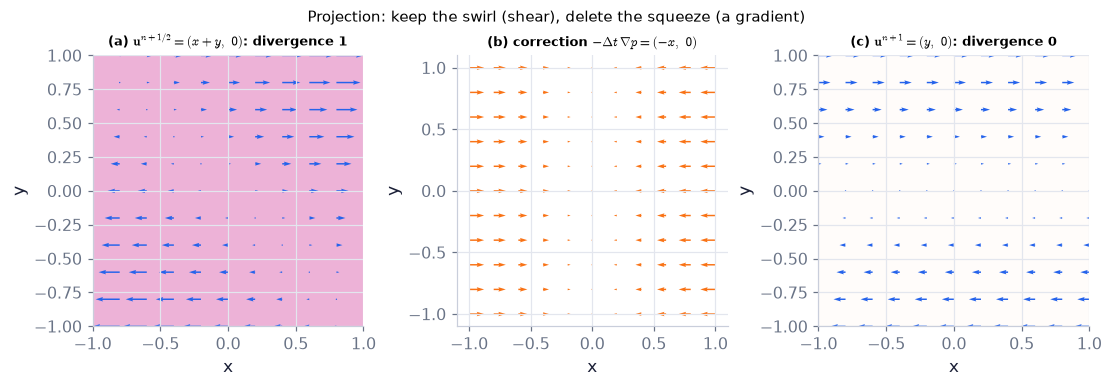

In [108]:
X, Y = np.meshgrid(np.linspace(-1, 1, 11), np.linspace(-1, 1, 11))   # a coarse grid of arrows on [-1, 1]^2
fields = [((X + Y, 0*X), r"(a) $\mathbf{u}^{n+1/2}=(x+y,\ 0)$: divergence 1", C_IM, 1.0),      # titles in mathtext ($...$)
          ((-X, 0*X), r"(b) correction $-\Delta t\,\nabla p=(-x,\ 0)$", C_FT, None),
          ((Y, 0*X), r"(c) $\mathbf{u}^{n+1}=(y,\ 0)$: divergence 0", C_IM, 0.0)]
fig, axs = plt.subplots(1, 3, figsize=(10, 3.4))   # the figure and its panels
for ax, ((U_, V_), title, col, div) in zip(axs, fields):   # repeat the indented lines for each item listed
    if div is not None:
        ax.imshow(np.full((2, 2), div), extent=(-1, 1, -1, 1), cmap="RdPu", vmin=0, vmax=1.5, alpha=0.35)   # the divergence as a tint
    ax.quiver(X, Y, U_, V_, color=col, scale=18)                  # the arrows
    ax.set_title(title, fontsize=8.5); ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")   # the panel's title: what this panel shows
fig.suptitle("Projection: keep the swirl (shear), delete the squeeze (a gradient)", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** (a) Arrows that grow to the right on a pink (divergent) background; (b) arrows pointing back towards the $y$-axis; (c) arrows that only shear, on a white (divergence-free) background.

**How to read it.** The correction has no curl: it cannot change the vorticity ($-1$ in (a) and (c)), only the divergence.

**What would change if…** …the predicted field had no divergence: $\nabla^2p=0$, $p$ = const and the projection would do nothing.

In [109]:
gA = MAC.MacGrid(16, 16, 1.0, 1.0, (False, False), dict(top=1.0, bottom=0.0, left=0.0, right=0.0))   # a 16^2 cavity grid, lid at y = 1
dtA = 0.8*MAC.dt_limit(1.0, 0.0, 100.0, 1/16, safety=1.0)        # time step from (10.127)-(10.128)
stA = MAC.cavity(Re=100.0, n=16, t_end=0.5, tol_steady=0.0, cache=False)   # the cavity after 0.5 time units from rest
usA, vsA = MAC.predictor(stA["u"], stA["v"], gA, 100.0, dtA)      # stage 1: convect + diffuse (10.116)
sgA = MAC.projection_stages(usA, vsA, gA, dtA)                    # stages 2-4: Poisson, correction, divergence after
xcA, ycA = np.meshgrid(gA.xc, gA.yc)                              # cell centres
def centre(u_, v_): return 0.5*(u_[:, 1:] + u_[:, :-1]), 0.5*(v_[1:, :] + v_[:-1, :])   # face velocities averaged to the centres
panels = [("uⁿ (divergence ≈ 0)", stA["u"], stA["v"], MAC.divergence(stA["u"], stA["v"], gA), None),
          ("u^{n+½} after the predictor", usA, vsA, sgA["div_before"], None),
          ("p from the Poisson equation (10.124)", usA, vsA, sgA["div_before"], sgA["p"]),
          ("u^{n+1} after the correction", sgA["u"], sgA["v"], sgA["div_after"], None)]
fig, ax = plt.subplots(figsize=(4.8, 4.4)); vmax = np.abs(sgA["div_before"]).max()   # the figure and its panels
def update(f):                                                    # frame f = stage f
    ax.clear(); title, u_, v_, dv, p_ = panels[f]
    ax.pcolormesh(gA.xc, gA.yc, dv, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="nearest")   # cell divergence (red/blue)
    if p_ is not None: ax.contour(xcA, ycA, p_, 12, colors=C_FT, linewidths=1)   # pressure contours (orange)
    uc, vc = centre(u_, v_); ax.quiver(xcA, ycA, uc, vc, color=C_IM, scale=6)   # arrows / streamlines of the velocity
    ax.set_title(f"{title}\nmax |∇·u| = {np.abs(dv).max():.1e}", fontsize=9); ax.set_aspect("equal")   # the panel's title: what this panel shows
    return []   # the values for this call
show_animation(animate(update, frames=4, fig=fig, interval=900), player="frames")

**What you see.** One MAC time step in slow motion on a $16^2$ cavity (lid moving to the right at the top): velocity arrows (blue) over the cell divergence (red/blue),
then the pressure contours (orange), then the corrected field.

**How to read it.** Step through the four frames: the divergence is round-off in $\mathbf u^n$, appears after the predictor (strongest near the lid corners), sets
up a pressure field, and is gone again after the correction (the title prints $\max\lvert\nabla\cdot\mathbf u\rvert$ at each stage).

**What would change if…** …the time step were halved: the predictor's divergence would halve, and so would the pressure correction — but the result after the
projection would again be divergence-free to round-off.

📝 **Note.** **N74 [B]** **Glowinski's Θ-scheme** — a better split: three substeps (Stokes to $n+\Theta$, a nonlinear convection–diffusion step to $n+1-\Theta$,
Stokes to $n+1$) with weights $\alpha_\Theta+\beta_\Theta=1$. It is second order only for $\Theta=1-\frac1{\sqrt2}$ with $\beta_\Theta=\frac\Theta{1-\Theta}$ (Glowinski;
checked here by a sympy series: the $\Delta t^2$ term of $R-e^{-\lambda\Delta t}$ vanishes there) — ⚠️ this $\Theta$ is not the Fourier angle $\theta$ of C04. The
first Stokes substep reads $\frac{\mathbf u^{n+\Theta}-\mathbf u^n}{\Theta\Delta t}-\frac{\alpha_\Theta}{Re}\nabla^2\mathbf u^{n+\Theta}+\nabla p^{n+\Theta}=\mathbf g^{n+\Theta}+
\frac{\beta_\Theta}{Re}\nabla^2\mathbf u^n-(\mathbf u^n\cdot\nabla)\mathbf u^n$, $\nabla\cdot\mathbf u^{n+\Theta}=0$ *(10.129)–(10.130)*.

In [110]:
th_ = ch10.theta_scheme_amplification_sympy()                     # the one-step factor R of the Theta-scheme on y' = -(l1 + l2) y
print("dt^2 coefficient of R - exp(-(l1+l2) dt):", th_["z2_coeff"])   # a factor 2 th^2 - 4 th + 1 appears
print("its root in (0, 1/2):", th_["theta_root"], "=", float(th_["theta_root"]))   # 1 - 1/sqrt(2), computed (not typed)
print(f"observed order at Theta = 1 - 1/sqrt 2: {ch10.splitting_order('theta', theta_split=1 - 1/np.sqrt(2)):.2f}")   # show the numbers computed above
print(f"observed order at Theta = 1/4: {ch10.splitting_order('theta', theta_split=0.25):.2f} (dt = 0.1 … 0.0125), "   # show the numbers computed above
      f"{ch10.splitting_order('theta', dt_list=(0.004, 0.002, 0.001, 0.0005), theta_split=0.25):.3f} (dt = 0.004 … 0.0005)")

dt^2 coefficient of R - exp(-(l1+l2) dt): -(lambda1 + lambda2)*(2*theta**2 - 4*theta + 1)*(3*lambda1*theta - lambda1 - lambda2*theta + lambda2)/(2*(theta - 1))
its root in (0, 1/2): 1 - sqrt(2)/2 = 0.2928932188134525
observed order at Theta = 1 - 1/sqrt 2: 2.00
observed order at Theta = 1/4: 0.86 (dt = 0.1 … 0.0125), 0.995 (dt = 0.004 … 0.0005)


**What does the code above do?**

1. `theta_scheme_amplification_sympy()` builds the three substeps (10.129)–(10.133), $\tfrac{\mathbf u^{n+\Theta}-\mathbf u^n}{\Theta\Delta t}-\tfrac{\alpha_\Theta}{Re}\nabla^2\mathbf u^{n+\Theta}+\nabla p^{n+\Theta}=\mathbf g^{n+\Theta}+\tfrac{\beta_\Theta}{Re}\nabla^2\mathbf u^n-(\mathbf u^n\cdot\nabla)\mathbf u^n,\ \nabla\cdot\mathbf u^{n+\Theta}=0,\ \tfrac{\mathbf u^{n+1-\Theta}-\mathbf u^{n+\Theta}}{(1-2\Theta)\Delta t}-\tfrac{\beta_\Theta}{Re}\nabla^2\mathbf u^{n+1-\Theta}+(\mathbf u^*\cdot\nabla)\mathbf u^{n+1-\Theta}=\mathbf g^{n+1-\Theta}+\tfrac{\alpha_\Theta}{Re}\nabla^2\mathbf u^{n+\Theta}-\nabla p^{n+\Theta},\ \tfrac{\mathbf u^{n+1}-\mathbf u^{n+1-\Theta}}{\Theta\Delta t}-\tfrac{\alpha_\Theta}{Re}\nabla^2\mathbf u^{n+1}+\nabla p^{n+1}=\mathbf g^{n+1}+\tfrac{\beta_\Theta}{Re}\nabla^2\mathbf u^{n+1-\Theta}-(\mathbf u^{n+1-\Theta}\cdot\nabla)\mathbf u^{n+1-\Theta},\ \nabla\cdot\mathbf u^{n+1}=0$ on the scalar model $y'=-(\lambda_1+\lambda_2)y$ and expands the one-step factor
   against $e^{-(\lambda_1+\lambda_2)\Delta t}$: the $\Delta t^2$ coefficient contains the factor $2\Theta^2-4\Theta+1$, whose root below ½ is $1-1/\sqrt2\approx0.2929$.
2. On the $2\times2$ test system the measured order is 2 at that $\Theta$ and 1 at $\Theta=\frac14$ — on the default time steps the $\Theta=\frac14$ run is still
   pre-asymptotic (about 0.86); on smaller steps it settles at 1.

**What would change if…** …we wrote the projection on a grid? Where the numbers live — $p$ at cell centres, velocities on faces — decides whether the discrete projection is exact
and whether a zigzag pressure can hide. C12.

### 🧩 The staggered (MAC) grid: discrete continuity, the pressure Poisson equation and the checkerboard `C12`

*The question:* Why store pressure at cell centres and velocities on cell faces — and what goes wrong if all three sit at the same points?

*In one line:* $\nabla^2_dp^{n+1}_{i,j}\equiv\tfrac{p^{n+1}_{i+1,j}-2p^{n+1}_{i,j}+p^{n+1}_{i-1,j}}{\Delta x^2}+\tfrac{p^{n+1}_{i,j+1}-2p^{n+1}_{i,j}+p^{n+1}_{i,j-1}}{\Delta y^2}=\tfrac1{\Delta t}\Big(\tfrac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\tfrac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)$ *(10.124)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **np.meshgrid and the [j, i] layout** — fields are stored as `f[j, i]` — row = y index, column = x index (Ch. 2 P76).
- **null space and rank** — the inputs a matrix sends to zero; rank + nullity = number of columns (Ch. 1 P58).
- **5-point Laplacian and relaxation solvers (Jacobi, Gauss–Seidel, SOR)** — the Laplacian as (p_E + p_W + p_N + p_S − 4p_P)/h², and sweeps that relax toward its solution (Ch. 6 P160).

#### The problem in plain words

An ocean model divides the sea into boxes. What matters for mass is the water crossing each face of each box; what drives that water is the pressure difference
between the two boxes the face separates. So put the pressure in the middle of each box and the velocity on each face — then "net outflow of a box" and "push
across a face" each use two neighbouring numbers, the most compact and accurate choice. Put everything at the same points instead and the pressure difference
across a point must skip a neighbour: a pressure that zigzags (+, −, +, −) looks perfectly flat to the momentum equation and grows unchecked. The staggered
layout is Arakawa's **C-grid**, used by most ocean and many atmosphere models.

#### The idea

```
            v_{i,j+½}  ↑
       ┌───────────────┼───────────────┐
       │                               │
u_{i−½,j} →          p_{i,j}          → u_{i+½,j}      net outflow = (u_{i+½} − u_{i−½})/Δx + (v_{j+½} − v_{j−½})/Δy
       │                               │                push on a face = (p_{i+1} − p_i)/Δx   (adjacent values)
       └───────────────┼───────────────┘
            v_{i,j−½}  ↑
```

> 📎 **Primer — half-index notation and staggered array shapes.** `P242` · On a staggered grid a velocity sits halfway between two pressure points: $u_{i+1/2,j}$ lives on the vertical face between cells $(i,j)$ and $(i+1,j)$. In code there
are no half indices, so each field gets its own array: `p[ny, nx]` (centres), `u[ny, nx+1]` (vertical faces, including both side walls), `v[ny+1, nx]` (horizontal
faces) — the project's `[j, i]` layout (Ch. 2 P76). `u[j, i]` means $u_{i-1/2,j}$.

In [111]:
import numpy as np   # arrays and maths
nx, ny = 3, 2
p = np.zeros((ny, nx)); u = np.zeros((ny, nx + 1)); v = np.zeros((ny + 1, nx))
print(p.shape, u.shape, v.shape)                            # (2, 3) (2, 4) (3, 3): u has one extra column (x-faces), v one extra row (y-faces)
div = (u[:, 1:] - u[:, :-1]) + (v[1:, :] - v[:-1, :])       # net outflow per cell (dx = dy = 1): right minus left face, top minus bottom face
print(div.shape)                                            # (2, 3): one value per cell, the same shape as p

(2, 3) (2, 4) (3, 3)
(2, 3)


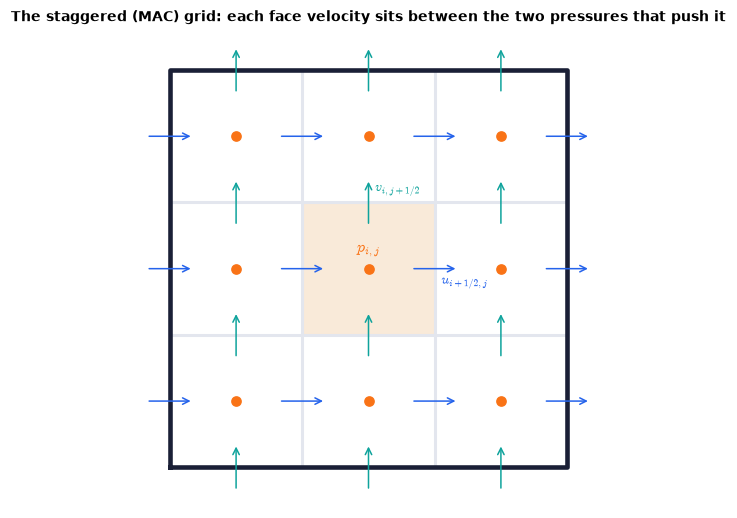

In [112]:
fig, ax = plt.subplots(figsize=(5, 4.6))   # the figure and its panels
staggered_grid(ax, n=3, highlight=(2, 2))                         # our Fig. 10.4: p at centres, u and v on faces, one control cell shaded
ax.set_title("The staggered (MAC) grid: each face velocity sits between the two pressures that push it", fontsize=9)   # the panel's title: what this panel shows
plt.show()   # display the figure

**What you see.** Three kinds of points: pressure dots at the cell centres, $u$ arrows on the vertical faces, $v$ arrows on the horizontal faces; one control cell shaded and the boundary faces drawn thick.

**How to read it.** Each face velocity sits between exactly the two pressures that push it; each cell is surrounded by exactly the four velocities of its mass balance.

**What would change if…** …a collocated grid: every symbol at the same dot — see the checkerboard below.

📝 **Note.** **N64 [B]** **Staggered predictor:** $u^{n+1/2}_{i+1/2,j}=u^n_{i+1/2,j}-\Delta t\Big(uu_x+vu_y-\tfrac1{Re}\nabla^2u\Big)^n_{i+1/2,j}+\Delta t\,(g_x)^{n+1}_{i+1/2,j}$
*(10.119)* and the same for $v$ on its faces, $v^{n+1/2}_{i,j+1/2}=v^n_{i,j+1/2}-\Delta t\Big(uv_x+vv_y-\tfrac1{Re}\nabla^2v\Big)^n_{i,j+1/2}+\Delta t\,(g_y)^{n+1}_{i,j+1/2}$ *(10.120)* (the book writes the body force as $\mathbf g=(f,g)$; we write $(g_x,g_y)$). Quantities not stored on a face
are averaged to it (two- and four-point averages — our documented choice in `MAC.predictor`).

📝 **Note.** **N65 [B]** **Velocity correction (10.121)–(10.122):** $u^{n+1}_{i+1/2,j}=u^{n+1/2}_{i+1/2,j}-\frac{\Delta t}{\Delta x}(p^{n+1}_{i+1,j}-p^{n+1}_{i,j})$ *(10.121)* and
$v^{n+1}_{i,j+1/2}=v^{n+1/2}_{i,j+1/2}-\frac{\Delta t}{\Delta y}(p^{n+1}_{i,j+1}-p^{n+1}_{i,j})$ *(10.122)* — (10.117), $\dfrac{\mathbf u^{n+1}-\mathbf u^{n+1/2}}{\Delta t}+\nabla p^{n+1}=\mathbf 0$ with the face gradient (10.126), $\Big(\tfrac{\partial p}{\partial x}\Big)_{i+1/2,j}=\tfrac{p_{i+1,j}-p_{i,j}}{\Delta x},\quad \Big(\tfrac{\partial p}{\partial y}\Big)_{i,j+1/2}=\tfrac{p_{i,j+1}-p_{i,j}}{\Delta y}$.

📝 **Note.** **N66 [B]** **Discrete continuity per cell (10.123):** $\frac{u^{n+1}_{i+1/2,j}-u^{n+1}_{i-1/2,j}}{\Delta x}+\frac{v^{n+1}_{i,j+1/2}-v^{n+1}_{i,j-1/2}}{\Delta y}=0$ *(10.123)* — the flux
balance of one box (Gauss' theorem, Ch. 2, applied to a single cell): in minus out equals zero. Second order, $O(\Delta x^2,\Delta y^2)$, with only four values.

> 📎 **Primer — singular linear systems and the compatibility condition.** `P243` · The pure-Neumann Poisson matrix (every boundary a wall) sends a constant vector to zero — adding a constant to $p$ changes nothing. So $A$ is singular: $Ax=b$ has
a solution only if $b$ is orthogonal to that null vector, i.e. **$\sum b=0$** (net inflow through all walls is zero), and then infinitely many ($x$ + const). Fix it
by pinning one value or asking for zero mean. `np.linalg.solve` refuses a singular matrix; `np.linalg.lstsq(A, b)` instead returns the $x$ that makes
$\lVert Ax-b\rVert$ smallest and, among all such $x$, the one of smallest length — for a compatible singular system that is an exact solution with zero mean.

In [113]:
import numpy as np   # arrays and maths
A = np.array([[1., -1, 0], [-1, 2, -1], [0, -1, 1]])          # 1-D Neumann Laplacian (3 cells)
print(np.linalg.matrix_rank(A), A @ np.ones(3))                # rank 2; A (1,1,1) = 0
b = np.array([1., 0, -1])                                      # sums to 0: compatible
x = np.linalg.lstsq(A, b, rcond=None)[0]; print(x, A @ x)      # one solution (mean zero); it reproduces b

2 [0. 0. 0.]
[ 1. -0. -1.] [ 1. -0. -1.]


> 📎 **Primer — scipy.sparse.diags, kron and a cached splu factorisation.** `P244` · A 1-D second-difference matrix is three diagonals: `sparse.diags([1, -2, 1], [-1, 0, 1], shape=(n, n))`. The 2-D 5-point Laplacian is built from two 1-D ones by
Kronecker products: `sparse.kron(I_y, Lx) + sparse.kron(Ly, I_x)` (Ch. 6 P161 introduced sparse storage). The matrix never changes during a run, so factorise it once,
`lu = splu(A.tocsc())`, and each time step only calls `lu.solve(b)` — the reason MAC codes are fast.

In [114]:
import numpy as np, scipy.sparse as sp   # arrays and maths
from scipy.sparse.linalg import splu   # a tool used below
n = 4; L1 = sp.diags([1.0, -2.0, 1.0], [-1, 0, 1], shape=(n, n))
A = sp.kron(sp.identity(n), L1) + sp.kron(L1, sp.identity(n))   # 16 x 16 Dirichlet Laplacian
lu = splu(A.tocsc())                                            # factorise once ...
print(A.shape, lu.solve(np.ones(16))[:4])                       # ... solve many times

(16, 16) [-0.8333 -1.1667 -1.1667 -0.8333]


#### 🧮 Derivation — The discrete pressure Poisson equation, no pressure boundary condition, and solvability Σ rhs = 0 `D20` (Eq. 10.124: $\nabla^2_dp^{n+1}_{i,j}\equiv\tfrac{p^{n+1}_{i+1,j}-2p^{n+1}_{i,j}+p^{n+1}_{i-1,j}}{\Delta x^2}+\tfrac{p^{n+1}_{i,j+1}-2p^{n+1}_{i,j}+p^{n+1}_{i,j-1}}{\Delta y^2}=\tfrac1{\Delta t}\Big(\tfrac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\tfrac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)$)

**What we want to show.** Derive (10.124), $\nabla^2_dp^{n+1}_{i,j}\equiv\tfrac{p^{n+1}_{i+1,j}-2p^{n+1}_{i,j}+p^{n+1}_{i-1,j}}{\Delta x^2}+\tfrac{p^{n+1}_{i,j+1}-2p^{n+1}_{i,j}+p^{n+1}_{i,j-1}}{\Delta y^2}=\tfrac1{\Delta t}\Big(\tfrac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\tfrac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)$ cell by cell on the staggered grid, including the boundary cells the book discusses in words, and find when it can be solved.

**Assumptions.** Uniform staggered grid; the normal velocity on every boundary face prescribed and not corrected (step 7).

**The plan.**

1. Insert the face corrections into the budget of an interior cell.
2. Repeat for a wall cell.
3. Look at the matrix: rows sum to zero ⇒ solvability and a free constant.

**Tools we use** (each explained before this point): Half-index notation (primer P242) · singular systems and compatibility (primer P243) · sparse matrices (Ch. 6 P161, primer P244).

**We start from**

$$ \begin{array}{l}\text{The corrections}\ u^{n+1}_{i+1/2,j}=u^{n+1/2}_{i+1/2,j}-\frac{\Delta t}{\Delta x}(p^{n+1}_{i+1,j}-p^{n+1}_{i,j})\ \text{(10.121),} \\ v^{n+1}_{i,j+1/2}=v^{n+1/2}_{i,j+1/2}-\frac{\Delta t} {\Delta y}(p^{n+1}_{i,j+1}-p^{n+1}_{i,j})\ \text{(10.122) and the cell continuity} \\ \frac{u^{n+1}_{i+1/2,j}-u^{n+1}_{i-1/2,j}}{\Delta x}+\frac{v^{n+1}_{i,j+1/2}-v^{n+1}_{i,j-1/2}}{\Delta y}=0\ \text{(10.123)}\end{array} $$

*In words:* face pushes and a cell budget.

---

**Step 1 of 12 — Start from one cell's budget.**

$$ \frac{u^{n+1}_{i+1/2,j}-u^{n+1}_{i-1/2,j}}{\Delta x}+\frac{v^{n+1}_{i,j+1/2}-v^{n+1}_{i,j-1/2}}{\Delta y}=0\ \text{(10.123)} $$

- *Why we can do this:* The new velocity must be divergence-free in every cell.
- *In words:* what flows in flows out.

---

**Step 2 of 12 — Insert (10.121) on the two x-faces.**

$$ u^{n+1}_{i\pm1/2,j}=u^{n+1/2}_{i\pm1/2,j}-\frac{\Delta t}{\Delta x}(p_{i\pm1/2+1/2,j}-p_{i\pm1/2-1/2,j}) $$

- *Why we can do this:* Each interior face is corrected by the difference of the two pressures beside it (superscript n + 1 on p dropped).
- *In words:* both side faces pushed.

---

**Step 3 of 12 — Collect the x-part.**

$$ \frac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}-\frac{\Delta t}{\Delta x^2}\big[(p_{i+1,j}-p_{i,j})-(p_{i,j}-p_{i-1,j})\big] $$

- *Why we can do this:* Subtract the two face expressions and divide by Δx.
- *In words:* predicted x-outflow minus the pressure's second difference.

---

**Step 4 of 12 — The same in y.**

$$ \frac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}-\frac{\Delta t}{\Delta y^2}\big[p_{i,j+1}-2p_{i,j}+p_{i,j-1}\big] $$

- *Why we can do this:* (10.122), $v^{n+1}_{i,j+1/2}=v^{n+1/2}_{i,j+1/2}-\tfrac{\Delta t}{\Delta y}(p^{n+1}_{i,j+1}-p^{n+1}_{i,j})$ on the two y-faces. The v-faces are corrected by the pressure difference across them exactly as the u-faces were, so the algebra repeats.
- *In words:* the other direction.

---

**Step 5 of 12 — Add and set to zero.**

$$ \Delta t\Big[\frac{p_{i+1,j}-2p_{i,j}+p_{i-1,j}}{\Delta x^2}+\frac{p_{i,j+1}-2p_{i,j}+p_{i,j-1}}{\Delta y^2}\Big]=\nabla_d\cdot\mathbf u^{n+1/2}_{i,j} $$

- *Why we can do this:* Steps 3 + 4 = 0 by step 1; move the pressure terms to one side.
- *In words:* Δt × Laplacian of p = predicted divergence.

---

**Step 6 of 12 — Divide by Δt.**

$$ \nabla^2_dp^{n+1}_{i,j}=\frac1{\Delta t}\Big(\frac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\frac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)\ \text{(10.124)} $$

- *Why we can do this:* The 5-point Laplacian of Ch. 6 on p, equal to the divergence over Δt — the discrete twin of D19 step 5.
- *In words:* the book's Poisson equation.

---

**Step 7 of 12 — Look at a cell next to the left wall.**

$$ u^{n+1}_{1/2,j}=u_{wall}\quad(\text{not corrected}) $$

- *Why we can do this:* The wall face's normal velocity is prescribed, so (10.121), $u^{n+1}_{i+1/2,j}=u^{n+1/2}_{i+1/2,j}-\tfrac{\Delta t}{\Delta x}(p^{n+1}_{i+1,j}-p^{n+1}_{i,j})$ is not applied there (Fig. 10.4's $u_{1/2,2}$).
- *In words:* the wall face stays as it is.

---

**Step 8 of 12 — Redo step 3 for that cell.**

$$ \frac{u^{n+1/2}_{3/2,j}-u_{wall}}{\Delta x}-\frac{\Delta t}{\Delta x^2}(p_{2,j}-p_{1,j}) $$

- *Why we can do this:* Only the interior face carries a pressure difference; a pressure $p_{0,j}$ outside the wall never enters.
- *In words:* one pressure difference instead of two.

---

**Step 9 of 12 — Read the boundary row.**

$$ \frac{p_{2,j}-p_{1,j}}{\Delta x^2}+(\text{y-part})=\text{rhs}_{1,j} $$

- *Why we can do this:* No pressure boundary condition was needed: the row simply lacks its outside neighbour — equivalent to $\partial p/\partial n=0$ with a ghost $p_{0,j}=p_{1,j}$ (D19 step 6). The book says '(10.120)' here; it means (10.124), $\nabla^2_dp^{n+1}_{i,j}\equiv\tfrac{p^{n+1}_{i+1,j}-2p^{n+1}_{i,j}+p^{n+1}_{i-1,j}}{\Delta x^2}+\tfrac{p^{n+1}_{i,j+1}-2p^{n+1}_{i,j}+p^{n+1}_{i,j-1}}{\Delta y^2}=\tfrac1{\Delta t}\Big(\tfrac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\tfrac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)$ (slip #4).
- *In words:* the wall is built into the matrix.

---

**Step 10 of 12 — Notice every row sums to zero.**

$$ \mathbf A\,\mathbf 1=\mathbf 0 $$

- *Why we can do this:* Interior rows have −2, 1, 1 per direction; boundary rows have one fewer neighbour *and* one fewer −1 on the diagonal. So a constant p is invisible.
- *In words:* adding a constant to p changes nothing.

---

**Step 11 of 12 — Sum all equations: compatibility.**

$$ \sum_{i,j}\text{rhs}_{i,j}=\frac1{\Delta t}\sum_{\text{cells}}\nabla_d\cdot\mathbf u^{n+1/2}=\frac1{\Delta t\,\Delta x\Delta y}(\text{net boundary flux})=0 $$

- *Why we can do this:* A singular system is solvable only if the right side is orthogonal to the null vector (P243); the divergence telescopes to the wall fluxes, whose sum is zero in a closed box.
- *In words:* the box cannot gain or lose fluid.

---

**Step 12 of 12 — Fix the free constant.**

$$ p_{1,1}=0\ \ \text{or}\ \ \textstyle\sum p_{i,j}=0 $$

- *Why we can do this:* One extra condition removes the null space; velocities use only differences of p, so they do not depend on the choice (N41).
- *In words:* pin one pressure.

---

**Result**

$$ \nabla^2_dp^{n+1}_{i,j}\equiv\tfrac{p^{n+1}_{i+1,j}-2p^{n+1}_{i,j}+p^{n+1}_{i-1,j}}{\Delta x^2}+\tfrac{p^{n+1}_{i,j+1}-2p^{n+1}_{i,j}+p^{n+1}_{i,j-1}}{\Delta y^2}=\tfrac1{\Delta t}\Big(\tfrac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\tfrac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)\ \text{(10.124)},\qquad \mathbf A\mathbf 1=\mathbf 0,\qquad \textstyle\sum_{i,j}\text{rhs}_{i,j}=0 $$

*In words:* the staggered grid turns incompressibility into a Neumann Poisson problem with no pressure boundary condition to invent.

**What it means.** The MAC grid's great convenience: the pressure equation writes itself, walls included. The same Neumann Poisson problem is solved by every Boussinesq ocean model each step.

**Check it.** 3-cell pipe (C12 tiny example; in code `MAC.MacGrid(3, 1, 3.0, 1.0)`, i.e. Δx = 1): rows (−1, 1, 0), (1, −2, 1), (0, 1, −1) sum to zero; rhs (1, 0, −1) sums to 0; p = (0, 1, 2); corrected velocities 0 ✓. The 8 × 8 matrix has rank 63 before pinning ✓ (C12 code); perturbing the boundary u^(n+1/2) leaves the result unchanged (the Peyret–Taylor remark, a test).

> ⚠️ **Common confusion (traps in `D20`):** Correcting the wall face (then $p_{0,j}$ appears and seems to need a condition); forgetting the compatibility condition (the solver fails or drifts); pinning a pressure and then comparing pressures between codes without removing the constant.

📝 **Note.** **N67 [B], N70 [B]** **The discrete pressure Poisson equation** $\nabla^2_dp^{n+1}=\nabla_d\cdot\mathbf u^{n+1/2}/\Delta t$ *(10.124)* is the 5-point Laplacian of Ch. 6 acting on $p$, equal to the discrete divergence of the predicted
velocity over $\Delta t$ — and **it needs no pressure boundary condition**: at a wall the normal velocity is known and is not corrected, so the pressure outside the
wall never appears. Equivalent view: a zero normal pressure gradient at the wall; the result does not depend on the boundary values of $u^{n+1/2}$ (Peyret &
Taylor), which a test checks by perturbing them.

> ⚠️ **Printed slip.** **The book's sentence about the wall cell names the equation (10.120)** $v^{n+1/2}_{i,j+1/2}=v^n_{i,j+1/2}-\Delta t(\dots)$ — the $v$-predictor — **where it
means the Poisson equation (10.124)** $\nabla^2_dp^{n+1}=\nabla_d\cdot\mathbf u^{n+1/2}/\Delta t$: it is there that the pressure outside the wall, $p_{0,2}$, does not
appear (slip #4).

#### ✏️ Tiny example: three cells in a closed pipe

One row of three cells, $\Delta x=1$, $\Delta t=1$, walls at both ends ($u_{1/2}=u_{7/2}=0$, fixed). Predicted interior faces $u_{3/2}=u_{5/2}=1$.
1. Divergences: cell 1: $(1-0)=1$, cell 2: $(1-1)=0$, cell 3: $(0-1)=-1$; sum 0 ✓ (compatible).
2. Poisson rows: cell 1: $p_2-p_1=1$ (the wall face is not corrected, so there is no $p_0$); cell 2: $p_1-2p_2+p_3=0$; cell 3: $p_2-p_3=-1$.
3. Pin $p_1=0$: $p_2=1$, $p_3=2$.
4. Correct: $u_{3/2}=1-(p_2-p_1)=0$, $u_{5/2}=1-(p_3-p_2)=0$.
5. All divergences 0: in a closed pipe of incompressible fluid nothing can move, and the pressure rises in the direction the fluid was trying to go.

In [115]:
pipe = MAC.MacGrid(3, 1, 3.0, 1.0)                                # the three-cell pipe: Lx = 3, so dx = 1 (walls at both ends)
print("pipe matrix (10.124):\n", MAC.pressure_poisson_matrix(pipe).toarray())   # rows (-1, 1, 0), (1, -2, 1), (0, 1, -1)
u_pipe = np.array([[0.0, 1.0, 1.0, 0.0]]); v_pipe = np.zeros((2, 3))   # faces u_{1/2} … u_{7/2}; no v
u_new_pipe, _, p_pipe = MAC.project(u_pipe, v_pipe, pipe, dt=1.0)        # one projection of the tiny example
print("rhs = div/dt:", MAC.divergence(u_pipe, v_pipe, pipe).ravel(), " p - p_1:", (p_pipe - p_pipe[0, 0]).ravel(), " corrected u:", u_new_pipe.ravel())   # show the numbers computed above
g8 = MAC.MacGrid(8, 8)                                            # an 8 x 8 closed box
A8 = MAC.pressure_poisson_matrix(g8)                              # (10.124) with walls built in (no pin)
print("8x8: shape", A8.shape, " rank", np.linalg.matrix_rank(A8.toarray()), " corner row nonzeros:", A8[0].nnz)   # show the numbers computed above
fc8 = MAC.face_coordinates(g8)
us8 = np.sin(np.pi*fc8["xu"])*np.cos(np.pi*fc8["yu"]) + 0.5*np.sin(2*np.pi*fc8["xu"]); vs8 = np.cos(np.pi*fc8["xv"])*np.sin(np.pi*fc8["yv"])
us8[:, 0] = us8[:, -1] = 0.0; vs8[0, :] = vs8[-1, :] = 0.0        # the deterministic divergent field, walls closed
st8 = MAC.projection_stages(us8, vs8, g8, dt=0.01)                # the four stages of one projection
print(f"sum of rhs {st8['rhs_sum']:.1e}; max|div| before {np.abs(st8['div_before']).max():.2f}, after {np.abs(st8['div_after']).max():.1e}; "   # show the numbers computed above
      f"max|curl of correction| {np.abs(st8['curl_correction']).max():.1e}")
print("explainer 6 parity summary:", {k: round(float(v_), 6) for k, v_ in MAC.mac_projection_summary(8, "divergent").items()})   # show the numbers computed above

pipe matrix (10.124):
 [[-1.  1.  0.]
 [ 1. -2.  1.]
 [ 0.  1. -1.]]
rhs = div/dt: [ 1.  0. -1.]  p - p_1: [0. 1. 2.]  corrected u: [0. 0. 0. 0.]
8x8: shape (64, 64)  rank 63  corner row nonzeros: 3
sum of rhs -2.1e-14; max|div| before 8.83, after 3.4e-14; max|curl of correction| 1.6e-15
explainer 6 parity summary: {'div_before_max': 8.833712, 'div_after_max': 0.0, 'rhs_sum': 0.0, 'p_max': 0.232727, 'p_min': -0.383615, 'curl_correction_max': 0.0}


**What does the code above do?**

1. The pipe's matrix is exactly D20's: rows $(-1,1,0)$, $(1,-2,1)$, $(0,1,-1)$ — the wall cells lack their outside neighbour. Projecting the tiny example gives
   $p-p_1=(0,1,2)$ and corrected interior faces 0.
2. For the $8\times8$ box the matrix is $64\times64$ with rank 63: the constant is its null vector (P243). The corner cell's row has 3 nonzero entries (itself
   and two neighbours; two neighbours are missing because two faces are walls).
3. `projection_stages` shows the compatibility $\sum$rhs = 0 (to round-off), the divergence before and after, and a curl-free correction.
4. `mac_projection_summary` is the same computation packaged as numbers — the explainer's parity row.

In [116]:
# from scratch: the Neumann Laplacian by diags + kron, one pressure pinned, the projection by array slicing
nx = ny = 8; dx = dy = 1/8; dt = 0.01                              # the 8 x 8 box of the cell above
def neumann_1d(n, h):                                              # -2 on the diagonal, 1 beside it, -1 in the two corners (a wall)
    L = sps.diags([1.0, -2.0, 1.0], [-1, 0, 1], shape=(n, n)).tolil(); L[0, 0] = L[-1, -1] = -1.0
    return L.tocsr()/h**2   # the values for this call
A = sps.kron(sps.identity(ny), neumann_1d(nx, dx)) + sps.kron(neumann_1d(ny, dy), sps.identity(nx))   # 2-D Laplacian (P244)
div0 = (us8[:, 1:] - us8[:, :-1])/dx + (vs8[1:, :] - vs8[:-1, :])/dy   # (10.123) on the predicted faces, by slicing (P242)
rhs = (div0/dt).ravel()                                            # right side of (10.124), one entry per cell
A = A.tolil(); A[0, :] = 0.0; A[0, 0] = 1.0; rhs[0] = 0.0          # pin p in the first cell (removes the null space)
p_mine = sps.linalg.spsolve(A.tocsr(), rhs).reshape(ny, nx)        # the pressure
u_new = us8.copy(); v_new = vs8.copy()
u_new[:, 1:-1] -= dt*(p_mine[:, 1:] - p_mine[:, :-1])/dx           # (10.121) on the interior u-faces only
v_new[1:-1, :] -= dt*(p_mine[1:, :] - p_mine[:-1, :])/dy           # (10.122) on the interior v-faces only
div_after = (u_new[:, 1:] - u_new[:, :-1])/dx + (v_new[1:, :] - v_new[:-1, :])/dy
print("max |div| after my projection:", np.abs(div_after).max())   # show the numbers computed above
assert np.abs(div_after).max() < 1e-12                             # divergence-free to round-off
assert np.allclose(p_mine - p_mine.mean(), st8["p"] - st8["p"].mean())   # the same pressure up to a constant

max |div| after my projection: 3.2862601528904634e-14


**What does the code above do?**

1. Two 1-D Neumann second-difference matrices (−1 in the corners = a wall with no outside neighbour) are combined with Kronecker products into the 2-D matrix of (10.124), $\nabla^2_dp^{n+1}_{i,j}\equiv\tfrac{p^{n+1}_{i+1,j}-2p^{n+1}_{i,j}+p^{n+1}_{i-1,j}}{\Delta x^2}+\tfrac{p^{n+1}_{i,j+1}-2p^{n+1}_{i,j}+p^{n+1}_{i,j-1}}{\Delta y^2}=\tfrac1{\Delta t}\Big(\tfrac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\tfrac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)$.
2. The divergence of the predicted faces is computed by slicing; replacing the first row by "$p_{1,1}=0$" removes the constant null vector.
3. `spsolve` gives $p$; only the *interior* faces are corrected (the wall faces keep their prescribed value — D20 step 7). The new field is divergence-free to
   round-off, and the pressure equals the library's up to the constant.

> 📎 **Primer — null space by SVD (count the tiny singular values).** `P245` · Every matrix factors as $A=U\Sigma V^T$ (the singular value decomposition); the columns of $V$ whose singular values are (numerically) zero span the null space — the
inputs $A$ cannot see. `np.linalg.svd(A)` returns the singular values; count those below a tolerance (Ch. 1 P58 did null spaces symbolically).

In [117]:
import numpy as np   # arrays and maths
A = np.array([[1., -1, 0, 0], [0, 1, -1, 0], [0, 0, 1, -1]])   # differences of neighbours
s = np.linalg.svd(A, compute_uv=False)
print(s, (s < 1e-12).sum() + (A.shape[1] - len(s)))           # one invisible input: the constant

[1.8478 1.4142 0.7654] 1


#### 🧮 Derivation — The checkerboard $p_{i,j}=(-1)^{i+j}$: zero collocated gradient, ±2/Δx staggered gradient `D21` (Eq. 10.126: $\Big(\tfrac{\partial p}{\partial x}\Big)_{i+1/2,j}=\tfrac{p_{i+1,j}-p_{i,j}}{\Delta x},\quad \Big(\tfrac{\partial p}{\partial y}\Big)_{i,j+1/2}=\tfrac{p_{i,j+1}-p_{i,j}}{\Delta y}$)

**What we want to show.** Show why a zigzag pressure is invisible on a collocated grid and visible on the staggered one — the book says it in words.

**Assumptions.** Uniform grid (both directions alike).

**The plan.**

1. Define the zigzag.
2. Evaluate both gradients.
3. Conclude about null spaces; repeat for velocity.

**Tools we use** (each explained before this point): Stencil arithmetic (D01) · null space (Ch. 1 P58; SVD primer P245).

**We start from**

$$ \begin{array}{l}\text{The two gradients}\ \big(\frac{\partial p}{\partial x}\big)_{i,j}=\frac{p_{i+1,j}-p_{i-1,j}}{2\Delta x}\ \text{(10.125) and} \\ \big(\frac{\partial p}{\partial x}\big)_{i+1/2,j}= \frac{p_{i+1,j}-p_{i,j}}{\Delta x}\ \text{(10.126)}\end{array} $$

*In words:* skip the neighbour, or use it.

---

**Step 1 of 7 — Define the checkerboard.**

$$ p_{i,j}=(-1)^{i+j} $$

- *Why we can do this:* The shortest pattern a grid can hold: +1 and −1 alternating in both directions, like a chessboard.
- *In words:* a pressure that zigzags.

---

**Step 2 of 7 — Look at the collocated neighbours.**

$$ p_{i\pm1,j}=(-1)^{i\pm1+j}=-(-1)^{i+j} $$

- *Why we can do this:* Moving one cell flips the sign; moving one cell left or right flips it the same way.
- *In words:* both neighbours have the same value.

---

**Step 3 of 7 — Evaluate (10.125).**

$$ \frac{p_{i+1,j}-p_{i-1,j}}{2\Delta x}=\frac{-(-1)^{i+j}+(-1)^{i+j}}{2\Delta x}=0 $$

- *Why we can do this:* Step 2 in (10.125), $\Big(\tfrac{\partial p}{\partial x}\Big)_{i,j}=\tfrac{p_{i+1,j}-p_{i-1,j}}{2\Delta x},\quad \Big(\tfrac{\partial p}{\partial y}\Big)_{i,j}=\tfrac{p_{i,j+1}-p_{i,j-1}}{2\Delta y}$; the same in y.
- *In words:* the collocated gradient of the zigzag is zero everywhere.

---

**Step 4 of 7 — Conclude: an invisible mode.**

$$ \nabla_{coll}\,p_{checker}=\mathbf 0\ \Rightarrow\ p_{checker}\in\ker\nabla_{coll} $$

- *Why we can do this:* The momentum equation sees p only through its gradient, so this p behaves like a constant: nothing resists its growth, and the Poisson problem has extra null vectors (the SVD count ≥ 4 on an even periodic grid, P245).
- *In words:* the zigzag hides.

---

**Step 5 of 7 — Evaluate (10.126).**

$$ \frac{p_{i+1,j}-p_{i,j}}{\Delta x}=\frac{-(-1)^{i+j}-(-1)^{i+j}}{\Delta x}=-\frac{2(-1)^{i+j}}{\Delta x} $$

- *Why we can do this:* Adjacent values differ in sign, so they do not cancel.
- *In words:* the staggered gradient is ±2/Δx.

---

**Step 6 of 7 — Conclude: only the constant is invisible.**

$$ \lvert\nabla_{stag}\,p_{checker}\rvert=\frac2{\Delta x}\ne0,\qquad\ker\nabla_{stag}=\{\text{const}\} $$

- *Why we can do this:* A zero face difference at every face forces all neighbours equal, i.e. a constant.
- *In words:* on the staggered grid the zigzag is pushed back.

---

**Step 7 of 7 — The same for velocity.**

$$ \frac{u_{i+1}-u_{i-1}}{2\Delta x}=0\ \text{for}\ u_i=(-1)^i,\qquad\frac{u_{i+1/2}-u_{i-1/2}}{\Delta x}=\pm\frac2{\Delta x} $$

- *Why we can do this:* A collocated divergence skips the neighbour too, so a zigzag velocity passes continuity; the staggered (10.123), $\dfrac{u^{n+1}_{i+1/2,j}-u^{n+1}_{i-1/2,j}}{\Delta x}+\dfrac{v^{n+1}_{i,j+1/2}-v^{n+1}_{i,j-1/2}}{\Delta y}=0$ uses adjacent faces.
- *In words:* staggering protects both equations.

---

**Result**

$$ \text{Collocated centred gradient of the checkerboard = 0; staggered = ±2/Δx} $$

*In words:* compact two-point differences see every pattern except a constant.

**What it means.** The FD root of the FE problem of C13 (spurious pressure modes); it is why ocean and atmosphere models use the C-grid and why collocated codes need special interpolation (Rhie–Chow, named only).

**Check it.** `ch10.collocated_gradient(ch10.checkerboard(8, 8), 1, 1)` is 0 in the interior; `MAC.gradient` gives ±2 ✓; null-space dimensions ≥ 4 and 1 (`ch10.gradient_null_space`).

> ⚠️ **Common confusion (traps in `D21`):** Testing a smooth pressure (both gradients agree); thinking the zigzag is an instability of the time stepping (it is a null space of the operator).

📝 **Note.** **N68 [B], N69 [B]** **Collocated vs staggered gradient (10.125)–(10.126), $\Big(\tfrac{\partial p}{\partial x}\Big)_{i,j}=\tfrac{p_{i+1,j}-p_{i-1,j}}{2\Delta x},\quad \Big(\tfrac{\partial p}{\partial y}\Big)_{i,j}=\tfrac{p_{i,j+1}-p_{i,j-1}}{2\Delta y},\ \Big(\tfrac{\partial p}{\partial x}\Big)_{i+1/2,j}=\tfrac{p_{i+1,j}-p_{i,j}}{\Delta x},\quad \Big(\tfrac{\partial p}{\partial y}\Big)_{i,j+1/2}=\tfrac{p_{i,j+1}-p_{i,j}}{\Delta y}$:** on a normal grid the centred pressure gradient $\big(\frac{\partial p}{\partial x}\big)_{i,j}=\frac{p_{i+1,j}-p_{i-1,j}}{2\Delta x}$
*(10.125)* skips the neighbour, so a zigzag $p=(-1)^{i+j}$ has zero gradient everywhere — the momentum equation feels it as a uniform pressure. On the staggered grid
the face gradient $\big(\frac{\partial p}{\partial x}\big)_{i+1/2,j}=\frac{p_{i+1,j}-p_{i,j}}{\Delta x}$ *(10.126)* sees $\pm2/\Delta x$ and is second order at the face. Likewise
the collocated divergence cannot see a zigzag velocity.

In [118]:
pc = ch10.checkerboard(8, 8)                                        # p_{i,j} = (-1)^{i+j}
gx_col = ch10.collocated_gradient(pc, 1.0, 1.0)[0]                  # (10.125), dx = 1
gx_stg = MAC.gradient(pc, MAC.MacGrid(8, 8, 8.0, 8.0))[0]           # (10.126) on the faces, dx = 1
print("max |collocated gradient| (interior):", np.abs(gx_col[1:-1, 1:-1]).max(), "  max |staggered face gradient| (interior faces):", np.abs(gx_stg[:, 1:-1]).max())   # show the numbers computed above
print("null-space dimension of the gradient on an 8 x 8 periodic grid: collocated", ch10.gradient_null_space(8, 8, "collocated"),
      " staggered", ch10.gradient_null_space(8, 8, "staggered"))

max |collocated gradient| (interior): 0.0   max |staggered face gradient| (interior faces): 2.0
null-space dimension of the gradient on an 8 x 8 periodic grid: collocated 4  staggered 1


**What does the code above do?**

1. The collocated gradient of the checkerboard is exactly 0 everywhere; the staggered face gradient is $\pm2/\Delta x$.
2. Counting the tiny singular values (P245): the collocated gradient cannot see 4 patterns (the constant, the checkerboard and two one-directional zigzags); the
   staggered one only the constant — the physical freedom to add a constant to $p$.

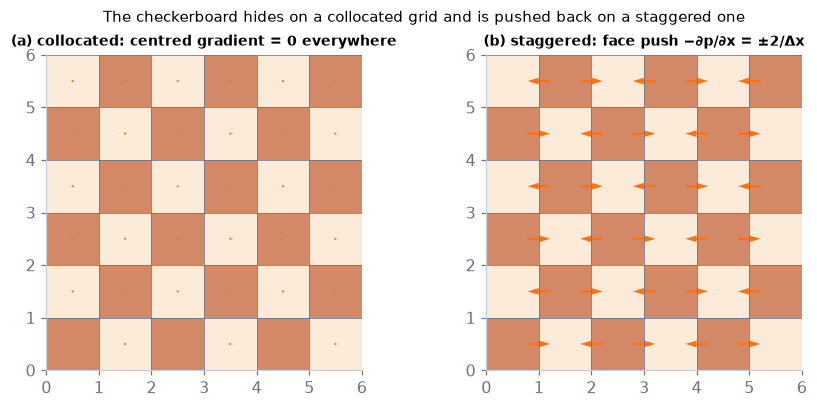

In [119]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.6))   # the figure and its panels
pc6 = ch10.checkerboard(6, 6); xs6 = np.arange(6) + 0.5              # a 6 x 6 zigzag pressure; cell centres
for ax in (a1, a2):   # repeat the indented lines for each item listed
    ax.imshow(pc6, cmap="Oranges", origin="lower", extent=(0, 6, 0, 6), alpha=0.6, vmin=-1.5, vmax=1.5)   # the zigzag pressure
    ax.set_aspect("equal"); ax.set_xticks(range(7)); ax.set_yticks(range(7)); ax.grid(True, color=C_EX, lw=0.5)   # axis range / scale chosen so the feature discussed below is visible
gcol = ch10.collocated_gradient(pc6, 1.0, 1.0)[0]                    # zero everywhere
a1.quiver(*np.meshgrid(xs6, xs6), gcol, 0*gcol, color=C_FT, scale=20)   # (no visible arrows: all zero)
a1.set_title("(a) collocated: centred gradient = 0 everywhere", fontsize=9)   # the panel's title: what this panel shows
gst = MAC.gradient(pc6, MAC.MacGrid(6, 6, 6.0, 6.0))[0]              # on the vertical faces x = 0 … 6
XF, YF = np.meshgrid(np.arange(7), xs6)   # sample points
a2.quiver(XF[:, 1:-1], YF[:, 1:-1], -gst[:, 1:-1], 0*gst[:, 1:-1], color=C_FT, scale=28, pivot="middle")   # the push -dp/dx, centred on each interior face
a2.set_title("(b) staggered: face push −∂p/∂x = ±2/Δx", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("The checkerboard hides on a collocated grid and is pushed back on a staggered one", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c12_checkerboard"); plt.show()   # display the figure

**What you see.** Two copies of the same zigzag pressure (dark and light orange cells): the left panel has no arrows at all; the right panel is full of alternating arrows on the faces.

**How to read it.** On the staggered grid the momentum equation pushes back against a zigzag (the arrows point from high to low pressure), so the zigzag cannot grow unchecked.

**What would change if…** …mixed finite elements with equal order (C13): the same blindness appears, cured the same way — give the velocity more freedom.

📝 **Note.** **N71 [B]** **One MAC time step:** predictor (10.119)–(10.120), $u^{n+1/2}_{i+1/2,j}=u^n_{i+1/2,j}-\Delta t\Big(uu_x+vu_y-\tfrac1{Re}\nabla^2u\Big)^n_{i+1/2,j}+\Delta t\,(g_x)^{n+1}_{i+1/2,j},\ v^{n+1/2}_{i,j+1/2}=v^n_{i,j+1/2}-\Delta t\Big(uv_x+vv_y-\tfrac1{Re}\nabla^2v\Big)^n_{i,j+1/2}+\Delta t\,(g_y)^{n+1}_{i,j+1/2}$ → Poisson (10.124), $\nabla^2_dp^{n+1}_{i,j}\equiv\tfrac{p^{n+1}_{i+1,j}-2p^{n+1}_{i,j}+p^{n+1}_{i-1,j}}{\Delta x^2}+\tfrac{p^{n+1}_{i,j+1}-2p^{n+1}_{i,j}+p^{n+1}_{i,j-1}}{\Delta y^2}=\tfrac1{\Delta t}\Big(\tfrac{u^{n+1/2}_{i+1/2,j}-u^{n+1/2}_{i-1/2,j}}{\Delta x}+\tfrac{v^{n+1/2}_{i,j+1/2}-v^{n+1/2}_{i,j-1/2}}{\Delta y}\Big)$ → correction (10.121)–(10.122), $u^{n+1}_{i+1/2,j}=u^{n+1/2}_{i+1/2,j}-\tfrac{\Delta t}{\Delta x}(p^{n+1}_{i+1,j}-p^{n+1}_{i,j}),\ v^{n+1}_{i,j+1/2}=v^{n+1/2}_{i,j+1/2}-\tfrac{\Delta t}{\Delta y}(p^{n+1}_{i,j+1}-p^{n+1}_{i,j})$. The Poisson solve is traditionally the costliest step;
the cell times the three stages on a cavity grid (with a factorised matrix, see P244):
```
u^n ──predictor──► u^{n+½} ──∇_d·, ÷Δt──► rhs ──Poisson (splu)──► p ──correction──► u^{n+1}
```

In [120]:
nT = 64 if not FAST else 32                                          # cells per side
gT = MAC.MacGrid(nT, nT, 1.0, 1.0, (False, False), dict(top=1.0, bottom=0.0, left=0.0, right=0.0))   # a cavity grid (lid at the top)
dtT = 0.8*MAC.dt_limit(1.0, 0.0, 100.0, 1/nT, safety=1.0)            # (10.127)-(10.128) with a safety factor 0.8
sT = MAC.new_state(gT); t_pred = t_pois = t_corr = 0.0                # start from rest; three stopwatches [s]
MAC.solve_pressure(np.zeros((nT, nT)), gT)                           # factorise the matrix once (not timed)
for _ in range(50):                                                  # 50 time steps
    t0 = time.perf_counter(); us_, vs_ = MAC.predictor(sT["u"], sT["v"], gT, 100.0, dtT); t1 = time.perf_counter()
    p_ = MAC.solve_pressure(MAC.divergence(us_, vs_, gT)/dtT, gT); t2 = time.perf_counter()
    sT["u"], sT["v"] = MAC.correct(us_, vs_, p_, gT, dtT); t3 = time.perf_counter()
    t_pred += t1 - t0; t_pois += t2 - t1; t_corr += t3 - t2
tot = t_pred + t_pois + t_corr
print(f"{nT}^2 cavity, 50 steps: predictor {100*t_pred/tot:.0f} %, Poisson {100*t_pois/tot:.0f} %, correction {100*t_corr/tot:.0f} % of {tot:.2f} s")   # show the numbers computed above
u1, v1 = MAC.correct(us_, vs_, p_, gT, dtT); u2, v2 = MAC.correct(us_, vs_, p_ + 7.0, gT, dtT)   # N41: p and p + 7
print("p + 7 gives the same velocity:", np.allclose(u1, u2) and np.allclose(v1, v2))   # show the numbers computed above

64^2 cavity, 50 steps: predictor 33 %, Poisson 61 %, correction 6 % of 0.06 s
p + 7 gives the same velocity: True


**What does the code above do?**

1. `time.perf_counter()` is a wall-clock stopwatch in seconds; each of the three stages is timed over 50 steps of a lid-driven cavity.
2. With the Poisson matrix factorised once, each pressure solve is only a forward/back substitution; the cell prints the measured shares (they depend on the
   machine and the grid — on larger grids the Poisson solve's share grows).
3. The last line is N41's point: only differences of $p$ enter the correction, so $p+7$ gives the same velocity.

📝 **Note.** **N73 [B]** **MAC stability limits (Peyret & Taylor, $\Delta x=\Delta y$) (10.127)–(10.128):** $\frac12(u^2+v^2)\Delta t\,Re\le1$ *(10.127)* and $\frac{4\Delta t}{Re\,\Delta x^2}\le1$
*(10.128)* — the first is convection's, the second diffusion's (the 2-D version of $\beta\le\frac14$). Stated, not derived (★★★): checked here by a 2-D von Neumann scan of
the explicit convection–diffusion step, at 0.95 and 1.05 times the limit.

In [121]:
for n_ in (32, 64):                                                  # two cavity grids at Re = 100
    print(f"dx = 1/{n_}: dt limit = {MAC.dt_limit(1.0, 0.0, 100.0, 1/n_, safety=1.0):.6f}")   # the smaller of (10.127) and (10.128)
dtl = MAC.dt_limit(1.0, 0.0, 100.0, 1/32, safety=1.0)
for f_ in (0.95, 1.05):                                              # just inside and just outside the limit
    print(f"{f_} x limit: max |G| of the 2-D explicit step = {FD.ftcs2d_max_amplification(1.0, 0.0, 100.0, 1/32, f_*dtl):.5f}")   # show the numbers computed above

dx = 1/32: dt limit = 0.020000
dx = 1/64: dt limit = 0.006104
0.95 x limit: max |G| of the 2-D explicit step = 1.00000
1.05 x limit: max |G| of the 2-D explicit step = 1.00087


**What does the code above do?**

1. At $Re=100$ with $\lvert\mathbf u\rvert\le1$: $\Delta x=1/32$ gives $\Delta t\le0.02$ (from (10.127)–(10.128), $\tfrac12(u^2+v^2)\,\Delta t\,Re\le1,\ \dfrac{4\Delta t}{Re\,\Delta x^2}\le1$); $\Delta x=1/64$ gives $0.0061$ — the diffusion limit, which
   shrinks like $\Delta x^2$.
2. The 2-D von Neumann scan of the predictor's explicit step finds $\max\lvert G\rvert=1$ just inside the limit and slightly above 1 just outside it.

In [122]:
ns_tg = (16, 32, 64) if not FAST else (16, 32)                        # verification: the decaying Taylor-Green vortex (exact solution)
errs_tg = [MAC.taylor_green(n_, 100.0, 0.5)["err_u"] for n_ in ns_tg]
print("Taylor-Green max velocity errors:", [f"{e_:.2e}" for e_ in errs_tg], " observed order:", round(observed_order([1/n_ for n_ in ns_tg], errs_tg), 2))   # show the numbers computed above
cp = MAC.channel_poiseuille(16, 16, 10.0, -1.0)                       # plane Poiseuille flow in a channel
print(f"Poiseuille: max error {cp['max_err']:.1e} (the three-point Laplacian is exact for a parabola)")   # show the numbers computed above

Taylor-Green max velocity errors: ['1.24e-04', '3.11e-05', '7.45e-06']  observed order: 2.03


Poiseuille: max error 1.9e-13 (the three-point Laplacian is exact for a parabola)


**What does the code above do?**

1. `taylor_green(n, Re, t_end)` runs the MAC scheme on a periodic box from the exact Taylor–Green vortex and compares with the exact decaying solution at
   $t=0.5$: the error falls by about 4 per halving of $\Delta x$ — second order.
2. `channel_poiseuille` marches the channel flow to its steady state: exact to round-off.

#### 🎮 Interactive: What is the pressure doing in incompressible flow?

**Why interactive rather than a static figure:** Stepping the transport through predictor → Poisson → correction shows the divergence appear and vanish to $10^{-15}$ on the same small grid; the collocated/staggered switch makes the checkerboard's invisibility visible; clicking a cell adds up its four face fluxes.

**What to try:**
- Step through the four stages and watch the rose divergence blotches vanish at stage 4.
- Click the cell next to a wall before and after the projection: which face never changes?
- Switch to the checkerboard mode: count the arrows on the collocated side.

In [123]:
show_viz("ch10", "mac_projection_staggered")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/mac_projection_staggered]

**Climate hook.** The MAC staggering is the **Arakawa C-grid**: $u$ and $v$ on the faces, the sea-surface height (or pressure, or layer thickness) at the centres —
used by NEMO, MOM, MITgcm and many atmosphere cores; Ch. 13's Kelvin and Rossby waves are computed on exactly this layout. The projection is the pressure solve of
every Boussinesq ocean model (Ch. 4's Boussinesq approximation).

**What would change if…** …we used finite elements for the same problem? The zigzag has an FE twin — spurious pressure modes — and the cure is again to give the velocity more freedom
than the pressure. C13.

> 🔁 **Recap — R10 · The rate-of-strain tensor** (Ch. 3 §3.4). $\mathbf D[\mathbf u]=\frac12[\nabla\mathbf u+(\nabla\mathbf u)^T]$ *(10.136)* is the symmetric part of the velocity gradient of Ch. 3 ($S_{ij}$, `core.kinematics`); D22 uses its symmetry.

### 🧩 Mixed finite elements and the LBB (inf–sup) condition `C13`

*The question:* Why can't velocity and pressure be built from the same simple elements?

*In one line:* $\begin{pmatrix}\mathbf M\dot{\mathbf u}\\ \mathbf 0\end{pmatrix}+\begin{pmatrix}\mathbf A&\mathbf B\\ \mathbf B^T&\mathbf 0\end{pmatrix}\begin{pmatrix}\mathbf u\\ \mathbf p\end{pmatrix}=\begin{pmatrix}\mathbf f_u\\ \mathbf f_p\end{pmatrix}$ *(10.137)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **eigenvalues and eigenvectors** — A x = λ x: directions a matrix only stretches (Ch. 2 P80).

#### The problem in plain words

Build a finite-element Navier–Stokes solver with the same straight-sided tents for velocity and pressure — the obvious first try. The velocity looks fine, but the
pressure comes out as noise: a mottled pattern that changes wildly from node to node. The reason is counting. Every pressure unknown adds one continuity constraint;
if the velocity space is not rich enough to satisfy all of them, some pressure patterns are left that the discrete divergence simply cannot see — the FE version of
the checkerboard. Give the velocity quadratic elements (six nodes per triangle) and the pressure linear ones (three), and the noise disappears.

#### The idea

```
  ●             P2–P1 (Taylor–Hood): velocity at 6 nodes (● vertices, ○ mid-edges), pressure at 3 (●)
 ○ ○            iso-P2/P1: split the triangle into 4, linear velocity on the small ones, pressure on the big one
●──○──●
```

| mesh ($n\times n$ squares, all walls) | velocity unknowns, P1 | pressure unknowns (one pinned) | velocity unknowns, P2 |
|---|---|---|---|
| $n=2$ | 2 | 8 | 18 |
| $n=4$ | 18 | 24 | 98 |

When pressure unknowns outnumber velocity unknowns, some pressure modes are certainly invisible. (Each interior velocity node carries two unknowns, $u$ and $v$; the code cell below recomputes the counts — it lists the pressure unknowns before pinning, one more than the table.)

📝 **Note.** **N75 [B]** **The weak Navier–Stokes equations (10.134)–(10.135):** $\int_\Omega\Big(\frac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u-\mathbf g\Big)\cdot\tilde{\mathbf u}\,d\Omega+
\frac2{Re}\int_\Omega\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}]\,d\Omega-\int_\Omega p\,(\nabla\cdot\tilde{\mathbf u})\,d\Omega=0$ *(10.134)* and
$\int_\Omega\tilde p\,\nabla\cdot\mathbf u\,d\Omega=0$ *(10.135)*, with velocity and pressure variations $\tilde{\mathbf u}$, $\tilde p$ — C06's recipe in 2-D.

> 🔁 **Reminder:** the divergence theorem $\int_V\nabla\cdot\mathbf F\,dV=\oint\mathbf F\cdot\mathbf n\,dA$ (Ch. 2) and the double dot product $\mathbf A:\mathbf B=A_{ij}B_{ij}$ (Ch. 2).

#### 🧮 Derivation — The weak Navier–Stokes equations `D22` (Eq. 10.134: $\int_\Omega\Big(\tfrac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u-\mathbf g\Big)\cdot\tilde{\mathbf u}\,d\Omega+\tfrac{2}{Re}\int_\Omega\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}]\,d\Omega-\int_\Omega p\,(\nabla\cdot\tilde{\mathbf u})\,d\Omega=0$)

**What we want to show.** Apply C06's recipe to the Navier–Stokes equations and obtain the form in which velocity and pressure appear in mixed finite elements.

**Assumptions.** ũ = 0 on the boundary where u is prescribed (steps 3, 7); ∇·u = 0 (step 5); Newtonian, constant Re.

**The plan.**

1. Dot with a velocity test function and integrate.
2. Move one derivative off the pressure and off the viscous term (divergence theorem).
3. Use ∇·u = 0 and the symmetry of D.
4. Test continuity with a pressure test function.

**Tools we use** (each explained before this point): Product rule for a divergence (Ch. 4 P113) · the divergence theorem (Ch. 2 §2.12) · the double dot product (Ch. 2) · the strain-rate tensor (R10) · D09's moves.

**We start from**

$$ \frac{\partial\mathbf u}{\partial t}+(\mathbf u\cdot\nabla)\mathbf u=\mathbf g-\nabla p+\frac1{Re}\nabla^2\mathbf u\ \text{(10.81) and}\ \nabla\cdot\mathbf u=0\ \text{(10.80)} $$

*In words:* dimensionless momentum and mass.

---

**Step 1 of 11 — Dot with ũ and integrate.**

$$ \int_\Omega\Big(\frac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u-\mathbf g\Big)\cdot\tilde{\mathbf u}\,d\Omega=\int_\Omega \Big(-\nabla p+\frac1{Re}\nabla^2\mathbf u\Big)\cdot\tilde{\mathbf u}\,d\Omega $$

- *Why we can do this:* As in D09 steps 1–2, with a vector test function (the velocity variation ũ).
- *In words:* the momentum equation, weighted and averaged.

---

**Step 2 of 11 — Product rule on the pressure term.**

$$ \nabla p\cdot\tilde{\mathbf u}=\nabla\cdot(p\tilde{\mathbf u})-p\,\nabla\cdot\tilde{\mathbf u} $$

- *Why we can do this:* P113: ∇·(pũ) = ∇p·ũ + p∇·ũ.
- *In words:* trade the pressure gradient for a divergence.

---

**Step 3 of 11 — Integrate; the surface term vanishes.**

$$ -\int_\Omega\nabla p\cdot\tilde{\mathbf u}\,d\Omega=-\oint p\,\tilde{\mathbf u}\cdot\mathbf n\,dA+\int_\Omega p\,\nabla\cdot \tilde{\mathbf u}\,d\Omega=\int_\Omega p\,\nabla\cdot\tilde{\mathbf u}\,d\Omega $$

- *Why we can do this:* Divergence theorem; ũ = 0 where velocity is prescribed (elsewhere the term is part of a natural traction condition).
- *In words:* the pressure now multiplies the divergence of the test function.

---

**Step 4 of 11 — Rewrite the Laplacian.**

$$ \nabla\cdot\big(\nabla\mathbf u+(\nabla\mathbf u)^T\big)=\nabla^2\mathbf u+\nabla(\nabla\cdot\mathbf u) $$

- *Why we can do this:* In components $\partial_j(\partial_ju_i+\partial_iu_j)=\partial_j\partial_ju_i+\partial_i\partial_ju_j$, swapping derivatives (Schwarz).
- *In words:* the Laplacian plus a gradient of the divergence.

---

**Step 5 of 11 — Use ∇·u = 0.**

$$ \frac1{Re}\nabla^2\mathbf u=\frac2{Re}\nabla\cdot\mathbf D[\mathbf u],\qquad\mathbf D[\mathbf u]=\tfrac12\big[\nabla\mathbf u+(\nabla\mathbf u)^T\big]\ \text{(10.136)} $$

- *Why we can do this:* The second term of step 4 vanishes for incompressible flow; the bracket is $2\mathbf D[\mathbf u]$, twice the strain-rate tensor (R10).
- *In words:* viscous force = divergence of twice the strain rate.

---

**Step 6 of 11 — Integrate the viscous term by parts.**

$$ \int_\Omega\frac2{Re}(\nabla\cdot\mathbf D)\cdot\tilde{\mathbf u}\,d\Omega=\frac2{Re}\oint\tilde{\mathbf u}\cdot\mathbf D\cdot\mathbf n\,dA -\frac2{Re}\int_\Omega\mathbf D:\nabla\tilde{\mathbf u}\,d\Omega $$

- *Why we can do this:* The tensor version of D09 steps 3–5 (product rule + divergence theorem).
- *In words:* one derivative moved from u to ũ.

---

**Step 7 of 11 — Drop the surface term.**

$$ \frac2{Re}\oint\tilde{\mathbf u}\cdot\mathbf D\cdot\mathbf n\,dA=0 $$

- *Why we can do this:* ũ = 0 on the Dirichlet parts of the boundary; elsewhere it would be a traction condition (natural, as in D10).
- *In words:* no boundary contribution where velocity is given.

---

**Step 8 of 11 — Use the symmetry of D.**

$$ \mathbf D[\mathbf u]:\nabla\tilde{\mathbf u}=\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}] $$

- *Why we can do this:* A symmetric tensor contracted with any tensor sees only that tensor's symmetric part; the antisymmetric (rotation) part of ∇ũ gives zero.
- *In words:* only the strain of the test function matters.

---

**Step 9 of 11 — Collect the momentum statement.**

$$ \begin{array}{l}\int_\Omega\Big(\frac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u-\mathbf g\Big)\cdot\tilde{\mathbf u}\,d\Omega+ \frac2{Re}\int_\Omega\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}]\,d\Omega-\int_\Omega p\,(\nabla\cdot\tilde{\mathbf u})\,d\Omega=0 \\ \text{(10.134)}\end{array} $$

- *Why we can do this:* Steps 3, 6–8 in step 1, all terms moved left (signs flip).
- *In words:* the weak momentum equation.

---

**Step 10 of 11 — Test continuity with p̃.**

$$ \int_\Omega\tilde p\,\nabla\cdot\mathbf u\,d\Omega=0\ \text{(10.135)} $$

- *Why we can do this:* Multiply ∇·u = 0 by any pressure test function and integrate — no derivative to move.
- *In words:* the weak continuity equation.

---

**Step 11 of 11 — Notice the shared pairing.**

$$ b(\mathbf v,q)=-\int_\Omega q\,\nabla\cdot\mathbf v\,d\Omega\ \ \text{appears as}\ b(\tilde{\mathbf u},p)\ \text{and}\ b(\mathbf u,\tilde p) $$

- *Why we can do this:* The same bilinear form couples pressure to velocity in (10.134), $\int_\Omega\Big(\tfrac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u-\mathbf g\Big)\cdot\tilde{\mathbf u}\,d\Omega+\tfrac{2}{Re}\int_\Omega\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}]\,d\Omega-\int_\Omega p\,(\nabla\cdot\tilde{\mathbf u})\,d\Omega=0$ and velocity to pressure in (10.135), $\int_\Omega\tilde p\,\nabla\cdot\mathbf u\,d\Omega=0$ (with the sign chosen as in (10.159), $-\int_\Omega(u_x+v_y)\tilde p\,d\Omega=0$); discretised, it gives B and Bᵀ in the saddle-point system (10.137), $\begin{pmatrix}\mathbf M\dot{\mathbf u}\\ \mathbf 0\end{pmatrix}+\begin{pmatrix}\mathbf A&\mathbf B\\ \mathbf B^T&\mathbf 0\end{pmatrix}\begin{pmatrix}\mathbf u\\ \mathbf p\end{pmatrix}=\begin{pmatrix}\mathbf f_u\\ \mathbf f_p\end{pmatrix}$.
- *In words:* pressure is the multiplier of continuity.

---

**Result**

$$ \int_\Omega\Big(\tfrac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u-\mathbf g\Big)\cdot\tilde{\mathbf u}\,d\Omega+\tfrac{2}{Re}\int_\Omega\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}]\,d\Omega-\int_\Omega p\,(\nabla\cdot\tilde{\mathbf u})\,d\Omega=0\ \text{(10.134)},\qquad \int_\Omega\tilde p\,\nabla\cdot\mathbf u\,d\Omega=0\ \text{(10.135)} $$

*In words:* in weak form, viscosity acts through strain rates, the pressure multiplies the divergence of the test velocity, and continuity is tested by pressure functions — the structure of (10.137), $\begin{pmatrix}\mathbf M\dot{\mathbf u}\\ \mathbf 0\end{pmatrix}+\begin{pmatrix}\mathbf A&\mathbf B\\ \mathbf B^T&\mathbf 0\end{pmatrix}\begin{pmatrix}\mathbf u\\ \mathbf p\end{pmatrix}=\begin{pmatrix}\mathbf f_u\\ \mathbf f_p\end{pmatrix}$.

**What it means.** The pressure's role as a Lagrange multiplier (P239) is now explicit; whether the discrete B can 'see' every pressure is the LBB question of C13.

**Check it.** Units (dimensionless): every integrand ~ U²/L × U over the domain ✓. `ch10.weak_ns_identity_sympy()` verifies the identity of step 4–8 for polynomial fields vanishing on the boundary; the Cartesian expansion gives (10.156)–(10.159), $\int_\Omega(\mathbf u_t+u\mathbf u_x+v\mathbf u_y)\cdot\tilde{\mathbf u}\,d\Omega+\tfrac2{Re}\int_\Omega\Big[u_x\tilde u_x+\tfrac12(u_y+v_x)(\tilde u_y+\tilde v_x)+v_y\tilde v_y\Big]d\Omega-\int_\Omega p(\tilde u_x+\tilde v_y)\,d\Omega=0,\ \int_\Omega(u_t+uu_x+vu_y)\tilde u\,d\Omega-\int_\Omega p\tilde u_x\,d\Omega+\tfrac1{Re}\int_\Omega[2u_x\tilde u_x+(u_y+v_x)\tilde u_y]\,d\Omega=0,\ \int_\Omega(v_t+uv_x+vv_y)\tilde v\,d\Omega-\int_\Omega p\tilde v_y\,d\Omega+\tfrac1{Re}\int_\Omega[(u_y+v_x)\tilde v_x+2v_y\tilde v_y]\,d\Omega=0,\ -\int_\Omega(u_x+v_y)\tilde p\,d\Omega=0$ (`weak_ns_components_sympy`).

> ⚠️ **Common confusion (traps in `D22`):** The sign of the pressure term; dropping ∇(∇·u) without saying ∇·u = 0 (the form changes for compressible flow); writing D : ∇ũ = D : ∇ũᵀ without the symmetry argument.

In [124]:
print("viscous and pressure identities of D22 on polynomial fields:", ch10.weak_ns_identity_sympy())   # residuals 0

viscous and pressure identities of D22 on polynomial fields: {'viscous': 0, 'pressure': 0, 'residual': 0}


**What does the code above do?**

`weak_ns_identity_sympy()` checks D22 on the unit square with a divergence-free polynomial velocity and a test velocity that vanishes on the boundary:
$\int\frac1{Re}\nabla^2\mathbf u\cdot\tilde{\mathbf u}=-\frac2{Re}\int\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}]$ and $\int(-\nabla p)\cdot\tilde{\mathbf u}=\int p\,\nabla\cdot\tilde{\mathbf u}$ — both residuals 0.

> 📎 **Primer — saddle-point (KKT) matrix.** `P246` · A block matrix $\begin{pmatrix}\mathbf A&\mathbf B\\\mathbf B^T&\mathbf 0\end{pmatrix}$ — the shape of every "minimise subject to a constraint" problem (the Lagrange multiplier of P239 is the second
block). It has positive and negative eigenvalues (indefinite), a zero block on the diagonal, and is invertible only if $\mathbf B$ has full column rank — no multiplier
pattern may be invisible to the constraint. In code, `np.block([[A, B], [B.T, Z]])` glues sub-matrices into one big matrix (rows of blocks, like writing the
matrix on paper), and `np.linalg.eigvalsh(K)` returns the eigenvalues of a symmetric matrix in ascending order (real numbers, because $K=K^T$).

In [125]:
import numpy as np   # arrays and maths
A = np.eye(2); B = np.array([[1.], [1.]])                      # 2 velocities, 1 pressure
K = np.block([[A, B], [B.T, np.zeros((1, 1))]])                # the 3 x 3 saddle-point matrix, assembled from its four blocks
print(np.linalg.eigvalsh(K))                                   # [-1, 1, 2]: one negative eigenvalue
B2 = np.array([[1., 1.], [1., 1.]])                             # 2 pressures that the constraint cannot tell apart
print(np.linalg.matrix_rank(np.block([[A, B2], [B2.T, np.zeros((2, 2))]])))   # 3 < 4: singular

[-1.  1.  2.]
3


> 📎 **Primer — GMRES in one line.** `P250` · For large nonsymmetric systems (like the Newton steps of the cylinder problem) direct elimination is too costly; GMRES (Saad) builds the best approximation in the
growing space spanned by $b, Ab, A^2b,\dots$ and stops when the residual is small. `scipy.sparse.linalg.gmres(A, b)` returns `(x, info)`; `info = 0` means converged.

In [126]:
import numpy as np, scipy.sparse as sp   # arrays and maths
from scipy.sparse.linalg import gmres   # a tool used below
A = sp.diags([-1, 2.5, -1.2], [-1, 0, 1], shape=(50, 50)).tocsr()   # nonsymmetric, well conditioned
x, info = gmres(A, np.ones(50))
print(info, np.abs(A @ x - 1).max())                                  # 0 and a small residual

0 3.506653848406316e-05


📝 **Note.** **N76 [B]** **The semi-discrete system:** velocity unknowns $\mathbf u$ and pressure unknowns $\mathbf p$; $\mathbf M$ the mass matrix, $\mathbf A$ depends on $\mathbf u$
(convection), $\mathbf B$ comes from the pressure term of (10.134), $\int_\Omega\Big(\tfrac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u-\mathbf g\Big)\cdot\tilde{\mathbf u}\,d\Omega+\tfrac{2}{Re}\int_\Omega\mathbf D[\mathbf u]:\mathbf D[\tilde{\mathbf u}]\,d\Omega-\int_\Omega p\,(\nabla\cdot\tilde{\mathbf u})\,d\Omega=0$ and $\mathbf B^T$ from (10.135), $\int_\Omega\tilde p\,\nabla\cdot\mathbf u\,d\Omega=0$ — the symmetric arrangement is why the book writes the continuity
statement with the sign it does. Discretised in time and linearised by Newton, each step is a sparse saddle-point solve — direct elimination for small systems,
GMRES for large ones.

$$ \begin{pmatrix}\mathbf M\dot{\mathbf u}\\ \mathbf 0\end{pmatrix}+\begin{pmatrix}\mathbf A&\mathbf B\\ \mathbf B^T&\mathbf 0\end{pmatrix}\begin{pmatrix}\mathbf u\\ \mathbf p\end{pmatrix}=\begin{pmatrix}\mathbf f_u\\ \mathbf f_p\end{pmatrix} \qquad \text{(10.137)} $$

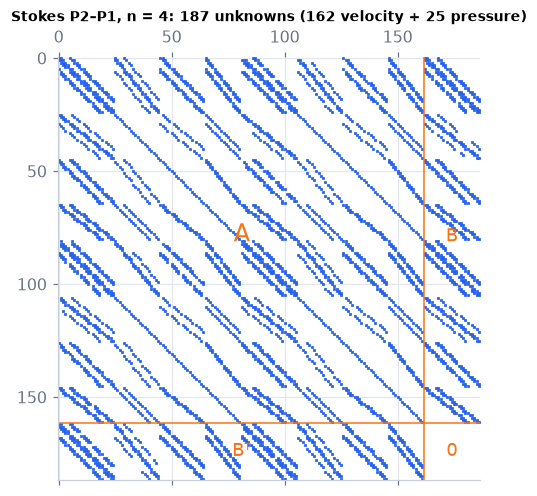

In [127]:
mesh4 = FEM2.structured_square_mesh(4, "P2P1")                        # 4 x 4 squares, P2 velocity, P1 pressure
A4, _ = FEM2.assemble_saddle(mesh4, Re=1.0)                           # the Stokes saddle-point matrix
nvel = 2*mesh4.N                                                      # u and v at every P2 node
fig, ax = plt.subplots(figsize=(4.4, 4.4))   # the figure and its panels
ax.spy(A4, markersize=0.8, color=C_IM)                                # a dot for every nonzero entry
for k_ in (nvel,): ax.axhline(k_ - 0.5, color=C_FT, lw=1); ax.axvline(k_ - 0.5, color=C_FT, lw=1)   # block boundaries
ax.text(nvel/2, nvel/2, "A", color=C_FT, fontsize=16, ha="center"); ax.text(nvel + 12, nvel/2, "B", color=C_FT, fontsize=12, ha="center")   # a label written on the plot
ax.text(nvel/2, nvel + 14, "Bᵀ", color=C_FT, fontsize=12, ha="center"); ax.text(nvel + 12, nvel + 14, "0", color=C_FT, fontsize=12, ha="center")   # a label written on the plot
ax.set_title(f"Stokes P2–P1, n = 4: {A4.shape[0]} unknowns ({nvel} velocity + {mesh4.V} pressure)", fontsize=9)   # the panel's title: what this panel shows
plt.show()   # display the figure

**What you see.** A large square block of scattered dots (A), thin strips to its right and below (B and Bᵀ), and an empty square in the corner.

**How to read it.** The empty corner is the missing 'pressure equation' — continuity contains no $p$; the pressure is fixed only through its coupling to the velocity.

**What would change if…** …GLS stabilisation: a small negative-definite block would appear in the corner, which is how equal-order elements can be rescued.

> 📎 **Primer — generalised symmetric eigenproblem scipy.linalg.eigh(A, B).** `P247` · Solve $\mathbf Ax=\lambda\mathbf Bx$ for symmetric $\mathbf A$ and positive-definite $\mathbf B$: the eigenvalues measure $\mathbf A$ "in units of" $\mathbf B$ (Ch. 2 P80 was the case
$\mathbf B=\mathbf I$). The discrete inf–sup constant is $\beta_h^2=\lambda_{\min}(\mathbf B^T\mathbf A^{-1}\mathbf B,\ \mathbf M_p)$ over pressures with zero mean: how strongly the worst
pressure pattern is felt by the velocity.

In [128]:
import numpy as np   # arrays and maths
from scipy.linalg import eigh   # a tool used below
A = np.array([[2., 0], [0, 1]]); B = np.array([[1., 0], [0, 4]])
print(eigh(A, B, eigvals_only=True))            # [0.25, 2.0]: A measured in units of B

[0.25 2.  ]


**The LBB (inf–sup) condition, in words and one formula.** A pair of spaces is stable if every pressure pattern $q$ can be "felt" by some velocity $\mathbf v$ with a force
that does not vanish on refinement:

$$\inf_q\ \sup_{\mathbf v}\ \frac{\int_\Omega q\,\nabla\cdot\mathbf v\,d\Omega}{\lVert q\rVert\,\lVert\mathbf v\rVert_1}\ \ge\ \beta>0\quad\text{independent of }h$$

(Babuška–Brezzi; the book states it by name). Equal order (P1–P1) fails; P2–P1 (Taylor–Hood, Fig. 10.5a) and iso-P2/P1 (Fig. 10.5b) pass; GLS stabilisation
(Tezduyar; Franca & Frey) keeps equal order by adding least-squares terms — the mixed method needs no tuning parameter, which the book prefers.

> 📎 **Primer — barycentric (area) coordinates on a triangle.** `P248` · Any point of a triangle is a weighted average of its three corners with weights $(\zeta,\xi,\eta)\ge0$ that add to 1 — on the parent triangle $\zeta=1-\xi-\eta$. Each weight
is 1 at "its" corner and 0 on the opposite side, so they are the linear shape functions (10.187), $\psi_1=\zeta,\ \psi_2=\xi,\ \psi_3=\eta$, and products like $4\xi\zeta$ are the quadratic mid-edge ones (10.185), $\phi_1=\zeta(2\zeta-1),\ \phi_2=\xi(2\xi-1),\ \phi_3=\eta(2\eta-1),\ \phi_4=4\xi\zeta,\ \phi_5=4\xi\eta,\ \phi_6=4\eta\zeta$.

In [129]:
xi, eta = 0.2, 0.3                    # a point inside the parent triangle
zeta = 1 - xi - eta                   # 0.5
print(zeta + xi + eta)                # 1.0: a partition of unity
print(4*xi*zeta, 4*xi*eta, 4*eta*zeta)   # mid-edge P2 shapes at this point: 0.4, 0.24, 0.6

1.0
0.4 0.24 0.6


> 📎 **Primer — Jacobian determinant of a 2-D map.** `P249` · A map $(\xi,\eta)\to(x,y)$ stretches a tiny parent square of area $d\xi\,d\eta$ into a parallelogram of area $J\,d\xi\,d\eta$ with $J=x_\xi y_\eta-x_\eta y_\xi$ — the 2-D version
of $dx=(h/2)\,d\xi$ (P234). For a straight-sided triangle $J=2\times$ its area (the parent triangle has area ½); for a curved (isoparametric) one $J$ varies inside.

In [130]:
import numpy as np   # arrays and maths
xe, ye = np.array([0., 2, 0]), np.array([0., 0, 1])     # corners of a triangle with area 1
xxi, xeta = xe[1] - xe[0], xe[2] - xe[0]; yxi, yeta = ye[1] - ye[0], ye[2] - ye[0]
print(xxi*yeta - xeta*yxi)                               # J = 2 = 2 x area

2.0


#### ✏️ Tiny example: counting unknowns on a 2 × 2 mesh

The unit square cut into $2\times2$ squares, each split into two triangles: $V=9$ vertices, $E=16$ edges, $T=8$ triangles ($V-E+T=1$ ✓ — Euler's formula: for any triangulation of a region without holes, vertices minus edges plus
triangles is 1; each hole lowers it by 1, so a mesh around one cylinder has $V-E+T=0$ — a quick check that mesh counts are consistent). All walls have prescribed velocity.
1. P1–P1: velocity nodes = vertices; only the centre vertex is interior ⇒ 1 node, 2 velocity unknowns. Pressure: 9 values, minus 1 pinned ⇒ 8. Eight constraints,
   two unknowns: at least 6 pressure patterns cannot be felt — spurious modes.
2. P2–P1: velocity nodes = vertices + edge midpoints = 25, interior $(2n-1)^2=9$ ⇒ 18 unknowns; pressure still 8.
3. Counting is necessary, not sufficient: at $n=8$ P1–P1 has more velocity than pressure unknowns (the cell prints them), yet spurious modes remain — the inf–sup
   test below decides.

In [131]:
for pair in ("P1P1", "P2P1"):                                         # equal order and Taylor-Hood
    for n_ in ((2, 4, 8) if not FAST else (2, 4)):                    # n x n squares on the unit square
        r_ = FEM2.infsup_constant(n_, pair)                           # generalised eigenvalue problem (P247)
        print(f"{pair}, n = {n_}: velocity unknowns {r_['n_u']:4d}, pressure unknowns {r_['n_p']:3d}, spurious modes {r_['n_spurious']}, "   # show the numbers computed above
              f"beta_h = {r_['beta']:.4f} (smallest nonzero {r_['beta_nonspurious']:.4f})")
b_P2 = [FEM2.infsup_constant(n_, "P2P1")["beta"] for n_ in (2, 8)]; b_P1 = FEM2.infsup_constant(8, "P1P1")["beta"]
assert b_P2[1] > 0.5*b_P2[0] and b_P1 < 0.5*b_P2[1]                  # P2-P1 bounded; P1-P1 collapses
for pair in ("P1P1", "P2P1"):                                         # the Stokes lid-driven cavity with each pair
    s_ = FEM2.stokes_cavity(6, pair)
    print(f"Stokes cavity {pair}, n = 6: pressure range {s_['p_range']:.1f}, amplitude of the (-1)^(i+j) component {s_['p_std_checker']:.2f}")   # show the numbers computed above

P1P1, n = 2: velocity unknowns    2, pressure unknowns   9, spurious modes 6, beta_h = 0.0000 (smallest nonzero 0.4364)
P1P1, n = 4: velocity unknowns   18, pressure unknowns  25, spurious modes 7, beta_h = 0.0000 (smallest nonzero 0.1005)
P1P1, n = 8: velocity unknowns   98, pressure unknowns  81, spurious modes 7, beta_h = 0.0000 (smallest nonzero 0.0717)
P2P1, n = 2: velocity unknowns   18, pressure unknowns   9, spurious modes 0, beta_h = 0.3666 (smallest nonzero 0.3666)
P2P1, n = 4: velocity unknowns   98, pressure unknowns  25, spurious modes 0, beta_h = 0.3677 (smallest nonzero 0.3677)
P2P1, n = 8: velocity unknowns  450, pressure unknowns  81, spurious modes 0, beta_h = 0.3662 (smallest nonzero 0.3662)


Stokes cavity P1P1, n = 6: pressure range 589.3, amplitude of the (-1)^(i+j) component 42.88
Stokes cavity P2P1, n = 6: pressure range 262.8, amplitude of the (-1)^(i+j) component 3.55


**What does the code above do?**

1. `infsup_constant(n, pair)` builds the structured mesh, the velocity stiffness $\mathbf A$, the divergence matrix $\mathbf B$ and the pressure mass matrix, and solves the
   generalised eigenproblem of P247: $\beta_h$ is the square root of the smallest eigenvalue beyond the constant, and `n_spurious` counts pressure patterns with (numerically)
   zero eigenvalue. P1–P1 has spurious modes at every $n$ (so $\beta_h=0$), and even its smallest nonzero value falls with refinement; P2–P1 has none and
   $\beta_h$ stays near the same value.
2. The Stokes cavity: with P1–P1 the pressure has a large alternating (checkerboard-like) component and a huge range; with P2–P1 it is smooth (the corner singularities
   of the lid still make its range large, but the alternating part is small).

In [132]:
# from scratch: the six P2 shape functions (10.185) typed from the formula, and the 7-point rule on the parent triangle
def p2_mine(xi, eta):                                             # (10.185) with zeta = 1 - xi - eta (P248)
    ze = 1 - xi - eta
    return np.array([ze*(2*ze - 1), xi*(2*xi - 1), eta*(2*eta - 1), 4*xi*ze, 4*xi*eta, 4*eta*ze])   # the values for this call
nodes6 = [(0, 0), (1, 0), (0, 1), (0.5, 0), (0.5, 0.5), (0, 0.5)]  # vertices, then mid-edges (1-2, 2-3, 3-1)
Phi = np.array([p2_mine(*nd) for nd in nodes6])                    # phi_a at node b
assert np.allclose(Phi, np.eye(6))                                 # phi_a(node_b) = delta_ab
rng = np.random.default_rng(2); pts = rng.random((20, 2)); pts = pts[pts.sum(1) < 1]   # random points inside the triangle
assert np.allclose([p2_mine(*q).sum() for q in pts], 1.0)          # partition of unity
assert np.allclose([p2_mine(*q) for q in pts], [FEM2.p2_shape(*q) for q in pts])   # same as the library
P7, W7 = FEM2.tri_quad_7pt()                                       # 7 points (xi, eta) and weights (sum 1)
I22 = 0.5*np.sum(W7*P7[:, 0]**2*P7[:, 1]**2)                       # the rule's value of the integral of xi^2 eta^2
I33 = 0.5*np.sum(W7*P7[:, 0]**3*P7[:, 1]**3)                       # ... and of xi^3 eta^3 (degree 6)
print(f"xi^2 eta^2: rule {I22:.12f}, exact 2!2!/6! = {2*2/720:.12f};   xi^3 eta^3: rule {I33:.3e}, exact 3!3!/8! = {36/40320:.3e}")   # show the numbers computed above
assert np.isclose(I22, 1/180) and not np.isclose(I33, 36/40320, rtol=1e-6)   # exact to degree 5, not degree 6

xi^2 eta^2: rule 0.005555555556, exact 2!2!/6! = 0.005555555556;   xi^3 eta^3: rule 9.385e-04, exact 3!3!/8! = 8.929e-04


**What does the code above do?**

1. The six quadratic shape functions are typed from (10.185), $\phi_1=\zeta(2\zeta-1),\ \phi_2=\xi(2\xi-1),\ \phi_3=\eta(2\eta-1),\ \phi_4=4\xi\zeta,\ \phi_5=4\xi\eta,\ \phi_6=4\eta\zeta$; evaluated at the six nodes they give the identity matrix, they add up to 1 at random points, and they
   match `FEM2.p2_shape`.
2. The 7-point rule (10.198), $\int_{\Omega^e}f\,d\Omega=\int_0^1\!\int_0^{1-\eta}f(\xi,\eta)J(\xi,\eta)\,d\xi\,d\eta=\tfrac12\sum_{l=1}^{N_{int}}f(\xi_l,\eta_l)J(\xi_l,\eta_l)W_l,\quad J=x_\xi y_\eta-x_\eta y_\xi$ on the parent triangle (area ½, hence the factor ½) integrates $\xi^2\eta^2$ exactly ($2!\,2!/6!=1/180$) but not the degree-6 monomial
   $\xi^3\eta^3$ — exact up to degree 5, as stated for the rule.

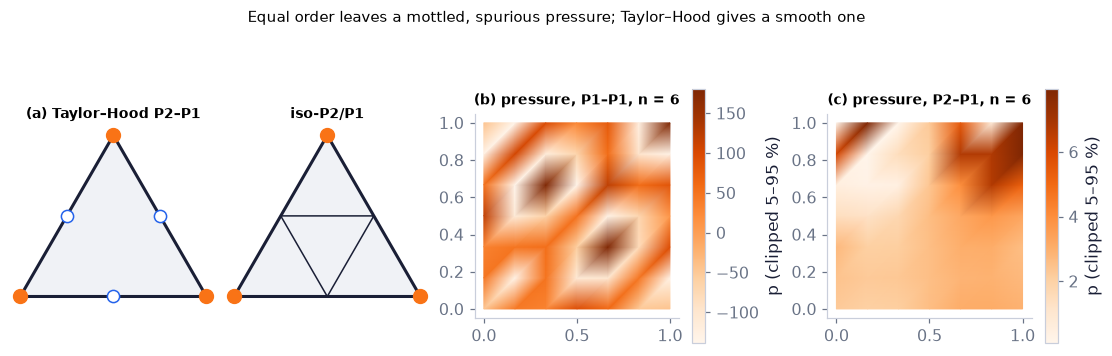

In [133]:
fig = plt.figure(figsize=(10, 3.6))
a1 = fig.add_subplot(1, 4, 1); p2p1_triangle(a1); a1.set_title("(a) Taylor–Hood P2–P1", fontsize=9)   # the panel's title: what this panel shows
a1b = fig.add_subplot(1, 4, 2); p2p1_triangle(a1b, iso=True); a1b.set_title("iso-P2/P1", fontsize=9)   # the panel's title: what this panel shows
for k_, pair in enumerate(("P1P1", "P2P1")):                          # (b) the Stokes cavity pressure for both pairs
    s_ = FEM2.stokes_cavity(6, pair); msh = s_["mesh"]; V_ = msh["vertices"]
    ax = fig.add_subplot(1, 4, 3 + k_)
    tp = ax.tripcolor(V_[:, 0], V_[:, 1], msh.tris, s_["p"], cmap="Oranges", shading="gouraud",
                      vmin=np.percentile(s_["p"], 5), vmax=np.percentile(s_["p"], 95))   # colour each triangle by p; clip the corner singularities
    fig.colorbar(tp, ax=ax, shrink=0.7, label="p (clipped 5–95 %)")                  # the colour scale of this panel
    ax.set_aspect("equal"); ax.set_title(f"({'bc'[k_]}) pressure, {pair.replace('P1P1', 'P1–P1').replace('P2P1', 'P2–P1')}, n = 6", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("Equal order leaves a mottled, spurious pressure; Taylor–Hood gives a smooth one", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c13_lbb"); plt.show()   # display the figure

**What does the code above do?**

`ax.tripcolor(x, y, triangles, values)` colours a triangulated field (one value per vertex, blended across each triangle with `shading="gouraud"`);
its relatives `ax.tricontourf` (filled contours) and `ax.triplot` (the mesh edges) take the same vertex arrays and triangle list — the finite-element counterparts of
`pcolormesh`, `contourf` and a grid plot.

**What you see.** (a) The two stable element types (velocity nodes as dots, pressure nodes as squares); (b) and (c) the computed Stokes-cavity pressure: mottled for P1–P1 (b), smooth for P2–P1 (c).

**How to read it.** The mottled pattern is made of the spurious modes the P1–P1 divergence cannot see; with P2–P1 every pressure pattern is felt, and the pressure is smooth.

**What would change if…** …iso-P2/P1: its pressure would be smooth too, and its inf–sup constant would stay bounded at a slightly lower level.

In [134]:
tab, _ = read_table("infsup_table.csv")                            # our precomputed table (columns pair, n, h, beta, …)
p1 = {k: v[tab["pair"] == 0] for k, v in tab.items()}; p2 = {k: v[tab["pair"] == 1] for k, v in tab.items()}   # pair 0 = P1-P1, 1 = P2-P1
def f7(n_):                                                         # the two curves, and a marker at the current n
    k_ = int(np.argmin(np.abs(p2["n"] - n_)))                          # the table row of this n
    return {"P2–P1: β_h": (p2["n"], p2["beta"]), "P1–P1: smallest nonzero value (β_h itself = 0)": (p1["n"], p1["beta_nonspurious"]),
            "this n": ([p2["n"][k_], p1["n"][k_]], [p2["beta"][k_], p1["beta_nonspurious"][k_]])}
fig = slider_figure(f7, "n", p2["n"], xlabel="squares per side n", ylabel="inf–sup constant", yrange=[0, 0.5],
                    title="Slide n: Taylor–Hood stays flat; equal order has β_h = 0 and even its smallest nonzero value falls",
                    modes={"this n": "markers", "P2–P1: β_h": "lines+markers", "P1–P1: smallest nonzero value (β_h itself = 0)": "lines+markers"})
fig.show()   # display the interactive figure

**What does the code above do?**

The LBB trend without running anything: our table (`reference/ch10/infsup_table.csv`, computed by `FEM2.infsup_table`) for $n$ = 2 … 16. P2–P1 stays flat
near 0.37; P1–P1 has $\beta_h=0$ at every $n$ (spurious modes), and even its smallest nonzero value decreases with refinement.

#### 🎮 Interactive: Why can't velocity and pressure use the same elements?

**Why interactive rather than a static figure:** Switching the element pair and refining the mesh shows the Stokes-cavity pressure change from spurious noise to a smooth field while the inf–sup constant falls or stays flat, and the node view counts unknowns as they grow — the trend with refinement is the whole point.

**What to try:**
- Press 'P1–P1, n = 4': count velocity and pressure unknowns in the status.
- Switch to P2–P1 at the same n: watch the pressure noise disappear.
- Open one element: click a triangle to see its six velocity nodes and three pressure nodes.

In [135]:
show_viz("ch10", "mixed_fe_lbb")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/mixed_fe_lbb]

**Where C13 goes next.** §10.5's third example — flow past a cylinder in a channel — is computed with exactly these P2–P1 elements, curved to fit the cylinder, and Newton's
method for the nonlinear term: "C13 (continued)" below.

**What would change if…** …we now wanted evidence that any of these solvers is right? §10.5 answers with a benchmark (C14) and a grid-convergence study (C15).

---

## 10.5 Three Examples

**What is this section about?** Three computations put the methods to work: a square cavity whose lid slides (the most-used benchmark in CFD), a square block in a
channel (drag, lift, shedding — and the question every simulation must answer: does the answer change if the grid is refined?), and a cylinder in a channel
computed with the mixed finite elements of C13. We reproduce the first with our own solvers against published data, study grid convergence on the first two, and
show the third from our own (smaller, cached) runs. All numbers here are ours; the book's own values are kept aside for private tests.

### 🧩 The lid-driven cavity benchmark `C14`

*The question:* How can we tell whether a flow solver solves the equations we meant — before trusting it on a problem nobody has solved? (The benchmark: $u(0.5,y)$ against Ghia, Ghia & Shin (1982), and the primary-eddy centre.)

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **np.interp** — `np.interp(x_new, x, y)` reads a sampled curve between its samples (Ch. 7 P182).
- **plt.contour, plt.quiver, plt.streamplot** — contours of a scalar field, arrows of a vector field, streamlines (Ch. 2 P78).

📝 **Note.** **N77 [C]** **The three examples** of §10.5: cavity and block computed with explicit MacCormack on weakly compressible Navier–Stokes (C10), the cylinder with
mixed finite elements (C13). We add the MAC projection solver (C11–C12) for the cavity.

#### The problem in plain words

Fill a square box with a viscous liquid and drag the lid sideways at constant speed. The liquid starts to turn: one big eddy fills the box, with small counter-rotating
eddies tucked into the bottom corners. The flow is simple to set up (no inflow, no outflow, one number $Re$), yet has no formula — so dozens of groups have computed it
on very fine grids and published their numbers. If your code reproduces those numbers, you have **evidence** (not proof) that it solves the Navier–Stokes equations you
meant.

#### The idea

```
 lid u = 1 ────────────►
┌───────────────────────┐      the lid drags the top layer; continuity turns it down the right wall,
│      ↺ primary eddy   │      back along the floor and up the left wall: one big eddy
│  (centre up and to the │      corner eddies ↻ in the bottom corners (much weaker)
│   right of the middle) │      benchmark: u(x = ½, y) on the vertical centreline + the eddy centre
│↻                     ↻│
└───────────────────────┘
```

> 📎 **Primer — verification versus validation.** `P253` · *Verification*: are we solving the equations right? (code bugs, grid and time-step errors — checked against exact solutions, manufactured solutions and other accurate
numerical solutions such as Ghia's). *Validation*: are we solving the right equations? (checked against experiments). A benchmark computation like the cavity is
verification; Ch. 12's comparisons with turbulence measurements are validation.

In [136]:
checks = {'exact solution (Poiseuille, Taylor-Green)': 'verification', 'Ghia et al. 1982 cavity data': 'verification',
          'wind-tunnel drag of a real cylinder': 'validation'}
for k, v in checks.items(): print(f'{v:12s} <- {k}')   # repeat the indented lines for each item listed

verification <- exact solution (Poiseuille, Taylor-Green)
verification <- Ghia et al. 1982 cavity data
validation   <- wind-tunnel drag of a real cylinder


📝 **Note.** **N78 [B]** **Set-up and scales (Fig. 10.6 analogue):** a square of side $L$ (the book calls it $D$), lid speed $U$; lengths in $L$, velocities in $U$, time in $L/U$,
density in $\rho_0$, pressure in $\rho_0U^2$; for the weakly compressible solver the dimensionless pressure is $p=\rho/Ma^2$ with $Ma=U/c$, and $Re=\rho_0UL/\mu$. The
two top corners are singular (the lid velocity jumps from 1 to 0) — the grid smooths the jump; results near the corners converge slowly.

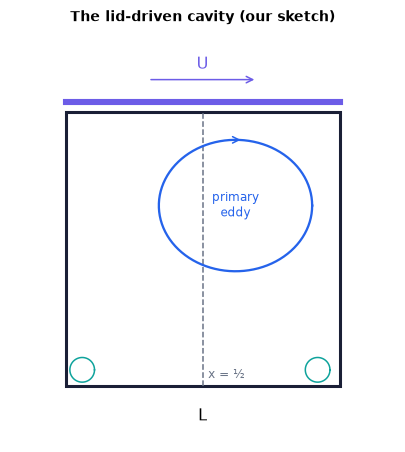

In [137]:
fig, ax = plt.subplots(figsize=(4.2, 4.0))   # the figure and its panels
cavity_sketch(ax)                                                     # our drawing: lid arrow, walls, centreline x = 1/2, eddy cartoon
ax.set_title("The lid-driven cavity (our sketch)", fontsize=9)   # the panel's title: what this panel shows
plt.show()   # display the figure

**What you see.** A square box, an arrow on the lid, the dashed vertical centreline $x=\frac12$ and a sketch of the primary eddy with two small corner eddies.

**How to read it.** The lid is the only forcing; the centreline passes just left of the primary eddy's core (its centre sits at x ≈ 0.62), cutting through the eddy — the line on which the benchmark reports $u$.

**What would change if…** …a deep cavity (height 2): a second eddy would stack below the first.

📝 **Note.** **N79 [B], N80 [B], N81 [B], N82 [B], N83 [B], N84 [B]** **Density on the walls from continuity** — the weakly compressible solver needs $\rho$ on the walls, and
continuity supplies it. On the left wall $v=0$ along the wall, so $\frac{\partial\rho}{\partial t}+\frac{\partial(\rho u)}{\partial x}=0$ *(10.138)*; $\partial(\rho u)/\partial x$ is taken
one-sided and second order, $\big(\frac{\partial f}{\partial x}\big)_i=\frac1{2\Delta x}(-f_{i+2}+4f_{i+1}-3f_i)+O(\Delta x^2)$ (N80, weights $(-\frac32,2,-\frac12)$ by C01's
`FD.fd_weights([0, 1, 2], 1)`), giving the predictor $\rho^*_{i,j}=\rho^n_{i,j}-\frac{\Delta t}{2\Delta x}[-(\rho u)^n_{i+2,j}+4(\rho u)^n_{i+1,j}-3(\rho u)^n_{i,j}]$ *(10.139)* and
the corrector *(10.140)*, $2\rho^{n+1}_{i,j}=\rho^n_{i,j}+\rho^*_{i,j}-\tfrac{\Delta t}{2\Delta x}\big[-(\rho u)^*_{i+2,j}+4(\rho u)^*_{i+1,j}-3(\rho u)^*_{i,j}\big]$. The right wall *(10.141)–(10.142)*, $\rho^*_{i,j}=\rho^n_{i,j}+\tfrac{\Delta t}{2\Delta x}\big[-(\rho u)^n_{i-2,j}+4(\rho u)^n_{i-1,j}-3(\rho u)^n_{i,j}\big],\ 2\rho^{n+1}_{i,j}=\rho^n_{i,j}+\rho^*_{i,j}+\tfrac{\Delta t}{2\Delta x}\big[-(\rho u)^*_{i-2,j}+4(\rho u)^*_{i-1,j}-3(\rho u)^*_{i,j}\big]$ mirrors it (backward stencil, sign flip); the bottom *(10.143)–(10.144)*, $\rho^*_{i,j}=\rho^n_{i,j}-\tfrac{\Delta t}{2\Delta y}\big[-(\rho v)^n_{i,j+2}+4(\rho v)^n_{i,j+1}-3(\rho v)^n_{i,j}\big],\ 2\rho^{n+1}_{i,j}=\rho^n_{i,j}+\rho^*_{i,j}-\tfrac{\Delta t}{2\Delta y}\big[-(\rho v)^*_{i,j+2}+4(\rho v)^*_{i,j+1}-3(\rho v)^*_{i,j}\big]$ is the $y$-version; on the lid
$u=U$, so $\frac{\partial(\rho u)}{\partial x}=U\frac{\partial\rho}{\partial x}$, taken centred *(10.145)–(10.146)*, $\rho^*_{i,j}=\rho^n_{i,j}-\tfrac{\Delta t\,U}{2\Delta x}\big[\rho^n_{i+1,j}-\rho^n_{i-1,j}\big]+\tfrac{\Delta t}{2\Delta y}\big[-(\rho v)^n_{i,j-2}+4(\rho v)^n_{i,j-1}-3(\rho v)^n_{i,j}\big],\ 2\rho^{n+1}_{i,j}=\rho^n_{i,j}+\rho^*_{i,j}-\tfrac{\Delta t\,U}{2\Delta x}\big[\rho^*_{i+1,j}-\rho^*_{i-1,j}\big]+\tfrac{\Delta t}{2\Delta y}\big[-(\rho v)^*_{i,j-2}+4(\rho v)^*_{i,j-1}-3(\rho v)^*_{i,j}\big]$.

> ⚠️ **Our deviation — the two top corners.** Where the lid meets a side wall the velocity jumps from $U$ to 0, and applying the side-wall update
> $\rho^*_{i,j}=\rho^n_{i,j}-\frac{\Delta t}{2\Delta x}[-(\rho u)^n_{i+2,j}+4(\rho u)^n_{i+1,j}-3(\rho u)^n_{i,j}]$ (10.139) there makes our run blow up; our solver instead
> extrapolates the corner density linearly from the two wall points below it (`corner="extrapolate"`, the default of `cavity_maccormack`).

In [138]:
print("forward one-sided first derivative [0, 1, 2]:", FD.fd_weights([0, 1, 2], 1))      # (-3/2, 2, -1/2): the left-wall stencil
print("backward one-sided first derivative [0, -1, -2]:", FD.fd_weights([0, -1, -2], 1))  # (3/2, -2, 1/2): the right-wall stencil

forward one-sided first derivative [0, 1, 2]: [-3/2, 2, -1/2]
backward one-sided first derivative [0, -1, -2]: [3/2, -2, 1/2]


**What does the code above do?**

The Taylor-matching of C01 (D01, `fd_weights`) gives the one-sided stencils the wall closures use: $(-\frac32,2,-\frac12)$ looking inwards from the left wall
and its mirror $(\frac32,-2,\frac12)$ from the right wall.

📝 **Note.** **N85 [B]** **The six-substep MacCormack cavity algorithm** (as a pipeline): 1 velocities from momenta → 2 interior predictor with coefficients $a_1\dots a_{11}$
($a_1=\frac{\Delta t}{\Delta x}$, …, $a_5=\frac{4\Delta t}{3Re\Delta x^2}$, $a_9=\frac{\Delta t}{12Re\Delta x\Delta y}$, $a_{10}=2(a_5+a_6)$, $a_{11}=2(a_7+a_8)$) → 3 wall densities at
$t_{n+1}$ → 4 starred velocities → 5 corrector → 6 wall densities.

> ⚠️ **Printed slip.** **The book prints Step 5 as** $2\rho^{n+1}=(\rho^n+\rho^*)-a_1+\big[(\rho u)^*_{i,j}-(\rho u)^*_{i-1,j}\big]-\dots$; **the correct form is** $-a_1\big[(\rho u)^*_{i,j}-(\rho u)^*_{i-1,j}\big]$, as in the corrector
$2\rho^{n+1}_{i,j}=\rho^n_{i,j}+\rho^*_{i,j}-c_1[(\rho u)^*_{i,j}-(\rho u)^*_{i-1,j}]-c_2[(\rho v)^*_{i,j}-(\rho v)^*_{i,j-1}]$ *(10.106)* (slip #5 — the printed version does not conserve mass; the cell below shows it drifting).

In [139]:
co = MCK.cavity_coefficients(1e-3, 1/32, 1/32, 0.08, 100.0)            # dt, dx, dy, our Ma = 0.08, Re = 100
print({k: round(v, 6) for k, v in co.items() if k.startswith("a")})    # a1 … a11
print("a5 by hand, 4 dt/(3 Re dx^2):", 4*1e-3/(3*100*(1/32)**2))   # show the numbers computed above
for printed in (False, True):                                           # the corrected and the printed Step 5
    s_ = MCK.cavity_init(16)                                            # a 16^2 cavity at rest, lid moving (rho' = rho - 1 stored)
    co16 = MCK.cavity_coefficients(MCK.maccormack_dt_asymptotic(0.08, 1/16), 1/16, 1/16, 0.08, 100.0)
    m0 = np.sum(1.0 + s_[0]); k_bad = None                              # total mass (sum of the density over the nodes)
    with np.errstate(all="ignore"):                                     # the printed form overflows: silence numpy's warnings
        for k_ in range(1, 201):   # repeat the indented lines for each index
            s_ = MCK.weakly_compressible_step(s_, co16, printed_step5=printed)
            if not np.all(np.isfinite(s_[0])): k_bad = k_; break      # stop at the first non-finite density
    if k_bad is None:
        print(f"printed Step 5 = {printed}: relative change of the mass sum after 200 steps = {np.sum(1.0 + s_[0])/m0 - 1: .2e}")   # show the numbers computed above
    else:
        print(f"printed Step 5 = {printed}: the density is no longer finite after {k_bad} steps")   # show the numbers computed above

{'a1': 0.032, 'a2': 0.032, 'a3': 5.0, 'a4': 5.0, 'a5': 0.013653, 'a6': 0.01024, 'a7': 0.01024, 'a8': 0.013653, 'a9': 0.000853, 'a10': 0.047787, 'a11': 0.047787}
a5 by hand, 4 dt/(3 Re dx^2): 0.013653333333333333
printed Step 5 = False: relative change of the mass sum after 200 steps = -1.70e-04
printed Step 5 = True: the density is no longer finite after 35 steps


**What does the code above do?**

1. `cavity_coefficients` evaluates $a_1\dots a_{11}$; $a_5=\frac{4\Delta t}{3Re\,\Delta x^2}$ is recomputed by hand.
2. The same 200 steps with the corrected and with the printed Step 5: the corrected run changes the total mass only slightly, while the printed form destroys the run
   within a few dozen steps (the density overflows) — the stray "+" turns a flux difference into a source. (Even the corrected solver is not exactly mass-conserving in a closed cavity: its wall-density closures are not in conservation form —
   see below.)

> 📎 **Primer — reading reference data from a file and interpolating (np.interp).** `P251` · Published benchmark numbers live in a small text table (`reference/ch10/ghia1982_table1.csv`, with the citation in its header). `np.loadtxt(path, delimiter=',',
skiprows=…)` or `pandas.read_csv` reads it (our `read_table` does the same); to compare with our grid, interpolate our profile at *their* points with
`np.interp(their_y, our_y, our_u)` (Ch. 7 P182) — never the other way round, so no benchmark value is invented.

In [140]:
import numpy as np   # arrays and maths
our_y = np.linspace(0, 1, 11); our_u = our_y**2          # a stand-in profile on our grid
their_y = np.array([0.0625, 0.5, 0.9531])                 # three points where a benchmark reports values
print(np.interp(their_y, our_y, our_u))                   # our values at their points

[0.0063 0.25   0.9109]


> 📎 **Primer — caching expensive runs (np.savez and a parameter key).** `P252` · A converged $128^2$ cavity takes a minute or two; re-running it at every notebook execution wastes time. Save the result once — `np.savez(path, u=u, v=v, ...)` in
`outputs/ch10/` with the parameters in the file name ($Re$, $n$, …) — and load it next time with `np.load(path)`. `functools.lru_cache` does the same in memory within one
session. The solvers here do it for you (`cache=True`); the notebook says whether a result was loaded or computed.

In [141]:
import numpy as np, pathlib, tempfile   # arrays and maths
p = pathlib.Path(tempfile.gettempdir()) / 'demo_Re100_n16.npz'
if not p.exists(): np.savez(p, u=np.arange(3.0))     # the 'expensive' run happens once
print(np.load(p)['u'])                               # later runs just load it

[0. 1. 2.]


#### ✏️ Tiny example: sizes and step counts for a Re = 100 cavity

A light oil ($\nu=10^{-4}$ m²/s, about 100 × water): $L=0.1$ m, $U=0.1$ m/s ⇒ $Re=UL/\nu=100$.
1. MAC on $64\times64$ cells ($\Delta x=1/64$): the diffusion limit (10.128), $\dfrac{4\Delta t}{Re\,\Delta x^2}\le1$ gives $\Delta t\le Re\,\Delta x^2/4=100/(4\times4096)=0.0061$, the convection limit (10.127), $\tfrac12(u^2+v^2)\,\Delta t\,Re\le1$
   $\Delta t\le2/(Re\cdot1^2)=0.02$; take $\Delta t=0.8\times0.0061=0.0049$ ⇒ about 4100 steps to $t=20$ (20 lid-transit times, enough to settle).
2. MacCormack with our $Ma=0.08$ (sound speed $c=1/Ma=12.5$ lid speeds): the asymptotic form (10.155) $\Delta t\le(\sigma/\sqrt2)\,Ma\,\Delta x=7.1\times10^{-4}$ ignores
   the flow speed and viscosity; the step our solver actually takes (the additive rule of the deviation box after N58, with $\lvert u\rvert=\lvert v\rvert=1$) is
   $5.6\times10^{-4}$ ⇒ about 35 600 steps to $t=20$ — some nine times more than MAC, the price of following sound waves. The cell below computes both counts.
3. Density variation ~ $Ma^2=0.64$ %.

In [142]:
dx64 = 1/64                                                            # cell size of the 64 x 64 cavity (lid units)
dt_mac = 0.8*100*dx64**2/4                                             # MAC: 0.8 x the diffusion limit (10.128), Re = 100
dt_mck_ = MCK.maccormack_dt_additive(1.0, 1.0, 12.5, dx64, dx64, 1.0, 0.01, sigma=0.8)   # MacCormack: the step the solver takes (additive rule)
print(f"MAC: dt = {dt_mac:.2e}, {20/dt_mac:,.0f} steps to t = 20;  MacCormack: dt = {dt_mck_:.2e}, {20/dt_mck_:,.0f} steps;  ratio {dt_mac/dt_mck_:.1f}")   # show the numbers computed above

MAC: dt = 4.88e-03, 4,096 steps to t = 20;  MacCormack: dt = 5.62e-04, 35,580 steps;  ratio 8.7


**What does the code above do?**

Both step counts of the worked example, computed: the MacCormack step is set by the sound speed $c=1/Ma$, so it is several times shorter than the MAC step.

In [143]:
nC = 64 if not FAST else 32                                            # cells per side (FAST: 32)
st = MAC.cavity(Re=100.0, n=nC)                                        # MAC projection, from rest to t = 20 (cached after the first run)
print(f"MAC {nC}^2: {'loaded from cache' if st.get('cached') else 'computed now'}; {st['steps']} steps of dt = {st['dt']:.4f} to t = {st['t']:.1f}; "   # show the numbers computed above
      f"remaining rate of change max|du|/dt = {st['residual']:.1e}")
gh = ch10.ghia_centreline(100)                                         # Ghia, Ghia & Shin (1982) Table I, read from reference/ch10 (never typed)
err = ch10.cavity_error_vs_ghia(st, 100)                               # our u(0.5, y) interpolated at Ghia's 17 points
print(f"max deviation from Ghia on x = 1/2: {err['max_dev']:.5f} = {100*err['rel_max']:.2f} % of U")   # show the numbers computed above
cen = MAC.primary_vortex_centre(st["psi"], st["g"])                    # the psi minimum (the eddy centre)
print(f"primary eddy centre, ours: ({cen['x']:.4f}, {cen['y']:.4f}), psi_min = {cen['psi_min']:.6f}")   # show the numbers computed above
print("Ghia (1982):", ch10.ghia_vortex_centre(100), "  Hou et al. (1995):", ch10.hou_centres()[100])   # show the numbers computed above
if not FAST:
    mc = MCK.cavity_maccormack(Re=100.0, Ma=0.08, n=32)                # the weakly compressible MacCormack solver, 32^2 (cached)
    print(f"MacCormack 32^2: max deviation {100*ch10.cavity_error_vs_ghia(mc, 100)['rel_max']:.2f} % of U; relative mass drift {mc['mass_drift']:.2e}")   # show the numbers computed above
for n_ in (64, 128):                                                   # finer MacCormack runs: our committed centreline tables
    tb, notes = read_table(f"cavity_mck_re100_n{n_}.csv")
    dev = np.abs(np.interp(gh["y"], tb["y"], tb["u"]) - gh["u"]).max()  # the same comparison, from the table
    print(f"MacCormack {n_}^2 (table): max deviation {100*dev:.2f} % of U;  {notes.split(';')[-1].strip()}")   # show the numbers computed above

MAC 64^2: loaded from cache; 4096 steps of dt = 0.0049 to t = 20.0; remaining rate of change max|du|/dt = 3.1e-06
max deviation from Ghia on x = 1/2: 0.00257 = 0.26 % of U
primary eddy centre, ours: (0.6158, 0.7371), psi_min = -0.102986
Ghia (1982): {'x': 0.6172, 'y': 0.7344}   Hou et al. (1995): (0.6196, 0.7373)
MacCormack 32^2: max deviation 4.14 % of U; relative mass drift -4.51e-03
MacCormack 64^2 (table): max deviation 1.38 % of U;  relative mass drift -5.636e-03
MacCormack 128^2 (table): max deviation 0.44 % of U;  relative mass drift -4.929e-03


**What does the code above do?**

1. `MAC.cavity` marches the MAC scheme (predictor → Poisson → correction, C11–C12) from rest to $t=20$; the remaining rate of change is printed (a few $10^{-6}$:
   steady for our purposes). The run is cached in `outputs/ch10/` (P252).
2. `ghia_centreline` reads the benchmark from `reference/ch10/`; `cavity_error_vs_ghia` interpolates our centreline at Ghia's points (P251): the $64^2$ MAC run lies within a
   few tenths of a per cent of $U$.
3. The eddy centre (the minimum of the stream function) is within one cell of Ghia's and of Hou et al.'s.
4. The weakly compressible MacCormack solver is further from the benchmark on the same grid (the cell prints its deviation and its mass drift — it does not conserve
   mass exactly, because the wall-density closures are not in conservation form) and approaches it on $64^2$ and $128^2$ (our committed tables).

In [144]:
# from scratch: interpolate our centreline at Ghia's points and take the largest deviation by hand
cl = MAC.cavity_centreline(st)                                        # u(0.5, y) of our MAC run, y ascending with the wall values
dev = np.abs(np.interp(gh["y"], cl["y"], cl["u"]) - gh["u"]).max()    # our value at THEIR points, minus theirs
print(f"max deviation by hand: {dev:.6f}")   # show the numbers computed above
assert np.isclose(dev, err["max_dev"])                                # the library does exactly this

max deviation by hand: 0.002574


**What does the code above do?**

`np.interp` reads our centreline at Ghia's 17 heights (never the other way round); the largest absolute difference equals `cavity_error_vs_ghia`'s `max_dev`.

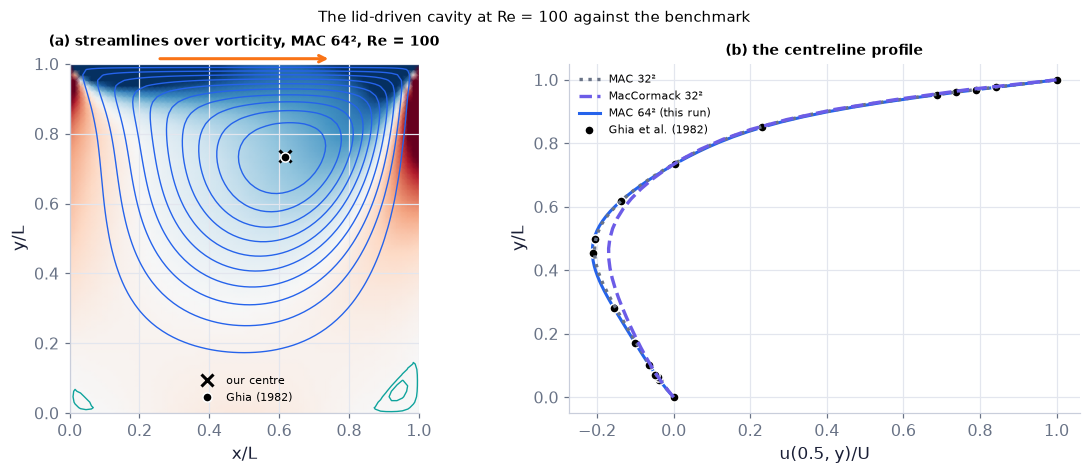

In [145]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4.2))   # the figure and its panels
g_ = st["g"]; xcn = np.linspace(0, 1, g_.nx + 1)                       # corner coordinates (where psi and omega live)
om = st["omega"]; lim = np.percentile(np.abs(om), 95)                  # corner vorticity; colour range without the corner spikes
a1.pcolormesh(xcn, xcn, om, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="gouraud")   # vorticity heatmap
ps_ = st["psi"]
a1.contour(xcn, xcn, ps_, levels=np.linspace(ps_.min(), 0, 12)[:-1], colors=C_IM, linewidths=0.9, linestyles="solid")   # the primary eddy (psi < 0)
a1.contour(xcn, xcn, ps_, levels=np.array([1e-6, 1e-5, 5e-5]), colors=C_UP, linewidths=0.9)       # the weak corner eddies (psi > 0)
a1.plot(cen["x"], cen["y"], "x", color="k", ms=8, mew=2, label="our centre")   # draw the curve(s)
gc = ch10.ghia_vortex_centre(100); a1.plot(gc["x"], gc["y"], "o", mfc="k", mec="w", ms=6, label="Ghia (1982)")   # draw the curve(s)
a1.annotate("", xy=(0.75, 1.015), xytext=(0.25, 1.015), arrowprops=dict(arrowstyle="->", color=C_FT, lw=2), annotation_clip=False)   # the lid
a1.set_aspect("equal"); a1.set_xlabel("x/L"); a1.set_ylabel("y/L"); a1.legend(fontsize=7, loc="lower center")   # axis labels, with units where the quantity has them
a1.set_title(f"(a) streamlines over vorticity, MAC {g_.nx}², Re = 100", fontsize=9, pad=12)   # the panel's title: what this panel shows
for name, col, ls in (("cavity_mac_re100_n32.csv", C_EX, ":"), ("cavity_mck_re100_n32.csv", C_MC, "--")):   # the two 32^2 runs, dotted/dashed
    tb, _ = read_table(name); a2.plot(tb["u"], tb["y"], ls, color=col, lw=2.2, zorder=4, label=name.replace("cavity_", "").replace("_re100_n", " ").replace(".csv", "²").replace("mac", "MAC").replace("mck", "MacCormack"))   # draw the curve(s)
a2.plot(cl["u"], cl["y"], color=C_IM, lw=2, label=f"MAC {g_.nx}² (this run)")   # draw the curve(s)
a2.plot(gh["u"], gh["y"], "o", mfc="k", mec="w", ms=6, label="Ghia et al. (1982)")   # draw the curve(s)
a2.set_xlabel("u(0.5, y)/U"); a2.set_ylabel("y/L"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) the centreline profile", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("The lid-driven cavity at Re = 100 against the benchmark", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c14_cavity"); plt.show()   # display the figure

**What you see.** (a) One big clockwise eddy (blue streamlines) filling the box over a red/blue vorticity map, two tiny corner eddies (teal) at the bottom, our eddy centre (✕) on Ghia's (black dot). (b) The centreline velocity profiles of three runs against Ghia's points.

**How to read it.** The fine MAC curve (blue) passes through the benchmark dots (the code cell prints the deviation); the coarse curves miss the minimum near $y\approx0.45$ most, and the $32^2$ MacCormack run misses it more than the $32^2$ MAC run.

**What would change if…** …$Re=400$: the eddy centre would move towards the middle of the box and the minimum of $u$ would deepen (our committed $128^2$ table, used in §10.6).

In [146]:
spin = MAC.cavity(Re=100.0, n=32, t_end=12.0, tol_steady=0.0, save_every=25)   # a 32^2 run from rest that stores snapshots (not cached)
snaps = spin["snapshots"][:: max(1, len(spin["snapshots"])//(60 if not FAST else 30))]   # at most 60 frames (FAST 30)
gS = spin["g"]; xcn = np.linspace(0, 1, gS.nx + 1)   # sample points
fig, (b1, b2) = plt.subplots(1, 2, figsize=(7, 3.4))   # the figure and its panels
b2.plot(gh["u"], gh["y"], "o", mfc="k", mec="w", ms=5)                 # the benchmark (fixed)
prof, = b2.plot([], [], color=C_IM, lw=2); b2.set_xlim(-0.35, 1.05); b2.set_ylim(0, 1); b2.set_xlabel("u(0.5, y)"); b2.set_ylabel("y")   # axis labels, with units where the quantity has them
def update(f):                                                          # frame f: snapshot f
    t_, u_, v_ = snaps[f]
    b1.clear(); psi_ = MAC.streamfunction(u_, v_, gS)                  # psi from the computed velocity (psi = 0 on the walls)
    b1.pcolormesh(xcn, xcn, MAC.vorticity(u_, v_, gS), cmap="RdBu_r", vmin=-8, vmax=8, shading="gouraud")   # a colour map of the field
    if psi_.min() < -1e-6: b1.contour(xcn, xcn, psi_, levels=np.linspace(psi_.min(), 0, 10)[:-1], colors=C_IM, linewidths=0.8)   # contour lines of the field
    b1.set_aspect("equal"); b1.set_title(f"t = {t_:.1f} L/U", fontsize=9); b1.set_xticks([]); b1.set_yticks([])   # the panel's title: what this panel shows
    c_ = MAC.cavity_centreline(u_, gS); prof.set_data(c_["u"], c_["y"])
    return [prof]   # the values for this call
show_animation(animate(update, frames=len(snaps), fig=fig, interval=80), player="video")

**What you see.** The cavity spinning up from rest at $Re=100$ on a $32^2$ grid: vorticity and streamlines (left), the centreline profile approaching Ghia's dots (right).

**How to read it.** Vorticity is born at the moving lid and spreads down; the eddy forms within a few lid-transit times $L/U$ and then barely changes. A steady benchmark
is the end of a transient — the profile settles onto the dots (to the accuracy of this coarse grid).

**What would change if…** …$Re=400$: the spin-up would take longer and the eddy would end up nearer the centre of the box.

#### 🎮 Interactive: How do I know my CFD answer is right?

**Why interactive rather than a static figure:** Running the MAC solver live on $16^2$, $24^2$ and $32^2$ grids (and loading cached $64^2$/$128^2$ and MacCormack results), you watch the eddy form from rest and the centreline approach Ghia's points, while the error-against-$h$ view fills in dot by dot and the Richardson estimate updates.

**What to try:**
- Run 16², then 32²: how much closer is the minimum to Ghia's?
- Load the cached 128² run and read the observed order in the status.
- Switch Re to 400: which part of the profile changes most?

In [147]:
show_viz("ch10", "lid_driven_cavity")   # full-width explainer; ⤢ Full screen for more room

[explainer ch10/lid_driven_cavity]

**What would change if…** …there were no benchmark at all — a new geometry, a new $Re$? Then the only evidence left is internal: refine the grid and show that the answer stops changing at the
rate the scheme promises. C15.

> 🔁 **Recap — R11 · Force coefficients and a steady-to-shedding wake** (Ch. 4 §4.11, Ch. 9 §9.8). Ch. 4 defined $C_D=\frac{F_D}{\frac12\rho U^2A}$ *(4.107)* and $C_L=\frac{F_L}{\frac12\rho U^2A}$ *(4.108)* (here per unit span with $A$ = the block side); Ch. 9 §9.8 showed a bluff body's wake is steady at low $Re$ and sheds vortices above a threshold. For the block in a channel we compute $C_D(t)$, $C_L(t)$ at $Re=20$ (steady after an acoustic transient) — a coarse run here, finer ones cached by `scripts/ch10_block.py`.

### 🧩 Grid convergence, Richardson extrapolation and the verification checklist `C15`

*The question:* When no exact answer exists, how can three runs on three grids tell us both that the code works and what the grid-independent answer is?

*In one line:* $\lVert e^n_i\rVert\le K_e\,\Delta x^a\,\Delta t^b$ *(10.15)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`)

- **frames of reference and relative velocity** — the same flow seen from a moving frame differs by the frame's velocity (Ch. 3 P96).

📝 **Note.** **N86 [B]** **A square block in a channel (Fig. 10.9 analogue, our geometry):** block side $d=1$, channel height $H=4$ (blockage ¼), 8 sides upstream, 20 downstream,
walls sliding at the stream speed (the block moves through still fluid — the same flow seen from the block, Ch. 3's change of frame), uniform inflow, zero-gradient
outflow, our $Ma=0.06$, $Re=20$ and 100 on the block side.

> ⚠️ **Our deviation — the inflow density.** Updating the inflow density from continuity, as for the walls, made our run blow up at the plate corners; our solver sets
> it by a zero-gradient, second-order extrapolation from the two interior columns, $\rho_0=(4\rho_1-\rho_2)/3$ (the value that makes the one-sided derivative
> $(-3\rho_0+4\rho_1-\rho_2)/(2\Delta x)$ zero).

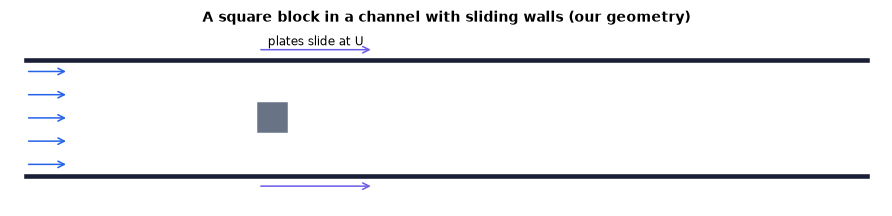

In [148]:
fig, ax = plt.subplots(figsize=(8, 2.0))   # the figure and its panels
block_channel_sketch(ax)                                              # our geometry: H = 4, 8 sides ahead, 20 behind
ax.set_title("A square block in a channel with sliding walls (our geometry)", fontsize=9)   # the panel's title: what this panel shows
plt.show()   # display the figure

**What you see.** A long channel with a small square block, the inflow on the left, the outflow on the right and arrows on the moving walls.

**How to read it.** The walls move at the stream speed, so no boundary layer grows on them — the block sees a uniform approaching flow.

**What would change if…** …fixed walls: the channel's own Poiseuille profile would meet the block, and the drag would change.

Re = 100, t > 50: mean C_L = +0.094, swing -0.38 to +0.58


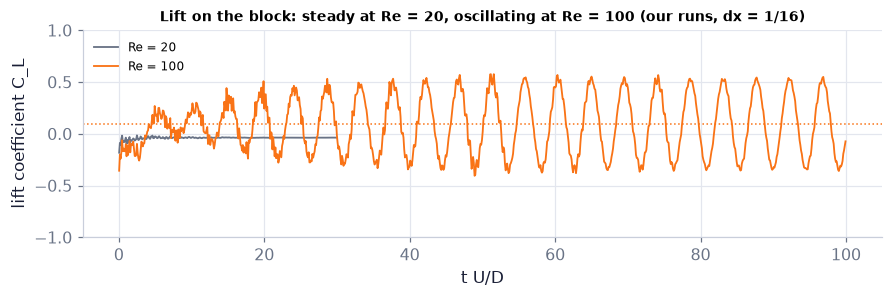

In [149]:
fig, ax = plt.subplots(figsize=(8, 2.6))   # the figure and its panels
for Re_, col in ((20, C_EX), (100, C_FT)):                           # our two cached block runs on dx = 1/16
    tb, _ = read_table(f"block_forces_re{Re_}_dx16.csv")             # columns t, CD, CL (time in D/U)
    ax.plot(tb["t"], tb["CL"], color=col, lw=1.2, label=f"Re = {Re_}")   # the lift coefficient against time
late = tb["t"] > 50                                                   # Re = 100 (last table read): the settled shedding, t > 50 D/U
cl_mean = tb["CL"][late].mean()                                       # time-mean lift over the settled cycles [–]
ax.axhline(cl_mean, color=C_FT, ls=":", lw=1)                         # the mean the oscillation swings about
print(f"Re = 100, t > 50: mean C_L = {cl_mean:+.3f}, swing {tb['CL'][late].min():+.2f} to {tb['CL'][late].max():+.2f}")   # show the numbers computed above
ax.set_ylim(-1, 1); ax.set_xlabel("t U/D"); ax.set_ylabel("lift coefficient C_L"); ax.legend(fontsize=8, frameon=False)   # axis labels, with units where the quantity has them
ax.set_title("Lift on the block: steady at Re = 20, oscillating at Re = 100 (our runs, dx = 1/16)", fontsize=9)   # the panel's title: what this panel shows
plt.show()   # display the figure

**What you see.** Two lift histories: the Re = 20 one (run to t = 30) settles to a small constant after the start-up transient; the Re = 100 one (run to t = 100) keeps swinging up and down.

**How to read it.** At Re = 20 the wake behind the block is steady; its small leftover lift is a grid error that halves with each refinement (C15 measures it). At Re = 100 vortices shed alternately from the two sides, so the lift oscillates — not about zero but about a small positive mean (dotted line; the cell prints it, about +0.09 for t > 50), a slight asymmetry of our confined, coarse-grid run.

**What would change if…** …Re were raised further: the oscillation would grow in amplitude and its frequency (the Strouhal number) would change a little.

📝 **Note.** **N87 [B], N88 [B], N89 [B]** **Density on the block's faces** (heuristic, "it gives better results" as the book says): on the front face $u=v=0$, so the convective terms and
the time derivative of the $x$-momentum equation vanish and $\frac{\partial\rho}{\partial x}=\frac{Ma^2}{Re}\big(\frac43u_{xx}+\frac13v_{xy}\big)$ *(10.147)* — only viscous terms set the density
gradient; one-sided stencils $\big(\frac{\partial\rho}{\partial x}\big)_{i,j}=\frac{-1}{2\Delta x}(-\rho_{i-2,j}+4\rho_{i-1,j}-3\rho_{i,j})$ *(10.148)*,
$(u_{xx})_{i,j}=\frac1{\Delta x^2}(2u_{i,j}-5u_{i-1,j}+4u_{i-2,j}-u_{i-3,j})$ *(10.149)* (weights $(2,-5,4,-1)$ recomputed by `FD.fd_weights([0, -1, -2, -3], 2)`) and a one-sided
mixed derivative *(10.150)*, $(v_{xy})_{i,j}=\tfrac{-1}{4\Delta x\Delta y}\big[-(v_{i-2,j+1}-v_{i-2,j-1})+4(v_{i-1,j+1}-v_{i-1,j-1})-3(v_{i,j+1}-v_{i,j-1})\big]+O(\Delta x^2,\Delta x\Delta y,\Delta y^2)$; solving for the wall value gives the front-face density *(10.151)* — its coefficients $\frac89=\frac23\cdot\frac43$ and $\frac1{18}=\frac23\cdot\frac13\cdot\frac14$;
the back, top and bottom faces *(10.152)–(10.154)*, $\tfrac13(4\rho_{i+1,j}-\rho_{i+2,j})-\tfrac{8}{9\Delta x}\tfrac{Ma^2}{Re}(-5u_{i+1,j}+4u_{i+2,j}-u_{i+3,j})-\tfrac{1}{18\Delta y}\tfrac{Ma^2}{Re}\big[-(v_{i+2,j+1}-v_{i+2,j-1})+4(v_{i+1,j+1}-v_{i+1,j-1})-3(v_{i,j+1}-v_{i,j-1})\big],\ \tfrac13(4\rho_{i,j+1}-\rho_{i,j+2})-\tfrac{8}{9\Delta y}\tfrac{Ma^2}{Re}(-5v_{i,j+1}+4v_{i,j+2}-v_{i,j+3})-\tfrac{1}{18\Delta x}\tfrac{Ma^2}{Re}\big[-(u_{i+1,j+2}-u_{i-1,j+2})+4(u_{i+1,j+1}-u_{i-1,j+1})-3(u_{i+1,j}-u_{i-1,j})\big],\ \tfrac13(4\rho_{i,j-1}-\rho_{i,j-2})+\tfrac{8}{9\Delta y}\tfrac{Ma^2}{Re}(-5v_{i,j-1}+4v_{i,j-2}-v_{i,j-3})-\tfrac{1}{18\Delta x}\tfrac{Ma^2}{Re}\big[-(u_{i+1,j-2}-u_{i-1,j-2})+4(u_{i+1,j-1}-u_{i-1,j-1})-3(u_{i+1,j}-u_{i-1,j})\big]$ by symmetry; corners averaged.

$$ \rho_{i,j}=\tfrac13(4\rho_{i-1,j}-\rho_{i-2,j})+\tfrac{8}{9\Delta x}\tfrac{Ma^2}{Re}(-5u_{i-1,j}+4u_{i-2,j}-u_{i-3,j})-\tfrac{1}{18\Delta y}\tfrac{Ma^2}{Re}\big[-(v_{i-2,j+1}-v_{i-2,j-1})+4(v_{i-1,j+1}-v_{i-1,j-1})-3(v_{i,j+1}-v_{i,j-1})\big] \qquad \text{(10.151)} $$

In [150]:
print("second derivative from [0, -1, -2, -3]:", FD.fd_weights([0, -1, -2, -3], 2))   # (2, -5, 4, -1): (10.149)
print("8/9 =", 2/3*4/3, "  1/18 =", 2/3*1/3*1/4)                                        # the coefficients of (10.151)

second derivative from [0, -1, -2, -3]: [2, -5, 4, -1]
8/9 = 0.8888888888888888   1/18 = 0.05555555555555555


**What does the code above do?**

The C01 method gives the four-point one-sided second derivative of (10.149), $(u_{xx})_{i,j}=\tfrac1{\Delta x^2}(2u_{i,j}-5u_{i-1,j}+4u_{i-2,j}-u_{i-3,j})+O(\Delta x^2)$; the two products reproduce the coefficients of (10.151), $\rho_{i,j}=\tfrac13(4\rho_{i-1,j}-\rho_{i-2,j})+\tfrac{8}{9\Delta x}\tfrac{Ma^2}{Re}(-5u_{i-1,j}+4u_{i-2,j}-u_{i-3,j})-\tfrac{1}{18\Delta y}\tfrac{Ma^2}{Re}\big[-(v_{i-2,j+1}-v_{i-2,j-1})+4(v_{i-1,j+1}-v_{i-1,j-1})-3(v_{i,j+1}-v_{i,j-1})\big]$.

📝 **Note.** **N90 [B]** **Practice:** long explicit runs accumulate round-off, so use double precision (P222), compute the density perturbation $\rho'=\rho-1$ instead of $\rho$ (fewer
digits cancel), and cycle the MacCormack arrangements (FB/BF then BF/FB, N57). The cell runs the same cavity steps four ways.

In [151]:
nst = 5000 if not FAST else 2000                                      # time steps of a 16^2 MacCormack cavity
dt16 = MCK.maccormack_dt_asymptotic(0.08, 1/16); co16 = MCK.cavity_coefficients(dt16, 1/16, 1/16, 0.08, 100.0)
out = {}
for dtype in (np.float64, np.float32):                                # double and single precision
    for pert in (True, False):                                        # store rho' = rho - 1, or rho itself
        s_ = MCK.cavity_init(16, dtype=dtype, perturbation=pert)
        for _ in range(nst):   # repeat the indented lines for each index
            s_ = MCK.weakly_compressible_step(s_, co16, dtype=dtype, perturbation=pert)
        rho_ = np.asarray(s_[0], float) + (1.0 if pert else 0.0)      # the full density
        out[(dtype.__name__, pert)] = np.asarray(s_[1], float)/rho_  # the velocity u = (rho u)/rho
ref_ = out[("float64", True)]
for (dt_name, pert), u_ in out.items():   # repeat the indented lines for each item listed
    print(f"{dt_name}, store {'rho - 1' if pert else 'rho    '}: max |u - u(float64, rho - 1)| = {np.abs(u_ - ref_).max():.1e}")   # show the numbers computed above

float64, store rho - 1: max |u - u(float64, rho - 1)| = 0.0e+00
float64, store rho    : max |u - u(float64, rho - 1)| = 2.7e-15
float32, store rho - 1: max |u - u(float64, rho - 1)| = 1.0e-07
float32, store rho    : max |u - u(float64, rho - 1)| = 1.4e-06


**What does the code above do?**

1. The same $16^2$ weakly compressible cavity is stepped in double and single precision, storing either $\rho'=\rho-1$ or $\rho$.
2. In double precision the two storages agree to round-off. In single precision the velocity drifts from the double-precision answer — and storing $\rho$ itself
   (about 1, so the small variations lose digits) is about ten times worse than storing $\rho'$. The drift is pure round-off: the equations are the same.

📝 **Note.** **N91 [B]** **The asymptotic MacCormack step:** for $\Delta x=\Delta y$ and large grid Reynolds number the limit (10.110), $\Delta t\le\dfrac{\sigma}{1+2/Re_\Delta}\left[\dfrac{\lvert u\rvert}{\Delta x}+\dfrac{\lvert v\rvert}{\Delta y}+c\sqrt{\dfrac{1}{\Delta x^2}+\dfrac{1}{\Delta y^2}}\right]^{-1},\ Re_\Delta=\min\Big(\tfrac{\rho\lvert u\rvert\Delta x}{\mu},\tfrac{\rho\lvert v\rvert\Delta y}{\mu}\Big)$ becomes $\Delta t\le\frac{\sigma}{\sqrt2}\,Ma\,\Delta x$
*(10.155)*.

> ⚠️ **Printed slip.** **The book states that (10.155), $\Delta t\le\dfrac{\sigma}{\sqrt2}\,Ma\,\Delta x$ follows "with large grid Reynolds numbers"; it also needs $Ma\ll1$** — so that $\lvert u\rvert/\Delta x+\lvert v\rvert/\Delta y\ll\sqrt2c/\Delta x$
(slip #12). At $Ma=0.5$ the two limits differ by a third (the cell prints them).

In [152]:
for Ma in (0.08, 0.5):                                                # small and not-small Mach numbers (ours)
    a_ = MCK.maccormack_dt_asymptotic(Ma, 1/64); f_ = MCK.maccormack_dt(1.0, 0.0, 1/Ma, 1/64, 1/64, 1.0, 1e-6)   # mu tiny: large Re_Delta
    print(f"Ma = {Ma}: asymptotic (10.155) {a_:.3e}, full (10.110) {f_:.3e}, ratio {a_/f_:.2f}")   # show the numbers computed above

Ma = 0.08: asymptotic (10.155) 7.071e-04, full (10.110) 6.692e-04, ratio 1.06
Ma = 0.5: asymptotic (10.155) 4.419e-03, full (10.110) 3.265e-03, ratio 1.35


**What does the code above do?**

With a tiny viscosity (large mesh Reynolds number) the full limit (10.110), $\Delta t\le\dfrac{\sigma}{1+2/Re_\Delta}\left[\dfrac{\lvert u\rvert}{\Delta x}+\dfrac{\lvert v\rvert}{\Delta y}+c\sqrt{\dfrac{1}{\Delta x^2}+\dfrac{1}{\Delta y^2}}\right]^{-1},\ Re_\Delta=\min\Big(\tfrac{\rho\lvert u\rvert\Delta x}{\mu},\tfrac{\rho\lvert v\rvert\Delta y}{\mu}\Big)$ and its asymptotic form (10.155), $\Delta t\le\dfrac{\sigma}{\sqrt2}\,Ma\,\Delta x$ agree within a few per cent at $Ma=0.08$, but at $Ma=0.5$
the asymptotic form overestimates the allowed step by about a third — the flow speed is no longer negligible against the sound speed.

#### The problem in plain words

You computed the drag on the block: one value on one grid, a slightly different one on a finer grid. Which is right? Neither — both carry discretisation error. But if
the scheme is second order, the error should fall by 4 each time the spacing halves. Three grids let you (1) *measure* the order (if it is not close to the scheme's
order, something is wrong: a bug, or a grid too coarse to be in the "asymptotic range"), and (2) *extrapolate* to zero spacing — Richardson's trick — giving a better
number than any of the three runs and an honest error bar.

#### The idea

```
f(h) ≈ f₀ + K hᵖ          (the error model (10.15), one term)
h₃ = 4h   f₃ ─┐
h₂ = 2h   f₂ ─┤ differences shrink by rᵖ:   (f₃ − f₂)/(f₂ − f₁) = rᵖ  ⇒  p
h₁ = h    f₁ ─┘ extrapolate:  f₀ ≈ f₁ + (f₁ − f₂)/(rᵖ − 1)
```

*The numbered equations in the sketch:* $\lVert e^n_i\rVert\le K_e\,\Delta x^a\,\Delta t^b$ *(10.15)*

#### 🧮 Derivation — Observed order and Richardson extrapolation $f_0\approx f_1+\frac{f_1-f_2}{r^p-1}$ from the error model $\lVert e\rVert\le K_e\Delta x^a$ `D23` (Eq. 10.15: $\lVert e^n_i\rVert\le K_e\,\Delta x^a\,\Delta t^b$)

**What we want to show.** From three runs on grids refined by a factor r, measure the order p of the code and estimate the grid-independent answer (the book only says grid-independence gives confidence).

**Assumptions.** All three grids in the *asymptotic range* (the leading term dominates, step 1); the same refinement ratio r; Δt refined consistently or its error negligible.

**The plan.**

1. Three grids h, rh, r²h.
2. Differences cancel the unknown f₀; their ratio cancels K_e.
3. Logs give p.
4. Two equations give f₀.

**Tools we use** (each explained before this point): Log–log slopes (Ch. 1 P13) · the convergence model (N10).

**We start from**

$$ \begin{array}{l}\text{The error model (10.15) for one output f (a drag coefficient, a velocity} \\ \text{minimum):}\ f(h)=f_0+K_eh^p+\dots\end{array} $$

*In words:* the computed value is the true one plus an error shrinking like hᵖ.

---

**Step 1 of 8 — Write the model on three grids.**

$$ f_1=f_0+K_eh^p,\quad f_2=f_0+K_e(rh)^p,\quad f_3=f_0+K_e(r^2h)^p $$

- *Why we can do this:* (10.15), $\lVert e^n_i\rVert\le K_e\,\Delta x^a\,\Delta t^b$ with one dominant term; h₁ = h is the finest grid.
- *In words:* three runs, one unknown truth.

---

**Step 2 of 8 — Difference neighbouring grids.**

$$ f_2-f_1=K_eh^p(r^p-1),\qquad f_3-f_2=K_eh^pr^p(r^p-1) $$

- *Why we can do this:* Subtracting removes f₀; factor out $K_eh^p$.
- *In words:* the changes between grids.

---

**Step 3 of 8 — Take their ratio.**

$$ \frac{f_3-f_2}{f_2-f_1}=r^p $$

- *Why we can do this:* $K_eh^p(r^p-1)$ cancels (nonzero if the grids differ and the scheme is not exact).
- *In words:* each refinement shrinks the change by rᵖ.

---

**Step 4 of 8 — Solve for p.**

$$ p=\frac{\ln\big[(f_3-f_2)/(f_2-f_1)\big]}{\ln r} $$

- *Why we can do this:* Take natural logs of both sides (P13 — a slope on log axes); the ratio must be positive.
- *In words:* the observed order of accuracy.

---

**Step 5 of 8 — Compare p with the scheme's order.**

$$ p_{observed}\approx p_{formal}\ \ (=2\ \text{for MAC in space}) $$

- *Why we can do this:* Agreement is the evidence the code solves its equations as designed; disagreement means a bug or grids outside the asymptotic range.
- *In words:* the code check.

---

**Step 6 of 8 — Use the two finest grids for $K_eh^p$.**

$$ K_eh^p=\frac{f_2-f_1}{r^p-1} $$

- *Why we can do this:* The first equation of step 2 divided by rᵖ − 1.
- *In words:* the size of the error on the finest grid.

---

**Step 7 of 8 — Subtract it from f₁.**

$$ f_0\approx f_1-K_eh^p=f_1+\frac{f_1-f_2}{r^p-1} $$

- *Why we can do this:* From step 1, f₀ = f₁ − K_e hᵖ; this is Richardson's extrapolation (`tools.convergence.richardson`).
- *In words:* the grid-independent estimate.

---

**Step 8 of 8 — Attach an error bar.**

$$ \mathrm{GCI}_{fine}=F_s\,\frac{\lvert f_1-f_2\rvert}{(r^p-1)\lvert f_1\rvert},\quad F_s=1.25 $$

- *Why we can do this:* Roache's grid convergence index turns step 6 into a relative uncertainty with a safety factor; meaningful only if the ratio of step 3 is positive and steady (monotone convergence).
- *In words:* how far the fine-grid answer may be from the truth.

---

**Result**

$$ p=\ln\frac{f_3-f_2}{f_2-f_1}/\ln r\ \text{and}\ f_0\approx f_1+\frac{f_1-f_2}{r^p-1} $$

*In words:* three grids measure the order and remove the leading error.

**What it means.** The verification habit the chapter ends on (N111): refine, measure p, extrapolate. Our block-in-a-channel drag study below is an example of a *failed* test: its differences shrink far more slowly than second order, so it is reported as non-asymptotic, not as grid independent. It fails for oscillatory convergence (negative ratio), for grids too coarse (ratio drifting), and when a singularity (the cavity's lid corners, the block's corners) lowers the local order.

**Check it.** f = 1 + h² at h = 0.1, 0.05, 0.025: ratio 4, p = 2, f₀ = 1.000000 ✓ (C15 tiny example); units: p dimensionless, f₀ in f's units ✓. `grid_convergence_index` and `ch10.richardson_three` return the same.

> ⚠️ **Common confusion (traps in `D23`):** Using two grids only (p must then be assumed); mixing refinement ratios; reading a p far from the formal order as 'good enough'; forgetting that Δt must be refined too for time-dependent outputs.

#### ✏️ Tiny example: Richardson on a made-up answer

Suppose $f(h)=1+h^2$ exactly (so the true answer is 1 and $p=2$).
1. Three grids $h=0.1,0.05,0.025$: $f_3=1.01$, $f_2=1.0025$, $f_1=1.000625$.
2. Differences: $f_3-f_2=0.0075$, $f_2-f_1=0.001875$, ratio 4.
3. $p=\ln4/\ln2=2$ ✓.
4. Richardson: $f_0\approx1.000625+(1.000625-1.0025)/(2^2-1)=1.000625-0.000625=1.000000$ ✓ — the leading error is removed exactly.
5. With a real code the next term ($h^3$, $h^4$) remains, so the extrapolated value is better but not exact.

In [153]:
gci = grid_convergence_index(1.000625, 1.0025, 1.01, r=2.0)           # the tiny example (f1 finest)
print(f"tiny example: p = {gci['p']:.3f}, f_ext = {gci['f_ext']:.6f}")   # show the numbers computed above
ns3 = (16, 32, 64) if not FAST else (12, 24, 48)                     # three cavity grids, refinement ratio 2
runs = {n_: MAC.cavity(Re=100.0, n=n_) for n_ in ns3}                # cached after the first run
umin = [MAC.cavity_centreline(runs[n_])["u"].min() for n_ in ns3]    # the minimum of u(0.5, y) on each grid
g3 = grid_convergence_index(umin[2], umin[1], umin[0], r=2.0)        # f1 = finest
print(f"cavity u_min on n = {ns3}: {np.round(umin, 5)}  ->  p = {g3['p']:.2f}, Richardson {g3['f_ext']:.5f}, GCI_fine {100*g3['gci_fine']:.2f} %, "   # show the numbers computed above
      f"monotone {g3['monotone']}")
print(f"(Ghia's smallest tabulated u, at one of their 17 points: {ch10.ghia_centreline(100)['u'].min():.5f} — a sample, not the exact minimum)")   # show the numbers computed above
have128 = any((ROOT / "outputs" / "ch10").glob("mac_cavity_Re100_n128_*.npz")) and not FAST   # a cached 128^2 run on this machine?
nps = (32, 64, 128) if have128 else ns3                               # psi_min study: finest grids available without a long run
psis = [MAC.primary_vortex_centre(MAC.cavity(Re=100.0, n=n_)["psi"], MAC.cavity(Re=100.0, n=n_)["g"])["psi_min"] for n_ in nps]
gp = grid_convergence_index(psis[2], psis[1], psis[0], r=2.0)
print(f"cavity psi_min on n = {nps}: {np.round(psis, 6)}  ->  p = {gp['p']:.2f}, Richardson {gp['f_ext']:.6f}, GCI_fine {100*gp['gci_fine']:.3f} %")   # show the numbers computed above
blk = [read_table(f"block_forces_re20_dx{k}.csv")[0] for k in (8, 16, 32)]   # our cached block runs, dx = 1/8, 1/16, 1/32
cd = [float(b_["CD"][b_["t"] > 20].mean()) for b_ in blk]            # mean C_D over 20 < t < 30 (confined: qualitative)
gb = grid_convergence_index(cd[2], cd[1], cd[0], r=2.0)
print(f"block C_D (Re = 20, mean over t > 20) on dx = 1/8, 1/16, 1/32: {np.round(cd, 3)}  ->  p = {gb['p']:.2f}, GCI_fine {100*gb['gci_fine']:.1f} %")   # show the numbers computed above

tiny example: p = 2.000, f_ext = 1.000000
cavity u_min on n = (16, 32, 64): [-0.1874 -0.2067 -0.2123]  ->  p = 1.80, Richardson -0.21452, GCI_fine 1.31 %, monotone True
(Ghia's smallest tabulated u, at one of their 17 points: -0.21090 — a sample, not the exact minimum)
cavity psi_min on n = (32, 64, 128): [-0.1014 -0.103  -0.1034]  ->  p = 2.00, Richardson -0.103527, GCI_fine 0.164 %
block C_D (Re = 20, mean over t > 20) on dx = 1/8, 1/16, 1/32: [4.272 4.423 4.534]  ->  p = 0.43, GCI_fine 8.9 %


**What does the code above do?**

1. `grid_convergence_index(f1, f2, f3, r)` (with $f_1$ the finest) returns the observed order $p$, the Richardson value $f_{ext}$ and Roache's GCI (D23 step 8); on the tiny
   example it recovers $p=2$ and $f_0=1$ exactly.
2. The cavity's $u_{min}$ on three MAC grids converges monotonically at close to second order; Richardson's value and its GCI error bar are printed. Ghia's smallest
   tabulated value is a sample at one of their points, not the true minimum, so it is shown only for orientation.
3. The minimum of the stream function (the eddy strength) on the three finest grids we have converges at about second order with a GCI of a fraction of a per cent —
   the self-convergence evidence that the MAC solver does what it promises.
4. The block's mean drag on our three cached grids is a **failed** test: the differences shrink much more slowly than second order ($p$ well below 1) and the GCI is
   several per cent — the grids are not in the asymptotic range (the heuristic wall-density closures of (10.151)–(10.154), $\rho_{i,j}=\tfrac13(4\rho_{i-1,j}-\rho_{i-2,j})+\tfrac{8}{9\Delta x}\tfrac{Ma^2}{Re}(-5u_{i-1,j}+4u_{i-2,j}-u_{i-3,j})-\tfrac{1}{18\Delta y}\tfrac{Ma^2}{Re}\big[-(v_{i-2,j+1}-v_{i-2,j-1})+4(v_{i-1,j+1}-v_{i-1,j-1})-3(v_{i,j+1}-v_{i,j-1})\big],\ \tfrac13(4\rho_{i+1,j}-\rho_{i+2,j})-\tfrac{8}{9\Delta x}\tfrac{Ma^2}{Re}(-5u_{i+1,j}+4u_{i+2,j}-u_{i+3,j})-\tfrac{1}{18\Delta y}\tfrac{Ma^2}{Re}\big[-(v_{i+2,j+1}-v_{i+2,j-1})+4(v_{i+1,j+1}-v_{i+1,j-1})-3(v_{i,j+1}-v_{i,j-1})\big],\ \tfrac13(4\rho_{i,j+1}-\rho_{i,j+2})-\tfrac{8}{9\Delta y}\tfrac{Ma^2}{Re}(-5v_{i,j+1}+4v_{i,j+2}-v_{i,j+3})-\tfrac{1}{18\Delta x}\tfrac{Ma^2}{Re}\big[-(u_{i+1,j+2}-u_{i-1,j+2})+4(u_{i+1,j+1}-u_{i-1,j+1})-3(u_{i+1,j}-u_{i-1,j})\big],\ \tfrac13(4\rho_{i,j-1}-\rho_{i,j-2})+\tfrac{8}{9\Delta y}\tfrac{Ma^2}{Re}(-5v_{i,j-1}+4v_{i,j-2}-v_{i,j-3})-\tfrac{1}{18\Delta x}\tfrac{Ma^2}{Re}\big[-(u_{i+1,j-2}-u_{i-1,j-2})+4(u_{i+1,j-1}-u_{i-1,j-1})-3(u_{i+1,j}-u_{i-1,j})\big]$, the block's corners and a persistent
   acoustic oscillation all limit it). This study is *non-asymptotic*; it does not show a grid-independent drag, and the confined drag is qualitative anyway.

In [154]:
# from scratch: observed order and Richardson from three grids in four lines
f1, f2, f3, r = umin[2], umin[1], umin[0], 2.0                         # finest, middle, coarsest (u_min of the cavity)
p = np.log((f3 - f2)/(f2 - f1))/np.log(r)                             # D23 step 4
f0 = f1 + (f1 - f2)/(r**p - 1)                                        # D23 step 7
print(f"p = {p:.4f}, f0 = {f0:.6f}")   # show the numbers computed above
assert np.isclose(p, g3["p"]) and np.isclose(f0, g3["f_ext"]) and np.isclose(f0, richardson(f2, f1, 2.0, p))   # same as both tools

p = 1.8026, f0 = -0.214523


**What does the code above do?**

D23's two formulas in four lines reproduce `grid_convergence_index` and `tools.convergence.richardson` (called with the coarse value first, the fine value second, $r$ and $p$).

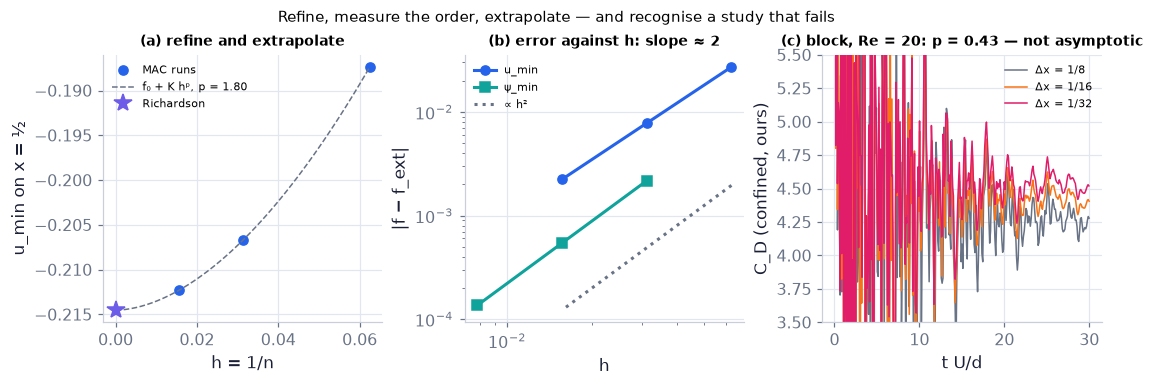

In [155]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.4))   # the figure and its panels
hs3 = np.array([1/n_ for n_ in ns3])                                  # grid spacings
a1.plot(hs3, umin, "o", color=C_IM, ms=6, label="MAC runs")   # draw the curve(s)
hh = np.linspace(0, hs3.max(), 50); Kfit = (umin[2] - g3["f_ext"])/hs3[2]**g3["p"]   # sample points
a1.plot(hh, g3["f_ext"] + Kfit*hh**g3["p"], "--", color=C_EX, lw=1, label=f"f₀ + K hᵖ, p = {g3['p']:.2f}")   # draw the curve(s)
a1.plot(0, g3["f_ext"], "*", color=C_MC, ms=12, label="Richardson")   # draw the curve(s)
a1.set_xlabel("h = 1/n"); a1.set_ylabel("u_min on x = ½"); a1.legend(fontsize=7, frameon=False); a1.set_title("(a) refine and extrapolate", fontsize=9)   # the panel's title: what this panel shows
a2.loglog(hs3, np.abs(np.array(umin) - g3["f_ext"]), "o-", color=C_IM, label="u_min")   # curve(s) on logarithmic axes
a2.loglog([1/n_ for n_ in nps], np.abs(np.array(psis) - gp["f_ext"]), "s-", color=C_UP, label="ψ_min")   # curve(s) on logarithmic axes
a2.loglog(hs3, 0.5*hs3**2, ":", color=C_EX, label="∝ h²")   # curve(s) on logarithmic axes
a2.set_xlabel("h"); a2.set_ylabel("|f − f_ext|"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) error against h: slope ≈ 2", fontsize=9)   # the panel's title: what this panel shows
a2.xaxis.set_minor_formatter(plt.NullFormatter())                     # no crowded minor tick labels on the log axis
for b_, dxl, col in zip(blk, ("1/8", "1/16", "1/32"), (C_EX, C_FT, C_BAD)):   # repeat the indented lines for each item listed
    a3.plot(b_["t"], b_["CD"], color=col, lw=1, label=f"Δx = {dxl}")   # draw the curve(s)
a3.set_ylim(3.5, 5.5); a3.set_xlabel("t U/d"); a3.set_ylabel("C_D (confined, ours)"); a3.legend(fontsize=7, frameon=False)   # axis labels, with units where the quantity has them
a3.set_title(f"(c) block, Re = 20: p = {gb['p']:.2f} — not asymptotic", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("Refine, measure the order, extrapolate — and recognise a study that fails", fontsize=10)   # the figure's message as its title
savefig(fig, "ch10", "nb_c15_convergence"); plt.show()   # display the figure

**What you see.** (a) Three $u_{min}$ values marching towards the Richardson star at $h=0$ along the fitted curve. (b) Their distance from the extrapolated values on log–log axes, next to a slope-2 guide. (c) The block's drag histories on three grids: an acoustic transient, then nearly steady values that keep rising with refinement.

**How to read it.** Slope ≈ 2 = the scheme's order: the MAC code does what it promises, and the star is our best estimate, with the GCI as its error bar. In (c) the three plateaux do not close up at the second-order rate: this drag is not grid-converged, and Richardson would give a meaningless number.

**What would change if…** …the three cavity grids were too coarse (outside the asymptotic range): the differences would not shrink by a constant factor and $p$ would be meaningless — exactly what (c) shows for the block.

In [156]:
if not FAST:
    blk8 = MCK.block_channel(Re=20.0, dx=0.125)                      # our block, dx = 1/8, Ma = 0.06, to t = 30 (cached after the first run)
    print(f"{'loaded from cache' if blk8.get('cached') else 'computed now'}: {blk8['steps']} steps; mean C_D over t > 20 = "   # show the numbers computed above
          f"{blk8['CD'][blk8['t'] > 20].mean():.3f} (confined, qualitative)")
else:
    print("FAST: the live block run is skipped; the committed tables hold its history")   # show the numbers computed above
for b_, dxl in zip(blk, ("1/8", "1/16", "1/32")):                    # the three cached grids of the study above
    print(f"dx = {dxl:4s}: mean |C_L| over t > 20 = {np.abs(b_['CL'][b_['t'] > 20]).mean():.3f}")   # a symmetric flow should have C_L -> 0

loaded from cache: 7072 steps; mean C_D over t > 20 = 4.273 (confined, qualitative)
dx = 1/8 : mean |C_L| over t > 20 = 0.083
dx = 1/16: mean |C_L| over t > 20 = 0.037
dx = 1/32: mean |C_L| over t > 20 = 0.018


**What does the code above do?**

1. The coarsest block run is repeated live (or loaded from the cache): its mean drag matches the first entry of the study above.
2. The flow is symmetric, so the lift should vanish; it is small and shrinks as the grid is refined (the three printed means) — the grid error in $C_L$ does converge,
   even though the drag study above is not in the asymptotic range.

In [157]:
grids = (16, 24, 32, 64, 128)                                          # our committed centreline tables (MAC, Re = 100)
tabs = {n_: read_table(f"cavity_mac_re100_n{n_}.csv")[0] for n_ in grids}
def f6(n_):                                                             # the centreline on one grid, with Ghia's points
    t_ = tabs[int(n_)]
    return {f"MAC centreline": (t_["u"], t_["y"]), "Ghia et al. (1982)": (gh["u"], gh["y"])}   # the values for this call
fig = slider_figure(f6, "grid n", grids, xlabel="u(0.5, y)/U", ylabel="y/L", xrange=[-0.35, 1.02], yrange=[0, 1],
                    title="Slide the grid: the centreline closes in on the benchmark", modes={"Ghia et al. (1982)": "markers"})
fig.show()   # display the interactive figure

**What does the code above do?**

The page version of the explainer's convergence view: our MAC centreline on five grids ($16^2$ to $128^2$, from `reference/ch10/`) against Ghia's points. Beyond $64^2$ the
curves hardly move: the cell below computes the $64^2\to128^2$ change at Ghia's points and compares it with the $64^2$ deviation from Ghia — once the change between our
own grids is smaller than the distance to the benchmark, finer grids no longer look "closer", which is why self-convergence (the $\psi_{min}$ study) is the evidence.

In [158]:
gh_ = ch10.ghia_centreline(100)                                        # Ghia's 17 centreline points (Re = 100)
u64, u128 = (np.interp(gh_["y"], t_["y"], t_["u"]) for t_ in (read_table(f"cavity_mac_re100_n{k}.csv")[0] for k in (64, 128)))   # ours at Ghia's heights
print(f"64^2 -> 128^2 change: {100*np.abs(u128 - u64).max():.3f} % of U;  64^2 deviation from Ghia: {100*np.abs(u64 - gh_['u']).max():.3f} % of U")   # show the numbers computed above

64^2 -> 128^2 change: 0.204 % of U;  64^2 deviation from Ghia: 0.258 % of U


**What does the code above do?**

Both numbers are in per cent of the lid speed $U$, at Ghia's 17 heights on $x=\frac12$ (interpolated from our committed tables).

**What would change if…** …the quantity oscillated in time (the block at $Re=100$)? Refine both $\Delta x$ and $\Delta t$ and compare time averages and the Strouhal number — the checklist of §10.6.

*↪ **N92 [C]** A fourth computation — a cylinder at Re = 1000 by MacCormack, with a smoke line carried by an extra convection–diffusion equation (the 2-D version of the
model problem $\frac{\partial T}{\partial t}+u\frac{\partial T}{\partial x}=D\frac{\partial^2T}{\partial x^2}$ *(10.1)*) — is shown in the book but not reproduced here (far beyond our run-time
budget).*

> ⚠️ **Printed slip.** **The book calls the cylinder "the fourth example"; §10.5 has three examples** — the cylinder by finite elements is the third (slip #8).

### 🧩 C13 (continued) — the cylinder in a channel by mixed finite elements

**C13 (continued).** The third example uses C13's P2–P1 elements on a curved mesh around a cylinder, with Newton's method at every time step. The machinery is
stated (not derived), coded and tested; our steady runs are small and cached, and the unsteady $Re=100$ run was done once by `scripts/ch10_cylinder_fem.py` (our force
history is in `reference/ch10/`). All cylinder numbers are for **our confined geometry** (channel width 5 diameters, sliding walls): they show trends and must not be
compared with an unbounded cylinder.

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C13 (continued)

- **Newton's method** — linearise at the current guess, solve for the correction, repeat — quadratic convergence (Ch. 6 P152).
- **np.fft.rfft for a dominant frequency** — the peak of the Fourier spectrum of a sampled signal is its dominant frequency (Ch. 7 P181).
- **zero crossings with np.sign** — `np.sign` changes where a curve crosses zero; the spacing of crossings gives a period (Ch. 7 P180).

> 🔁 **Recap — R12 · Cylinder wake regimes** (Ch. 9 §9.8, Ch. 8 §8.6). Ch. 9 §9.8: at $Re\approx1$ the flow is nearly symmetric front-to-back (creeping flow, Ch. 8); by $Re\approx10$–40 two steady eddies sit behind the cylinder and grow with $Re$; above a threshold the wake sheds a Kármán street (`core.bluff_body.cylinder_flow_regime`). Our steady FE runs at $Re=1$, 10, 40 show the same trend — **confined** (channel width $5d$, sliding walls), so the numbers are not those of an unbounded cylinder.

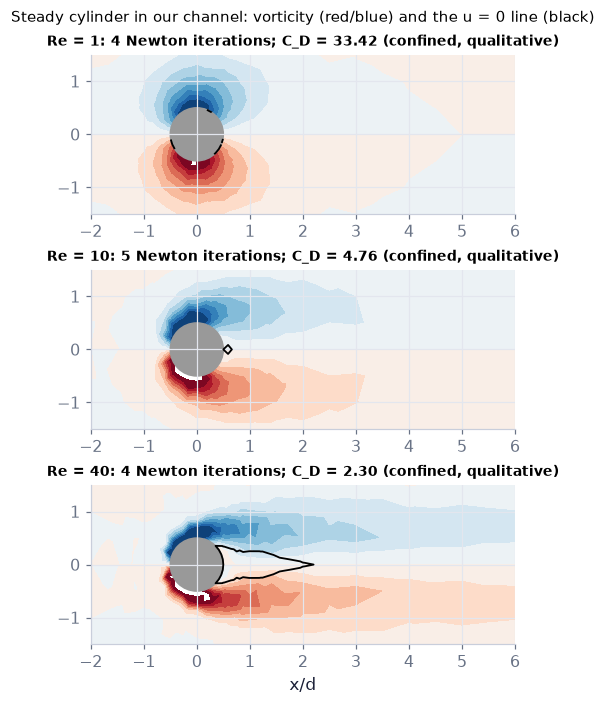

In [159]:
Res_c = (1.0, 10.0, 40.0) if not FAST else (40.0,)                    # FAST: Re = 40 only
fig, axs = plt.subplots(len(Res_c), 1, figsize=(8, 1.9*len(Res_c) + 0.6), squeeze=False)   # the figure and its panels
for ax, Re_ in zip(axs[:, 0], Res_c):   # repeat the indented lines for each item listed
    cs = FEM2.cylinder_steady(Re_, mesh_level="coarse")                # Newton on P2-P1 (cached after the first run)
    msh = cs["mesh"]; V_ = msh["vertices"]; uV = cs["u"][:msh.V]       # vertices and u at the vertices
    ax.tricontourf(V_[:, 0], V_[:, 1], msh.tris, np.clip(cs["omega"], -4, 4), levels=np.linspace(-4, 4, 17), cmap="RdBu_r")   # vorticity
    ax.tricontour(V_[:, 0], V_[:, 1], msh.tris, uV, levels=[0.0], colors="k", linewidths=1.2)   # u = 0: edge of the recirculation
    ax.add_patch(plt.Circle((0, 0), 0.5, color="0.6")); ax.set_xlim(-2, 6); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal")   # axis range / scale chosen so the feature discussed below is visible
    ax.set_title(f"Re = {Re_:g}: {cs['iterations']} Newton iterations; C_D = {cs['CD']:.2f} (confined, qualitative)", fontsize=9)   # the panel's title: what this panel shows
axs[-1, 0].set_xlabel("x/d")   # axis labels, with units where the quantity has them
fig.suptitle("Steady cylinder in our channel: vorticity (red/blue) and the u = 0 line (black)", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Vorticity of opposite signs above and below the cylinder, carried downstream; at $Re=40$ a closed black $u=0$ curve behind the cylinder marks the pair of attached eddies (at $Re=1$ and 10 there is no or only a very small one).

**How to read it.** Vorticity is made at the cylinder's surface and carried downstream; the recirculation bubble grows with $Re$ — the trend of Ch. 9.

**What would change if…** …a mesh that is not up–down symmetric: the steady solution would be slightly asymmetric and give a small lift (as the book notes for its own mesh).

> 🔁 **Recap — R13 · Strouhal number with the cyclic frequency** (Ch. 4 §4.11, Ch. 9 §9.8). $St=f_sd/U=1/\bar\tau$ with the shedding frequency $f_s$ in cycles per unit time and the period $\bar\tau$ in units of $d/U$ (Ch. 4's $St=\frac{\Omega d}U$ *(4.102)* with $\Omega$ the cyclic frequency $f_s$; Ch. 9's `shedding_frequency`).

> ⚠️ **Printed slip.** **The book compares its computed (confined) Strouhal number with an unbounded value; the configurations differ** (a channel only a few diameters wide with sliding
walls vs an open stream), so the comparison is qualitative only (slip #9). For an unbounded cylinder at $Re=100$ the literature gives 0.164–0.165 (Williamson 1996,
experiments; Kravchenko et al.; Posdziech & Grundmann) — a different configuration. Our own number below is labelled "confined, ours".

In [160]:
fr, notes_fr = read_table("cylinder_fe_re100_forces.csv")               # our unsteady P2-P1 run, Re = 100 (confined)
late = fr["t"] > 0.5*fr["t"].max()                                       # the periodic second half of the history
f_zc = ch10.dominant_frequency(fr["t"][late], fr["CL"][late], "zero_crossings")   # upward zero crossings of C_L (P180)
f_ff = ch10.dominant_frequency(fr["t"][late], fr["CL"][late], "fft")              # peak of the spectrum (P181)
print(f"St from zero crossings = {ch10.strouhal_from_period(1/f_zc):.4f}, from the FFT = {f_ff:.4f}  (confined, ours); "   # show the numbers computed above
      f"relative difference {abs(f_zc - f_ff)/f_zc:.1e}")

St from zero crossings = 0.2054, from the FFT = 0.2055  (confined, ours); relative difference 7.6e-04


**What does the code above do?**

1. `read_table` loads our committed force history ($C_D$, $C_L$, torque against $\bar t=tU/d$).
2. `dominant_frequency` finds the lift's frequency twice — from the spacing of its upward zero crossings and from the peak of its spectrum; $St=1/\bar\tau$ with
   $\bar\tau$ the period. The two estimates agree closely. The value is for our confined channel: it is not an unbounded cylinder's Strouhal number.

📝 **Note.** **N93 [B], N94 [B]** **Domain and mesh (Figs. 10.15–10.16 analogues, ours):** a channel of width $W=5d$ with the cylinder $8d$ from the inflow $\Gamma_1$ and $16d$ from the outflow
$\Gamma_2$, sliding walls $\Gamma_3$, $\Gamma_4$, the cylinder $\Gamma_5$; a triangular mesh refined near the body. Node counts: P2 velocity nodes = vertices + edges, P1 pressure
nodes = vertices; Euler's formula for a triangulated domain with one hole, $V-E+T=0$.

In [161]:
mesh_c = FEM2.cylinder_channel_mesh()                                   # our default mesh (medium), P2-P1
print("Euler check:", FEM2.euler_check(mesh_c), "   counts:", FEM2.p2_node_counts(mesh_c.V, mesh_c.E, mesh_c.T),
      f"  (V = {mesh_c.V}, E = {mesh_c.E}, T = {mesh_c.T})")

Euler check: {'N_u': 5340, 'N_p': 1384, 'euler': 0}    counts: {'N_u': 5340, 'N_p': 1384, 'euler': 0}   (V = 1384, E = 3956, T = 2572)


**What does the code above do?**

`euler_check` computes $V-E+T$ (0 for one hole); `p2_node_counts` gives the P2 velocity nodes $N_u=V+E$ and the P1 pressure nodes $N_p=V$.

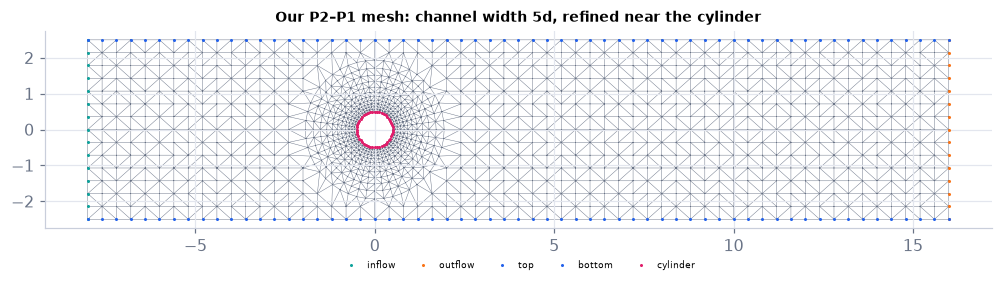

In [162]:
fig, ax = plt.subplots(figsize=(9, 2.4))   # the figure and its panels
Vc = mesh_c["vertices"]
ax.triplot(Vc[:, 0], Vc[:, 1], mesh_c.tris, color=C_EX, lw=0.3)          # the triangles
for name, col in (("inflow", C_UP), ("outflow", C_FT), ("top", C_IM), ("bottom", C_IM), ("cylinder", C_BAD)):   # repeat the indented lines for each item listed
    idx = [i_ for i_ in mesh_c.boundary[name] if i_ < mesh_c.V]          # boundary vertices of this part
    ax.plot(mesh_c.nodes[idx, 0], mesh_c.nodes[idx, 1], ".", color=col, ms=2, label=name)   # draw the curve(s)
ax.set_aspect("equal"); ax.legend(fontsize=6, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)   # equal scales in x and y, so shapes are not distorted
ax.set_title("Our P2–P1 mesh: channel width 5d, refined near the cylinder", fontsize=9)   # the panel's title: what this panel shows
plt.show()   # display the figure

**What you see.** Small triangles near the cylinder growing larger away from it; the five boundary parts coloured (inflow, outflow, the two sliding walls, the cylinder).

**How to read it.** Elements follow the curved body — the geometric advantage of FE (C08) — and are small where the velocity gradients are large.

**What would change if…** …straight-sided elements at the cylinder: the circle would become a polygon; curved (isoparametric) elements, N104, remove that error.

📝 **Note.** **N95 [B], N96 [C]** **Cartesian weak equations:** expanding $\mathbf D:\tilde{\mathbf D}=u_x\tilde u_x+\frac12(u_y+v_x)(\tilde u_y+\tilde v_x)+v_y\tilde v_y$ and separating $\tilde u$ and $\tilde v$
gives $\int_\Omega(u_t+uu_x+vu_y)\tilde u\,d\Omega-\int_\Omega p\tilde u_x\,d\Omega+\frac1{Re}\int_\Omega[2u_x\tilde u_x+(u_y+v_x)\tilde u_y]\,d\Omega=0$ *(10.157)*, its $v$-twin *(10.158)*, $\int_\Omega(v_t+uv_x+vv_y)\tilde v\,d\Omega-\int_\Omega p\tilde v_y\,d\Omega+\tfrac1{Re}\int_\Omega[(u_y+v_x)\tilde v_x+2v_y\tilde v_y]\,d\Omega=0$ and
$-\int_\Omega(u_x+v_y)\tilde p\,d\Omega=0$ *(10.159)* — the minus sign is chosen so that the pressure blocks come out as $\mathbf B$ and $\mathbf B^T$. The Galerkin statements
are the same three with every field replaced by its finite-element version (superscript $h$) on the triangulated domain $\Omega^h$:

$$\int_{\Omega^h}\Big(\frac{\partial u^h}{\partial t}+u^h\frac{\partial u^h}{\partial x}+v^h\frac{\partial u^h}{\partial y}\Big)\tilde u^h\,d\Omega-\int_{\Omega^h}p^h\frac{\partial\tilde u^h}{\partial x}d\Omega+\frac1{Re}\int_{\Omega^h}\Big[2\frac{\partial u^h}{\partial x}\frac{\partial\tilde u^h}{\partial x}+\Big(\frac{\partial u^h}{\partial y}+\frac{\partial v^h}{\partial x}\Big)\frac{\partial\tilde u^h}{\partial y}\Big]d\Omega=0\quad\text{(10.160)}$$
$$\int_{\Omega^h}\Big(\frac{\partial v^h}{\partial t}+u^h\frac{\partial v^h}{\partial x}+v^h\frac{\partial v^h}{\partial y}\Big)\tilde v^h\,d\Omega-\int_{\Omega^h}p^h\frac{\partial\tilde v^h}{\partial y}d\Omega+\frac1{Re}\int_{\Omega^h}\Big[\Big(\frac{\partial u^h}{\partial y}+\frac{\partial v^h}{\partial x}\Big)\frac{\partial\tilde v^h}{\partial x}+2\frac{\partial v^h}{\partial y}\frac{\partial\tilde v^h}{\partial y}\Big]d\Omega=0\quad\text{(10.161)}$$
$$-\int_{\Omega^h}\Big(\frac{\partial u^h}{\partial x}+\frac{\partial v^h}{\partial y}\Big)\tilde p^h\,d\Omega=0\quad\text{(10.162)}$$

In [163]:
print("2 D:D~ minus the Cartesian split of (10.157) + (10.158):", ch10.weak_ns_components_sympy()["difference"])   # 0

2 D:D~ minus the Cartesian split of (10.157) + (10.158):

 0


**What does the code above do?**

The sympy engine checks that $2\mathbf D:\tilde{\mathbf D}$ equals the sum of the two Cartesian viscous brackets — term for term.

📝 **Note.** **N97 [B]** **Time derivative at $t_{n+1}$ (10.163):** $\frac{\partial\mathbf u}{\partial t}(\mathbf x,t_{n+1})\approx\alpha_t\frac{\mathbf u(\mathbf x,t_{n+1})-\mathbf u(\mathbf x,t_n)}{\Delta t}-\beta_t\frac{\partial\mathbf u}{\partial t}(\mathbf x,t_n)$ *(10.163)*
— $\alpha_t=1,\ \beta_t=0$ is backward Euler (first order); $\alpha_t=2,\ \beta_t=1$ is the trapezoidal rule (second order, "a variation of Crank–Nicolson"). (The book writes
$\alpha$, $\beta$; the subscript $t$ keeps them apart from the FTCS numbers.)

In [164]:
print(f"backward Euler: order {FD.ode_scheme_order('backward'):.2f};  trapezoidal: order {FD.ode_scheme_order('trapezoidal'):.2f}")   # on y' = -y

backward Euler: order 0.99;  trapezoidal: order 2.00


**What does the code above do?**

The two choices of (10.163), $\dfrac{\partial\mathbf u}{\partial t}(\mathbf x,t_{n+1})\approx\alpha_t\dfrac{\mathbf u(\mathbf x,t_{n+1})-\mathbf u(\mathbf x,t_n)}{\Delta t}-\beta_t\dfrac{\partial\mathbf u}{\partial t}(\mathbf x,t_n)$ measured on $y'=-y$: first and second order.

📝 **Note.** **N98 [B], N99 [B], N100 [C], N101 [C], N102 [B], N103 [C]** **Newton at every time step:** write each field as guess + correction, $\mathbf u^h=\mathbf u^*+\mathbf u'$,
$p^h=p^*+p'$ *(10.164)* (Newton, Ch. 6 P152; here $\mathbf u'$, $p'$ are corrections, not perturbations); substitute, drop the product of two corrections $\mathbf u'\cdot\nabla\mathbf u'$ —
the one idea of (10.165)–(10.167), $\int_{\Omega^h}\Big(\tfrac{\alpha_t}{\Delta t}u'+u^*u'_x+v^*u'_y+u^*_xu'+u^*_yv'\Big)\tilde u^h\,d\Omega-\int_{\Omega^h}p'\tilde u^h_x\,d\Omega+\tfrac1{Re}\int_{\Omega^h}\big[2u'_x\tilde u^h_x+(u'_y+v'_x)\tilde u^h_y\big]d\Omega=-\int_{\Omega^h}\Big[\tfrac{\alpha_t}{\Delta t}(u^*-u(t_n))-\beta_t u_t(t_n)+u^*u^*_x+v^*u^*_y\Big]\tilde u^h\,d\Omega+\int_{\Omega^h}p^*\tilde u^h_x\,d\Omega-\tfrac1{Re}\int_{\Omega^h}\big[2u^*_x\tilde u^h_x+(u^*_y+v^*_x)\tilde u^h_y\big]d\Omega,\ \int_{\Omega^h}\Big(\frac{\alpha_t}{\Delta t}v'+u^*v'_x+v^*v'_y+v^*_xu'+v^*_yv'\Big)\tilde v^h\,d\Omega-\dots=-\int_{\Omega^h}\Big(\alpha_t\frac{v^*-v(t_n)}{\Delta t}-\beta_t\frac{\partial v}{\partial t}(t_n)+\dots\Big)\tilde v^h\,d\Omega,\ -\int_{\Omega^h}(u'_x+v'_y)\tilde p^h\,d\Omega=\int_{\Omega^h}(u^*_x+v^*_y)\tilde p^h\,d\Omega$ — and the right-hand sides are the residuals of the current guess (zero at convergence), the left-hand sides the Jacobian. Expand the
corrections in velocity shapes $N^u_A$ and pressure shapes $N^p_B$, $u'=\sum_Au_AN^u_A$, $v'=\sum_Av_AN^u_A$, $p'=\sum_Bp_BN^p_B$ *(10.168)*, and the test functions in the same
shapes, $\tilde u^h=\sum_A\tilde u_AN^u_A$, $\tilde v^h=\sum_A\tilde v_AN^u_A$, $\tilde p^h=\sum_B\tilde p_BN^p_B$ *(10.169)*. Because the test coefficients are arbitrary, each
one gives its own equation — one per velocity node $A$ for $u$ (and its twin for $v$), one per pressure node $B$ for continuity:

$$\sum_{A'}u_{A'}\int_{\Omega^h}\Big[\Big(\frac{\alpha_t}{\Delta t}N^u_{A'}+u^*N^u_{A',x}+v^*N^u_{A',y}+u^*_xN^u_{A'}\Big)N^u_A+\frac1{Re}\big(2N^u_{A',x}N^u_{A,x}+N^u_{A',y}N^u_{A,y}\big)\Big]d\Omega+\sum_{A'}v_{A'}\int_{\Omega^h}\Big(u^*_yN^u_{A'}N^u_A+\frac1{Re}N^u_{A',x}N^u_{A,y}\Big)d\Omega-\sum_{B'}p_{B'}\int_{\Omega^h}N^p_{B'}N^u_{A,x}\,d\Omega=f^u_A\quad\text{(10.170)}$$
$$\sum_{A'}v_{A'}\int_{\Omega^h}\Big[\Big(\frac{\alpha_t}{\Delta t}N^u_{A'}+u^*N^u_{A',x}+v^*N^u_{A',y}+v^*_yN^u_{A'}\Big)N^u_A+\frac1{Re}\big(N^u_{A',x}N^u_{A,x}+2N^u_{A',y}N^u_{A,y}\big)\Big]d\Omega+\sum_{A'}u_{A'}\int_{\Omega^h}\Big(v^*_xN^u_{A'}N^u_A+\frac1{Re}N^u_{A',y}N^u_{A,x}\Big)d\Omega-\sum_{B'}p_{B'}\int_{\Omega^h}N^p_{B'}N^u_{A,y}\,d\Omega=f^v_A\quad\text{(10.171)}$$
$$\sum_{A'}u_{A'}\int_{\Omega^h}N^u_{A',x}N^p_B\,d\Omega+\sum_{A'}v_{A'}\int_{\Omega^h}N^u_{A',y}N^p_B\,d\Omega=-\int_{\Omega^h}(u^*_x+v^*_y)N^p_B\,d\Omega\quad\text{(10.172)}$$

where $f^u_A$, $f^v_A$ are the residuals of the current guess tested with $N^u_A$ (the long right-hand sides, zero at convergence). Grouped by unknown they form the block system
$\begin{pmatrix}\mathbf A_{uu}&\mathbf A_{uv}&\mathbf B_{up}\\\mathbf A_{vu}&\mathbf A_{vv}&\mathbf B_{vp}\\\mathbf B^T_{up}&\mathbf B^T_{vp}&0\end{pmatrix}\begin{pmatrix}\mathbf u\\\mathbf v\\\mathbf p\end{pmatrix}=\begin{pmatrix}\mathbf f_u\\\mathbf f_v\\\mathbf f_p\end{pmatrix}$
*(10.173)*, with block entries such as $B^{up}_{AB'}=-\int_{\Omega^h}N^p_{B'}N^u_{A,x}\,d\Omega$ *(10.179)* — the whole set is coded in `FEM2.assemble_newton_system`.

> ⚠️ **Printed slip.** **The book prints, in (10.166),** $\beta_t\frac{\partial v^*}{\partial t}(t_n)$; **it is** $\beta_t\frac{\partial v}{\partial t}(t_n)$ — known data at $t_n$, not a Newton iterate (slip #10).
**The book prints the second sum of (10.172) as** $\sum_{A'}u_{A'}\int_{\Omega^h}N^u_{A',y}N^p_B\,d\Omega\ \ (\text{second sum})$; **it must be** $\sum_{A'}v_{A'}\int_{\Omega^h}N^u_{A',y}N^p_B\,d\Omega$ — it comes from $\partial v'/\partial y$
(slip #6; the printed version fails our Poiseuille test).

In [165]:
cs40 = FEM2.cylinder_steady(40.0, mesh_level="coarse")                  # the steady Re = 40 Newton solve (cached)
r_ = np.array(cs40["residuals"], dtype=float)                           # max |residual| after each iteration
print("residuals:", [f"{v:.1e}" for v in r_])   # show the numbers computed above
print("r_(k+1)/r_k^2:", np.round(r_[1:]/r_[:-1]**2, 1))                  # roughly bounded: quadratic convergence
pt = FEM2.poiseuille_test(4); pt_bad = FEM2.poiseuille_test(4, printed=True)   # channel flow with the corrected and the printed (10.172)
print(f"Poiseuille max velocity error: corrected {pt['err_u']:.1e}, printed (10.172) {pt_bad['err_u']:.1e}")   # show the numbers computed above
kz = FEM2.kovasznay_test(32 if not FAST else 16)                       # Kovasznay's exact steady Navier-Stokes flow
print("Kovasznay observed orders (u, p) from n/2 to n:", {k: round(v, 2) for k, v in kz["orders"].items()})   # show the numbers computed above

residuals:

 ['1.5e-02', '2.3e-03', '3.1e-04', '1.1e-06', '4.7e-12']
r_(k+1)/r_k^2: [10.2 59.2 11.8  3.8]
Poiseuille max velocity error: corrected 1.1e-14, printed (10.172) 1.7e+55


Kovasznay observed orders (u, p) from n/2 to n: {'u': 3.0, 'p': 2.23}


**What does the code above do?**

1. Newton converges in a handful of iterations; the ratios $r_{k+1}/r_k^2$ stay roughly bounded — each iteration about squares the error (quadratic convergence).
2. `poiseuille_test` solves a channel flow whose exact answer is known: exact to round-off with the corrected (10.172), $\sum_{A'}u_{A'}\int_{\Omega^h}N^u_{A',x}N^p_B\,d\Omega+\sum_{A'}v_{A'}\int_{\Omega^h}N^u_{A',y}N^p_B\,d\Omega=-\int_{\Omega^h}(u^*_x+v^*_y)N^p_B\,d\Omega$, clearly wrong with the printed one (slip #6).
3. `kovasznay_test(n)` solves Kovasznay's exact steady Navier–Stokes flow on $n$ and $n/2$ squares: the velocity converges at third order and the pressure at about second
   order, as quadratic/linear elements should (on $16\to32$; the verification report quotes 3.00 and 2.23).

📝 **Note.** **N104 [B], N105 [B], N106 [B], N107 [C], N108 [B], N109 [B]** **One curved element:** the six-node isoparametric map
$x(\xi,\eta)=\sum_{a=1}^6x^e_a\phi_a(\xi,\eta)$, $y=\sum_ay^e_a\phi_a$ *(10.184)* bends the element to the circle; the quadratic shapes $\phi_1=\zeta(2\zeta-1),\ \phi_2=\xi(2\xi-1),\
\phi_3=\eta(2\eta-1),\ \phi_4=4\xi\zeta,\ \phi_5=4\xi\eta,\ \phi_6=4\eta\zeta$ with $\zeta=1-\xi-\eta$ *(10.185)* (barycentric coordinates, P248); element expansions
$u'=\sum_{a=1}^6u^e_a\phi_a$, $v'=\sum_av^e_a\phi_a$, $p'=\sum_{b=1}^3p^e_b\psi_b$ *(10.186)* with $\psi_1=\zeta,\ \psi_2=\xi,\ \psi_3=\eta$ *(10.187)*; the element matrices $\mathbf A^e_{uu}=[A^{euu}_{aa'}],\ \mathbf A^e_{uv}=[A^{euv}_{aa'}],\ \mathbf B^e_{up}=[B^{eup}_{ab'}],\ \dots,\ \mathbf f^e_u=\{f^{eu}_a\},\ \mathbf f^e_p=\{f^{ep}_b\}$ *(10.188)* have the global entries with $N^u\to\phi$, $N^p\to\psi$ — for
example $B^{eup}_{ab'}=-\int_{\Omega^e}\psi_{b'}\frac{\partial\phi_a}{\partial x}\,d\Omega$ *(10.193)* and the continuity residual $f^{ep}_b=\int_{\Omega^e}\Big(\frac{\partial u^*}{\partial x}+\frac{\partial v^*}{\partial y}\Big)\psi_b\,d\Omega$ *(10.197)*, the book's list running from (10.189), $A^{euu}_{aa'}=\int_{\Omega^e}\Big[\Big(\frac{\alpha_t}{\Delta t}\phi_{a'}+u^*\frac{\partial\phi_{a'}}{\partial x}+v^*\frac{\partial\phi_{a'}}{\partial y}+\frac{\partial u^*}{\partial x}\phi_{a'}\Big)\phi_a+\frac1{Re}\Big(2\frac{\partial\phi_{a'}}{\partial x}\frac{\partial\phi_a}{\partial x}+\frac{\partial\phi_{a'}}{\partial y}\frac{\partial\phi_a}{\partial y}\Big)\Big]d\Omega$ to (10.197); integrals by the 7-point rule on the parent triangle, $\int_{\Omega^e}f\,d\Omega=\frac12\sum_{l=1}^{7}f(\xi_l,\eta_l)J(\xi_l,\eta_l)W_l$
with $J=x_\xi y_\eta-x_\eta y_\xi$ *(10.198)* (P249; exact for polynomials of degree ≤ 5 on straight elements, no longer exact on curved ones); assembled by the node map, with
essential conditions imposed by row replacement or a large penalty (both give the same Poiseuille solution).

> ⚠️ **Printed slip.** **The book prints the third expansion of (10.186) as** $v'=\sum_{b=1}^3p^e_b\psi_b\ \ (\text{third expansion})$; **it is** $p'=\sum_{b=1}^3p^e_b\psi_b$ (slip #7).

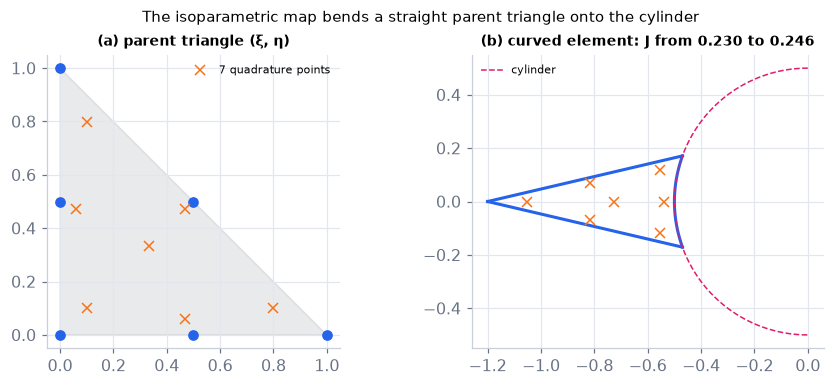

In [166]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.4))   # the figure and its panels
par = np.array([[0, 0], [1, 0], [0, 1], [0.5, 0], [0.5, 0.5], [0, 0.5]])   # parent nodes: vertices, then mid-edges
P7, W7 = FEM2.tri_quad_7pt()
a1.fill([0, 1, 0], [0, 0, 1], color=C_EX, alpha=0.15); a1.plot(par[:, 0], par[:, 1], "o", color=C_IM)   # draw the curve(s)
a1.plot(P7[:, 0], P7[:, 1], "x", color=C_FT, ms=7, label="7 quadrature points"); a1.set_aspect("equal"); a1.legend(fontsize=7, frameon=False)   # equal scales in x and y, so shapes are not distorted
a1.set_title("(a) parent triangle (ξ, η)", fontsize=9)   # the panel's title: what this panel shows
ang = np.deg2rad([200, 160]); R0 = 0.5                                  # two vertices on the cylinder (radius 0.5), one outside
v1 = R0*np.array([np.cos(ang[0]), np.sin(ang[0])]); v2 = R0*np.array([np.cos(ang[1]), np.sin(ang[1])]); v3 = np.array([-1.2, 0.0])
mid12 = R0*np.array([np.cos(np.pi), np.sin(np.pi)])                     # the mid-node moved ONTO the circle
xe = np.array([v1[0], v2[0], v3[0], mid12[0], (v2[0] + v3[0])/2, (v3[0] + v1[0])/2])   # six physical nodes (x)
ye = np.array([v1[1], v2[1], v3[1], mid12[1], (v2[1] + v3[1])/2, (v3[1] + v1[1])/2])   # (y)
s_ = np.linspace(0, 1, 50)   # sample points
for xi_, eta_ in ((s_, 0*s_), (1 - s_, s_), (0*s_, 1 - s_)):            # the three edges of the parent, mapped
    X_, Y_ = FEM2.iso_map(xe, ye, xi_, eta_); a2.plot(X_, Y_, color=C_IM)   # draw the curve(s)
Xq, Yq = FEM2.iso_map(xe, ye, P7[:, 0], P7[:, 1]); a2.plot(Xq, Yq, "x", color=C_FT, ms=7)   # draw the curve(s)
th_c = np.linspace(np.pi/2, 3*np.pi/2, 100); a2.plot(R0*np.cos(th_c), R0*np.sin(th_c), "--", color=C_BAD, lw=1, label="cylinder")   # draw the curve(s)
Js = [FEM2.jacobian(xe, ye, *q) for q in P7]                             # J at the 7 points: varies inside a curved element
a2.set_aspect("equal"); a2.legend(fontsize=7, frameon=False); a2.set_title(f"(b) curved element: J from {min(Js):.3f} to {max(Js):.3f}", fontsize=9)   # the panel's title: what this panel shows
fig.suptitle("The isoparametric map bends a straight parent triangle onto the cylinder", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** (a) The parent triangle with its six nodes and seven quadrature points; (b) its image: one side follows the cylinder (dashed), the quadrature points mapped inside.

**How to read it.** The map (10.184), $x(\xi,\eta)=\sum_{a=1}^6x^e_a\phi_a(\xi,\eta),\qquad y(\xi,\eta)=\sum_{a=1}^6y^e_a\phi_a(\xi,\eta)$ is quadratic, so the side through the moved mid-node is curved; the Jacobian $J$ varies inside (the title prints its range), which is why the 7-point rule is only approximate on curved elements.

**What would change if…** …straight elements: the circle becomes a polygon — the geometric error that curved elements remove.

📝 **Note.** **N110 [B]** **Re = 100, unsteady:** started from rest the wake is symmetric at first, then a small asymmetry grows and the wake settles into periodic shedding — a
*supercritical Hopf bifurcation* (a steady state losing stability to an oscillation; Ch. 11) that produces a Kármán street. Our force history (drag, lift and torque against
$\bar t=tU/d$, confined, ours) is plotted from the cached file; our run was started from the steady state with a brief rotation pulse to trigger the asymmetry. A torque with a
non-zero mean would come from a mesh that is not symmetric.

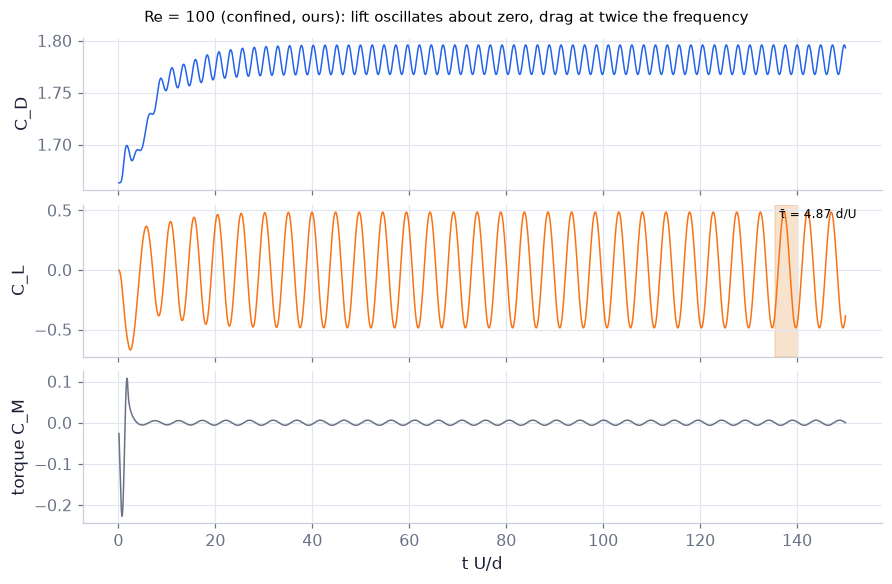

In [167]:
fig, axs = plt.subplots(3, 1, figsize=(8, 5.2), sharex=True)   # the figure and its panels
for ax, key, col, lab in zip(axs, ("CD", "CL", "CM"), (C_IM, C_FT, C_EX), ("C_D", "C_L", "torque C_M")):   # repeat the indented lines for each item listed
    ax.plot(fr["t"], fr[key], color=col, lw=1); ax.set_ylabel(lab)   # axis labels, with units where the quantity has them
tau = 1/f_zc; t0_ = fr["t"].max() - 3*tau                               # mark one period near the end
axs[1].axvspan(t0_, t0_ + tau, color=COLORS["amber"], alpha=0.2); axs[1].text(t0_, axs[1].get_ylim()[1]*0.8, f" τ̄ = {tau:.2f} d/U", fontsize=8)   # a reference line or band
axs[-1].set_xlabel("t U/d")   # axis labels, with units where the quantity has them
fig.suptitle("Re = 100 (confined, ours): lift oscillates about zero, drag at twice the frequency", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Three histories: the drag (top) nearly constant with a small fast wiggle, the lift (middle) a steady oscillation about zero with one period shaded, the torque (bottom) a small oscillation about zero.

**How to read it.** Each shed vortex pulls the cylinder sideways (lift, once per cycle) and back (drag, twice per cycle); the period $\bar\tau$ gives the Strouhal number $1/\bar\tau$ of the cell above.

**What would change if…** …$Re=40$: all three curves would flatten to constants — below the Hopf point.

---

## 10.6 Concluding Remarks

**What is this section about?** CFD is a tool, not an oracle. The chapter ends with a checklist for trusting a result and a glance at methods not covered. We apply the checklist to
our own cavity solver.

**N111 [B] — C15 (continued): the verification checklist**, applied to our MAC cavity (the numbers are printed by the cell below):

| Check | What we did | Outcome |
|---|---|---|
| benchmark with a known answer | Ghia et al. (1982) centreline, $64^2$ | printed deviation (C14) |
| mesh refinement | three grids, observed order and Richardson | printed in C15 |
| time-step refinement | $\Delta t$ and $\Delta t/2$ on $32^2$ | printed below |
| insensitivity to the boundary treatment | linear vs quadratic ghost values for no slip, $32^2$ | printed below |
| parameter sensitivity | $Re=100$ vs $Re=400$ (our committed $128^2$ tables) | printed below |

In [168]:
import re                                                               # regular expressions: pick numbers out of a text line
s32 = MAC.cavity(Re=100.0, n=32)                                        # the reference 32^2 run (cached)
s32h = MAC.cavity(Re=100.0, n=32, dt=s32["dt"]/2)                       # the same with half the time step
s32q = MAC.cavity(Re=100.0, n=32, ghost="quadratic")                    # the same with the quadratic wall ghost
c0, ch_, cq = (MAC.cavity_centreline(s_)["u"] for s_ in (s32, s32h, s32q))
print(f"time-step refinement: max |du| on the centreline = {np.abs(c0 - ch_).max():.1e}")   # show the numbers computed above
print(f"boundary treatment: max |du| on the centreline = {np.abs(c0 - cq).max():.1e} (= {100*np.abs(c0 - cq).max():.2f} % of U)")   # show the numbers computed above
for Re_ in (100, 400):                                                  # parameter sensitivity from our committed 128^2 tables
    _, notes_ = read_table(f"cavity_mac_re{Re_}_n128.csv")
    xy = [float(v) for v in re.findall(r"centre x = ([0-9.]+), y = ([0-9.]+)", notes_)[0]]   # our eddy centre, from the table's header
    print(f"Re = {Re_}: our 128^2 eddy centre ({xy[0]:.4f}, {xy[1]:.4f});  Ghia's {ch10.ghia_vortex_centre(Re_)}")   # show the numbers computed above

time-step refinement: max |du| on the centreline = 1.3e-07
boundary treatment: max |du| on the centreline = 3.5e-03 (= 0.35 % of U)
Re = 100: our 128^2 eddy centre (0.6153, 0.7377);  Ghia's {'x': 0.6172, 'y': 0.7344}
Re = 400: our 128^2 eddy centre (0.5553, 0.6061);  Ghia's {'x': 0.5547, 'y': 0.6055}


**What does the code above do?**

1. Halving $\Delta t$ changes the steady centreline by about $10^{-7}$: the steady answer does not depend on the time step (the splitting error vanishes at steady state).
2. Changing how the no-slip condition enters (linear or quadratic ghost values) changes it by a few tenths of a per cent at $32^2$ — a boundary-treatment uncertainty of the
   same size as the grid error there.
3. At $Re=400$ the eddy centre moves down and towards the middle of the box, as Ghia reports. The centre is read from the table's comment line with
   `re.findall(pattern, text)`, which returns every match of a regular-expression pattern; each `([0-9.]+)` group captures one number (digits and dots),
   so the first match gives the pair of strings `(x, y)` that `float` turns into numbers.

**N112 [C]** **Other methods, named:** spectral and spectral-element methods (global smooth basis functions; our Ch. 7 `kdv_solve` is pseudo-spectral); lattice-gas and
lattice-Boltzmann methods and dissipative particle dynamics — kinetic models that do not start from the continuum Navier–Stokes equations. (Hou et al.'s cavity centres used in
C14 are lattice-Boltzmann results.)

*↪ **S01** Exercises 10.1–10.6 are in the book; our own versions of their ideas are C04 (Noye's region), N17 (an implicit scheme's stability), N113 (the heated rod), C08
(element matrices), C09 (central vs upwind) and C14 (the cavity). No exercise text, input or answer is reproduced here.*

*↪ **S02** Literature and supplemental reading: see the book's list; the data we use are cited where they are used — Ghia, Ghia & Shin (1982), J. Comput. Phys. 48,
387–411, and Hou, Zou, Chen, Doolen & Cogley (1995), J. Comput. Phys. 118, 329–347.*

---

## ✅ What should have clicked

- **C01** A stencil is a weighted sum of Taylor series; the first term it fails to cancel is its error, and the power of $\Delta x$ there is its order — a slope on log–log axes.
- **C02** FTCS computes each new value as a weighted average of three old ones, with $\alpha=u\Delta t/(2\Delta x)$ and $\beta=D\Delta t/\Delta x^2$.
- **C03** Put the exact solution into the scheme: what is left over, $E=\frac{\Delta t}2T_{tt}+u\frac{\Delta x^2}6T_{xxx}-D\frac{\Delta x^2}{12}T_{xxxx}$, must vanish as the grid shrinks — consistency.
- **C04** Every Fourier mode of the round-off is multiplied by $G(\theta)$ each step; FTCS is stable only inside $0\le4\alpha^2\le2\beta\le1$, BTCS always.
- **C05** Upwinding is stable exactly when the characteristic's foot stays inside the stencil, $C=u\Delta t/\Delta x\le1$; with consistency, that stability is what buys convergence (Lax).
- **C06** Multiply by a test function and integrate by parts: only first derivatives remain, the Neumann condition comes free (natural) and the Dirichlet one is built into the space (essential).
- **C07** Galerkin with hats turns the weak form into $\mathbf M\dot{\mathbf d}+\mathbf K\mathbf d=\mathbf F$, whose rows are FD stencils with a ⅙–⅔–⅙ mass.
- **C08** Compute a $2\times2$ block on each element and scatter-add it — the same loop assembles any mesh.
- **C09** The centred discrete solution is $r^j$ with $r<0$ once $R_{cell}>2$ — wiggles; upwinding removes them by adding a diffusivity $0.5R_{cell}D$.
- **C10** A slightly compressible fluid gives the pressure its own equation; MacCormack's forward-then-backward stages average to a second-order (Lax–Wendroff) step, stable for $C\le1$ on the sound speed.
- **C11** Split the step: move the flow ignoring pressure, then add the one gradient that removes the divergence — a Poisson solve and a curl-free correction.
- **C12** Pressure at centres and velocities on faces make divergence and gradient two-point differences: no pressure boundary condition, no hidden checkerboard — the C-grid of climate models.
- **C13** Velocity and pressure spaces must satisfy the inf–sup condition; P2–P1 does, P1–P1 does not.
- **C14** Reproducing a published benchmark within a stated tolerance is evidence that the code solves the intended equations.
- **C15** Three grids give the observed order (a code check) and a Richardson estimate of the grid-independent answer (with an error bar) — and they expose a study that is not yet converged.

**What later chapters build on**

- Ch. 11: FD operators and eigenvalue stability of discretised base flows; the Hopf bifurcation of the cylinder wake (N110).
- Ch. 12: numerical versus eddy diffusivity; resolution of thin layers.
- **Ch. 13:** the C-grid; the CFL limit for gravity waves $\sqrt{gH}$; the projection as the Boussinesq pressure solve; the implicit diffusion of upwind tracer advection.
- Ch. 15: MacCormack and Lax–Wendroff for shocks (with limiters).

**Not taught here (and where to find it)**
- The Re = 1000 smoke-line cylinder (N92).
- The full derivations of the Newton linearisation, the element block entries and the curved-element quadrature (stated in C13, curation §4c).
- Turbulence models (Ch. 12).
- All exercises (S01).